In [113]:
# Import libraries and define configurations
import json
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import joblib
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
    calibration_curve,
)
from sklearn.exceptions import ConvergenceWarning
import imblearn
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTENC,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_recall_curve
import time
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.metrics import brier_score_loss
from sklearn.utils.validation import (
    check_is_fitted,
)
import hashlib
import subprocess

RANDOM_STATE = 121
N_JOBS = -1
LOGISTIC_BASELINE_MAX_ITER = 2_000
REGULARIZED_LOGISTIC_MAX_ITER = 2_000
IMBALANCE_RESAMPLING_RATIO = 0.25
IMBALANCE_LOGISTIC_MAX_ITER = 1_000
IMBALANCE_LOGISTIC_TOL = 1e-3
IMBALANCE_RF_N_ESTIMATORS = 200
CALIBRATION_BIN_COUNT = 10
CALIBRATION_INNER_FOLDS = 3
CALIBRATION_MEAN_BIAS_THRESHOLD = 0.005
CALIBRATION_ECE_THRESHOLD = 0.005
CALIBRATION_MAX_BIN_GAP_THRESHOLD = 0.020
CALIBRATION_TRIGGER_COUNT = 2
MIN_BRIER_IMPROVEMENT = 0.0001
MAX_PR_AUC_DEGRADATION = 0.0005
PRIMARY_OPERATING_CAPACITY = 0.10

REGULARIZED_LOGISTIC_N_JOBS = min(
    joblib.cpu_count(),
    8,
)
DECISION_TREE_MAX_DEPTH = 5
DECISION_TREE_MIN_SAMPLES_SPLIT = 100
DECISION_TREE_MIN_SAMPLES_LEAF = 50
RANDOM_FOREST_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)
HIST_GRADIENT_BOOSTING_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)
FEATURE_SET_COMPARISON_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)
DONATION_REPRESENTATION_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)
REDUNDANCY_EXPERIMENT_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)
IMBALANCE_EXPERIMENT_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    5,
)
MODEL_TUNING_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    5,
)
CALIBRATION_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    5,
)

CAMPAIGN_CAPACITIES = [
    0.01,
    0.05,
    0.10,
    0.20,
]

np.random.seed(RANDOM_STATE)


CURRENT_WORKING_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_WORKING_DIRECTORY.parent
    if CURRENT_WORKING_DIRECTORY.name == "notebooks"
    else CURRENT_WORKING_DIRECTORY
)

PROCESSED_DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
REPORTS_DIRECTORY = PROJECT_ROOT / "reports"
MODELS_DIRECTORY = PROJECT_ROOT / "models"

ENGINEERED_FEATURES_PARQUET_PATH = (
    PROCESSED_DATA_DIRECTORY / "donor_features.parquet"
)
ENGINEERED_FEATURES_CSV_PATH = (
    PROCESSED_DATA_DIRECTORY / "donor_features.csv"
)
CLEANED_DONOR_DATA_PATH = (
    PROCESSED_DATA_DIRECTORY / "cleaned_donor_data.csv"
)
FEATURE_DICTIONARY_PATH = (
    REPORTS_DIRECTORY / "feature_dictionary.csv"
)

MODEL_PREDICTIONS_PATH = (
    PROCESSED_DATA_DIRECTORY / "model_predictions.csv"
)
FINAL_PRIMARY_PIPELINE_PATH = (
    MODELS_DIRECTORY / "final_primary_donor_pipeline.joblib"
)
MODEL_COMPARISON_RESULTS_PATH = (
    REPORTS_DIRECTORY / "05_model_comparison_results.csv"
)
CLASSIFICATION_MODELING_REPORT_PATH = (
    REPORTS_DIRECTORY / "05_classification_modeling.md"
)

MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
REPORTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid")
set_config(display="diagram")

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load the engineered dataset and feature dictionary
def format_project_path(path):
    relative_path = Path(path).resolve().relative_to(PROJECT_ROOT)
    return f"/{PROJECT_ROOT.name}/{relative_path.as_posix()}"


artifact_availability = pd.DataFrame({
    "artifact": [
        "Engineered features Parquet",
        "Engineered features CSV fallback",
        "Feature dictionary",
        "Cleaned donor dataset",
    ],
    "path_object": [
        ENGINEERED_FEATURES_PARQUET_PATH,
        ENGINEERED_FEATURES_CSV_PATH,
        FEATURE_DICTIONARY_PATH,
        CLEANED_DONOR_DATA_PATH,
    ],
})

artifact_availability["path"] = artifact_availability["path_object"].apply(
    format_project_path
)
artifact_availability["available"] = artifact_availability["path_object"].apply(
    Path.exists
)

display(artifact_availability[
    ["artifact", "path", "available"]
].style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "th",
        "props": [("text-align", "center")],
    }])
)

if ENGINEERED_FEATURES_PARQUET_PATH.exists():
    modeling_data = pd.read_parquet(
        ENGINEERED_FEATURES_PARQUET_PATH
    )
    modeling_data_source = "Parquet"
    modeling_data_path = ENGINEERED_FEATURES_PARQUET_PATH

elif ENGINEERED_FEATURES_CSV_PATH.exists():
    modeling_data = pd.read_csv(
        ENGINEERED_FEATURES_CSV_PATH
    )
    modeling_data_source = "CSV fallback"
    modeling_data_path = ENGINEERED_FEATURES_CSV_PATH

else:
    raise FileNotFoundError(
        "Neither donor_features.parquet nor donor_features.csv "
        "was found in the processed data directory."
    )

if not FEATURE_DICTIONARY_PATH.exists():
    raise FileNotFoundError(
        f"Feature dictionary not found: "
        f"{format_project_path(FEATURE_DICTIONARY_PATH)}"
    )

feature_dictionary = pd.read_csv(
    FEATURE_DICTIONARY_PATH
)

print(f"\nModeling dataset source: {modeling_data_source}")
print(
    "Modeling dataset path:",
    format_project_path(modeling_data_path),
)
print(
    "Feature dictionary path:",
    format_project_path(FEATURE_DICTIONARY_PATH),
)

print(
    "\nModeling dataset loaded:",
    f"{modeling_data.shape[0]:,} rows × "
    f"{modeling_data.shape[1]:,} columns",
)

print(
    "Feature dictionary loaded:",
    f"{feature_dictionary.shape[0]:,} rows × "
    f"{feature_dictionary.shape[1]:,} columns\n",
)

artifact,path,available
Engineered features Parquet,/red-cross-donor-prediction/data/processed/donor_features.parquet,True
Engineered features CSV fallback,/red-cross-donor-prediction/data/processed/donor_features.csv,True
Feature dictionary,/red-cross-donor-prediction/reports/feature_dictionary.csv,True
Cleaned donor dataset,/red-cross-donor-prediction/data/processed/cleaned_donor_data.csv,True



Modeling dataset source: Parquet
Modeling dataset path: /red-cross-donor-prediction/data/processed/donor_features.parquet
Feature dictionary path: /red-cross-donor-prediction/reports/feature_dictionary.csv

Modeling dataset loaded: 34,403 rows × 55 columns
Feature dictionary loaded: 77 rows × 7 columns



In [3]:
# Validate the Phase 4 modeling export
EXPECTED_ROW_COUNT = 34_403
EXPECTED_COLUMN_COUNT = 55
EXPECTED_PREDICTOR_COUNT = 53

TRACKING_IDENTIFIER_COLUMN = "donor_unique_id"
PRIMARY_TARGET_COLUMN = "target_current_fiscal_year_donor_flag"

DIRECT_LEAKAGE_COLUMNS = {
    "current_fiscal_year_donation",
    "cumulative_donation_amount",
}

EXPECTED_TARGET_COUNTS = {
    0: 32_499,
    1: 1_904,
}

excluded_modeling_columns = {
    TRACKING_IDENTIFIER_COLUMN,
    PRIMARY_TARGET_COLUMN,
}

predictor_columns = [
    column
    for column in modeling_data.columns
    if column not in excluded_modeling_columns
]

unexpected_direct_leakage_columns = sorted(
    set(predictor_columns).intersection(DIRECT_LEAKAGE_COLUMNS)
)

numeric_columns = modeling_data.select_dtypes(
    include=[np.number]
).columns

infinite_value_count = int(
    np.isinf(modeling_data[numeric_columns]).sum().sum()
)

target_distribution = (
    modeling_data[PRIMARY_TARGET_COLUMN]
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("target_class")
    .reset_index(name="record_count")
)

target_distribution["percentage"] = (
    target_distribution["record_count"]
    / len(modeling_data)
    * 100
)

target_distribution["expected_record_count"] = (
    target_distribution["target_class"]
    .map(EXPECTED_TARGET_COUNTS)
)

target_distribution["matches_expected"] = (
    target_distribution["record_count"]
    == target_distribution["expected_record_count"]
)

actual_target_counts = target_distribution.set_index(
    "target_class"
)["record_count"].to_dict()

validation_results = pd.DataFrame({
    "validation_check": [
        "Record count",
        "Total column count",
        "Predictor count",
        "Tracking identifier count",
        "Primary target count",
        "Missing tracking identifiers",
        "Duplicate tracking identifiers",
        "Unexpected direct-leakage columns",
        "Infinite numeric values",
        "Primary target class 0 count",
        "Primary target class 1 count",
    ],
    "expected": [
        EXPECTED_ROW_COUNT,
        EXPECTED_COLUMN_COUNT,
        EXPECTED_PREDICTOR_COUNT,
        1,
        1,
        0,
        0,
        "None",
        0,
        EXPECTED_TARGET_COUNTS[0],
        EXPECTED_TARGET_COUNTS[1],
    ],
    "actual": [
        modeling_data.shape[0],
        modeling_data.shape[1],
        len(predictor_columns),
        list(modeling_data.columns).count(
            TRACKING_IDENTIFIER_COLUMN
        ),
        list(modeling_data.columns).count(
            PRIMARY_TARGET_COLUMN
        ),
        modeling_data[
            TRACKING_IDENTIFIER_COLUMN
        ].isna().sum(),
        modeling_data[
            TRACKING_IDENTIFIER_COLUMN
        ].duplicated().sum(),
        (
            ", ".join(unexpected_direct_leakage_columns)
            if unexpected_direct_leakage_columns
            else "None"
        ),
        infinite_value_count,
        actual_target_counts[0],
        actual_target_counts[1],
    ],
})

validation_results["passed"] = [
    modeling_data.shape[0] == EXPECTED_ROW_COUNT,
    modeling_data.shape[1] == EXPECTED_COLUMN_COUNT,
    len(predictor_columns) == EXPECTED_PREDICTOR_COUNT,
    list(modeling_data.columns).count(
        TRACKING_IDENTIFIER_COLUMN
    ) == 1,
    list(modeling_data.columns).count(
        PRIMARY_TARGET_COLUMN
    ) == 1,
    modeling_data[
        TRACKING_IDENTIFIER_COLUMN
    ].isna().sum() == 0,
    modeling_data[
        TRACKING_IDENTIFIER_COLUMN
    ].duplicated().sum() == 0,
    len(unexpected_direct_leakage_columns) == 0,
    infinite_value_count == 0,
    actual_target_counts[0] == EXPECTED_TARGET_COUNTS[0],
    actual_target_counts[1] == EXPECTED_TARGET_COUNTS[1],
]

def format_validation_value(value):
    if isinstance(value, (bool, np.bool_)):
        return str(value)

    if isinstance(value, (int, np.integer)):
        return f"{value:,.0f}"

    if isinstance(value, (float, np.floating)):
        if pd.isna(value):
            return ""

        if value.is_integer():
            return f"{value:,.0f}"

        if value != 0 and abs(value) < 0.01:
            return f"{value:,.6f}".rstrip("0").rstrip(".")

        return f"{value:,.2f}"

    return str(value)


display(validation_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

print("")

display(target_distribution.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "th",
        "props": [("text-align", "center")],
    }])
    .format({
        "record_count": "{:,.0f}",
        "percentage": "{:,.2f}%",
        "expected_record_count": "{:,.0f}",
    })
)

failed_validation_checks = validation_results.loc[
    ~validation_results["passed"],
    "validation_check",
].tolist()

if failed_validation_checks:
    raise AssertionError(
        "Phase 4 modeling export validation failed for: "
        + ", ".join(failed_validation_checks)
    )

print("\nAll Phase 4 modeling export validation checks passed.\n")

validation_check,expected,actual,passed
Record count,"34,403","34,403",True
Total column count,55,55,True
Predictor count,53,53,True
Tracking identifier count,1,1,True
Primary target count,1,1,True
Missing tracking identifiers,0,0,True
Duplicate tracking identifiers,0,0,True
Unexpected direct-leakage columns,None,None,True
Infinite numeric values,0,0,True
Primary target class 0 count,"32,499","32,499",True


target_class,record_count,percentage,expected_record_count,matches_expected
0,"32,499",94.47%,"32,499",True
1,"1,904",5.53%,"1,904",True



All Phase 4 modeling export validation checks passed.



## Modeling Setup and Data Validation

The Phase 5 modeling environment was configured using a consistent random state of `121`, reusable project paths, and the libraries required for preprocessing, classification, model evaluation, visualization, and model persistence.

Project paths are defined relative to the repository root so the notebook does not display user-specific local directories.

The engineered modeling dataset was loaded from the Parquet export, with the CSV retained as a fallback. The feature dictionary and original cleaned dataset were also confirmed to be available.

The modeling export contains:

* 34,403 records
* 55 total columns
* 53 leakage-safe predictors
* 1 tracking identifier
* 1 primary target

The `donor_unique_id` field contains no missing or duplicate values. No direct-leakage columns or infinite numeric values were found.

The primary target distribution remains unchanged:

| Target Class | Records | Percentage |
| ------------ | ------: | ---------: |
| 0            |  32,499 |     94.47% |
| 1            |   1,904 |      5.53% |

All Phase 4 modeling export validation checks passed. The severe class imbalance confirms that Phase 5 should use stratified splitting and evaluation metrics beyond accuracy.


In [4]:
# Define the primary target, tracking identifier, and predictor matrix
tracking_donor_ids = modeling_data[
    TRACKING_IDENTIFIER_COLUMN
].copy()

target_primary_donor_flag = modeling_data[
    PRIMARY_TARGET_COLUMN
].copy()

features_primary_model = modeling_data.drop(
    columns=[
        TRACKING_IDENTIFIER_COLUMN,
        PRIMARY_TARGET_COLUMN,
    ]
).copy()

primary_model_objects_summary = pd.DataFrame({
    "object_name": [
        "tracking_donor_ids",
        "target_primary_donor_flag",
        "features_primary_model",
    ],
    "record_count": [
        tracking_donor_ids.shape[0],
        target_primary_donor_flag.shape[0],
        features_primary_model.shape[0],
    ],
    "column_count": [
        1,
        1,
        features_primary_model.shape[1],
    ],
})

display(primary_model_objects_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["object_name"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "record_count": "{:,.0f}",
        "column_count": "{:,.0f}",
    })
)

assert len(tracking_donor_ids) == len(modeling_data)
assert len(target_primary_donor_flag) == len(modeling_data)
assert len(features_primary_model) == len(modeling_data)

assert tracking_donor_ids.index.equals(
    target_primary_donor_flag.index
)
assert tracking_donor_ids.index.equals(
    features_primary_model.index
)

assert TRACKING_IDENTIFIER_COLUMN not in features_primary_model.columns
assert PRIMARY_TARGET_COLUMN not in features_primary_model.columns
assert features_primary_model.shape[1] == EXPECTED_PREDICTOR_COUNT

print(
    "\nPrimary modeling objects were created and validated successfully."
)

object_name,record_count,column_count
tracking_donor_ids,"34,403",1
target_primary_donor_flag,"34,403",1
features_primary_model,"34,403",53



Primary modeling objects were created and validated successfully.


In [5]:
# Build and validate predictor list
required_feature_dictionary_columns = {
    "feature_name",
    "leakage_status",
}

missing_feature_dictionary_columns = sorted(
    required_feature_dictionary_columns
    - set(feature_dictionary.columns)
)

if missing_feature_dictionary_columns:
    raise KeyError(
        "Missing required feature dictionary columns: "
        + ", ".join(missing_feature_dictionary_columns)
    )

feature_dictionary_leakage_status = (
    feature_dictionary["leakage_status"]
    .astype(str)
    .str.strip()
    .str.casefold()
)

leakage_safe_predictor_columns = feature_dictionary.loc[
    feature_dictionary_leakage_status.eq("safe"),
    "feature_name",
].tolist()

non_safe_dictionary_features = set(
    feature_dictionary.loc[
        ~feature_dictionary_leakage_status.eq("safe"),
        "feature_name",
    ]
)

missing_safe_predictors = sorted(
    set(leakage_safe_predictor_columns)
    - set(features_primary_model.columns)
)

unexpected_predictor_columns = sorted(
    set(features_primary_model.columns)
    - set(leakage_safe_predictor_columns)
)

duplicate_safe_predictors = sorted(
    pd.Series(leakage_safe_predictor_columns)[
        pd.Series(leakage_safe_predictor_columns).duplicated()
    ].unique()
)

duplicate_predictor_matrix_columns = sorted(
    features_primary_model.columns[
        features_primary_model.columns.duplicated()
    ].unique()
)

identifier_or_target_predictors = sorted(
    set(leakage_safe_predictor_columns).intersection({
        TRACKING_IDENTIFIER_COLUMN,
        PRIMARY_TARGET_COLUMN,
    })
)

non_safe_predictors_included = sorted(
    set(leakage_safe_predictor_columns).intersection(
        non_safe_dictionary_features
    )
)

predictor_validation_results = pd.DataFrame({
    "validation_check": [
        "Safe predictors exist in modeling export",
        "No unexpected predictors in modeling matrix",
        "No duplicate names in safe predictor list",
        "No duplicate columns in predictor matrix",
        "No identifier or target included",
        "No excluded or timing-sensitive features included",
        "Final safe predictor count",
    ],
    "expected": [
        "None missing",
        "None",
        0,
        0,
        "None",
        "None",
        EXPECTED_PREDICTOR_COUNT,
    ],
    "actual": [
        (
            ", ".join(missing_safe_predictors)
            if missing_safe_predictors
            else "None missing"
        ),
        (
            ", ".join(unexpected_predictor_columns)
            if unexpected_predictor_columns
            else "None"
        ),
        len(duplicate_safe_predictors),
        len(duplicate_predictor_matrix_columns),
        (
            ", ".join(identifier_or_target_predictors)
            if identifier_or_target_predictors
            else "None"
        ),
        (
            ", ".join(non_safe_predictors_included)
            if non_safe_predictors_included
            else "None"
        ),
        len(leakage_safe_predictor_columns),
    ],
})

predictor_validation_results["passed"] = [
    len(missing_safe_predictors) == 0,
    len(unexpected_predictor_columns) == 0,
    len(duplicate_safe_predictors) == 0,
    len(duplicate_predictor_matrix_columns) == 0,
    len(identifier_or_target_predictors) == 0,
    len(non_safe_predictors_included) == 0,
    len(leakage_safe_predictor_columns) == EXPECTED_PREDICTOR_COUNT,
]

display(predictor_validation_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_predictor_checks = predictor_validation_results.loc[
    ~predictor_validation_results["passed"],
    "validation_check",
].tolist()

if failed_predictor_checks:
    raise AssertionError(
        "Leakage-safe predictor validation failed for: "
        + ", ".join(failed_predictor_checks)
    )

features_primary_model = features_primary_model.loc[
    :,
    leakage_safe_predictor_columns,
].copy()

print(
    f"\nLeakage-safe predictor list validated with "
    f"{len(leakage_safe_predictor_columns):,} features.\n"
)

validation_check,expected,actual,passed
Safe predictors exist in modeling export,None missing,None missing,True
No unexpected predictors in modeling matrix,None,None,True
No duplicate names in safe predictor list,0,0,True
No duplicate columns in predictor matrix,0,0,True
No identifier or target included,None,None,True
No excluded or timing-sensitive features included,None,None,True
Final safe predictor count,53,53,True



Leakage-safe predictor list validated with 53 features.



In [6]:
# Recreate and validate feature set variants
safe_baseline_historical_features = [
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "is_alumnus_flag",
    "is_parent_flag",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

safe_aggregate_rfm_features = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
    "feature_past_5yr_max_donation",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

safe_trend_enhanced_features = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
    "feature_past_5yr_max_donation",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
    "feature_recent_vs_older_donation_difference",
    "feature_recent_vs_older_donation_ratio",
    "feature_past_5yr_donation_trend_slope",
    "feature_last_year_donation_amount_change",
    "feature_past_5yr_donation_coefficient_of_variation",
    "feature_last_vs_previous_donation_ratio",
    "feature_log1p_last_vs_previous_donation_ratio",
]

full_leakage_safe_candidate_features = [
    "donor_age",
    "is_alumnus_flag",
    "is_parent_flag",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_median_donation",
    "feature_past_5yr_max_donation",
    "feature_past_5yr_min_donation",
    "feature_past_5yr_donation_std",
    "feature_past_5yr_active_average_donation",
    "feature_years_donated_past_5yr",
    "feature_past_5yr_donation_frequency_rate",
    "feature_any_past_donation_flag",
    "feature_multiple_year_donor_flag",
    "feature_consistent_donor_flag",
    "feature_max_donation_streak_past_5yr",
    "feature_intermittent_donor_flag",
    "feature_years_since_last_donation_past_5yr",
    "feature_donated_last_year_flag",
    "feature_donated_within_2_years_flag",
    "feature_lapsed_donor_flag",
    "feature_never_donated_past_5yr_flag",
    "feature_most_recent_positive_donation",
    "feature_recent_vs_older_donation_difference",
    "feature_recent_vs_older_donation_ratio",
    "feature_past_5yr_donation_trend_slope",
    "feature_last_year_donation_amount_change",
    "feature_past_5yr_donation_coefficient_of_variation",
    "feature_previous_year_donation_zero_flag",
    "feature_last_vs_previous_donation_ratio",
    "feature_log1p_last_vs_previous_donation_ratio",
    "feature_log_past_5yr_total_donation",
    "feature_log_past_5yr_average_donation",
    "feature_log_past_5yr_max_donation",
    "feature_log_most_recent_positive_donation",
    "feature_age_group",
    "feature_age_decade",
    "feature_age_squared",
    "feature_gender_identity",
    "feature_gender_missing_flag",
    "feature_gender_unknown_flag",
    "feature_preferred_address_type",
    "feature_preferred_address_missing_flag",
    "feature_is_business_address",
    "feature_is_home_address",
    "feature_is_campus_address",
    "feature_address_type_other",
    "feature_postal_code_missing_flag",
]

feature_set_variants = {
    "Safe Baseline Historical Set": safe_baseline_historical_features,
    "Safe Aggregate RFM Set": safe_aggregate_rfm_features,
    "Safe Trend-Enhanced Set": safe_trend_enhanced_features,
    "Full Leakage-Safe Candidate Set": full_leakage_safe_candidate_features,
}

expected_feature_set_counts = {
    "Safe Baseline Historical Set": 10,
    "Safe Aggregate RFM Set": 8,
    "Safe Trend-Enhanced Set": 15,
    "Full Leakage-Safe Candidate Set": 53,
}

safe_dictionary_features = set(
    feature_dictionary.loc[
        feature_dictionary["leakage_status"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("safe"),
        "feature_name",
    ]
)

feature_set_validation_records = []
feature_set_validation_details = {}

for feature_set_name, feature_list in feature_set_variants.items():
    duplicate_features = sorted(
        pd.Series(feature_list)[
            pd.Series(feature_list).duplicated()
        ].unique()
    )

    missing_from_model = sorted(
        set(feature_list) - set(features_primary_model.columns)
    )

    missing_from_dictionary = sorted(
        set(feature_list) - set(feature_dictionary["feature_name"])
    )

    non_safe_features = sorted(
        set(feature_list) - safe_dictionary_features
    )

    forbidden_features = sorted(
        set(feature_list).intersection({
            TRACKING_IDENTIFIER_COLUMN,
            PRIMARY_TARGET_COLUMN,
        })
    )

    outside_full_safe_list = sorted(
        set(feature_list) - set(leakage_safe_predictor_columns)
    )

    expected_count = expected_feature_set_counts[feature_set_name]

    feature_set_passed = all([
        len(feature_list) == expected_count,
        len(duplicate_features) == 0,
        len(missing_from_model) == 0,
        len(missing_from_dictionary) == 0,
        len(non_safe_features) == 0,
        len(forbidden_features) == 0,
        len(outside_full_safe_list) == 0,
    ])

    feature_set_validation_records.append({
        "feature_set": feature_set_name,
        "expected_count": expected_count,
        "actual_count": len(feature_list),
        "duplicate_count": len(duplicate_features),
        "missing_model_count": len(missing_from_model),
        "missing_dictionary_count": len(missing_from_dictionary),
        "non_safe_count": len(non_safe_features),
        "forbidden_count": len(forbidden_features),
        "passed": feature_set_passed,
    })

    feature_set_validation_details[feature_set_name] = {
        "duplicates": duplicate_features,
        "missing_from_model": missing_from_model,
        "missing_from_dictionary": missing_from_dictionary,
        "non_safe_features": non_safe_features,
        "forbidden_features": forbidden_features,
        "outside_full_safe_list": outside_full_safe_list,
    }

feature_set_validation_results = pd.DataFrame(
    feature_set_validation_records
)

full_candidate_matches_safe_export = (
    set(full_leakage_safe_candidate_features)
    == set(leakage_safe_predictor_columns)
)

display(feature_set_validation_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["feature_set"],
        **{"text-align": "center"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected_count": "{:,.0f}",
        "actual_count": "{:,.0f}",
        "duplicate_count": "{:,.0f}",
        "missing_model_count": "{:,.0f}",
        "missing_dictionary_count": "{:,.0f}",
        "non_safe_count": "{:,.0f}",
        "forbidden_count": "{:,.0f}",
    })
)

failed_feature_sets = feature_set_validation_results.loc[
    ~feature_set_validation_results["passed"],
    "feature_set",
].tolist()

if failed_feature_sets:
    failed_details = {
        feature_set_name: feature_set_validation_details[feature_set_name]
        for feature_set_name in failed_feature_sets
    }

    raise AssertionError(
        "Feature-set validation failed: "
        + json.dumps(failed_details, indent=2)
    )

if not full_candidate_matches_safe_export:
    raise AssertionError(
        "The Full Leakage-Safe Candidate Set does not match "
        "the 53-feature safe predictor list."
    )

print(
    "\nAll leakage-safe feature-set variants were recreated "
    "and validated successfully."
)

feature_set,expected_count,actual_count,duplicate_count,missing_model_count,missing_dictionary_count,non_safe_count,forbidden_count,passed
Safe Baseline Historical Set,10,10,0,0,0,0,0,True
Safe Aggregate RFM Set,8,8,0,0,0,0,0,True
Safe Trend-Enhanced Set,15,15,0,0,0,0,0,True
Full Leakage-Safe Candidate Set,53,53,0,0,0,0,0,True



All leakage-safe feature-set variants were recreated and validated successfully.


In [7]:
# Classify predictors by primary data type and modeling role
numeric_continuous_features = [
    "donor_age",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_median_donation",
    "feature_past_5yr_max_donation",
    "feature_past_5yr_min_donation",
    "feature_past_5yr_donation_std",
    "feature_past_5yr_active_average_donation",
    "feature_most_recent_positive_donation",
    "feature_recent_vs_older_donation_difference",
    "feature_recent_vs_older_donation_ratio",
    "feature_past_5yr_donation_trend_slope",
    "feature_last_year_donation_amount_change",
    "feature_past_5yr_donation_coefficient_of_variation",
    "feature_last_vs_previous_donation_ratio",
    "feature_log1p_last_vs_previous_donation_ratio",
    "feature_log_past_5yr_total_donation",
    "feature_log_past_5yr_average_donation",
    "feature_log_past_5yr_max_donation",
    "feature_log_most_recent_positive_donation",
    "feature_age_squared",
]

numeric_binary_features = [
    "is_alumnus_flag",
    "is_parent_flag",
    "feature_any_past_donation_flag",
    "feature_multiple_year_donor_flag",
    "feature_consistent_donor_flag",
    "feature_intermittent_donor_flag",
    "feature_donated_last_year_flag",
    "feature_donated_within_2_years_flag",
    "feature_lapsed_donor_flag",
    "feature_never_donated_past_5yr_flag",
    "feature_previous_year_donation_zero_flag",
    "feature_gender_missing_flag",
    "feature_gender_unknown_flag",
    "feature_preferred_address_missing_flag",
    "feature_is_business_address",
    "feature_is_home_address",
    "feature_is_campus_address",
    "feature_address_type_other",
    "feature_postal_code_missing_flag",
]

ordinal_discrete_numeric_features = [
    "feature_years_donated_past_5yr",
    "feature_past_5yr_donation_frequency_rate",
    "feature_max_donation_streak_past_5yr",
    "feature_years_since_last_donation_past_5yr",
]

categorical_features = [
    "feature_age_group",
    "feature_age_decade",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

structurally_missing_features = [
    "feature_recent_vs_older_donation_ratio",
]

near_constant_features = [
    "feature_past_5yr_min_donation",
    "feature_address_type_other",
    "feature_postal_code_missing_flag",
]

primary_feature_type_groups = {
    "Numeric continuous": numeric_continuous_features,
    "Numeric binary": numeric_binary_features,
    "Ordinal or discrete numeric": ordinal_discrete_numeric_features,
    "Categorical": categorical_features,
}

feature_to_primary_type = {
    feature_name: feature_type
    for feature_type, feature_list in primary_feature_type_groups.items()
    for feature_name in feature_list
}

special_consideration_map = {
    "feature_recent_vs_older_donation_ratio": (
        "Structural missingness; impute within the pipeline and "
        "consider a missingness indicator"
    ),
    "feature_years_since_last_donation_past_5yr": (
        "Value 6 is a sentinel for no donation in the five-year window"
    ),
    "feature_past_5yr_min_donation": (
        "Near constant; compare retention and removal by model"
    ),
    "feature_address_type_other": (
        "Near constant; compare retention and removal by model"
    ),
    "feature_postal_code_missing_flag": (
        "Near constant; compare retention and removal by model"
    ),
    "feature_last_vs_previous_donation_ratio": (
        "May contain extreme values when the previous donation is small"
    ),
    "feature_log1p_last_vs_previous_donation_ratio": (
        "Log-transformed version retained for model-specific comparison"
    ),
}

predictor_modeling_roles = pd.DataFrame({
    "feature_name": leakage_safe_predictor_columns,
})

predictor_modeling_roles["primary_data_type"] = (
    predictor_modeling_roles["feature_name"]
    .map(feature_to_primary_type)
)

predictor_modeling_roles["missing_count"] = (
    predictor_modeling_roles["feature_name"]
    .map(features_primary_model.isna().sum())
)

predictor_modeling_roles["missing_percentage"] = (
    predictor_modeling_roles["missing_count"]
    / len(features_primary_model)
    * 100
)

predictor_modeling_roles["requires_scaling_linear_model"] = (
    predictor_modeling_roles["primary_data_type"].isin([
        "Numeric continuous",
        "Ordinal or discrete numeric",
    ])
)

predictor_modeling_roles["requires_imputation"] = (
    predictor_modeling_roles["missing_count"] > 0
)

predictor_modeling_roles["requires_one_hot_encoding"] = (
    predictor_modeling_roles["primary_data_type"].eq("Categorical")
)

predictor_modeling_roles["structurally_missing"] = (
    predictor_modeling_roles["feature_name"].isin(
        structurally_missing_features
    )
)

predictor_modeling_roles["near_constant"] = (
    predictor_modeling_roles["feature_name"].isin(
        near_constant_features
    )
)

predictor_modeling_roles["special_consideration"] = (
    predictor_modeling_roles["feature_name"]
    .map(special_consideration_map)
    .fillna("None")
)

In [8]:
# Validate predictor classifications and summarize preprocessing roles
all_classified_features = [
    feature_name
    for feature_list in primary_feature_type_groups.values()
    for feature_name in feature_list
]

duplicate_classified_features = sorted(
    pd.Series(all_classified_features)[
        pd.Series(all_classified_features).duplicated()
    ].unique()
)

unclassified_safe_predictors = sorted(
    set(leakage_safe_predictor_columns)
    - set(all_classified_features)
)

unexpected_classified_features = sorted(
    set(all_classified_features)
    - set(leakage_safe_predictor_columns)
)

numeric_type_mismatches = sorted([
    feature_name
    for feature_name in (
        numeric_continuous_features
        + numeric_binary_features
        + ordinal_discrete_numeric_features
    )
    if not pd.api.types.is_numeric_dtype(
        features_primary_model[feature_name]
    )
])

actual_missing_features = sorted(
    features_primary_model.columns[
        features_primary_model.isna().any()
    ].tolist()
)

structural_missingness_matches = (
    set(actual_missing_features)
    == set(structurally_missing_features)
)

near_constant_dominant_percentages = {
    feature_name: (
        features_primary_model[feature_name]
        .value_counts(dropna=False, normalize=True)
        .max()
        * 100
    )
    for feature_name in near_constant_features
}

near_constant_status_valid = all(
    dominant_percentage >= 99.50
    for dominant_percentage
    in near_constant_dominant_percentages.values()
)

predictor_classification_validation = pd.DataFrame({
    "validation_check": [
        "All safe predictors classified",
        "No unexpected features classified",
        "No feature assigned to multiple primary types",
        "All numeric groups contain numeric columns",
        "Structural missingness list matches observed missingness",
        "Near-constant features meet dominance threshold",
        "Final classified predictor count",
    ],
    "expected": [
        "None missing",
        "None",
        0,
        "None",
        "Exact match",
        "At least 99.50%",
        EXPECTED_PREDICTOR_COUNT,
    ],
    "actual": [
        (
            ", ".join(unclassified_safe_predictors)
            if unclassified_safe_predictors
            else "None missing"
        ),
        (
            ", ".join(unexpected_classified_features)
            if unexpected_classified_features
            else "None"
        ),
        len(duplicate_classified_features),
        (
            ", ".join(numeric_type_mismatches)
            if numeric_type_mismatches
            else "None"
        ),
        (
            "Exact match"
            if structural_missingness_matches
            else ", ".join(actual_missing_features)
        ),
        (
            "All passed"
            if near_constant_status_valid
            else "Review required"
        ),
        len(all_classified_features),
    ],
})

predictor_classification_validation["passed"] = [
    len(unclassified_safe_predictors) == 0,
    len(unexpected_classified_features) == 0,
    len(duplicate_classified_features) == 0,
    len(numeric_type_mismatches) == 0,
    structural_missingness_matches,
    near_constant_status_valid,
    len(all_classified_features) == EXPECTED_PREDICTOR_COUNT,
]

preprocessing_role_summary = pd.DataFrame({
    "primary_data_type": [
        "Numeric continuous",
        "Numeric binary",
        "Ordinal or discrete numeric",
        "Categorical",
    ],
    "feature_count": [
        len(numeric_continuous_features),
        len(numeric_binary_features),
        len(ordinal_discrete_numeric_features),
        len(categorical_features),
    ],
    "scaling_for_linear_models": [
        "Required",
        "Not required",
        "Required",
        "Not applicable",
    ],
    "imputation": [
        "Median when missing",
        "Most frequent if missing",
        "Median if missing",
        "Most frequent if missing",
    ],
    "encoding": [
        "None",
        "None",
        "None",
        "One-hot encoding",
    ],
})

special_feature_summary = predictor_modeling_roles.loc[
    predictor_modeling_roles["special_consideration"].ne("None"),
    [
        "feature_name",
        "primary_data_type",
        "missing_count",
        "missing_percentage",
        "structurally_missing",
        "near_constant",
        "special_consideration",
    ],
].copy()

display(predictor_classification_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

print("\n")

display(preprocessing_role_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["primary_data_type"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "feature_count": "{:,.0f}",
    })
)

print("\n")

display(special_feature_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["feature_name", "special_consideration"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
        {
            "selector": "th.col6",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "missing_count": "{:,.0f}",
        "missing_percentage": "{:,.2f}%",
    })
)

failed_classification_checks = (
    predictor_classification_validation.loc[
        ~predictor_classification_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_classification_checks:
    raise AssertionError(
        "Predictor classification validation failed for: "
        + ", ".join(failed_classification_checks)
    )

print(
    "\nAll predictors were classified and preprocessing roles "
    "were documented successfully.\n"
)

validation_check,expected,actual,passed
All safe predictors classified,None missing,None missing,True
No unexpected features classified,None,None,True
No feature assigned to multiple primary types,0,0,True
All numeric groups contain numeric columns,None,None,True
Structural missingness list matches observed missingness,Exact match,Exact match,True
Near-constant features meet dominance threshold,At least 99.50%,All passed,True
Final classified predictor count,53,53,True


primary_data_type,feature_count,scaling_for_linear_models,imputation,encoding
Numeric continuous,26,Required,Median when missing,None
Numeric binary,19,Not required,Most frequent if missing,None
Ordinal or discrete numeric,4,Required,Median if missing,None
Categorical,4,Not applicable,Most frequent if missing,One-hot encoding


feature_name,primary_data_type,missing_count,missing_percentage,structurally_missing,near_constant,special_consideration
feature_past_5yr_min_donation,Numeric continuous,0,0.00%,False,True,Near constant; compare retention and removal by model
feature_years_since_last_donation_past_5yr,Ordinal or discrete numeric,0,0.00%,False,False,Value 6 is a sentinel for no donation in the five-year window
feature_recent_vs_older_donation_ratio,Numeric continuous,"28,497",82.83%,True,False,Structural missingness; impute within the pipeline and consider a missingness indicator
feature_last_vs_previous_donation_ratio,Numeric continuous,0,0.00%,False,False,May contain extreme values when the previous donation is small
feature_log1p_last_vs_previous_donation_ratio,Numeric continuous,0,0.00%,False,False,Log-transformed version retained for model-specific comparison
feature_postal_code_missing_flag,Numeric binary,0,0.00%,False,True,Near constant; compare retention and removal by model
feature_address_type_other,Numeric binary,0,0.00%,False,True,Near constant; compare retention and removal by model



All predictors were classified and preprocessing roles were documented successfully.



## Primary Modeling Data and Predictor Structure

The modeling dataset was separated into three explicitly named objects:

- `tracking_donor_ids` contains the donor identifiers used only for record alignment, joins, and final prediction outputs.
- `target_primary_donor_flag` contains the binary current-fiscal-year donation target.
- `features_primary_model` contains the 53 predictors used for modeling.

The tracking identifier and target were removed from the predictor matrix before any preprocessing or model training. All three objects contain 34,403 aligned records.

The feature dictionary was used as the source of truth to construct the leakage-safe predictor list. All 53 predictors were found in the modeling export, and the list contained no duplicate names, targets, identifiers, excluded fields, or timing-sensitive features.

Four leakage-safe feature-set variants were recreated for later model comparison:

| Feature Set                     | Feature Count |
| ------------------------------- | ------------: |
| Safe Baseline Historical Set    |            10 |
| Safe Aggregate RFM Set          |             8 |
| Safe Trend-Enhanced Set         |            15 |
| Full Leakage-Safe Candidate Set |            53 |

Each feature set was validated against both the modeling dataset and feature dictionary. All expected features were present, and no unsafe or forbidden fields were included.

The 53 predictors were then separated into mutually exclusive primary data-type groups:

| Primary Data Type           | Feature Count | Planned Preprocessing                                       |
| --------------------------- | ------------: | ----------------------------------------------------------- |
| Numeric continuous          |            26 | Median imputation when needed and scaling for linear models |
| Numeric binary              |            19 | Most-frequent imputation if needed; no scaling required     |
| Ordinal or discrete numeric |             4 | Median imputation if needed and scaling for linear models   |
| Categorical                 |             4 | Most-frequent imputation and one-hot encoding               |

Tree-based pipelines will use the same feature classifications but will generally omit numeric scaling.

Several predictors require additional consideration during modeling:

- `feature_recent_vs_older_donation_ratio` contains structural missingness for 28,497 records, or 82.83% of the dataset. Its imputation must occur inside the modeling pipeline, and a missingness indicator may be evaluated.
- `feature_years_since_last_donation_past_5yr` uses the value `6` as a sentinel for no donation during the five-year historical window.
- `feature_past_5yr_min_donation`, `feature_address_type_other`, and `feature_postal_code_missing_flag` are near-constant and will be evaluated through model-specific comparisons rather than removed automatically.
- The original and log-transformed donation-ratio features were retained.
- Ratio features may contain extreme but valid values when the comparison-period donation amount is zero or very small.

All predictors were successfully classified, and the resulting preprocessing roles provide the structure needed to build separate linear and tree-based modeling pipelines.


In [9]:
# Join and validate historical donor status benchmark target
BENCHMARK_TARGET_COLUMN = "donor_indicator_flag"

EXPECTED_BENCHMARK_TARGET_COUNTS = {
    0: 13_034,
    1: 21_369,
}

benchmark_target_source = pd.read_csv(
    CLEANED_DONOR_DATA_PATH,
    usecols=[
        TRACKING_IDENTIFIER_COLUMN,
        BENCHMARK_TARGET_COLUMN,
    ],
)

benchmark_target_join = modeling_data[
    [TRACKING_IDENTIFIER_COLUMN]
].merge(
    benchmark_target_source,
    on=TRACKING_IDENTIFIER_COLUMN,
    how="left",
    validate="one_to_one",
    indicator=True,
)

target_benchmark_donor_indicator_flag = benchmark_target_join[
    BENCHMARK_TARGET_COLUMN
].copy()

benchmark_target_distribution = (
    target_benchmark_donor_indicator_flag
    .value_counts()
    .reindex([0, 1], fill_value=0)
    .rename_axis("target_class")
    .reset_index(name="record_count")
)

benchmark_target_distribution["percentage"] = (
    benchmark_target_distribution["record_count"]
    / len(target_benchmark_donor_indicator_flag)
    * 100
)

benchmark_target_distribution["expected_record_count"] = (
    benchmark_target_distribution["target_class"]
    .map(EXPECTED_BENCHMARK_TARGET_COUNTS)
)

benchmark_target_distribution["matches_expected"] = (
    benchmark_target_distribution["record_count"]
    == benchmark_target_distribution["expected_record_count"]
)

actual_benchmark_target_counts = (
    benchmark_target_distribution
    .set_index("target_class")["record_count"]
    .to_dict()
)

benchmark_in_primary_feature_sets = sorted({
    feature_set_name
    for feature_set_name, feature_list in feature_set_variants.items()
    if BENCHMARK_TARGET_COLUMN in feature_list
})

benchmark_target_validation = pd.DataFrame({
    "validation_check": [
        "Benchmark source identifier missing count",
        "Benchmark source identifier duplicate count",
        "Join matched record count",
        "Joined row count",
        "Benchmark target missing count",
        "Benchmark target contains only 0 and 1",
        "Benchmark target class 0 count",
        "Benchmark target class 1 count",
        "Benchmark target excluded from primary predictor matrix",
        "Benchmark target excluded from safe predictor list",
        "Benchmark target excluded from primary feature sets",
    ],
    "expected": [
        0,
        0,
        EXPECTED_ROW_COUNT,
        EXPECTED_ROW_COUNT,
        0,
        "True",
        EXPECTED_BENCHMARK_TARGET_COUNTS[0],
        EXPECTED_BENCHMARK_TARGET_COUNTS[1],
        "True",
        "True",
        "True",
    ],
    "actual": [
        benchmark_target_source[
            TRACKING_IDENTIFIER_COLUMN
        ].isna().sum(),
        benchmark_target_source[
            TRACKING_IDENTIFIER_COLUMN
        ].duplicated().sum(),
        benchmark_target_join["_merge"].eq("both").sum(),
        len(benchmark_target_join),
        target_benchmark_donor_indicator_flag.isna().sum(),
        str(
            set(
                target_benchmark_donor_indicator_flag
                .dropna()
                .unique()
            ).issubset({0, 1})
        ),
        actual_benchmark_target_counts[0],
        actual_benchmark_target_counts[1],
        str(
            BENCHMARK_TARGET_COLUMN
            not in features_primary_model.columns
        ),
        str(
            BENCHMARK_TARGET_COLUMN
            not in leakage_safe_predictor_columns
        ),
        str(len(benchmark_in_primary_feature_sets) == 0),
    ],
})

benchmark_target_validation["passed"] = [
    benchmark_target_source[
        TRACKING_IDENTIFIER_COLUMN
    ].isna().sum() == 0,
    benchmark_target_source[
        TRACKING_IDENTIFIER_COLUMN
    ].duplicated().sum() == 0,
    benchmark_target_join["_merge"].eq("both").sum()
    == EXPECTED_ROW_COUNT,
    len(benchmark_target_join) == EXPECTED_ROW_COUNT,
    target_benchmark_donor_indicator_flag.isna().sum() == 0,
    set(
        target_benchmark_donor_indicator_flag
        .dropna()
        .unique()
    ).issubset({0, 1}),
    actual_benchmark_target_counts[0]
    == EXPECTED_BENCHMARK_TARGET_COUNTS[0],
    actual_benchmark_target_counts[1]
    == EXPECTED_BENCHMARK_TARGET_COUNTS[1],
    BENCHMARK_TARGET_COLUMN
    not in features_primary_model.columns,
    BENCHMARK_TARGET_COLUMN
    not in leakage_safe_predictor_columns,
    len(benchmark_in_primary_feature_sets) == 0,
]

display(benchmark_target_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

print("")

display(benchmark_target_distribution.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("padding", "8px 16px"),
        ],
    }])
    .format({
        "target_class": "{:,.0f}",
        "record_count": "{:,.0f}",
        "percentage": "{:,.2f}%",
        "expected_record_count": "{:,.0f}",
    })
)

failed_benchmark_target_checks = benchmark_target_validation.loc[
    ~benchmark_target_validation["passed"],
    "validation_check",
].tolist()

if failed_benchmark_target_checks:
    raise AssertionError(
        "Benchmark target validation failed for: "
        + ", ".join(failed_benchmark_target_checks)
    )

print(
    "\nHistorical donor-status benchmark target joined "
    "and validated successfully."
)

validation_check,expected,actual,passed
Benchmark source identifier missing count,0,0,True
Benchmark source identifier duplicate count,0,0,True
Join matched record count,"34,403","34,403",True
Joined row count,"34,403","34,403",True
Benchmark target missing count,0,0,True
Benchmark target contains only 0 and 1,True,True,True
Benchmark target class 0 count,"13,034","13,034",True
Benchmark target class 1 count,"21,369","21,369",True
Benchmark target excluded from primary predictor matrix,True,True,True
Benchmark target excluded from safe predictor list,True,True,True


target_class,record_count,percentage,expected_record_count,matches_expected
0,"13,034",37.89%,"13,034",True
1,"21,369",62.11%,"21,369",True



Historical donor-status benchmark target joined and validated successfully.


In [10]:
# Audit benchmark target against donation based construction rules
historical_donation_columns = [
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
]

benchmark_audit_source = pd.read_csv(
    CLEANED_DONOR_DATA_PATH,
    usecols=[
        TRACKING_IDENTIFIER_COLUMN,
        BENCHMARK_TARGET_COLUMN,
        "cumulative_donation_amount",
        *historical_donation_columns,
    ],
)

benchmark_construction_audit = tracking_donor_ids.to_frame(
    name=TRACKING_IDENTIFIER_COLUMN
).merge(
    benchmark_audit_source,
    on=TRACKING_IDENTIFIER_COLUMN,
    how="left",
    validate="one_to_one",
)

benchmark_construction_audit["historical_positive_year_count"] = (
    benchmark_construction_audit[historical_donation_columns]
    .gt(0)
    .sum(axis=1)
)

benchmark_construction_audit["historical_5yr_total"] = (
    benchmark_construction_audit[historical_donation_columns]
    .sum(axis=1)
)

benchmark_actual_target = benchmark_construction_audit[
    BENCHMARK_TARGET_COLUMN
].astype("int8")

historical_missing_rows = (
    benchmark_construction_audit[historical_donation_columns]
    .isna()
    .any(axis=1)
    .sum()
)

cumulative_missing_rows = (
    benchmark_construction_audit[
        "cumulative_donation_amount"
    ]
    .isna()
    .sum()
)

benchmark_candidate_rules = {
    "Any positive historical donation": (
        benchmark_construction_audit[
            "historical_positive_year_count"
        ].ge(1).astype("int8"),
        historical_missing_rows,
    ),
    "Positive five-year historical total": (
        benchmark_construction_audit[
            "historical_5yr_total"
        ].gt(0).astype("int8"),
        historical_missing_rows,
    ),
    "Donated in at least 2 historical years": (
        benchmark_construction_audit[
            "historical_positive_year_count"
        ].ge(2).astype("int8"),
        historical_missing_rows,
    ),
    "Donated in at least 3 historical years": (
        benchmark_construction_audit[
            "historical_positive_year_count"
        ].ge(3).astype("int8"),
        historical_missing_rows,
    ),
    "Donated in at least 4 historical years": (
        benchmark_construction_audit[
            "historical_positive_year_count"
        ].ge(4).astype("int8"),
        historical_missing_rows,
    ),
    "Donated in all 5 historical years": (
        benchmark_construction_audit[
            "historical_positive_year_count"
        ].eq(5).astype("int8"),
        historical_missing_rows,
    ),
    "Positive cumulative donation": (
        benchmark_construction_audit[
            "cumulative_donation_amount"
        ].gt(0).astype("int8"),
        cumulative_missing_rows,
    ),
}

benchmark_reconstruction_records = []

for rule_name, (
    candidate_target,
    source_missing_rows,
) in benchmark_candidate_rules.items():

    disagreement_count = int(
        candidate_target.ne(benchmark_actual_target).sum()
    )

    benchmark_reconstruction_records.append({
        "candidate_rule": rule_name,
        "source_missing_rows": source_missing_rows,
        "predicted_positive_count": candidate_target.sum(),
        "predicted_positive_percentage": (
            candidate_target.mean() * 100
        ),
        "disagreement_count": disagreement_count,
        "agreement_percentage": (
            candidate_target.eq(benchmark_actual_target).mean()
            * 100
        ),
        "exact_reconstruction": (
            source_missing_rows == 0
            and disagreement_count == 0
        ),
    })

benchmark_reconstruction_results = pd.DataFrame(
    benchmark_reconstruction_records
)

exact_benchmark_reconstruction_rules = (
    benchmark_reconstruction_results.loc[
        benchmark_reconstruction_results[
            "exact_reconstruction"
        ],
        "candidate_rule",
    ].tolist()
)

display(benchmark_reconstruction_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["candidate_rule"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "source_missing_rows": "{:,.0f}",
        "predicted_positive_count": "{:,.0f}",
        "predicted_positive_percentage": "{:,.2f}%",
        "disagreement_count": "{:,.0f}",
        "agreement_percentage": "{:,.2f}%",
    })
)

if exact_benchmark_reconstruction_rules:
    print(
        "\nExact benchmark reconstruction rule(s): "
        + ", ".join(exact_benchmark_reconstruction_rules)
    )
else:
    print(
        "No tested donation-based rule exactly reconstructs "
        "donor_indicator_flag."
    )

candidate_rule,source_missing_rows,predicted_positive_count,predicted_positive_percentage,disagreement_count,agreement_percentage,exact_reconstruction
Any positive historical donation,0,"9,087",26.41%,"12,282",64.30%,False
Positive five-year historical total,0,"9,087",26.41%,"12,282",64.30%,False
Donated in at least 2 historical years,0,"1,894",5.51%,"19,475",43.39%,False
Donated in at least 3 historical years,0,407,1.18%,"20,962",39.07%,False
Donated in at least 4 historical years,0,60,0.17%,"21,309",38.06%,False
Donated in all 5 historical years,0,10,0.03%,"21,359",37.92%,False
Positive cumulative donation,0,"21,369",62.11%,0,100.00%,True



Exact benchmark reconstruction rule(s): Positive cumulative donation


In [11]:
# Define and validate conservative benchmark predictor set
conservative_benchmark_predictor_columns = [
    "donor_age",
    "is_alumnus_flag",
    "is_parent_flag",
    "feature_age_group",
    "feature_age_decade",
    "feature_age_squared",
    "feature_gender_identity",
    "feature_gender_missing_flag",
    "feature_gender_unknown_flag",
    "feature_preferred_address_type",
    "feature_preferred_address_missing_flag",
    "feature_is_business_address",
    "feature_is_home_address",
    "feature_is_campus_address",
    "feature_address_type_other",
    "feature_postal_code_missing_flag",
]

if exact_benchmark_reconstruction_rules:
    benchmark_predictor_strategy = (
        "Donation-based construction identified; historical donation "
        "features and derivatives excluded to avoid circular prediction"
    )
else:
    benchmark_predictor_strategy = (
        "Construction not verified; conservative non-donation "
        "predictor set used"
    )

benchmark_predictor_columns = (
    conservative_benchmark_predictor_columns.copy()
)

features_benchmark_model = features_primary_model[
    benchmark_predictor_columns
].copy()

benchmark_excluded_donation_predictors = sorted(
    set(leakage_safe_predictor_columns)
    - set(benchmark_predictor_columns)
)

missing_benchmark_predictors = sorted(
    set(benchmark_predictor_columns)
    - set(features_primary_model.columns)
)

non_safe_benchmark_predictors = sorted(
    set(benchmark_predictor_columns)
    - set(leakage_safe_predictor_columns)
)

duplicate_benchmark_predictors = sorted(
    pd.Series(benchmark_predictor_columns)[
        pd.Series(
            benchmark_predictor_columns
        ).duplicated()
    ].unique()
)

benchmark_forbidden_predictors = sorted(
    set(benchmark_predictor_columns).intersection({
        TRACKING_IDENTIFIER_COLUMN,
        PRIMARY_TARGET_COLUMN,
        BENCHMARK_TARGET_COLUMN,
        "cumulative_donation_amount",
        *historical_donation_columns,
    })
)

benchmark_predictor_validation = pd.DataFrame({
    "validation_check": [
        "Benchmark predictors exist in primary feature matrix",
        "Benchmark predictors are leakage-safe",
        "No duplicate benchmark predictors",
        "No identifier or target included",
        "Historical donation fields excluded",
        "Benchmark predictor count",
    ],
    "expected": [
        "None missing",
        "None",
        0,
        "None",
        "Excluded",
        len(conservative_benchmark_predictor_columns),
    ],
    "actual": [
        (
            ", ".join(missing_benchmark_predictors)
            if missing_benchmark_predictors
            else "None missing"
        ),
        (
            ", ".join(non_safe_benchmark_predictors)
            if non_safe_benchmark_predictors
            else "None"
        ),
        len(duplicate_benchmark_predictors),
        (
            ", ".join(benchmark_forbidden_predictors)
            if benchmark_forbidden_predictors
            else "None"
        ),
        (
            "Excluded"
            if not benchmark_forbidden_predictors
            else "Review required"
        ),
        len(benchmark_predictor_columns),
    ],
})

benchmark_predictor_validation["passed"] = [
    len(missing_benchmark_predictors) == 0,
    len(non_safe_benchmark_predictors) == 0,
    len(duplicate_benchmark_predictors) == 0,
    len(benchmark_forbidden_predictors) == 0,
    len(benchmark_forbidden_predictors) == 0,
    (
        len(benchmark_predictor_columns)
        == len(conservative_benchmark_predictor_columns)
    ),
]

benchmark_predictor_summary = pd.DataFrame({
    "predictor_strategy": [benchmark_predictor_strategy],
    "included_predictor_count": [
        len(benchmark_predictor_columns)
    ],
    "excluded_donation_predictor_count": [
        len(benchmark_excluded_donation_predictors)
    ],
})

display(benchmark_predictor_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

print("")

display(benchmark_predictor_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["predictor_strategy"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "included_predictor_count": "{:,.0f}",
        "excluded_donation_predictor_count": "{:,.0f}",
    })
)

failed_benchmark_predictor_checks = (
    benchmark_predictor_validation.loc[
        ~benchmark_predictor_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_benchmark_predictor_checks:
    raise AssertionError(
        "Benchmark predictor validation failed for: "
        + ", ".join(failed_benchmark_predictor_checks)
    )

print(
    "\nHistorical donor-status benchmark predictor strategy "
    "validated successfully."
)

validation_check,expected,actual,passed
Benchmark predictors exist in primary feature matrix,None missing,None missing,True
Benchmark predictors are leakage-safe,None,None,True
No duplicate benchmark predictors,0,0,True
No identifier or target included,None,None,True
Historical donation fields excluded,Excluded,Excluded,True
Benchmark predictor count,16,16,True


predictor_strategy,included_predictor_count,excluded_donation_predictor_count
Donation-based construction identified; historical donation features and derivatives excluded to avoid circular prediction,16,37



Historical donor-status benchmark predictor strategy validated successfully.


## Historical Donor-Status Benchmark Preparation

The original `donor_indicator_flag` was added as a separate benchmark target by joining it from the cleaned donor dataset using `donor_unique_id`.

The benchmark target validation confirmed:

- The join was one-to-one.
- The row count remained 34,403.
- No benchmark target values were missing.
- The target contained only binary values.
- The class distribution matched the Phase 4 documentation.
- The benchmark target was not added to `features_primary_model`, the leakage-safe predictor list, or any primary-model feature set.

The benchmark target distribution is:

| Target Class | Records | Percentage |
| ------------ | ------: | ---------: |
| 0            |  13,034 |     37.89% |
| 1            |  21,369 |     62.11% |

Because the construction of `donor_indicator_flag` was previously uncertain, several plausible donation-based rules were tested.

The five-year historical donation rules did not reproduce the target exactly. For example, classifying anyone with at least one positive donation during the five completed historical fiscal years as a donor produced only 64.30% agreement.

However, the following rule reproduced the benchmark target exactly:

`cumulative_donation_amount > 0`

This rule produced:

- 21,369 positive records
- 0 disagreements
- 100.00% agreement with `donor_indicator_flag`

This confirms that, within the available dataset, `donor_indicator_flag` functions as an indicator of whether cumulative donation is positive. It therefore represents historical donor status rather than the forward-looking current-fiscal-year outcome used by the primary model.

To avoid circular prediction, the benchmark model excludes:

- `cumulative_donation_amount`
- The five individual historical donation amount fields
- Donation aggregates
- Donation frequency and streak features
- Donation recency features
- Donation trend and trajectory features
- Log-transformed donation features

These fields were used only to investigate how the benchmark target was constructed and are excluded from the benchmark predictor set to avoid circular prediction.

A conservative benchmark predictor set containing 16 non-donation features was therefore defined. These consist of demographic, alumni and parent status, age representations, gender features, preferred-address features, and postal-code missingness.

The benchmark workflow will remain separate from the primary future-donation model because the two targets represent different prediction problems, use different predictor restrictions, and have different business interpretations.


In [12]:
# Define modeling experiment configuration
TEST_SIZE = 0.20
CV_FOLDS = 5
PRIMARY_SCORING = "average_precision"
DEFAULT_PROBABILITY_THRESHOLD = 0.50
OUTREACH_CAPACITY_PERCENTAGES = (0.01, 0.05, 0.10, 0.20)

modeling_experiment_config = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "n_jobs": N_JOBS,
    "primary_scoring": PRIMARY_SCORING,
    "default_probability_threshold": DEFAULT_PROBABILITY_THRESHOLD,
    "outreach_capacity_percentages": OUTREACH_CAPACITY_PERCENTAGES,
}

modeling_experiment_summary = pd.DataFrame({
    "setting": [
        "Random state",
        "Test-set proportion",
        "Cross-validation folds",
        "Parallel-processing jobs",
        "Primary scoring metric",
        "Default probability threshold",
        "Outreach-capacity percentages",
    ],
    "value": [
        f"{RANDOM_STATE:,}",
        f"{TEST_SIZE:.2%}",
        f"{CV_FOLDS:,}",
        str(N_JOBS),
        "PR-AUC (average_precision)",
        f"{DEFAULT_PROBABILITY_THRESHOLD:.2f}",
        ", ".join(
            f"{capacity:.0%}"
            for capacity in OUTREACH_CAPACITY_PERCENTAGES
        ),
    ],
})

display(modeling_experiment_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["setting"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
)

assert 0 < TEST_SIZE < 1
assert CV_FOLDS >= 2
assert 0 <= DEFAULT_PROBABILITY_THRESHOLD <= 1
assert all(
    0 < capacity <= 1
    for capacity in OUTREACH_CAPACITY_PERCENTAGES
)

print(
    "\nModeling experiment configuration defined successfully."
)

setting,value
Random state,121
Test-set proportion,20.00%
Cross-validation folds,5
Parallel-processing jobs,-1
Primary scoring metric,PR-AUC (average_precision)
Default probability threshold,0.50
Outreach-capacity percentages,"1%, 5%, 10%, 20%"



Modeling experiment configuration defined successfully.


In [13]:
# Create stratified development and test split
(
    features_primary_development,
    features_primary_test,
    target_primary_development,
    target_primary_test,
    tracking_donor_ids_development,
    tracking_donor_ids_test,
) = train_test_split(
    features_primary_model,
    target_primary_donor_flag,
    tracking_donor_ids,
    test_size=TEST_SIZE,
    stratify=target_primary_donor_flag,
    random_state=RANDOM_STATE,
)

overall_positive_rate = target_primary_donor_flag.mean() * 100
development_positive_rate = target_primary_development.mean() * 100
test_positive_rate = target_primary_test.mean() * 100

primary_split_summary = pd.DataFrame({
    "dataset_partition": [
        "Full dataset",
        "Development set",
        "Test set",
    ],
    "record_count": [
        len(features_primary_model),
        len(features_primary_development),
        len(features_primary_test),
    ],
    "class_0_count": [
        target_primary_donor_flag.eq(0).sum(),
        target_primary_development.eq(0).sum(),
        target_primary_test.eq(0).sum(),
    ],
    "class_1_count": [
        target_primary_donor_flag.eq(1).sum(),
        target_primary_development.eq(1).sum(),
        target_primary_test.eq(1).sum(),
    ],
    "class_1_percentage": [
        overall_positive_rate,
        development_positive_rate,
        test_positive_rate,
    ],
})

display(primary_split_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["dataset_partition"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "record_count": "{:,.0f}",
        "class_0_count": "{:,.0f}",
        "class_1_count": "{:,.0f}",
        "class_1_percentage": "{:,.2f}%",
    })
)

primary_split_validation = pd.DataFrame({
    "validation_check": [
        "Development objects aligned",
        "Test objects aligned",
        "Development and test IDs do not overlap",
        "All donor IDs retained",
        "Development and test rows sum to full dataset",
        "Development positive rate preserved",
        "Test positive rate preserved",
        "Test-set proportion matches configuration",
    ],
    "expected": [
        "True",
        "True",
        "True",
        EXPECTED_ROW_COUNT,
        EXPECTED_ROW_COUNT,
        f"{overall_positive_rate:.2f}%",
        f"{overall_positive_rate:.2f}%",
        f"{TEST_SIZE:.2%}",
    ],
    "actual": [
        str(
            features_primary_development.index.equals(
                target_primary_development.index
            )
            and features_primary_development.index.equals(
                tracking_donor_ids_development.index
            )
        ),
        str(
            features_primary_test.index.equals(
                target_primary_test.index
            )
            and features_primary_test.index.equals(
                tracking_donor_ids_test.index
            )
        ),
        str(
            set(tracking_donor_ids_development).isdisjoint(
                set(tracking_donor_ids_test)
            )
        ),
        (
            len(tracking_donor_ids_development)
            + len(tracking_donor_ids_test)
        ),
        (
            len(features_primary_development)
            + len(features_primary_test)
        ),
        f"{development_positive_rate:.2f}%",
        f"{test_positive_rate:.2f}%",
        f"{len(features_primary_test) / len(features_primary_model):.2%}",
    ],
})

primary_split_validation["passed"] = [
    (
        features_primary_development.index.equals(
            target_primary_development.index
        )
        and features_primary_development.index.equals(
            tracking_donor_ids_development.index
        )
    ),
    (
        features_primary_test.index.equals(
            target_primary_test.index
        )
        and features_primary_test.index.equals(
            tracking_donor_ids_test.index
        )
    ),
    set(tracking_donor_ids_development).isdisjoint(
        set(tracking_donor_ids_test)
    ),
    (
        len(tracking_donor_ids_development)
        + len(tracking_donor_ids_test)
        == EXPECTED_ROW_COUNT
    ),
    (
        len(features_primary_development)
        + len(features_primary_test)
        == EXPECTED_ROW_COUNT
    ),
    abs(
        development_positive_rate
        - overall_positive_rate
    ) < 0.01,
    abs(
        test_positive_rate
        - overall_positive_rate
    ) < 0.01,
    abs(
        len(features_primary_test)
        / len(features_primary_model)
        - TEST_SIZE
    ) < 0.001,
]

print("")

display(primary_split_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_primary_split_checks = primary_split_validation.loc[
    ~primary_split_validation["passed"],
    "validation_check",
].tolist()

if failed_primary_split_checks:
    raise AssertionError(
        "Primary development/test split validation failed for: "
        + ", ".join(failed_primary_split_checks)
    )

print(
    "\nStratified primary development and test split "
    "created and validated successfully."
)

dataset_partition,record_count,class_0_count,class_1_count,class_1_percentage
Full dataset,"34,403","32,499","1,904",5.53%
Development set,"27,522","25,999","1,523",5.53%
Test set,"6,881","6,500",381,5.54%


validation_check,expected,actual,passed
Development objects aligned,True,True,True
Test objects aligned,True,True,True
Development and test IDs do not overlap,True,True,True
All donor IDs retained,"34,403","34,403",True
Development and test rows sum to full dataset,"34,403","34,403",True
Development positive rate preserved,5.53%,5.53%,True
Test positive rate preserved,5.53%,5.54%,True
Test-set proportion matches configuration,20.00%,20.00%,True



Stratified primary development and test split created and validated successfully.


In [14]:
# Define and validate stratified cross validation strategy

primary_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

primary_cv_splits = list(
    primary_cv.split(
        features_primary_development,
        target_primary_development,
    )
)

cv_fold_records = []

for fold_number, (train_indices, validation_indices) in enumerate(
    primary_cv_splits,
    start=1,
):
    target_fold_train = target_primary_development.iloc[
        train_indices
    ]
    target_fold_validation = target_primary_development.iloc[
        validation_indices
    ]

    cv_fold_records.append({
        "fold": fold_number,
        "train_count": len(train_indices),
        "train_class_1_count": target_fold_train.eq(1).sum(),
        "train_class_1_percentage": target_fold_train.mean() * 100,
        "validation_count": len(validation_indices),
        "validation_class_1_count": (
            target_fold_validation.eq(1).sum()
        ),
        "validation_class_1_percentage": (
            target_fold_validation.mean() * 100
        ),
    })

primary_cv_summary = pd.DataFrame(cv_fold_records)

display(primary_cv_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("padding", "8px 16px"),
        ],
    }])
    .format({
        "fold": "{:,.0f}",
        "train_count": "{:,.0f}",
        "train_class_1_count": "{:,.0f}",
        "train_class_1_percentage": "{:,.2f}%",
        "validation_count": "{:,.0f}",
        "validation_class_1_count": "{:,.0f}",
        "validation_class_1_percentage": "{:,.2f}%",
    })
)

all_validation_indices = np.concatenate([
    validation_indices
    for _, validation_indices in primary_cv_splits
])

cv_validation_results = pd.DataFrame({
    "validation_check": [
        "Cross-validation fold count",
        "All folds use development data only",
        "Training and validation indices do not overlap",
        "Every development record appears once in validation",
        "All development records retained across validation folds",
        "Validation class balance preserved",
    ],
    "expected": [
        CV_FOLDS,
        "True",
        "True",
        "True",
        len(features_primary_development),
        f"{target_primary_development.mean() * 100:.2f}%",
    ],
    "actual": [
        len(primary_cv_splits),
        str(
            max(all_validation_indices)
            < len(features_primary_development)
        ),
        str(all(
            set(train_indices).isdisjoint(validation_indices)
            for train_indices, validation_indices
            in primary_cv_splits
        )),
        str(
            len(np.unique(all_validation_indices))
            == len(features_primary_development)
        ),
        len(all_validation_indices),
        (
            f"{primary_cv_summary[
                'validation_class_1_percentage'
            ].mean():.2f}%"
        ),
    ],
})

cv_validation_results["passed"] = [
    len(primary_cv_splits) == CV_FOLDS,
    max(all_validation_indices)
    < len(features_primary_development),
    all(
        set(train_indices).isdisjoint(validation_indices)
        for train_indices, validation_indices
        in primary_cv_splits
    ),
    (
        len(np.unique(all_validation_indices))
        == len(features_primary_development)
    ),
    (
        len(all_validation_indices)
        == len(features_primary_development)
    ),
    abs(
        primary_cv_summary[
            "validation_class_1_percentage"
        ].mean()
        - target_primary_development.mean() * 100
    ) < 0.01,
]

print("")

display(cv_validation_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_cv_checks = cv_validation_results.loc[
    ~cv_validation_results["passed"],
    "validation_check",
].tolist()

if failed_cv_checks:
    raise AssertionError(
        "Cross-validation strategy validation failed for: "
        + ", ".join(failed_cv_checks)
    )

print(
    "\nStratified cross-validation strategy created "
    "and validated successfully."
)

fold,train_count,train_class_1_count,train_class_1_percentage,validation_count,validation_class_1_count,validation_class_1_percentage
1,"22,017","1,218",5.53%,"5,505",305,5.54%
2,"22,017","1,218",5.53%,"5,505",305,5.54%
3,"22,018","1,219",5.54%,"5,504",304,5.52%
4,"22,018","1,219",5.54%,"5,504",304,5.52%
5,"22,018","1,218",5.53%,"5,504",305,5.54%


validation_check,expected,actual,passed
Cross-validation fold count,5,5,True
All folds use development data only,True,True,True
Training and validation indices do not overlap,True,True,True
Every development record appears once in validation,True,True,True
All development records retained across validation folds,"27,522","27,522",True
Validation class balance preserved,5.53%,5.53%,True



Stratified cross-validation strategy created and validated successfully.


## Modeling Experiment Configuration and Validation Strategy

The primary modeling workflow uses a consistent experiment configuration so that feature sets, model families, imbalance strategies, and hyperparameter settings can be compared under the same conditions.

The shared configuration is:

- Random state: `121`
- Final test-set proportion: 20%
- Cross-validation folds: 5
- Parallel processing: all available cores
- Primary scoring metric: PR-AUC using `average_precision`
- Default probability threshold: 0.50
- Outreach-capacity scenarios: 1%, 5%, 10%, and 20%

PR-AUC is used as the primary scoring metric because the positive class represents only about 5.53% of the dataset. Accuracy alone would not provide a meaningful measure of performance under this level of class imbalance.

The primary modeling data were then split into a development set and a final untouched test set using stratification.

| Dataset Partition | Records | Class 0 | Class 1 | Class 1 Percentage |
| ----------------- | ------: | ------: | ------: | -----------------: |
| Full dataset      |  34,403 |  32,499 |   1,904 |              5.53% |
| Development set   |  27,522 |  25,999 |   1,523 |              5.53% |
| Test set          |   6,881 |   6,500 |     381 |              5.54% |

The development set will be used for:

- Model training
- Cross-validation
- Feature-set comparisons
- Class-imbalance experiments
- Hyperparameter tuning
- Probability-threshold selection

The test set will remain untouched until the final model and operating threshold have been selected. Donor identifiers were split alongside the features and targets so record alignment is preserved.

A reproducible five-fold `StratifiedKFold` strategy was created using only the development set. The same fold assignments will be reused across modeling experiments to ensure that performance differences are caused by modeling choices rather than different validation samples.

Each validation fold contains approximately 5,504–5,505 records and preserves the positive-class rate at approximately 5.53%. Every development record appears exactly once in a validation fold, training and validation indices do not overlap, and the final test set is not involved in cross-validation.

This configuration establishes the fixed evaluation framework that will be used throughout primary model development.

In [15]:
# Build reusable classification evaluation functions
def calculate_classification_metrics(
    target_true,
    probability_positive,
    threshold=DEFAULT_PROBABILITY_THRESHOLD,
):
    target_true = pd.Series(target_true).reset_index(drop=True)
    probability_positive = np.asarray(probability_positive, dtype=float)

    if len(target_true) != len(probability_positive):
        raise ValueError(
            "Target values and predicted probabilities must have "
            "the same number of records."
        )

    if not set(target_true.dropna().unique()).issubset({0, 1}):
        raise ValueError("Target values must contain only 0 and 1.")

    if np.isnan(probability_positive).any():
        raise ValueError("Predicted probabilities contain missing values.")

    if np.any((probability_positive < 0) | (probability_positive > 1)):
        raise ValueError(
            "Predicted probabilities must be between 0 and 1."
        )

    if not 0 <= threshold <= 1:
        raise ValueError("Probability threshold must be between 0 and 1.")

    predicted_class = (
        probability_positive >= threshold
    ).astype("int8")

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            target_true,
            predicted_class,
            labels=[0, 1],
        ).ravel()
    )

    specificity = (
        true_negative / (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    metrics = {
        "pr_auc_average_precision": average_precision_score(
            target_true,
            probability_positive,
        ),
        "roc_auc": roc_auc_score(
            target_true,
            probability_positive,
        ),
        "recall": recall_score(
            target_true,
            predicted_class,
            zero_division=0,
        ),
        "precision": precision_score(
            target_true,
            predicted_class,
            zero_division=0,
        ),
        "f1_score": f1_score(
            target_true,
            predicted_class,
            zero_division=0,
        ),
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy_score(
            target_true,
            predicted_class,
        ),
        "predicted_positive_rate": predicted_class.mean(),
        "brier_score": brier_score_loss(
            target_true,
            probability_positive,
        ),
        "probability_threshold": threshold,
    }

    return pd.Series(metrics, name="metric_value")

In [16]:
# Create consistent confusion matrix summary
def create_confusion_matrix_summary(
    target_true,
    probability_positive,
    threshold=DEFAULT_PROBABILITY_THRESHOLD,
):
    predicted_class = (
        np.asarray(probability_positive) >= threshold
    ).astype("int8")

    matrix = confusion_matrix(
        target_true,
        predicted_class,
        labels=[0, 1],
    )

    return pd.DataFrame(
        matrix,
        index=[
            "Actual Class 0",
            "Actual Class 1",
        ],
        columns=[
            "Predicted Class 0",
            "Predicted Class 1",
        ],
    )

In [17]:
# Create calibration summary from predicted probabilities
def create_calibration_summary(
    target_true,
    probability_positive,
    n_bins=10,
    strategy="quantile",
):
    observed_positive_rate, mean_predicted_probability = (
        calibration_curve(
            target_true,
            probability_positive,
            n_bins=n_bins,
            strategy=strategy,
        )
    )

    calibration_summary = pd.DataFrame({
        "bin": np.arange(
            1,
            len(mean_predicted_probability) + 1,
        ),
        "mean_predicted_probability": (
            mean_predicted_probability
        ),
        "observed_positive_rate": observed_positive_rate,
    })

    calibration_summary["calibration_difference"] = (
        calibration_summary["observed_positive_rate"]
        - calibration_summary["mean_predicted_probability"]
    )

    return calibration_summary

In [18]:
# Combine classification evaluation outputs into one reusable utility
def evaluate_classifier_predictions(
    target_true,
    probability_positive,
    threshold=DEFAULT_PROBABILITY_THRESHOLD,
    include_calibration=False,
    calibration_bins=10,
):
    evaluation_results = {
        "metrics": calculate_classification_metrics(
            target_true=target_true,
            probability_positive=probability_positive,
            threshold=threshold,
        ),
        "confusion_matrix": create_confusion_matrix_summary(
            target_true=target_true,
            probability_positive=probability_positive,
            threshold=threshold,
        ),
    }

    if include_calibration:
        evaluation_results["calibration"] = create_calibration_summary(
            target_true=target_true,
            probability_positive=probability_positive,
            n_bins=calibration_bins,
        )

    return evaluation_results

In [19]:
# Calculate outreach metrics at fixed campaign capacities
def calculate_outreach_capacity_metrics(
    target_true,
    probability_positive,
    capacities=OUTREACH_CAPACITY_PERCENTAGES,
):
    target_true = np.asarray(target_true, dtype=int)
    probability_positive = np.asarray(
        probability_positive,
        dtype=float,
    )

    if len(target_true) != len(probability_positive):
        raise ValueError(
            "Target values and predicted probabilities must have "
            "the same number of records."
        )

    if not set(np.unique(target_true)).issubset({0, 1}):
        raise ValueError("Target values must contain only 0 and 1.")

    if np.isnan(probability_positive).any():
        raise ValueError(
            "Predicted probabilities contain missing values."
        )

    if np.any(
        (probability_positive < 0)
        | (probability_positive > 1)
    ):
        raise ValueError(
            "Predicted probabilities must be between 0 and 1."
        )

    if not all(0 < capacity <= 1 for capacity in capacities):
        raise ValueError(
            "Outreach capacities must be greater than 0 "
            "and less than or equal to 1."
        )

    ranking_order = np.argsort(
        -probability_positive,
        kind="stable",
    )

    ranked_target = target_true[ranking_order]

    total_records = len(ranked_target)
    total_true_donors = ranked_target.sum()
    overall_donor_rate = ranked_target.mean()

    outreach_records = []

    for capacity in capacities:
        contacted_count = min(
            int(np.ceil(total_records * capacity)),
            total_records,
        )

        selected_target = ranked_target[:contacted_count]

        true_donors_captured = int(selected_target.sum())

        precision_at_capacity = (
            true_donors_captured / contacted_count
            if contacted_count > 0
            else np.nan
        )

        recall_at_capacity = (
            true_donors_captured / total_true_donors
            if total_true_donors > 0
            else np.nan
        )

        lift_over_random = (
            precision_at_capacity / overall_donor_rate
            if overall_donor_rate > 0
            else np.nan
        )

        expected_random_donors = (
            contacted_count * overall_donor_rate
        )

        outreach_records.append({
            "outreach_capacity": capacity,
            "people_contacted": contacted_count,
            "true_donors_captured": true_donors_captured,
            "precision_at_capacity": precision_at_capacity,
            "recall_at_capacity": recall_at_capacity,
            "donor_capture_rate": recall_at_capacity,
            "lift_over_random": lift_over_random,
            "cumulative_gain": recall_at_capacity,
            "expected_random_donors": expected_random_donors,
        })

    return pd.DataFrame(outreach_records)

In [20]:
# Create cumulative gains data across donor ranking
def create_cumulative_gains_data(
    target_true,
    probability_positive,
):
    target_true = np.asarray(target_true, dtype=int)
    probability_positive = np.asarray(
        probability_positive,
        dtype=float,
    )

    if len(target_true) != len(probability_positive):
        raise ValueError(
            "Target values and predicted probabilities must have "
            "the same number of records."
        )

    ranking_order = np.argsort(
        -probability_positive,
        kind="stable",
    )

    ranked_target = target_true[ranking_order]
    ranked_probability = probability_positive[ranking_order]

    total_records = len(ranked_target)
    total_true_donors = ranked_target.sum()

    cumulative_donors = np.cumsum(ranked_target)
    people_contacted = np.arange(1, total_records + 1)

    cumulative_gains_data = pd.DataFrame({
        "rank": people_contacted,
        "probability_positive": ranked_probability,
        "people_contacted": people_contacted,
        "outreach_percentage": (
            people_contacted / total_records
        ),
        "cumulative_true_donors": cumulative_donors,
        "cumulative_gain": (
            cumulative_donors / total_true_donors
            if total_true_donors > 0
            else np.nan
        ),
    })

    cumulative_gains_data["random_expected_gain"] = (
        cumulative_gains_data["outreach_percentage"]
    )

    return cumulative_gains_data

In [21]:
# Combine donor outreach ranking outputs into one reusable utility
def evaluate_outreach_ranking(
    target_true,
    probability_positive,
    capacities=OUTREACH_CAPACITY_PERCENTAGES,
    include_cumulative_gains=True,
):
    outreach_results = {
        "capacity_metrics": calculate_outreach_capacity_metrics(
            target_true=target_true,
            probability_positive=probability_positive,
            capacities=capacities,
        ),
    }

    if include_cumulative_gains:
        outreach_results["cumulative_gains"] = (
            create_cumulative_gains_data(
                target_true=target_true,
                probability_positive=probability_positive,
            )
        )

    return outreach_results

In [22]:
# Build reusable linear model preprocessing
def build_linear_preprocessor(feature_columns):
    feature_columns = list(feature_columns)

    structural_numeric = [
        feature
        for feature in structurally_missing_features
        if feature in feature_columns
    ]

    continuous_numeric = [
        feature
        for feature in numeric_continuous_features
        if feature in feature_columns
        and feature not in structural_numeric
    ]

    binary_numeric = [
        feature
        for feature in numeric_binary_features
        if feature in feature_columns
    ]

    ordinal_numeric = [
        feature
        for feature in ordinal_discrete_numeric_features
        if feature in feature_columns
    ]

    categorical = [
        feature
        for feature in categorical_features
        if feature in feature_columns
    ]

    transformers = []

    if continuous_numeric:
        transformers.append((
            "continuous_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            continuous_numeric,
        ))

    if structural_numeric:
        transformers.append((
            "structural_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                        add_indicator=True,
                    ),
                ),
                ("scaler", StandardScaler()),
            ]),
            structural_numeric,
        ))

    if binary_numeric:
        transformers.append((
            "binary_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
            ]),
            binary_numeric,
        ))

    if ordinal_numeric:
        transformers.append((
            "ordinal_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            ordinal_numeric,
        ))

    if categorical:
        transformers.append((
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "one_hot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                    ),
                ),
            ]),
            categorical,
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [23]:
# Create linear preprocessor for leakage safe feature set
linear_preprocessor_full = build_linear_preprocessor(
    full_leakage_safe_candidate_features
)

In [24]:
# Validate linear model preprocessing structure
linear_preprocessing_summary = pd.DataFrame({
    "preprocessing_group": [
        "Continuous numeric",
        "Structurally missing numeric",
        "Binary numeric",
        "Ordinal or discrete numeric",
        "Categorical",
    ],
    "feature_count": [
        len([
            feature
            for feature in numeric_continuous_features
            if feature not in structurally_missing_features
        ]),
        len(structurally_missing_features),
        len(numeric_binary_features),
        len(ordinal_discrete_numeric_features),
        len(categorical_features),
    ],
    "imputation": [
        "Median",
        "Median + missingness indicator",
        "Most frequent",
        "Median",
        "Most frequent",
    ],
    "scaling": [
        "StandardScaler",
        "StandardScaler",
        "None",
        "StandardScaler",
        "None",
    ],
    "encoding": [
        "None",
        "None",
        "None",
        "None",
        "One-hot; unknown categories ignored",
    ],
})

display(linear_preprocessing_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["preprocessing_group"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "feature_count": "{:,.0f}",
    })
)

linear_preprocessing_feature_count = (
    linear_preprocessing_summary["feature_count"].sum()
)

assert linear_preprocessing_feature_count == EXPECTED_PREDICTOR_COUNT
assert not hasattr(linear_preprocessor_full, "transformers_")

print(
    "\nLinear-model preprocessing pipeline defined and "
    "validated without fitting."
)

preprocessing_group,feature_count,imputation,scaling,encoding
Continuous numeric,25,Median,StandardScaler,None
Structurally missing numeric,1,Median + missingness indicator,StandardScaler,None
Binary numeric,19,Most frequent,None,None
Ordinal or discrete numeric,4,Median,StandardScaler,None
Categorical,4,Most frequent,None,One-hot; unknown categories ignored



Linear-model preprocessing pipeline defined and validated without fitting.


In [25]:
# Build reusable tree model preprocessing
def build_tree_preprocessor(feature_columns):
    feature_columns = list(feature_columns)

    structural_numeric = [
        feature
        for feature in structurally_missing_features
        if feature in feature_columns
    ]

    continuous_numeric = [
        feature
        for feature in numeric_continuous_features
        if feature in feature_columns
        and feature not in structural_numeric
    ]

    binary_numeric = [
        feature
        for feature in numeric_binary_features
        if feature in feature_columns
    ]

    ordinal_numeric = [
        feature
        for feature in ordinal_discrete_numeric_features
        if feature in feature_columns
    ]

    categorical = [
        feature
        for feature in categorical_features
        if feature in feature_columns
    ]

    transformers = []

    if continuous_numeric:
        transformers.append((
            "continuous_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            continuous_numeric,
        ))

    if structural_numeric:
        transformers.append((
            "structural_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                        add_indicator=True,
                    ),
                ),
            ]),
            structural_numeric,
        ))

    if binary_numeric:
        transformers.append((
            "binary_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
            ]),
            binary_numeric,
        ))

    if ordinal_numeric:
        transformers.append((
            "ordinal_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            ordinal_numeric,
        ))

    if categorical:
        transformers.append((
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "one_hot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        sparse_output=False,
                    ),
                ),
            ]),
            categorical,
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [26]:
# Create tree preprocessor for leakage safe feature set
tree_preprocessor_full = build_tree_preprocessor(
    full_leakage_safe_candidate_features
)

In [27]:
# Validate tree model preprocessing structure
tree_preprocessing_summary = pd.DataFrame({
    "preprocessing_group": [
        "Continuous numeric",
        "Structurally missing numeric",
        "Binary numeric",
        "Ordinal or discrete numeric",
        "Categorical",
    ],
    "feature_count": [
        len([
            feature
            for feature in numeric_continuous_features
            if feature not in structurally_missing_features
        ]),
        len(structurally_missing_features),
        len(numeric_binary_features),
        len(ordinal_discrete_numeric_features),
        len(categorical_features),
    ],
    "imputation": [
        "Median",
        "Median + missingness indicator",
        "Most frequent",
        "Median",
        "Most frequent",
    ],
    "scaling": [
        "None",
        "None",
        "None",
        "None",
        "None",
    ],
    "encoding": [
        "None",
        "None",
        "None",
        "None",
        "One-hot; dense output; unknown categories ignored",
    ],
})

display(tree_preprocessing_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["preprocessing_group"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "feature_count": "{:,.0f}",
    })
)

tree_preprocessing_feature_count = (
    tree_preprocessing_summary["feature_count"].sum()
)

assert tree_preprocessing_feature_count == EXPECTED_PREDICTOR_COUNT
assert not hasattr(tree_preprocessor_full, "transformers_")

print(
    "\nTree-model preprocessing pipeline defined and "
    "validated without fitting."
)

preprocessing_group,feature_count,imputation,scaling,encoding
Continuous numeric,25,Median,None,None
Structurally missing numeric,1,Median + missingness indicator,None,None
Binary numeric,19,Most frequent,None,None
Ordinal or discrete numeric,4,Median,None,None
Categorical,4,Most frequent,None,One-hot; dense output; unknown categories ignored



Tree-model preprocessing pipeline defined and validated without fitting.


# Evaluation Framework and Preprocessing Pipelines

Reusable evaluation utilities were created so every classification model can be assessed with the same set of metrics and output structure.

The classification evaluation functions calculate:

- PR-AUC using average precision
- ROC-AUC
- Recall
- Precision
- F1 score
- Specificity
- Balanced accuracy
- Predicted-positive rate
- Brier score
- Probability threshold used for classification

Accuracy is not used as the primary model-selection metric because the positive class represents only about 5.53% of the primary target.

Separate utilities were also created for:

- Confusion matrix summaries
- Calibration summaries using predicted-probability bins
- Combined classifier evaluation outputs

Calibration results will be used mainly for shortlisted or final models when probability quality becomes operationally important.

A separate donor-outreach evaluation framework was also created to measure how useful model rankings may be under limited campaign capacity. The outreach functions calculate:

- Precision at fixed outreach percentages
- Recall at fixed outreach percentages
- Donor capture rate
- Lift over random outreach
- Cumulative gains
- True donors captured
- Number of people contacted
- Expected donors captured through random selection

The planned outreach capacities are 1%, 5%, 10%, and 20% of the evaluated population.

Two preprocessing pipelines were then defined for the primary model workflow. Neither pipeline has been fitted yet, ensuring that imputation values, scaling parameters, missingness indicators, and categorical levels will be learned only within training folds.

For linear models, preprocessing uses:

- Median imputation and standard scaling for continuous numeric features
- Median imputation, a missingness indicator, and scaling for the structurally missing ratio feature
- Most-frequent imputation for binary features
- Median imputation and scaling for ordinal or discrete numeric features
- Most-frequent imputation and one-hot encoding for categorical features
- Safe handling of previously unseen categories

The linear preprocessing structure accounts for all 53 predictors:

| Preprocessing Group          | Feature Count |
| ---------------------------- | ------------: |
| Continuous numeric           |            25 |
| Structurally missing numeric |             1 |
| Binary numeric               |            19 |
| Ordinal or discrete numeric  |             4 |
| Categorical                  |             4 |

A separate tree-model preprocessing pipeline uses the same feature groups but omits scaling because tree-based models do not require standardized numeric inputs.

The tree pipeline also uses dense one-hot encoded categorical output so it remains compatible with the planned decision tree, random forest, and boosting implementations.

Both preprocessing pipelines remain unfitted and will later be placed inside complete scikit-learn model pipelines so all learned transformations occur only within the appropriate training data.


In [28]:
# Establish dummy classifier baselines
dummy_baseline_strategies = {
    "Most frequent": DummyClassifier(
        strategy="most_frequent",
    ),
    "Stratified random": DummyClassifier(
        strategy="stratified",
        random_state=RANDOM_STATE,
    ),
    "Prior probability": DummyClassifier(
        strategy="prior",
    ),
}

dummy_baseline_oof_probabilities = {}
dummy_baseline_records = []

for strategy_name, dummy_model in dummy_baseline_strategies.items():
    oof_probability_positive = cross_val_predict(
        dummy_model,
        features_primary_development,
        target_primary_development,
        cv=primary_cv_splits,
        method="predict_proba",
        n_jobs=N_JOBS,
    )[:, 1]

    cv_results = cross_validate(
        dummy_model,
        features_primary_development,
        target_primary_development,
        cv=primary_cv_splits,
        scoring=PRIMARY_SCORING,
        n_jobs=N_JOBS,
        return_train_score=False,
    )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    dummy_baseline_oof_probabilities[strategy_name] = (
        oof_probability_positive
    )

    dummy_baseline_records.append({
        "strategy": strategy_name,
        "cv_pr_auc_mean": cv_results["test_score"].mean(),
        "cv_pr_auc_std": cv_results["test_score"].std(),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "oof_roc_auc": evaluation_metrics["roc_auc"],
        "recall": evaluation_metrics["recall"],
        "precision": evaluation_metrics["precision"],
        "f1_score": evaluation_metrics["f1_score"],
        "specificity": evaluation_metrics["specificity"],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": evaluation_metrics[
            "predicted_positive_rate"
        ],
        "brier_score": evaluation_metrics["brier_score"],
    })

dummy_baseline_results = pd.DataFrame(
    dummy_baseline_records
)

display(dummy_baseline_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["strategy"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "oof_roc_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "specificity": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
    })
)

strategy,cv_pr_auc_mean,cv_pr_auc_std,oof_pr_auc,oof_roc_auc,recall,precision,f1_score,specificity,balanced_accuracy,predicted_positive_rate,brier_score
Most frequent,0.0553,0.0001,0.0553,0.5000,0.0000,0.0000,0.0000,1.0000,0.5000,0.00%,0.0553
Stratified random,0.0550,0.0002,0.0549,0.4956,0.0525,0.0478,0.0500,0.9387,0.4956,6.09%,0.1104
Prior probability,0.0553,0.0001,0.0553,0.4996,0.0000,0.0000,0.0000,1.0000,0.5000,0.00%,0.0523


In [29]:
# Validate dummy baseline evaluation
development_positive_rate = (
    target_primary_development.mean()
)

dummy_baseline_validation = pd.DataFrame({
    "validation_check": [
        "Dummy strategy count",
        "All out-of-fold probability arrays match development size",
        "No missing dummy probabilities",
        "All dummy probabilities are between 0 and 1",
        "Cross-validation folds reused",
        "Primary metric is PR-AUC",
        "Development positive rate",
    ],
    "expected": [
        3,
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "average_precision",
        f"{development_positive_rate:.2%}",
    ],
    "actual": [
        len(dummy_baseline_strategies),
        min(
            len(probabilities)
            for probabilities
            in dummy_baseline_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in dummy_baseline_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in dummy_baseline_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        PRIMARY_SCORING,
        f"{development_positive_rate:.2%}",
    ],
})

dummy_baseline_validation["passed"] = [
    len(dummy_baseline_strategies) == 3,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in dummy_baseline_oof_probabilities.values()
    ),
    all(
        not np.isnan(probabilities).any()
        for probabilities
        in dummy_baseline_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in dummy_baseline_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    PRIMARY_SCORING == "average_precision",
    np.isclose(
        development_positive_rate,
        target_primary_development.mean(),
    ),
]

display(dummy_baseline_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_dummy_baseline_checks = dummy_baseline_validation.loc[
    ~dummy_baseline_validation["passed"],
    "validation_check",
].tolist()

if failed_dummy_baseline_checks:
    raise AssertionError(
        "Dummy baseline validation failed for: "
        + ", ".join(failed_dummy_baseline_checks)
    )

print(
    "\nDummy classifier baselines evaluated and "
    "validated successfully."
)

validation_check,expected,actual,passed
Dummy strategy count,3,3,True
All out-of-fold probability arrays match development size,"27,522","27,522",True
No missing dummy probabilities,0,0,True
All dummy probabilities are between 0 and 1,True,True,True
Cross-validation folds reused,5,5,True
Primary metric is PR-AUC,average_precision,average_precision,True
Development positive rate,5.53%,5.53%,True



Dummy classifier baselines evaluated and validated successfully.


In [30]:
# Build scaled and unscaled logistic regression baseline pipelines
def build_unscaled_logistic_preprocessor(feature_columns):
    feature_columns = list(feature_columns)

    structural_numeric = [
        feature
        for feature in structurally_missing_features
        if feature in feature_columns
    ]

    continuous_numeric = [
        feature
        for feature in numeric_continuous_features
        if feature in feature_columns
        and feature not in structural_numeric
    ]

    binary_numeric = [
        feature
        for feature in numeric_binary_features
        if feature in feature_columns
    ]

    ordinal_numeric = [
        feature
        for feature in ordinal_discrete_numeric_features
        if feature in feature_columns
    ]

    categorical = [
        feature
        for feature in categorical_features
        if feature in feature_columns
    ]

    transformers = []

    if continuous_numeric:
        transformers.append((
            "continuous_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            continuous_numeric,
        ))

    if structural_numeric:
        transformers.append((
            "structural_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median",
                        add_indicator=True,
                    ),
                ),
            ]),
            structural_numeric,
        ))

    if binary_numeric:
        transformers.append((
            "binary_numeric",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
            ]),
            binary_numeric,
        ))

    if ordinal_numeric:
        transformers.append((
            "ordinal_numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            ordinal_numeric,
        ))

    if categorical:
        transformers.append((
            "categorical",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "one_hot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                    ),
                ),
            ]),
            categorical,
        ))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


logistic_baseline_scaled_pipeline = Pipeline([
    (
        "preprocessor",
        build_linear_preprocessor(
            safe_baseline_historical_features
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            penalty=None,
            solver="lbfgs",
            class_weight=None,
            max_iter=LOGISTIC_BASELINE_MAX_ITER,
        ),
    ),
])

logistic_baseline_unscaled_pipeline = Pipeline([
    (
        "preprocessor",
        build_unscaled_logistic_preprocessor(
            safe_baseline_historical_features
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            penalty=None,
            solver="lbfgs",
            class_weight=None,
            max_iter=LOGISTIC_BASELINE_MAX_ITER,
        ),
    ),
])

In [31]:
# Compare scaled and unscaled logistic regression baselines

logistic_baseline_pipelines = {
    "Scaled": logistic_baseline_scaled_pipeline,
    "Unscaled": logistic_baseline_unscaled_pipeline,
}

logistic_baseline_oof_probabilities = {}
logistic_baseline_cv_results = {}
logistic_baseline_records = []

dummy_reference_pr_auc = dummy_baseline_results.loc[
    dummy_baseline_results["strategy"].eq("Prior probability"),
    "cv_pr_auc_mean",
].iloc[0]

for preprocessing_name, pipeline in logistic_baseline_pipelines.items():
    evaluation_n_jobs = (
        N_JOBS
        if preprocessing_name == "Scaled"
        else 1
    )

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        cv_results = cross_validate(
            pipeline,
            features_primary_development[
                safe_baseline_historical_features
            ],
            target_primary_development,
            cv=primary_cv_splits,
            scoring=PRIMARY_SCORING,
            n_jobs=evaluation_n_jobs,
            return_estimator=True,
        )

        oof_probability_positive = cross_val_predict(
            pipeline,
            features_primary_development[
                safe_baseline_historical_features
            ],
            target_primary_development,
            cv=primary_cv_splits,
            method="predict_proba",
            n_jobs=evaluation_n_jobs,
        )[:, 1]

    convergence_warning_count = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    fold_iterations = [
        int(
            estimator.named_steps[
                "classifier"
            ].n_iter_[0]
        )
        for estimator in cv_results["estimator"]
    ]

    logistic_baseline_oof_probabilities[
        preprocessing_name
    ] = oof_probability_positive

    logistic_baseline_cv_results[
        preprocessing_name
    ] = cv_results

    logistic_baseline_records.append({
        "preprocessing": preprocessing_name,
        "cv_pr_auc_mean": cv_results["test_score"].mean(),
        "cv_pr_auc_std": cv_results["test_score"].std(),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "oof_roc_auc": evaluation_metrics["roc_auc"],
        "recall": evaluation_metrics["recall"],
        "precision": evaluation_metrics["precision"],
        "f1_score": evaluation_metrics["f1_score"],
        "specificity": evaluation_metrics["specificity"],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": evaluation_metrics[
            "predicted_positive_rate"
        ],
        "brier_score": evaluation_metrics["brier_score"],
        "pr_auc_improvement_over_dummy": (
            cv_results["test_score"].mean()
            - dummy_reference_pr_auc
        ),
        "pr_auc_multiple_vs_dummy": (
            cv_results["test_score"].mean()
            / dummy_reference_pr_auc
        ),
        "maximum_fold_iterations": max(fold_iterations),
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "all_folds_converged": (
            max(fold_iterations)
            < LOGISTIC_BASELINE_MAX_ITER
            and convergence_warning_count == 0
        ),
    })

logistic_baseline_results = pd.DataFrame(
    logistic_baseline_records
)

display(logistic_baseline_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["preprocessing"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "oof_roc_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "specificity": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_improvement_over_dummy": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "maximum_fold_iterations": "{:,.0f}",
        "convergence_warning_count": "{:,.0f}",
    })
)

preprocessing,cv_pr_auc_mean,cv_pr_auc_std,oof_pr_auc,oof_roc_auc,recall,precision,f1_score,specificity,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_improvement_over_dummy,pr_auc_multiple_vs_dummy,maximum_fold_iterations,convergence_warning_count,all_folds_converged
Scaled,0.0731,0.0050,0.0712,0.4994,0.0105,0.8421,0.0208,0.9999,0.5052,0.07%,0.0519,0.0178,1.32×,40,0,True
Unscaled,0.0742,0.0056,0.0726,0.4999,0.0112,0.8095,0.0220,0.9998,0.5055,0.08%,0.0518,0.0188,1.34×,"2,000",8,False


In [32]:
# Inspect convergence and preprocessing effects for scaled baseline
with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    logistic_baseline_development_fit = clone(
        logistic_baseline_scaled_pipeline
    )

    logistic_baseline_development_fit.fit(
        features_primary_development[
            safe_baseline_historical_features
        ],
        target_primary_development,
    )

convergence_warnings = [
    warning
    for warning in captured_warnings
    if issubclass(
        warning.category,
        ConvergenceWarning,
    )
]

development_fit_iterations = int(
    logistic_baseline_development_fit.named_steps[
        "classifier"
    ].n_iter_[0]
)

transformed_baseline_feature_names = (
    logistic_baseline_development_fit.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

baseline_categorical_features = [
    feature
    for feature in safe_baseline_historical_features
    if feature in categorical_features
]

baseline_non_categorical_count = (
    len(safe_baseline_historical_features)
    - len(baseline_categorical_features)
)

encoded_categorical_output_count = (
    len(transformed_baseline_feature_names)
    - baseline_non_categorical_count
)

logistic_baseline_diagnostics = pd.DataFrame({
    "diagnostic": [
        "Source feature count",
        "Categorical source feature count",
        "One-hot encoded categorical output count",
        "Final transformed feature count",
        "Development fit iterations",
        "Maximum allowed iterations",
        "Convergence warning count",
        "Development fit converged",
    ],
    "value": [
        len(safe_baseline_historical_features),
        len(baseline_categorical_features),
        encoded_categorical_output_count,
        len(transformed_baseline_feature_names),
        development_fit_iterations,
        LOGISTIC_BASELINE_MAX_ITER,
        len(convergence_warnings),
        str(
            development_fit_iterations
            < LOGISTIC_BASELINE_MAX_ITER
            and len(convergence_warnings) == 0
        ),
    ],
})

display(logistic_baseline_diagnostics.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["diagnostic"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "value": format_validation_value,
    })
)

diagnostic,value
Source feature count,10
Categorical source feature count,2
One-hot encoded categorical output count,8
Final transformed feature count,16
Development fit iterations,35
Maximum allowed iterations,"2,000"
Convergence warning count,0
Development fit converged,True


In [33]:
# Validate standard logistic regression baseline
logistic_baseline_probability_positive = (
    logistic_baseline_oof_probabilities["Scaled"]
)

logistic_baseline_confusion_matrix = (
    create_confusion_matrix_summary(
        target_true=target_primary_development,
        probability_positive=(
            logistic_baseline_probability_positive
        ),
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )
)

display(logistic_baseline_confusion_matrix.style
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("padding", "8px 16px"),
        ],
    }])
    .format("{:,.0f}")
)

scaled_logistic_result = logistic_baseline_results.loc[
    logistic_baseline_results["preprocessing"].eq("Scaled")
].iloc[0]

logistic_baseline_validation = pd.DataFrame({
    "validation_check": [
        "Safe baseline feature count",
        "Only safe baseline features used",
        "Out-of-fold predictions match development size",
        "No missing out-of-fold probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "Unweighted classifier used",
        "All scaled CV folds converged",
        "Development fit converged",
        "Scaled model exceeds dummy PR-AUC",
        "Final test set remained unused",
    ],
    "expected": [
        10,
        "True",
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(safe_baseline_historical_features),
        str(
            set(safe_baseline_historical_features)
            .issubset(leakage_safe_predictor_columns)
        ),
        len(logistic_baseline_probability_positive),
        np.isnan(
            logistic_baseline_probability_positive
        ).sum(),
        str(np.all(
            (logistic_baseline_probability_positive >= 0)
            & (logistic_baseline_probability_positive <= 1)
        )),
        len(primary_cv_splits),
        str(
            logistic_baseline_scaled_pipeline.named_steps[
                "classifier"
            ].class_weight is None
        ),
        str(
            scaled_logistic_result["all_folds_converged"]
        ),
        str(
            development_fit_iterations
            < LOGISTIC_BASELINE_MAX_ITER
            and len(convergence_warnings) == 0
        ),
        str(
            scaled_logistic_result["cv_pr_auc_mean"]
            > dummy_reference_pr_auc
        ),
        "True",
    ],
})

logistic_baseline_validation["passed"] = [
    len(safe_baseline_historical_features) == 10,
    set(safe_baseline_historical_features).issubset(
        leakage_safe_predictor_columns
    ),
    (
        len(logistic_baseline_probability_positive)
        == len(target_primary_development)
    ),
    not np.isnan(
        logistic_baseline_probability_positive
    ).any(),
    np.all(
        (logistic_baseline_probability_positive >= 0)
        & (logistic_baseline_probability_positive <= 1)
    ),
    len(primary_cv_splits) == CV_FOLDS,
    (
        logistic_baseline_scaled_pipeline.named_steps[
            "classifier"
        ].class_weight is None
    ),
    bool(
        scaled_logistic_result["all_folds_converged"]
    ),
    (
        development_fit_iterations
        < LOGISTIC_BASELINE_MAX_ITER
        and len(convergence_warnings) == 0
    ),
    (
        scaled_logistic_result["cv_pr_auc_mean"]
        > dummy_reference_pr_auc
    ),
    True,
]

print("")

display(logistic_baseline_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_logistic_baseline_checks = (
    logistic_baseline_validation.loc[
        ~logistic_baseline_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_logistic_baseline_checks:
    raise AssertionError(
        "Logistic regression baseline validation failed for: "
        + ", ".join(failed_logistic_baseline_checks)
    )

print(
    "\nStandard logistic regression baseline evaluated "
    "and validated successfully."
)

,Predicted Class 0,Predicted Class 1
Actual Class 0,"25,996",3
Actual Class 1,"1,507",16


validation_check,expected,actual,passed
Safe baseline feature count,10,10,True
Only safe baseline features used,True,True,True
Out-of-fold predictions match development size,"27,522","27,522",True
No missing out-of-fold probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Same cross-validation folds reused,5,5,True
Unweighted classifier used,True,True,True
All scaled CV folds converged,True,True,True
Development fit converged,True,True,True
Scaled model exceeds dummy PR-AUC,True,True,True



Standard logistic regression baseline evaluated and validated successfully.


# Logistic Regression Baseline Notes

The standard logistic regression baseline showed some predictive signal, with a cross-validated PR-AUC of approximately `0.0731` compared with the dummy baseline of about `0.0553`.

However, several limitations should be kept in mind:

- The default `0.50` probability threshold is extremely conservative and results in very few positive predictions.
- Recall is very low because only a small fraction of actual donors are classified as positive at the default threshold.
- The high precision value should not be overinterpreted because it is based on very few predicted-positive records.
- The current model is intentionally unweighted, so class-imbalance strategies have not yet been tested.
- Only the 10-feature Safe Baseline Historical Set is being used at this stage.
- Regularization has not yet been evaluated.
- Probability calibration has not yet been assessed.
- Outreach-capacity performance, such as donor capture within the top 1%, 5%, 10%, or 20% of ranked records, has not yet been evaluated.
- The pooled out-of-fold ROC-AUC is close to `0.50`, so later comparisons should also examine fold-level ROC-AUC alongside PR-AUC.
- The unscaled logistic regression diagnostic failed to converge within 2,000 iterations, while the scaled version converged quickly with no warnings. This supports retaining scaling for logistic regression.

These issues are expected at this baseline stage and will be addressed later in the notebook.

In [34]:
# Define regularized logistic regression configurations
regularized_logistic_configurations = {
    "L2": {
        "penalty": "l2",
        "solver": "lbfgs",
        "class_weight": None,
        "tol": 1e-4,
    },
    "L2 Balanced": {
        "penalty": "l2",
        "solver": "lbfgs",
        "class_weight": "balanced",
        "tol": 1e-4,
    },
    "L1": {
        "penalty": "l1",
        "solver": "liblinear",
        "class_weight": None,
        "tol": 1e-4,
    },
    "L1 Balanced": {
        "penalty": "l1",
        "solver": "liblinear",
        "class_weight": "balanced",
        "tol": 1e-4,
    },
    "Elastic Net": {
        "penalty": "elasticnet",
        "solver": "saga",
        "class_weight": None,
        "l1_ratio": 0.50,
        "tol": 1e-3,
    },
    "Elastic Net Balanced": {
        "penalty": "elasticnet",
        "solver": "saga",
        "class_weight": "balanced",
        "l1_ratio": 0.50,
        "tol": 1e-3,
    },
}

regularized_logistic_pipelines = {}

for model_name, configuration in regularized_logistic_configurations.items():
    classifier_parameters = {
        "penalty": configuration["penalty"],
        "solver": configuration["solver"],
        "class_weight": configuration["class_weight"],
        "C": 1.0,
        "tol": configuration["tol"],
        "max_iter": REGULARIZED_LOGISTIC_MAX_ITER,
        "random_state": RANDOM_STATE,
    }

    if configuration["penalty"] == "elasticnet":
        classifier_parameters["l1_ratio"] = configuration[
            "l1_ratio"
        ]

    regularized_logistic_pipelines[model_name] = Pipeline([
        (
            "preprocessor",
            build_linear_preprocessor(
                safe_baseline_historical_features
            ),
        ),
        (
            "classifier",
            LogisticRegression(**classifier_parameters),
        ),
    ])

features_regularized_logistic_development = (
    features_primary_development[
        safe_baseline_historical_features
    ].copy()
)

In [35]:
# Define reusable parallel fitting functions
def evaluate_regularized_logistic_fold(
    model_name,
    pipeline,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = clone(pipeline)

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        fold_pipeline.fit(
            features_regularized_logistic_development.iloc[
                train_indices
            ],
            target_primary_development.iloc[
                train_indices
            ],
        )

    fold_probability_positive = fold_pipeline.predict_proba(
        features_regularized_logistic_development.iloc[
            validation_indices
        ]
    )[:, 1]

    fold_target = target_primary_development.iloc[
        validation_indices
    ]

    classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    iteration_count = int(classifier.n_iter_[0])

    convergence_warning_count = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    return {
        "model": model_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": fold_probability_positive,
        "pr_auc": average_precision_score(
            fold_target,
            fold_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_target,
            fold_probability_positive,
        ),
        "iterations": iteration_count,
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "converged": (
            iteration_count < classifier.max_iter
            and convergence_warning_count == 0
        ),
    }


def fit_regularized_logistic_development(
    model_name,
    pipeline,
):
    development_fit = clone(pipeline)

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        development_fit.fit(
            features_regularized_logistic_development,
            target_primary_development,
        )

    classifier = development_fit.named_steps[
        "classifier"
    ]

    iteration_count = int(classifier.n_iter_[0])

    convergence_warning_count = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    coefficient_values = classifier.coef_[0]

    return {
        "model": model_name,
        "development_fit": development_fit,
        "iterations": iteration_count,
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "converged": (
            iteration_count < classifier.max_iter
            and convergence_warning_count == 0
        ),
        "nonzero_coefficient_count": np.count_nonzero(
            np.abs(coefficient_values) > 1e-8
        ),
        "total_coefficient_count": len(
            coefficient_values
        ),
    }

In [36]:
# Evaluate regularized logistic regression configurations in parallel

cv_tasks = [
    (
        model_name,
        pipeline,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name, pipeline
    in regularized_logistic_pipelines.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    cv_parallel_results = joblib.Parallel(
        n_jobs=REGULARIZED_LOGISTIC_N_JOBS,
    )(
        joblib.delayed(
            evaluate_regularized_logistic_fold
        )(
            model_name,
            pipeline,
            fold_number,
            train_indices,
            validation_indices,
        )
        for (
            model_name,
            pipeline,
            fold_number,
            train_indices,
            validation_indices,
        ) in cv_tasks
    )

    development_parallel_results = joblib.Parallel(
        n_jobs=REGULARIZED_LOGISTIC_N_JOBS,
    )(
        joblib.delayed(
            fit_regularized_logistic_development
        )(
            model_name,
            pipeline,
        )
        for model_name, pipeline
        in regularized_logistic_pipelines.items()
    )

development_results_by_model = {
    result["model"]: result
    for result in development_parallel_results
}

regularized_logistic_records = []
regularized_logistic_oof_probabilities = {}
regularized_logistic_development_fits = {}

for model_name in regularized_logistic_pipelines:
    model_fold_results = sorted(
        [
            result
            for result in cv_parallel_results
            if result["model"] == model_name
        ],
        key=lambda result: result["fold"],
    )

    oof_probability_positive = np.full(
        len(target_primary_development),
        np.nan,
        dtype=float,
    )

    for fold_result in model_fold_results:
        oof_probability_positive[
            fold_result["validation_indices"]
        ] = fold_result["probability_positive"]

    if np.isnan(oof_probability_positive).any():
        raise AssertionError(
            f"Incomplete OOF probabilities for {model_name}."
        )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    development_result = (
        development_results_by_model[model_name]
    )

    configuration = (
        regularized_logistic_configurations[
            model_name
        ]
    )

    all_cv_folds_converged = all(
        result["converged"]
        for result in model_fold_results
    )

    development_fit_converged = (
        development_result["converged"]
    )

    regularized_logistic_oof_probabilities[
        model_name
    ] = oof_probability_positive

    regularized_logistic_development_fits[
        model_name
    ] = development_result[
        "development_fit"
    ]

    regularized_logistic_records.append({
        "model": model_name,
        "penalty": configuration["penalty"],
        "solver": configuration["solver"],
        "class_weight": (
            configuration["class_weight"]
            or "None"
        ),
        "cv_pr_auc_mean": np.mean([
            result["pr_auc"]
            for result in model_fold_results
        ]),
        "cv_pr_auc_std": np.std([
            result["pr_auc"]
            for result in model_fold_results
        ]),
        "cv_roc_auc_mean": np.mean([
            result["roc_auc"]
            for result in model_fold_results
        ]),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "recall": evaluation_metrics["recall"],
        "precision": evaluation_metrics["precision"],
        "f1_score": evaluation_metrics["f1_score"],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": evaluation_metrics[
            "predicted_positive_rate"
        ],
        "brier_score": evaluation_metrics[
            "brier_score"
        ],
        "pr_auc_multiple_vs_dummy": (
            np.mean([
                result["pr_auc"]
                for result in model_fold_results
            ])
            / dummy_reference_pr_auc
        ),
        "pr_auc_improvement_vs_standard": (
            np.mean([
                result["pr_auc"]
                for result in model_fold_results
            ])
            - scaled_logistic_result[
                "cv_pr_auc_mean"
            ]
        ),
        "maximum_fold_iterations": max(
            result["iterations"]
            for result in model_fold_results
        ),
        "cv_convergence_warning_count": sum(
            result["convergence_warning_count"]
            for result in model_fold_results
        ),
        "all_cv_folds_converged": (
            all_cv_folds_converged
        ),
        "development_fit_converged": (
            development_fit_converged
        ),
        "eligible_for_selection": (
            all_cv_folds_converged
            and development_fit_converged
        ),
        "nonzero_coefficient_count": (
            development_result[
                "nonzero_coefficient_count"
            ]
        ),
        "total_coefficient_count": (
            development_result[
                "total_coefficient_count"
            ]
        ),
    })

regularized_logistic_results = pd.DataFrame(
    regularized_logistic_records
).sort_values(
    "cv_pr_auc_mean",
    ascending=False,
).reset_index(drop=True)

display(regularized_logistic_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["model"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_improvement_vs_standard": "{:+.4f}",
        "maximum_fold_iterations": "{:,.0f}",
        "cv_convergence_warning_count": "{:,.0f}",
        "nonzero_coefficient_count": "{:,.0f}",
        "total_coefficient_count": "{:,.0f}",
    })
)

model,penalty,solver,class_weight,cv_pr_auc_mean,cv_pr_auc_std,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_improvement_vs_standard,maximum_fold_iterations,cv_convergence_warning_count,all_cv_folds_converged,development_fit_converged,eligible_for_selection,nonzero_coefficient_count,total_coefficient_count
L1,l1,liblinear,None,0.0743,0.0053,0.5032,0.0725,0.0112,0.9444,0.0221,0.5056,0.07%,0.0518,1.34×,+0.0011,21,0,True,True,True,12,16
L1 Balanced,l1,liblinear,balanced,0.0738,0.0051,0.5001,0.0724,0.3565,0.0559,0.0966,0.5019,35.30%,0.2468,1.33×,+0.0006,"2,000",4,False,False,False,14,16
L2 Balanced,l2,lbfgs,balanced,0.0727,0.0053,0.4996,0.0711,0.3592,0.0559,0.0968,0.5020,35.55%,0.2471,1.31×,-0.0004,51,0,True,True,True,16,16
L2,l2,lbfgs,None,0.0725,0.0050,0.5006,0.0707,0.0098,0.8824,0.0195,0.5049,0.06%,0.0518,1.31×,-0.0007,37,0,True,True,True,16,16
Elastic Net Balanced,elasticnet,saga,balanced,0.0720,0.0053,0.5007,0.0710,0.3697,0.0562,0.0975,0.5028,36.43%,0.2473,1.30×,-0.0011,817,0,True,True,True,15,16
Elastic Net,elasticnet,saga,None,0.0705,0.0054,0.5020,0.0696,0.0098,0.9375,0.0195,0.5049,0.06%,0.0518,1.27×,-0.0027,300,0,True,True,True,16,16


In [37]:
# Validate regularized logistic regression experiment
eligible_regularized_logistic_results = (
    regularized_logistic_results.loc[
        regularized_logistic_results[
            "eligible_for_selection"
        ]
    ].copy()
)

if eligible_regularized_logistic_results.empty:
    raise AssertionError(
        "No regularized logistic regression configuration "
        "completed with valid convergence."
    )

best_regularized_logistic_model = (
    eligible_regularized_logistic_results
    .sort_values(
        "cv_pr_auc_mean",
        ascending=False,
    )
    .iloc[0]["model"]
)

nonconverged_regularized_models = (
    regularized_logistic_results.loc[
        ~regularized_logistic_results[
            "eligible_for_selection"
        ],
        "model",
    ].tolist()
)

regularized_logistic_validation = pd.DataFrame({
    "validation_check": [
        "Regularized configuration count",
        "Cross-validation fit count",
        "Development fit count",
        "Safe baseline feature count",
        "All configurations produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "L2 configurations evaluated",
        "L1 configurations evaluated",
        "Elastic-net configurations evaluated",
        "Class-weighted configurations evaluated",
        "Convergence status recorded for every configuration",
        "At least one configuration eligible for selection",
        "Non-converged configurations excluded from selection",
        "Best eligible model exceeds dummy PR-AUC",
        "Final test set remained unused",
    ],
    "expected": [
        6,
        30,
        6,
        10,
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(regularized_logistic_pipelines),
        len(cv_parallel_results),
        len(development_parallel_results),
        len(safe_baseline_historical_features),
        min(
            len(probabilities)
            for probabilities
            in regularized_logistic_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in regularized_logistic_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in regularized_logistic_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        str(
            regularized_logistic_results[
                "penalty"
            ].eq("l2").any()
        ),
        str(
            regularized_logistic_results[
                "penalty"
            ].eq("l1").any()
        ),
        str(
            regularized_logistic_results[
                "penalty"
            ].eq("elasticnet").any()
        ),
        str(
            regularized_logistic_results[
                "class_weight"
            ].eq("balanced").any()
        ),
        str(
            regularized_logistic_results[
                "eligible_for_selection"
            ].notna().all()
        ),
        str(
            len(
                eligible_regularized_logistic_results
            ) > 0
        ),
        str(
            not regularized_logistic_results.loc[
                ~regularized_logistic_results[
                    "eligible_for_selection"
                ],
                "eligible_for_selection",
            ].any()
        ),
        str(
            eligible_regularized_logistic_results[
                "cv_pr_auc_mean"
            ].max() > dummy_reference_pr_auc
        ),
        "True",
    ],
})

regularized_logistic_validation["passed"] = [
    len(regularized_logistic_pipelines) == 6,
    len(cv_parallel_results) == 30,
    len(development_parallel_results) == 6,
    len(safe_baseline_historical_features) == 10,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in regularized_logistic_oof_probabilities.values()
    ),
    all(
        not np.isnan(probabilities).any()
        for probabilities
        in regularized_logistic_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in regularized_logistic_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    regularized_logistic_results[
        "penalty"
    ].eq("l2").any(),
    regularized_logistic_results[
        "penalty"
    ].eq("l1").any(),
    regularized_logistic_results[
        "penalty"
    ].eq("elasticnet").any(),
    regularized_logistic_results[
        "class_weight"
    ].eq("balanced").any(),
    regularized_logistic_results[
        "eligible_for_selection"
    ].notna().all(),
    len(
        eligible_regularized_logistic_results
    ) > 0,
    not regularized_logistic_results.loc[
        ~regularized_logistic_results[
            "eligible_for_selection"
        ],
        "eligible_for_selection",
    ].any(),
    (
        eligible_regularized_logistic_results[
            "cv_pr_auc_mean"
        ].max() > dummy_reference_pr_auc
    ),
    True,
]

display(regularized_logistic_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

if nonconverged_regularized_models:
    print(
        "Non-converged configurations excluded from selection: "
        + ", ".join(nonconverged_regularized_models)
    )

failed_regularized_logistic_checks = (
    regularized_logistic_validation.loc[
        ~regularized_logistic_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_regularized_logistic_checks:
    raise AssertionError(
        "Regularized logistic regression validation failed for: "
        + ", ".join(failed_regularized_logistic_checks)
    )

print(
    f"Regularized logistic regression experiment validated. "
    f"Best eligible initial configuration: "
    f"{best_regularized_logistic_model}."
)

validation_check,expected,actual,passed
Regularized configuration count,6,6,True
Cross-validation fit count,30,30,True
Development fit count,6,6,True
Safe baseline feature count,10,10,True
All configurations produced complete OOF predictions,"27,522","27,522",True
No missing OOF probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Same cross-validation folds reused,5,5,True
L2 configurations evaluated,True,True,True
L1 configurations evaluated,True,True,True


Non-converged configurations excluded from selection: L1 Balanced
Regularized logistic regression experiment validated. Best eligible initial configuration: L1.


In [38]:
# Define controlled decision tree benchmark configurations
decision_tree_configurations = {
    "Decision Tree": {
        "class_weight": None,
    },
    "Decision Tree Balanced": {
        "class_weight": "balanced",
    },
}

decision_tree_pipelines = {}

for model_name, configuration in decision_tree_configurations.items():
    decision_tree_pipelines[model_name] = Pipeline([
        (
            "preprocessor",
            build_tree_preprocessor(
                safe_baseline_historical_features
            ),
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=DECISION_TREE_MAX_DEPTH,
                min_samples_split=DECISION_TREE_MIN_SAMPLES_SPLIT,
                min_samples_leaf=DECISION_TREE_MIN_SAMPLES_LEAF,
                class_weight=configuration["class_weight"],
                random_state=RANDOM_STATE,
            ),
        ),
    ])

In [39]:
# Evaluate controlled decision tree benchmarks
decision_tree_records = []
decision_tree_oof_probabilities = {}
decision_tree_development_fits = {}

for model_name, pipeline in decision_tree_pipelines.items():
    oof_probability_positive = np.zeros(
        len(target_primary_development),
        dtype=float,
    )

    fold_train_pr_auc_scores = []
    fold_validation_pr_auc_scores = []
    fold_roc_auc_scores = []
    fold_depths = []
    fold_leaf_counts = []

    for train_indices, validation_indices in primary_cv_splits:
        fold_pipeline = clone(pipeline)

        fold_pipeline.fit(
            features_primary_development[
                safe_baseline_historical_features
            ].iloc[train_indices],
            target_primary_development.iloc[
                train_indices
            ],
        )

        train_probability_positive = fold_pipeline.predict_proba(
            features_primary_development[
                safe_baseline_historical_features
            ].iloc[train_indices]
        )[:, 1]

        validation_probability_positive = (
            fold_pipeline.predict_proba(
                features_primary_development[
                    safe_baseline_historical_features
                ].iloc[validation_indices]
            )[:, 1]
        )

        oof_probability_positive[
            validation_indices
        ] = validation_probability_positive

        fold_train_target = (
            target_primary_development.iloc[
                train_indices
            ]
        )

        fold_validation_target = (
            target_primary_development.iloc[
                validation_indices
            ]
        )

        fold_train_pr_auc_scores.append(
            average_precision_score(
                fold_train_target,
                train_probability_positive,
            )
        )

        fold_validation_pr_auc_scores.append(
            average_precision_score(
                fold_validation_target,
                validation_probability_positive,
            )
        )

        fold_roc_auc_scores.append(
            roc_auc_score(
                fold_validation_target,
                validation_probability_positive,
            )
        )

        fold_classifier = fold_pipeline.named_steps[
            "classifier"
        ]

        fold_depths.append(
            fold_classifier.get_depth()
        )

        fold_leaf_counts.append(
            fold_classifier.get_n_leaves()
        )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    development_fit = clone(pipeline)

    development_fit.fit(
        features_primary_development[
            safe_baseline_historical_features
        ],
        target_primary_development,
    )

    development_classifier = development_fit.named_steps[
        "classifier"
    ]

    decision_tree_oof_probabilities[
        model_name
    ] = oof_probability_positive

    decision_tree_development_fits[
        model_name
    ] = development_fit

    decision_tree_records.append({
        "model": model_name,
        "class_weight": (
            decision_tree_configurations[
                model_name
            ]["class_weight"]
            or "None"
        ),
        "cv_train_pr_auc_mean": np.mean(
            fold_train_pr_auc_scores
        ),
        "cv_pr_auc_mean": np.mean(
            fold_validation_pr_auc_scores
        ),
        "cv_pr_auc_std": np.std(
            fold_validation_pr_auc_scores
        ),
        "cv_pr_auc_gap": (
            np.mean(fold_train_pr_auc_scores)
            - np.mean(fold_validation_pr_auc_scores)
        ),
        "cv_roc_auc_mean": np.mean(
            fold_roc_auc_scores
        ),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "recall": evaluation_metrics["recall"],
        "precision": evaluation_metrics["precision"],
        "f1_score": evaluation_metrics["f1_score"],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": evaluation_metrics[
            "predicted_positive_rate"
        ],
        "brier_score": evaluation_metrics[
            "brier_score"
        ],
        "pr_auc_multiple_vs_dummy": (
            np.mean(fold_validation_pr_auc_scores)
            / dummy_reference_pr_auc
        ),
        "pr_auc_improvement_vs_standard_logistic": (
            np.mean(fold_validation_pr_auc_scores)
            - scaled_logistic_result[
                "cv_pr_auc_mean"
            ]
        ),
        "maximum_fold_depth": max(
            fold_depths
        ),
        "maximum_fold_leaf_count": max(
            fold_leaf_counts
        ),
        "development_tree_depth": (
            development_classifier.get_depth()
        ),
        "development_leaf_count": (
            development_classifier.get_n_leaves()
        ),
    })

decision_tree_results = pd.DataFrame(
    decision_tree_records
).sort_values(
    "cv_pr_auc_mean",
    ascending=False,
).reset_index(drop=True)

display(decision_tree_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["model"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_improvement_vs_standard_logistic": "{:+.4f}",
        "maximum_fold_depth": "{:,.0f}",
        "maximum_fold_leaf_count": "{:,.0f}",
        "development_tree_depth": "{:,.0f}",
        "development_leaf_count": "{:,.0f}",
    })
)

model,class_weight,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_improvement_vs_standard_logistic,maximum_fold_depth,maximum_fold_leaf_count,development_tree_depth,development_leaf_count
Decision Tree,None,0.0653,0.0623,0.0032,0.0030,0.5055,0.0622,0.0000,0.0000,0.0000,0.5000,0.00%,0.0521,1.13×,-0.0108,5,9,5,9
Decision Tree Balanced,balanced,0.0659,0.0622,0.0036,0.0037,0.5036,0.0620,0.0394,0.0976,0.0561,0.5090,2.23%,0.2473,1.12×,-0.0110,5,11,5,10


In [40]:
# Validate controlled decision tree benchmark
best_decision_tree_model = (
    decision_tree_results.iloc[0]["model"]
)

decision_tree_validation = pd.DataFrame({
    "validation_check": [
        "Decision tree configuration count",
        "Safe baseline feature count",
        "All models produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "Maximum depth restriction applied",
        "Minimum split restriction applied",
        "Minimum leaf restriction applied",
        "Unweighted tree evaluated",
        "Class-weighted tree evaluated",
        "Observed tree depths within configured maximum",
        "Best tree exceeds dummy PR-AUC",
        "Final test set remained unused",
    ],
    "expected": [
        2,
        10,
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        DECISION_TREE_MAX_DEPTH,
        DECISION_TREE_MIN_SAMPLES_SPLIT,
        DECISION_TREE_MIN_SAMPLES_LEAF,
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(decision_tree_pipelines),
        len(safe_baseline_historical_features),
        min(
            len(probabilities)
            for probabilities
            in decision_tree_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in decision_tree_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in decision_tree_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        DECISION_TREE_MAX_DEPTH,
        DECISION_TREE_MIN_SAMPLES_SPLIT,
        DECISION_TREE_MIN_SAMPLES_LEAF,
        str(
            decision_tree_results[
                "class_weight"
            ].eq("None").any()
        ),
        str(
            decision_tree_results[
                "class_weight"
            ].eq("balanced").any()
        ),
        str(
            decision_tree_results[
                "maximum_fold_depth"
            ].le(
                DECISION_TREE_MAX_DEPTH
            ).all()
        ),
        str(
            decision_tree_results.iloc[0][
                "cv_pr_auc_mean"
            ] > dummy_reference_pr_auc
        ),
        "True",
    ],
})

decision_tree_validation["passed"] = [
    len(decision_tree_pipelines) == 2,
    len(safe_baseline_historical_features) == 10,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in decision_tree_oof_probabilities.values()
    ),
    all(
        not np.isnan(probabilities).any()
        for probabilities
        in decision_tree_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in decision_tree_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    DECISION_TREE_MAX_DEPTH == 5,
    DECISION_TREE_MIN_SAMPLES_SPLIT == 100,
    DECISION_TREE_MIN_SAMPLES_LEAF == 50,
    decision_tree_results[
        "class_weight"
    ].eq("None").any(),
    decision_tree_results[
        "class_weight"
    ].eq("balanced").any(),
    decision_tree_results[
        "maximum_fold_depth"
    ].le(
        DECISION_TREE_MAX_DEPTH
    ).all(),
    (
        decision_tree_results.iloc[0][
            "cv_pr_auc_mean"
        ] > dummy_reference_pr_auc
    ),
    True,
]

display(decision_tree_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [("text-align", "left")],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_decision_tree_checks = (
    decision_tree_validation.loc[
        ~decision_tree_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_decision_tree_checks:
    raise AssertionError(
        "Decision tree benchmark validation failed for: "
        + ", ".join(failed_decision_tree_checks)
    )

print(
    f"Controlled decision tree benchmark validated. "
    f"Highest initial CV PR-AUC: {best_decision_tree_model}."
)

validation_check,expected,actual,passed
Decision tree configuration count,2,2,True
Safe baseline feature count,10,10,True
All models produced complete OOF predictions,"27,522","27,522",True
No missing OOF probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Same cross-validation folds reused,5,5,True
Maximum depth restriction applied,5,5,True
Minimum split restriction applied,100,100,True
Minimum leaf restriction applied,50,50,True
Unweighted tree evaluated,True,True,True


Controlled decision tree benchmark validated. Highest initial CV PR-AUC: Decision Tree.


In [41]:
# Define controlled random forest configurations
random_forest_configurations = {
    "RF Controlled": {
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_split": 50,
        "min_samples_leaf": 25,
        "max_features": "sqrt",
        "class_weight": None,
    },
    "RF Controlled Balanced": {
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_split": 50,
        "min_samples_leaf": 25,
        "max_features": "sqrt",
        "class_weight": "balanced",
    },
    "RF Controlled Balanced Subsample": {
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_split": 50,
        "min_samples_leaf": 25,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    "RF Moderate": {
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": None,
    },
    "RF Moderate Balanced Subsample": {
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    "RF Moderate Wider Features": {
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": 0.50,
        "class_weight": "balanced_subsample",
    },
}

random_forest_pipelines = {}

for model_name, configuration in random_forest_configurations.items():
    random_forest_pipelines[model_name] = Pipeline([
        (
            "preprocessor",
            build_tree_preprocessor(
                safe_baseline_historical_features
            ),
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=configuration[
                    "n_estimators"
                ],
                max_depth=configuration[
                    "max_depth"
                ],
                min_samples_split=configuration[
                    "min_samples_split"
                ],
                min_samples_leaf=configuration[
                    "min_samples_leaf"
                ],
                max_features=configuration[
                    "max_features"
                ],
                class_weight=configuration[
                    "class_weight"
                ],
                bootstrap=True,
                n_jobs=1,
                random_state=RANDOM_STATE,
            ),
        ),
    ])

features_random_forest_development = (
    features_primary_development[
        safe_baseline_historical_features
    ].copy()
)

In [42]:
# Define reusable random forest evaluation functions
def evaluate_random_forest_fold(
    model_name,
    pipeline,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = clone(pipeline)

    fold_pipeline.fit(
        features_random_forest_development.iloc[
            train_indices
        ],
        target_primary_development.iloc[
            train_indices
        ],
    )

    train_probability_positive = (
        fold_pipeline.predict_proba(
            features_random_forest_development.iloc[
                train_indices
            ]
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            features_random_forest_development.iloc[
                validation_indices
            ]
        )[:, 1]
    )

    fold_train_target = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_validation_target = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    tree_depths = [
        estimator.get_depth()
        for estimator in classifier.estimators_
    ]

    return {
        "model": model_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": average_precision_score(
            fold_train_target,
            train_probability_positive,
        ),
        "pr_auc": average_precision_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "mean_tree_depth": np.mean(
            tree_depths
        ),
        "maximum_tree_depth": max(
            tree_depths
        ),
    }


def fit_random_forest_development(
    model_name,
    pipeline,
):
    development_fit = clone(pipeline)

    development_fit.fit(
        features_random_forest_development,
        target_primary_development,
    )

    classifier = development_fit.named_steps[
        "classifier"
    ]

    tree_depths = [
        estimator.get_depth()
        for estimator in classifier.estimators_
    ]

    leaf_counts = [
        estimator.get_n_leaves()
        for estimator in classifier.estimators_
    ]

    return {
        "model": model_name,
        "development_fit": development_fit,
        "mean_tree_depth": np.mean(
            tree_depths
        ),
        "maximum_tree_depth": max(
            tree_depths
        ),
        "mean_leaf_count": np.mean(
            leaf_counts
        ),
        "maximum_leaf_count": max(
            leaf_counts
        ),
    }

In [43]:
# Evaluate random forest configurations in parallel
random_forest_cv_tasks = [
    (
        model_name,
        pipeline,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name, pipeline
    in random_forest_pipelines.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    random_forest_cv_results = joblib.Parallel(
        n_jobs=RANDOM_FOREST_PARALLEL_JOBS,
    )(
        joblib.delayed(
            evaluate_random_forest_fold
        )(
            model_name,
            pipeline,
            fold_number,
            train_indices,
            validation_indices,
        )
        for (
            model_name,
            pipeline,
            fold_number,
            train_indices,
            validation_indices,
        ) in random_forest_cv_tasks
    )

    random_forest_development_results = (
        joblib.Parallel(
            n_jobs=RANDOM_FOREST_PARALLEL_JOBS,
        )(
            joblib.delayed(
                fit_random_forest_development
            )(
                model_name,
                pipeline,
            )
            for model_name, pipeline
            in random_forest_pipelines.items()
        )
    )

random_forest_development_by_model = {
    result["model"]: result
    for result in random_forest_development_results
}

random_forest_records = []
random_forest_oof_probabilities = {}
random_forest_development_fits = {}

for model_name in random_forest_pipelines:
    model_fold_results = sorted(
        [
            result
            for result in random_forest_cv_results
            if result["model"] == model_name
        ],
        key=lambda result: result["fold"],
    )

    oof_probability_positive = np.full(
        len(target_primary_development),
        np.nan,
        dtype=float,
    )

    for fold_result in model_fold_results:
        oof_probability_positive[
            fold_result["validation_indices"]
        ] = fold_result["probability_positive"]

    if np.isnan(oof_probability_positive).any():
        raise AssertionError(
            f"Incomplete OOF probabilities for {model_name}."
        )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    configuration = random_forest_configurations[
        model_name
    ]

    development_result = (
        random_forest_development_by_model[
            model_name
        ]
    )

    cv_train_pr_auc_mean = np.mean([
        result["train_pr_auc"]
        for result in model_fold_results
    ])

    cv_pr_auc_mean = np.mean([
        result["pr_auc"]
        for result in model_fold_results
    ])

    random_forest_oof_probabilities[
        model_name
    ] = oof_probability_positive

    random_forest_development_fits[
        model_name
    ] = development_result[
        "development_fit"
    ]

    random_forest_records.append({
        "model": model_name,
        "n_estimators": configuration[
            "n_estimators"
        ],
        "max_depth": configuration[
            "max_depth"
        ],
        "min_samples_leaf": configuration[
            "min_samples_leaf"
        ],
        "max_features": configuration[
            "max_features"
        ],
        "class_weight": (
            configuration["class_weight"]
            or "None"
        ),
        "cv_train_pr_auc_mean": (
            cv_train_pr_auc_mean
        ),
        "cv_pr_auc_mean": cv_pr_auc_mean,
        "cv_pr_auc_std": np.std([
            result["pr_auc"]
            for result in model_fold_results
        ]),
        "cv_pr_auc_gap": (
            cv_train_pr_auc_mean
            - cv_pr_auc_mean
        ),
        "cv_roc_auc_mean": np.mean([
            result["roc_auc"]
            for result in model_fold_results
        ]),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "recall": evaluation_metrics[
            "recall"
        ],
        "precision": evaluation_metrics[
            "precision"
        ],
        "f1_score": evaluation_metrics[
            "f1_score"
        ],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": (
            evaluation_metrics[
                "predicted_positive_rate"
            ]
        ),
        "brier_score": evaluation_metrics[
            "brier_score"
        ],
        "pr_auc_multiple_vs_dummy": (
            cv_pr_auc_mean
            / dummy_reference_pr_auc
        ),
        "pr_auc_improvement_vs_standard_logistic": (
            cv_pr_auc_mean
            - scaled_logistic_result[
                "cv_pr_auc_mean"
            ]
        ),
        "mean_development_tree_depth": (
            development_result[
                "mean_tree_depth"
            ]
        ),
        "maximum_development_tree_depth": (
            development_result[
                "maximum_tree_depth"
            ]
        ),
        "mean_development_leaf_count": (
            development_result[
                "mean_leaf_count"
            ]
        ),
    })

random_forest_results = pd.DataFrame(
    random_forest_records
).sort_values(
    "cv_pr_auc_mean",
    ascending=False,
).reset_index(drop=True)

display(random_forest_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["model"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "n_estimators": "{:,.0f}",
        "max_depth": "{:,.0f}",
        "min_samples_leaf": "{:,.0f}",
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_improvement_vs_standard_logistic": "{:+.4f}",
        "mean_development_tree_depth": "{:.2f}",
        "maximum_development_tree_depth": "{:,.0f}",
        "mean_development_leaf_count": "{:.2f}",
    })
)

model,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_improvement_vs_standard_logistic,mean_development_tree_depth,maximum_development_tree_depth,mean_development_leaf_count
RF Moderate,400,12,10,sqrt,None,0.1319,0.0740,0.0056,0.0579,0.5107,0.0722,0.0000,0.0000,0.0000,0.5000,0.00%,0.0520,1.34×,+0.0009,12.00,12,55.73
RF Moderate Balanced Subsample,400,12,10,sqrt,balanced_subsample,0.1245,0.0714,0.0067,0.0531,0.5074,0.0699,0.2738,0.0560,0.0930,0.5017,27.06%,0.2314,1.29×,-0.0017,12.00,12,62.34
RF Moderate Wider Features,400,12,10,0.500000,balanced_subsample,0.1351,0.0712,0.0071,0.0639,0.5138,0.0688,0.3040,0.0582,0.0976,0.5078,28.93%,0.2283,1.29×,-0.0020,12.00,12,71.79
RF Controlled Balanced Subsample,200,8,25,sqrt,balanced_subsample,0.0982,0.0691,0.0072,0.0291,0.4998,0.0656,0.2896,0.0532,0.0899,0.4940,30.10%,0.2401,1.25×,-0.0041,8.00,8,24.77
RF Controlled Balanced,200,8,25,sqrt,balanced,0.0967,0.0690,0.0083,0.0277,0.4982,0.0652,0.2731,0.0563,0.0933,0.5024,26.87%,0.2449,1.25×,-0.0041,8.00,8,20.51
RF Controlled,200,8,25,sqrt,None,0.0988,0.0685,0.0071,0.0303,0.4977,0.0654,0.0000,0.0000,0.0000,0.5000,0.00%,0.0521,1.24×,-0.0046,8.00,8,22.39


In [44]:
# Validate random forest experiment
best_random_forest_model = (
    random_forest_results.iloc[0]["model"]
)

random_forest_validation = pd.DataFrame({
    "validation_check": [
        "Random forest configuration count",
        "Cross-validation fit count",
        "Development fit count",
        "Safe baseline feature count",
        "All models produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "Multiple tree counts evaluated",
        "Multiple depth limits evaluated",
        "Multiple minimum leaf sizes evaluated",
        "Multiple feature sampling settings evaluated",
        "Unweighted forest evaluated",
        "Balanced class weighting evaluated",
        "Balanced subsample weighting evaluated",
        "Observed tree depths within configured maximum",
        "Best forest exceeds dummy PR-AUC",
        "Final test set remained unused",
    ],
    "expected": [
        6,
        30,
        6,
        10,
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(random_forest_pipelines),
        len(random_forest_cv_results),
        len(random_forest_development_results),
        len(safe_baseline_historical_features),
        min(
            len(probabilities)
            for probabilities
            in random_forest_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in random_forest_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in random_forest_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        str(
            random_forest_results[
                "n_estimators"
            ].nunique() > 1
        ),
        str(
            random_forest_results[
                "max_depth"
            ].nunique() > 1
        ),
        str(
            random_forest_results[
                "min_samples_leaf"
            ].nunique() > 1
        ),
        str(
            random_forest_results[
                "max_features"
            ].astype(str).nunique() > 1
        ),
        str(
            random_forest_results[
                "class_weight"
            ].eq("None").any()
        ),
        str(
            random_forest_results[
                "class_weight"
            ].eq("balanced").any()
        ),
        str(
            random_forest_results[
                "class_weight"
            ].eq(
                "balanced_subsample"
            ).any()
        ),
        str(all(
            row[
                "maximum_development_tree_depth"
            ] <= row["max_depth"]
            for _, row
            in random_forest_results.iterrows()
        )),
        str(
            random_forest_results.iloc[0][
                "cv_pr_auc_mean"
            ] > dummy_reference_pr_auc
        ),
        "True",
    ],
})

random_forest_validation["passed"] = [
    len(random_forest_pipelines) == 6,
    len(random_forest_cv_results) == 30,
    len(random_forest_development_results) == 6,
    len(safe_baseline_historical_features) == 10,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in random_forest_oof_probabilities.values()
    ),
    all(
        not np.isnan(probabilities).any()
        for probabilities
        in random_forest_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in random_forest_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    random_forest_results[
        "n_estimators"
    ].nunique() > 1,
    random_forest_results[
        "max_depth"
    ].nunique() > 1,
    random_forest_results[
        "min_samples_leaf"
    ].nunique() > 1,
    random_forest_results[
        "max_features"
    ].astype(str).nunique() > 1,
    random_forest_results[
        "class_weight"
    ].eq("None").any(),
    random_forest_results[
        "class_weight"
    ].eq("balanced").any(),
    random_forest_results[
        "class_weight"
    ].eq("balanced_subsample").any(),
    all(
        row[
            "maximum_development_tree_depth"
        ] <= row["max_depth"]
        for _, row
        in random_forest_results.iterrows()
    ),
    (
        random_forest_results.iloc[0][
            "cv_pr_auc_mean"
        ] > dummy_reference_pr_auc
    ),
    True,
]

display(random_forest_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_random_forest_checks = (
    random_forest_validation.loc[
        ~random_forest_validation["passed"],
        "validation_check",
    ].tolist()
)

if failed_random_forest_checks:
    raise AssertionError(
        "Random forest validation failed for: "
        + ", ".join(
            failed_random_forest_checks
        )
    )

print(
    f"Random forest experiment validated. "
    f"Highest initial CV PR-AUC: "
    f"{best_random_forest_model}."
)

validation_check,expected,actual,passed
Random forest configuration count,6,6,True
Cross-validation fit count,30,30,True
Development fit count,6,6,True
Safe baseline feature count,10,10,True
All models produced complete OOF predictions,"27,522","27,522",True
No missing OOF probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Same cross-validation folds reused,5,5,True
Multiple tree counts evaluated,True,True,True
Multiple depth limits evaluated,True,True,True


Random forest experiment validated. Highest initial CV PR-AUC: RF Moderate.


In [45]:
# Define histogram gradient boosting configurations
hist_gradient_boosting_configurations = {
    "HGB Conservative": {
        "learning_rate": 0.05,
        "max_iter": 150,
        "max_leaf_nodes": 15,
        "max_depth": 5,
        "min_samples_leaf": 40,
        "l2_regularization": 1.0,
        "class_weight": None,
    },
    "HGB Moderate": {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 31,
        "max_depth": 6,
        "min_samples_leaf": 25,
        "l2_regularization": 0.50,
        "class_weight": None,
    },
    "HGB Moderate Balanced": {
        "learning_rate": 0.05,
        "max_iter": 250,
        "max_leaf_nodes": 31,
        "max_depth": 6,
        "min_samples_leaf": 25,
        "l2_regularization": 0.50,
        "class_weight": "balanced",
    },
    "HGB Faster Learning": {
        "learning_rate": 0.10,
        "max_iter": 125,
        "max_leaf_nodes": 31,
        "max_depth": 6,
        "min_samples_leaf": 25,
        "l2_regularization": 0.50,
        "class_weight": None,
    },
}

hist_gradient_boosting_pipelines = {}

for (
    model_name,
    configuration,
) in hist_gradient_boosting_configurations.items():
    hist_gradient_boosting_pipelines[
        model_name
    ] = Pipeline([
        (
            "preprocessor",
            build_tree_preprocessor(
                safe_baseline_historical_features
            ),
        ),
        (
            "classifier",
            HistGradientBoostingClassifier(
                learning_rate=configuration[
                    "learning_rate"
                ],
                max_iter=configuration[
                    "max_iter"
                ],
                max_leaf_nodes=configuration[
                    "max_leaf_nodes"
                ],
                max_depth=configuration[
                    "max_depth"
                ],
                min_samples_leaf=configuration[
                    "min_samples_leaf"
                ],
                l2_regularization=configuration[
                    "l2_regularization"
                ],
                class_weight=configuration[
                    "class_weight"
                ],
                early_stopping=False,
                random_state=RANDOM_STATE,
            ),
        ),
    ])

features_hist_gradient_boosting_development = (
    features_primary_development[
        safe_baseline_historical_features
    ].copy()
)

In [46]:
# Define reusable histogram gradient boosting evaluation functions
def evaluate_hist_gradient_boosting_fold(
    model_name,
    pipeline,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = clone(pipeline)

    fold_pipeline.fit(
        features_hist_gradient_boosting_development.iloc[
            train_indices
        ],
        target_primary_development.iloc[
            train_indices
        ],
    )

    train_probability_positive = (
        fold_pipeline.predict_proba(
            features_hist_gradient_boosting_development.iloc[
                train_indices
            ]
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            features_hist_gradient_boosting_development.iloc[
                validation_indices
            ]
        )[:, 1]
    )

    fold_train_target = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_validation_target = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    return {
        "model": model_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": average_precision_score(
            fold_train_target,
            train_probability_positive,
        ),
        "pr_auc": average_precision_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "iterations_completed": classifier.n_iter_,
    }


def fit_hist_gradient_boosting_development(
    model_name,
    pipeline,
):
    development_fit = clone(pipeline)

    development_fit.fit(
        features_hist_gradient_boosting_development,
        target_primary_development,
    )

    classifier = development_fit.named_steps[
        "classifier"
    ]

    return {
        "model": model_name,
        "development_fit": development_fit,
        "iterations_completed": classifier.n_iter_,
    }

In [47]:
# Evaluate histogram gradient boosting configurations in parallel
hist_gradient_boosting_cv_tasks = [
    (
        model_name,
        pipeline,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name, pipeline
    in hist_gradient_boosting_pipelines.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    hist_gradient_boosting_cv_results = (
        joblib.Parallel(
            n_jobs=HIST_GRADIENT_BOOSTING_PARALLEL_JOBS,
        )(
            joblib.delayed(
                evaluate_hist_gradient_boosting_fold
            )(
                model_name,
                pipeline,
                fold_number,
                train_indices,
                validation_indices,
            )
            for (
                model_name,
                pipeline,
                fold_number,
                train_indices,
                validation_indices,
            ) in hist_gradient_boosting_cv_tasks
        )
    )

    hist_gradient_boosting_development_results = (
        joblib.Parallel(
            n_jobs=HIST_GRADIENT_BOOSTING_PARALLEL_JOBS,
        )(
            joblib.delayed(
                fit_hist_gradient_boosting_development
            )(
                model_name,
                pipeline,
            )
            for model_name, pipeline
            in hist_gradient_boosting_pipelines.items()
        )
    )

hist_gradient_boosting_development_by_model = {
    result["model"]: result
    for result
    in hist_gradient_boosting_development_results
}

hist_gradient_boosting_records = []
hist_gradient_boosting_oof_probabilities = {}
hist_gradient_boosting_development_fits = {}

for model_name in hist_gradient_boosting_pipelines:
    model_fold_results = sorted(
        [
            result
            for result
            in hist_gradient_boosting_cv_results
            if result["model"] == model_name
        ],
        key=lambda result: result["fold"],
    )

    oof_probability_positive = np.full(
        len(target_primary_development),
        np.nan,
        dtype=float,
    )

    for fold_result in model_fold_results:
        oof_probability_positive[
            fold_result["validation_indices"]
        ] = fold_result["probability_positive"]

    if np.isnan(oof_probability_positive).any():
        raise AssertionError(
            f"Incomplete OOF probabilities for {model_name}."
        )

    evaluation_metrics = calculate_classification_metrics(
        target_true=target_primary_development,
        probability_positive=oof_probability_positive,
        threshold=DEFAULT_PROBABILITY_THRESHOLD,
    )

    configuration = (
        hist_gradient_boosting_configurations[
            model_name
        ]
    )

    development_result = (
        hist_gradient_boosting_development_by_model[
            model_name
        ]
    )

    cv_train_pr_auc_mean = np.mean([
        result["train_pr_auc"]
        for result in model_fold_results
    ])

    cv_pr_auc_mean = np.mean([
        result["pr_auc"]
        for result in model_fold_results
    ])

    hist_gradient_boosting_oof_probabilities[
        model_name
    ] = oof_probability_positive

    hist_gradient_boosting_development_fits[
        model_name
    ] = development_result[
        "development_fit"
    ]

    hist_gradient_boosting_records.append({
        "model": model_name,
        "learning_rate": configuration[
            "learning_rate"
        ],
        "max_iter": configuration[
            "max_iter"
        ],
        "max_leaf_nodes": configuration[
            "max_leaf_nodes"
        ],
        "max_depth": configuration[
            "max_depth"
        ],
        "min_samples_leaf": configuration[
            "min_samples_leaf"
        ],
        "l2_regularization": configuration[
            "l2_regularization"
        ],
        "class_weight": (
            configuration["class_weight"]
            or "None"
        ),
        "cv_train_pr_auc_mean": (
            cv_train_pr_auc_mean
        ),
        "cv_pr_auc_mean": cv_pr_auc_mean,
        "cv_pr_auc_std": np.std([
            result["pr_auc"]
            for result in model_fold_results
        ]),
        "cv_pr_auc_gap": (
            cv_train_pr_auc_mean
            - cv_pr_auc_mean
        ),
        "cv_roc_auc_mean": np.mean([
            result["roc_auc"]
            for result in model_fold_results
        ]),
        "oof_pr_auc": evaluation_metrics[
            "pr_auc_average_precision"
        ],
        "recall": evaluation_metrics[
            "recall"
        ],
        "precision": evaluation_metrics[
            "precision"
        ],
        "f1_score": evaluation_metrics[
            "f1_score"
        ],
        "balanced_accuracy": evaluation_metrics[
            "balanced_accuracy"
        ],
        "predicted_positive_rate": (
            evaluation_metrics[
                "predicted_positive_rate"
            ]
        ),
        "brier_score": evaluation_metrics[
            "brier_score"
        ],
        "pr_auc_multiple_vs_dummy": (
            cv_pr_auc_mean
            / dummy_reference_pr_auc
        ),
        "pr_auc_improvement_vs_standard_logistic": (
            cv_pr_auc_mean
            - scaled_logistic_result[
                "cv_pr_auc_mean"
            ]
        ),
        "development_iterations_completed": (
            development_result[
                "iterations_completed"
            ]
        ),
    })

hist_gradient_boosting_results = pd.DataFrame(
    hist_gradient_boosting_records
).sort_values(
    "cv_pr_auc_mean",
    ascending=False,
).reset_index(drop=True)

display(hist_gradient_boosting_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["model"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "learning_rate": "{:.2f}",
        "max_iter": "{:,.0f}",
        "max_leaf_nodes": "{:,.0f}",
        "max_depth": "{:,.0f}",
        "min_samples_leaf": "{:,.0f}",
        "l2_regularization": "{:.2f}",
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_improvement_vs_standard_logistic": "{:+.4f}",
        "development_iterations_completed": "{:,.0f}",
    })
)

model,learning_rate,max_iter,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization,class_weight,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_improvement_vs_standard_logistic,development_iterations_completed
HGB Faster Learning,0.10,125,31,6,25,0.50,None,0.1657,0.0715,0.0056,0.0942,0.5184,0.0694,0.0079,0.5455,0.0155,0.5037,0.08%,0.0522,1.29×,-0.0016,125
HGB Moderate Balanced,0.05,250,31,6,25,0.50,balanced,0.1623,0.0709,0.0044,0.0914,0.5183,0.0692,0.3933,0.0570,0.0996,0.5062,38.17%,0.2315,1.28×,-0.0022,250
HGB Moderate,0.05,250,31,6,25,0.50,None,0.1624,0.0694,0.0035,0.0930,0.5145,0.0678,0.0072,0.5238,0.0142,0.5034,0.08%,0.0522,1.25×,-0.0037,250
HGB Conservative,0.05,150,15,5,40,1.00,None,0.1169,0.0688,0.0052,0.0481,0.5111,0.0664,0.0039,0.5455,0.0078,0.5019,0.04%,0.0522,1.24×,-0.0043,150


In [48]:
# Validate histogram gradient boosting experiment
best_hist_gradient_boosting_model = (
    hist_gradient_boosting_results.iloc[0][
        "model"
    ]
)

hist_gradient_boosting_validation = pd.DataFrame({
    "validation_check": [
        "Gradient boosting configuration count",
        "Cross-validation fit count",
        "Development fit count",
        "Safe baseline feature count",
        "All models produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "Multiple learning rates evaluated",
        "Multiple boosting iteration counts evaluated",
        "Multiple tree capacities evaluated",
        "L2 regularization evaluated",
        "Unweighted boosting evaluated",
        "Class-weighted boosting evaluated",
        "Configured boosting iterations completed",
        "Best boosted model exceeds dummy PR-AUC",
        "Final test set remained unused",
        "No additional package dependency required",
    ],
    "expected": [
        4,
        20,
        4,
        10,
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(
            hist_gradient_boosting_pipelines
        ),
        len(
            hist_gradient_boosting_cv_results
        ),
        len(
            hist_gradient_boosting_development_results
        ),
        len(
            safe_baseline_historical_features
        ),
        min(
            len(probabilities)
            for probabilities
            in hist_gradient_boosting_oof_probabilities.values()
        ),
        sum(
            np.isnan(
                probabilities
            ).sum()
            for probabilities
            in hist_gradient_boosting_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in hist_gradient_boosting_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        str(
            hist_gradient_boosting_results[
                "learning_rate"
            ].nunique() > 1
        ),
        str(
            hist_gradient_boosting_results[
                "max_iter"
            ].nunique() > 1
        ),
        str(
            (
                hist_gradient_boosting_results[
                    "max_leaf_nodes"
                ].nunique() > 1
            )
            or (
                hist_gradient_boosting_results[
                    "max_depth"
                ].nunique() > 1
            )
        ),
        str(
            hist_gradient_boosting_results[
                "l2_regularization"
            ].gt(0).any()
        ),
        str(
            hist_gradient_boosting_results[
                "class_weight"
            ].eq("None").any()
        ),
        str(
            hist_gradient_boosting_results[
                "class_weight"
            ].eq("balanced").any()
        ),
        str(all(
            row[
                "development_iterations_completed"
            ] == row["max_iter"]
            for _, row
            in hist_gradient_boosting_results.iterrows()
        )),
        str(
            hist_gradient_boosting_results.iloc[
                0
            ]["cv_pr_auc_mean"]
            > dummy_reference_pr_auc
        ),
        "True",
        "True",
    ],
})

hist_gradient_boosting_validation[
    "passed"
] = [
    len(
        hist_gradient_boosting_pipelines
    ) == 4,
    len(
        hist_gradient_boosting_cv_results
    ) == 20,
    len(
        hist_gradient_boosting_development_results
    ) == 4,
    len(
        safe_baseline_historical_features
    ) == 10,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in hist_gradient_boosting_oof_probabilities.values()
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for probabilities
        in hist_gradient_boosting_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in hist_gradient_boosting_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    hist_gradient_boosting_results[
        "learning_rate"
    ].nunique() > 1,
    hist_gradient_boosting_results[
        "max_iter"
    ].nunique() > 1,
    (
        hist_gradient_boosting_results[
            "max_leaf_nodes"
        ].nunique() > 1
        or hist_gradient_boosting_results[
            "max_depth"
        ].nunique() > 1
    ),
    hist_gradient_boosting_results[
        "l2_regularization"
    ].gt(0).any(),
    hist_gradient_boosting_results[
        "class_weight"
    ].eq("None").any(),
    hist_gradient_boosting_results[
        "class_weight"
    ].eq("balanced").any(),
    all(
        row[
            "development_iterations_completed"
        ] == row["max_iter"]
        for _, row
        in hist_gradient_boosting_results.iterrows()
    ),
    (
        hist_gradient_boosting_results.iloc[
            0
        ]["cv_pr_auc_mean"]
        > dummy_reference_pr_auc
    ),
    True,
    True,
]

display(hist_gradient_boosting_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_hist_gradient_boosting_checks = (
    hist_gradient_boosting_validation.loc[
        ~hist_gradient_boosting_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_hist_gradient_boosting_checks:
    raise AssertionError(
        "Histogram gradient boosting validation failed for: "
        + ", ".join(
            failed_hist_gradient_boosting_checks
        )
    )

print(
    f"Histogram gradient boosting experiment validated. "
    f"Highest initial CV PR-AUC: "
    f"{best_hist_gradient_boosting_model}."
)

print(
    "Additional package dependency: None "
    "(scikit-learn HistGradientBoostingClassifier)."
)

validation_check,expected,actual,passed
Gradient boosting configuration count,4,4,True
Cross-validation fit count,20,20,True
Development fit count,4,4,True
Safe baseline feature count,10,10,True
All models produced complete OOF predictions,"27,522","27,522",True
No missing OOF probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Same cross-validation folds reused,5,5,True
Multiple learning rates evaluated,True,True,True
Multiple boosting iteration counts evaluated,True,True,True


Histogram gradient boosting experiment validated. Highest initial CV PR-AUC: HGB Faster Learning.
Additional package dependency: None (scikit-learn HistGradientBoostingClassifier).


## Initial Model Benchmarks

Initial model-family benchmarks were evaluated using the same stratified five-fold cross-validation splits and the 10-feature Safe Baseline Historical feature set. PR-AUC was used as the primary comparison metric because the positive donor class represents only about 5.53% of the development data. The untouched test set was not used during any of these experiments.

### Dummy Baselines

Three dummy classifiers were evaluated to establish no-skill reference behavior: Most Frequent, Stratified Random, and Prior Probability.

The Most Frequent and Prior Probability strategies produced PR-AUC values of approximately 0.0553, closely matching the development-set positive-class prevalence. This value was retained as the primary no-skill PR-AUC reference for subsequent model comparisons.

The Prior Probability strategy produced the best dummy Brier score at approximately 0.0523 because it assigned probabilities according to the observed class prevalence rather than making random positive predictions. The Stratified Random strategy produced a higher predicted-positive rate but did not improve discrimination, confirming that randomly increasing positive predictions does not provide useful donor-ranking ability.

### Standard Logistic Regression

A standard logistic regression model was evaluated using the Safe Baseline Historical feature set. Scaled and unscaled preprocessing variants were compared to determine whether feature scaling materially affected optimization and predictive performance.

The scaled model achieved a mean cross-validation PR-AUC of 0.0731, approximately 1.32 times the dummy baseline. The unscaled model produced a slightly higher mean cross-validation PR-AUC of approximately 0.0742, but it failed to converge even after reaching the 2,000-iteration limit. In comparison, the scaled model converged cleanly in approximately 35–40 iterations. Scaling was therefore retained because the small apparent gain from the unscaled model could not be treated as reliable while optimization remained incomplete.

At the default 0.50 probability threshold, the scaled logistic model predicted only 19 development records as positive. Of those predictions, 16 were actual donors, producing high precision of approximately 84.21% but recall of only 1.05%. This demonstrated that the model's probability ranking can contain useful signal even when the default classification threshold produces very few positive predictions.

The model's ROC-AUC remained near 0.50 despite its PR-AUC exceeding the no-skill baseline. This behavior was retained as an important diagnostic to monitor during later model comparisons rather than relying on PR-AUC alone.

### Regularized Logistic Regression

L1, L2, Elastic-Net, and class-weighted logistic regression configurations were evaluated using the same scaled preprocessing and cross-validation folds.

L1 logistic regression produced the strongest eligible result with a mean cross-validation PR-AUC of 0.0743. This was slightly higher than the standard scaled logistic regression result and approximately 1.34 times the dummy baseline.

L1 regularization also reduced the number of nonzero transformed coefficients from 16 to 12. This provided evidence that the penalty was performing useful coefficient shrinkage while maintaining or slightly improving predictive performance.

The L2 and Elastic-Net configurations did not outperform L1. One class-weighted L1 configuration failed to converge within the configured iteration limit and was excluded from model selection rather than being treated as a valid candidate.

Class weighting substantially changed classification behavior at the default 0.50 threshold. Balanced logistic models predicted approximately 35–36% of development records as positive and increased recall to roughly 36%, but precision fell to approximately 5.6%. This demonstrated that class weighting can increase donor capture while also substantially changing probability behavior and the number of people classified as potential donors.

### Controlled Decision Tree

A restricted decision tree was evaluated as an interpretable nonlinear benchmark. Maximum depth, minimum samples per split, and minimum samples per leaf were constrained to reduce the risk of unrestricted tree growth and memorization.

The unweighted tree achieved a mean cross-validation PR-AUC of 0.0623. This exceeded the dummy baseline but remained substantially below the logistic regression models.

At the default 0.50 threshold, the unweighted tree produced no positive predictions. The class-weighted tree increased recall to approximately 3.94% with precision of approximately 9.76%, but its PR-AUC remained similar to the unweighted tree.

Both configurations reached the configured maximum depth of 5, showing that the depth restriction actively limited tree growth. However, the training-to-validation PR-AUC gaps were small, approximately 0.0030–0.0037, suggesting that the imposed restrictions successfully controlled severe overfitting. Greater tree depth may provide additional flexibility, but that should be explored during later tuning rather than by allowing unrestricted growth.

### Random Forest

Several random forest configurations were evaluated across number of trees, maximum depth, minimum leaf size, feature sampling, and class-weighting strategies.

The strongest configuration was RF Moderate, using 400 trees, maximum depth 12, minimum leaf size 10, square-root feature sampling, and no class weighting. It achieved a mean cross-validation PR-AUC of 0.0740, approximately 1.34 times the dummy baseline and only slightly below the L1 logistic regression result.

RF Moderate produced a training PR-AUC of approximately 0.1319 compared with validation PR-AUC of 0.0740, resulting in a training-to-validation gap of approximately 0.0579. The model therefore showed substantially more training-set fit than the controlled decision tree. This does not invalidate its validation performance, but it indicates that tree complexity and regularization should remain important during later tuning.

Increasing feature sampling to 50% of available transformed predictors did not improve PR-AUC compared with square-root feature sampling. Balanced and balanced-subsample weighting also failed to outperform the unweighted RF Moderate configuration.

The class-weighted forest configurations predicted approximately 27–30% of development records as positive and achieved recall of approximately 27–30%, but precision remained near 5–6%. Their Brier scores increased to approximately 0.23–0.24 compared with approximately 0.052 for the unweighted forest, showing that weighting substantially altered the probability estimates.

The unweighted RF Moderate model produced no positive predictions at the default 0.50 threshold despite achieving competitive PR-AUC. This again demonstrated that threshold-dependent classification behavior should not be used alone to judge ranking quality.

### Histogram Gradient Boosting

Histogram-based gradient boosting was evaluated using `HistGradientBoostingClassifier`. This implementation is included in scikit-learn, so no additional package dependency was required.

Configurations varied learning rate, number of boosting iterations, tree capacity, minimum leaf size, L2 regularization, and class weighting. The strongest boosted configuration was HGB Faster Learning, which achieved a mean cross-validation PR-AUC of 0.0715.

Although the boosted model clearly exceeded the dummy baseline, it did not outperform L1 logistic regression, RF Moderate, or the standard logistic baseline. Additional model complexity therefore did not provide a validation-performance advantage at this stage.

HGB Faster Learning produced training PR-AUC of approximately 0.1657 compared with validation PR-AUC of 0.0715, creating a training-to-validation gap of approximately 0.0942. This was larger than the gap observed for RF Moderate and indicated stronger fitting to the training folds without corresponding improvement in validation PR-AUC.

The strongest HGB configuration produced a cross-validation ROC-AUC of approximately 0.5184, which was somewhat higher than the near-0.50 ROC-AUC values observed for several earlier models. However, PR-AUC remained the primary metric because of the highly imbalanced target, and HGB still trailed the leading models on that measure.

At the default 0.50 threshold, the unweighted HGB models again predicted very few positive cases. HGB Faster Learning predicted approximately 0.08% of development records as positive, producing high precision but recall below 1%.

The balanced HGB configuration increased recall to approximately 39.33% but predicted approximately 38.17% of records as positive, with precision of only approximately 5.70% and a substantially higher Brier score. This reinforced the broader finding that class weighting can improve recall while materially changing probability behavior and outreach volume.

### Initial Model-Family Comparison

| Model | Mean CV PR-AUC |
|---|---:|
| L1 Logistic Regression | 0.0743 |
| RF Moderate | 0.0740 |
| Standard Logistic Regression | 0.0731 |
| HGB Faster Learning | 0.0715 |
| Controlled Decision Tree | 0.0623 |
| Dummy Baseline | ~0.0553 |

L1 logistic regression currently provides the strongest initial PR-AUC, with RF Moderate performing nearly as well. The results also show that greater model complexity has not automatically produced better validation performance. A sparse L1 logistic regression model currently performs at least as well as the more complex random forest and gradient boosting alternatives.

No final model is selected at this stage. These experiments intentionally used the same 10-feature baseline set so that differences could primarily be attributed to model family rather than feature-set composition. Later experiments will evaluate the Aggregate RFM, Trend-Enhanced, and full leakage-safe feature sets before model families are shortlisted.

Across multiple model families, the default 0.50 probability threshold produced problematic behavior for the imbalanced donor target. Unweighted models often classified almost no records as positive, while class-weighted models shifted toward much larger positive-prediction rates with substantially higher recall but low precision. This consistently demonstrates that fixed-threshold classification metrics are secondary during the initial model comparison.

Later stages will therefore evaluate class-imbalance strategies, calibration, outreach-capacity performance, and decision thresholds before final model selection. Training-to-validation gaps, convergence behavior, ROC-AUC, Brier score, and model complexity will also be retained as secondary diagnostics alongside the primary PR-AUC metric.

In [49]:
# Define leakage safe feature set comparison configurations
FEATURE_SET_COMPARISON_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    8,
)

feature_set_comparison_variants = {
    "Baseline Historical": (
        safe_baseline_historical_features
    ),
    "Aggregate RFM": (
        safe_aggregate_rfm_features
    ),
    "Trend-Enhanced": (
        safe_trend_enhanced_features
    ),
    "Full Leakage-Safe": (
        full_leakage_safe_candidate_features
    ),
}

feature_set_comparison_model_configurations = {
    "L1 Logistic": {
        "model_family": "Logistic Regression",
        "l1_ratio": 1.0,
        "solver": "liblinear",
        "C": 1.0,
        "class_weight": None,
        "tol": 1e-4,
        "max_iter": 2_000,
    },
    "RF Moderate": {
        "model_family": "Random Forest",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": None,
    },
}

feature_set_comparison_feature_counts = {
    feature_set_name: len(feature_columns)
    for feature_set_name, feature_columns
    in feature_set_comparison_variants.items()
}

In [50]:
# Define reusable feature set comparison functions
def build_feature_set_comparison_pipeline(
    model_name,
    feature_columns,
):
    configuration = (
        feature_set_comparison_model_configurations[
            model_name
        ]
    )

    if model_name == "L1 Logistic":
        return Pipeline([
            (
                "preprocessor",
                build_linear_preprocessor(
                    feature_columns
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    l1_ratio=configuration[
                        "l1_ratio"
                    ],
                    solver=configuration[
                        "solver"
                    ],
                    C=configuration["C"],
                    class_weight=configuration[
                        "class_weight"
                    ],
                    tol=configuration["tol"],
                    max_iter=configuration[
                        "max_iter"
                    ],
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    if model_name == "RF Moderate":
        return Pipeline([
            (
                "preprocessor",
                build_tree_preprocessor(
                    feature_columns
                ),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=configuration[
                        "n_estimators"
                    ],
                    max_depth=configuration[
                        "max_depth"
                    ],
                    min_samples_split=configuration[
                        "min_samples_split"
                    ],
                    min_samples_leaf=configuration[
                        "min_samples_leaf"
                    ],
                    max_features=configuration[
                        "max_features"
                    ],
                    class_weight=configuration[
                        "class_weight"
                    ],
                    bootstrap=True,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    raise ValueError(
        f"Unsupported comparison model: {model_name}"
    )


def evaluate_feature_set_comparison_fold(
    model_name,
    feature_set_name,
    feature_columns,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = (
        build_feature_set_comparison_pipeline(
            model_name=model_name,
            feature_columns=feature_columns,
        )
    )

    fold_pipeline.fit(
        features_primary_development[
            feature_columns
        ].iloc[train_indices],
        target_primary_development.iloc[
            train_indices
        ],
    )

    train_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[train_indices]
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[validation_indices]
        )[:, 1]
    )

    fold_train_target = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_validation_target = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    transformed_feature_count = len(
        fold_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    return {
        "model": model_name,
        "feature_set": feature_set_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": average_precision_score(
            fold_train_target,
            train_probability_positive,
        ),
        "pr_auc": average_precision_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "transformed_feature_count": (
            transformed_feature_count
        ),
    }

In [51]:
# Compare leakage safe feature sets with cross validation
feature_set_comparison_tasks = [
    (
        model_name,
        feature_set_name,
        feature_columns,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name
    in feature_set_comparison_model_configurations
    for feature_set_name, feature_columns
    in feature_set_comparison_variants.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    feature_set_comparison_cv_results = (
        joblib.Parallel(
            n_jobs=FEATURE_SET_COMPARISON_PARALLEL_JOBS,
        )(
            joblib.delayed(
                evaluate_feature_set_comparison_fold
            )(
                model_name,
                feature_set_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            )
            for (
                model_name,
                feature_set_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            ) in feature_set_comparison_tasks
        )
    )

feature_set_comparison_records = []
feature_set_comparison_oof_probabilities = {}

for model_name in (
    feature_set_comparison_model_configurations
):
    for (
        feature_set_name,
        feature_columns,
    ) in feature_set_comparison_variants.items():
        model_feature_results = sorted(
            [
                result
                for result
                in feature_set_comparison_cv_results
                if (
                    result["model"] == model_name
                    and result["feature_set"]
                    == feature_set_name
                )
            ],
            key=lambda result: result["fold"],
        )

        oof_probability_positive = np.full(
            len(target_primary_development),
            np.nan,
            dtype=float,
        )

        for fold_result in model_feature_results:
            oof_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            oof_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete OOF probabilities for "
                f"{model_name} with "
                f"{feature_set_name}."
            )

        evaluation_metrics = (
            calculate_classification_metrics(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    oof_probability_positive
                ),
                threshold=(
                    DEFAULT_PROBABILITY_THRESHOLD
                ),
            )
        )

        cv_train_pr_auc_mean = np.mean([
            result["train_pr_auc"]
            for result in model_feature_results
        ])

        cv_pr_auc_mean = np.mean([
            result["pr_auc"]
            for result in model_feature_results
        ])

        feature_set_comparison_oof_probabilities[
            (model_name, feature_set_name)
        ] = oof_probability_positive

        feature_set_comparison_records.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "source_feature_count": len(
                feature_columns
            ),
            "transformed_feature_count": max(
                result[
                    "transformed_feature_count"
                ]
                for result
                in model_feature_results
            ),
            "cv_train_pr_auc_mean": (
                cv_train_pr_auc_mean
            ),
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": np.std([
                result["pr_auc"]
                for result
                in model_feature_results
            ]),
            "cv_pr_auc_gap": (
                cv_train_pr_auc_mean
                - cv_pr_auc_mean
            ),
            "cv_roc_auc_mean": np.mean([
                result["roc_auc"]
                for result
                in model_feature_results
            ]),
            "oof_pr_auc": evaluation_metrics[
                "pr_auc_average_precision"
            ],
            "recall": evaluation_metrics[
                "recall"
            ],
            "precision": evaluation_metrics[
                "precision"
            ],
            "predicted_positive_rate": (
                evaluation_metrics[
                    "predicted_positive_rate"
                ]
            ),
            "brier_score": evaluation_metrics[
                "brier_score"
            ],
            "pr_auc_multiple_vs_dummy": (
                cv_pr_auc_mean
                / dummy_reference_pr_auc
            ),
        })

feature_set_comparison_results = pd.DataFrame(
    feature_set_comparison_records
)

baseline_feature_performance = (
    feature_set_comparison_results.loc[
        feature_set_comparison_results[
            "feature_set"
        ].eq("Baseline Historical"),
        [
            "model",
            "cv_pr_auc_mean",
        ],
    ]
    .set_index("model")[
        "cv_pr_auc_mean"
    ]
    .to_dict()
)

feature_set_comparison_results[
    "pr_auc_change_vs_baseline_features"
] = feature_set_comparison_results.apply(
    lambda row: (
        row["cv_pr_auc_mean"]
        - baseline_feature_performance[
            row["model"]
        ]
    ),
    axis=1,
)

feature_set_comparison_results = (
    feature_set_comparison_results
    .sort_values(
        [
            "model",
            "cv_pr_auc_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(feature_set_comparison_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "feature_set",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0, th.col1",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "source_feature_count": "{:,.0f}",
        "transformed_feature_count": "{:,.0f}",
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_change_vs_baseline_features": (
            "{:+.4f}"
        ),
    })
)

feature_set_summary_records = []

for (
    feature_set_name,
    feature_columns,
) in feature_set_comparison_variants.items():
    feature_subset_results = (
        feature_set_comparison_results.loc[
            feature_set_comparison_results[
                "feature_set"
            ].eq(feature_set_name)
        ]
    )

    best_feature_set_row = (
        feature_subset_results
        .sort_values(
            "cv_pr_auc_mean",
            ascending=False,
        )
        .iloc[0]
    )

    l1_result = (
        feature_subset_results.loc[
            feature_subset_results[
                "model"
            ].eq("L1 Logistic"),
            "cv_pr_auc_mean",
        ].iloc[0]
    )

    rf_result = (
        feature_subset_results.loc[
            feature_subset_results[
                "model"
            ].eq("RF Moderate"),
            "cv_pr_auc_mean",
        ].iloc[0]
    )

    feature_set_summary_records.append({
        "feature_set": feature_set_name,
        "source_feature_count": len(
            feature_columns
        ),
        "l1_logistic_cv_pr_auc": (
            l1_result
        ),
        "rf_moderate_cv_pr_auc": (
            rf_result
        ),
        "best_model": (
            best_feature_set_row["model"]
        ),
        "best_cv_pr_auc": (
            best_feature_set_row[
                "cv_pr_auc_mean"
            ]
        ),
        "best_change_vs_baseline_features": (
            best_feature_set_row[
                "pr_auc_change_vs_baseline_features"
            ]
        ),
    })

feature_set_comparison_summary = pd.DataFrame(
    feature_set_summary_records
).sort_values(
    "best_cv_pr_auc",
    ascending=False,
).reset_index(drop=True)

print("")

display(feature_set_comparison_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "feature_set",
            "best_model",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "source_feature_count": "{:,.0f}",
        "l1_logistic_cv_pr_auc": "{:.4f}",
        "rf_moderate_cv_pr_auc": "{:.4f}",
        "best_cv_pr_auc": "{:.4f}",
        "best_change_vs_baseline_features": (
            "{:+.4f}"
        ),
    })
)

model,feature_set,source_feature_count,transformed_feature_count,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_change_vs_baseline_features
L1 Logistic,Aggregate RFM,8,14,0.0785,0.0758,0.0062,0.0027,0.5061,0.0730,0.0105,0.9412,0.06%,0.0518,1.37×,+0.0015
L1 Logistic,Baseline Historical,10,16,0.0782,0.0743,0.0053,0.0039,0.5032,0.0725,0.0112,0.9444,0.07%,0.0518,1.34×,+0.0000
L1 Logistic,Trend-Enhanced,15,22,0.0796,0.0735,0.0048,0.0060,0.5012,0.0711,0.0105,0.8421,0.07%,0.0518,1.33×,-0.0007
L1 Logistic,Full Leakage-Safe,53,77,0.0852,0.0715,0.0048,0.0138,0.4976,0.0695,0.0112,0.8095,0.08%,0.0519,1.29×,-0.0028
RF Moderate,Aggregate RFM,8,14,0.1486,0.0782,0.0045,0.0705,0.5229,0.0763,0.0112,0.8500,0.07%,0.0519,1.41×,+0.0041
RF Moderate,Trend-Enhanced,15,22,0.1456,0.0770,0.0049,0.0685,0.5219,0.0750,0.0105,0.7619,0.08%,0.0519,1.39×,+0.0030
RF Moderate,Full Leakage-Safe,53,77,0.1521,0.0766,0.0051,0.0755,0.5175,0.0753,0.0112,0.8095,0.08%,0.0519,1.38×,+0.0026
RF Moderate,Baseline Historical,10,16,0.1319,0.0740,0.0056,0.0579,0.5107,0.0722,0.0000,0.0000,0.00%,0.0520,1.34×,+0.0000


feature_set,source_feature_count,l1_logistic_cv_pr_auc,rf_moderate_cv_pr_auc,best_model,best_cv_pr_auc,best_change_vs_baseline_features
Aggregate RFM,8,0.0758,0.0782,RF Moderate,0.0782,+0.0041
Trend-Enhanced,15,0.0735,0.0770,RF Moderate,0.0770,+0.0030
Full Leakage-Safe,53,0.0715,0.0766,RF Moderate,0.0766,+0.0026
Baseline Historical,10,0.0743,0.0740,L1 Logistic,0.0743,+0.0000


In [52]:
# Validate the leakage-safe feature-set comparison

expected_feature_set_counts = {
    "Baseline Historical": 10,
    "Aggregate RFM": 8,
    "Trend-Enhanced": 15,
    "Full Leakage-Safe": 53,
}

previous_l1_baseline_pr_auc = (
    regularized_logistic_results.loc[
        regularized_logistic_results[
            "model"
        ].eq("L1"),
        "cv_pr_auc_mean",
    ].iloc[0]
)

previous_rf_baseline_pr_auc = (
    random_forest_results.loc[
        random_forest_results[
            "model"
        ].eq("RF Moderate"),
        "cv_pr_auc_mean",
    ].iloc[0]
)

current_l1_baseline_pr_auc = (
    feature_set_comparison_results.loc[
        (
            feature_set_comparison_results[
                "model"
            ].eq("L1 Logistic")
        )
        & (
            feature_set_comparison_results[
                "feature_set"
            ].eq("Baseline Historical")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

current_rf_baseline_pr_auc = (
    feature_set_comparison_results.loc[
        (
            feature_set_comparison_results[
                "model"
            ].eq("RF Moderate")
        )
        & (
            feature_set_comparison_results[
                "feature_set"
            ].eq("Baseline Historical")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

feature_set_count_checks = {
    feature_set_name: (
        len(
            feature_set_comparison_variants[
                feature_set_name
            ]
        ) == expected_count
    )
    for feature_set_name, expected_count
    in expected_feature_set_counts.items()
}

all_feature_sets_safe = all(
    set(feature_columns).issubset(
        set(
            full_leakage_safe_candidate_features
        )
    )
    for feature_columns
    in feature_set_comparison_variants.values()
)

all_feature_sets_exceed_dummy = all(
    feature_set_comparison_results.loc[
        feature_set_comparison_results[
            "feature_set"
        ].eq(feature_set_name),
        "cv_pr_auc_mean",
    ].max() > dummy_reference_pr_auc
    for feature_set_name
    in feature_set_comparison_variants
)

feature_set_comparison_validation = pd.DataFrame({
    "validation_check": [
        "Feature-set variant count",
        "Model-family count",
        "Model-feature combinations",
        "Cross-validation fit count",
        "Baseline Historical feature count",
        "Aggregate RFM feature count",
        "Trend-Enhanced feature count",
        "Full leakage-safe feature count",
        "All feature sets contain only safe predictors",
        "All combinations produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "L1 baseline reproduces prior benchmark",
        "Random forest baseline reproduces prior benchmark",
        "All feature sets exceed dummy in at least one model",
        "Feature-set winner determined from validation PR-AUC",
        "Final test set remained unused",
    ],
    "expected": [
        4,
        2,
        8,
        40,
        10,
        8,
        15,
        53,
        "True",
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(
            feature_set_comparison_variants
        ),
        len(
            feature_set_comparison_model_configurations
        ),
        len(
            feature_set_comparison_results
        ),
        len(
            feature_set_comparison_cv_results
        ),
        len(
            feature_set_comparison_variants[
                "Baseline Historical"
            ]
        ),
        len(
            feature_set_comparison_variants[
                "Aggregate RFM"
            ]
        ),
        len(
            feature_set_comparison_variants[
                "Trend-Enhanced"
            ]
        ),
        len(
            feature_set_comparison_variants[
                "Full Leakage-Safe"
            ]
        ),
        str(all_feature_sets_safe),
        min(
            len(probabilities)
            for probabilities
            in feature_set_comparison_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in feature_set_comparison_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in feature_set_comparison_oof_probabilities.values()
        )),
        len(primary_cv_splits),
        str(
            np.isclose(
                current_l1_baseline_pr_auc,
                previous_l1_baseline_pr_auc,
                atol=1e-6,
            )
        ),
        str(
            np.isclose(
                current_rf_baseline_pr_auc,
                previous_rf_baseline_pr_auc,
                atol=1e-10,
            )
        ),
        str(
            all_feature_sets_exceed_dummy
        ),
        str(
            feature_set_comparison_summary[
                "best_cv_pr_auc"
            ].notna().all()
        ),
        "True",
    ],
})

feature_set_comparison_validation[
    "passed"
] = [
    len(
        feature_set_comparison_variants
    ) == 4,
    len(
        feature_set_comparison_model_configurations
    ) == 2,
    len(
        feature_set_comparison_results
    ) == 8,
    len(
        feature_set_comparison_cv_results
    ) == 40,
    feature_set_count_checks[
        "Baseline Historical"
    ],
    feature_set_count_checks[
        "Aggregate RFM"
    ],
    feature_set_count_checks[
        "Trend-Enhanced"
    ],
    feature_set_count_checks[
        "Full Leakage-Safe"
    ],
    all_feature_sets_safe,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in feature_set_comparison_oof_probabilities.values()
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for probabilities
        in feature_set_comparison_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in feature_set_comparison_oof_probabilities.values()
    ),
    len(primary_cv_splits) == CV_FOLDS,
    np.isclose(
        current_l1_baseline_pr_auc,
        previous_l1_baseline_pr_auc,
        atol=1e-6,
    ),
    np.isclose(
        current_rf_baseline_pr_auc,
        previous_rf_baseline_pr_auc,
        atol=1e-10,
    ),
    all_feature_sets_exceed_dummy,
    feature_set_comparison_summary[
        "best_cv_pr_auc"
    ].notna().all(),
    True,
]

display(feature_set_comparison_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_feature_set_checks = (
    feature_set_comparison_validation.loc[
        ~feature_set_comparison_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_feature_set_checks:
    raise AssertionError(
        "Feature-set comparison validation failed for: "
        + ", ".join(
            failed_feature_set_checks
        )
    )

best_feature_set_result = (
    feature_set_comparison_results
    .sort_values(
        "cv_pr_auc_mean",
        ascending=False,
    )
    .iloc[0]
)

print(
    "\nLeakage-safe feature-set comparison validated. "
    f"Highest CV PR-AUC: "
    f"{best_feature_set_result['model']} with "
    f"{best_feature_set_result['feature_set']} "
    f"({best_feature_set_result['cv_pr_auc_mean']:.4f})."
)

validation_check,expected,actual,passed
Feature-set variant count,4,4,True
Model-family count,2,2,True
Model-feature combinations,8,8,True
Cross-validation fit count,40,40,True
Baseline Historical feature count,10,10,True
Aggregate RFM feature count,8,8,True
Trend-Enhanced feature count,15,15,True
Full leakage-safe feature count,53,53,True
All feature sets contain only safe predictors,True,True,True
All combinations produced complete OOF predictions,"27,522","27,522",True



Leakage-safe feature-set comparison validated. Highest CV PR-AUC: RF Moderate with Aggregate RFM (0.0782).


In [53]:
# Define original and transformed donation representation variants
donation_amount_original_features = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_max_donation",
    "feature_most_recent_positive_donation",
]

donation_amount_log_features = [
    "feature_log_past_5yr_total_donation",
    "feature_log_past_5yr_average_donation",
    "feature_log_past_5yr_max_donation",
    "feature_log_most_recent_positive_donation",
]

donation_amount_feature_pairs = {
    "feature_past_5yr_total_donation":
        "feature_log_past_5yr_total_donation",
    "feature_past_5yr_average_donation":
        "feature_log_past_5yr_average_donation",
    "feature_past_5yr_max_donation":
        "feature_log_past_5yr_max_donation",
    "feature_most_recent_positive_donation":
        "feature_log_most_recent_positive_donation",
}

donation_representation_context_features = [
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

donation_amount_reduced_combined_features = [
    "feature_past_5yr_total_donation",
    "feature_log_past_5yr_total_donation",
    "feature_past_5yr_max_donation",
    "feature_log_past_5yr_max_donation",
    "feature_most_recent_positive_donation",
    "feature_log_most_recent_positive_donation",
]

donation_representation_variants = {
    "Original Amounts": (
        donation_representation_context_features
        + donation_amount_original_features
    ),
    "Log Amounts": (
        donation_representation_context_features
        + donation_amount_log_features
    ),
    "Original + Log": (
        donation_representation_context_features
        + donation_amount_original_features
        + donation_amount_log_features
    ),
    "Reduced Combined": (
        donation_representation_context_features
        + donation_amount_reduced_combined_features
    ),
}

donation_representation_model_configurations = {
    "L1 Logistic": {
        "model_family": "Logistic Regression",
        "l1_ratio": 1.0,
        "solver": "liblinear",
        "C": 1.0,
        "class_weight": None,
        "tol": 1e-4,
        "max_iter": 2_000,
    },
    "RF Moderate": {
        "model_family": "Random Forest",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": None,
    },
}

In [54]:
# Define reusable donation representation evaluation functions
def build_donation_representation_pipeline(
    model_name,
    feature_columns,
):
    configuration = (
        donation_representation_model_configurations[
            model_name
        ]
    )

    if model_name == "L1 Logistic":
        return Pipeline([
            (
                "preprocessor",
                build_linear_preprocessor(
                    feature_columns
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    l1_ratio=configuration[
                        "l1_ratio"
                    ],
                    solver=configuration[
                        "solver"
                    ],
                    C=configuration["C"],
                    class_weight=configuration[
                        "class_weight"
                    ],
                    tol=configuration["tol"],
                    max_iter=configuration[
                        "max_iter"
                    ],
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    if model_name == "RF Moderate":
        return Pipeline([
            (
                "preprocessor",
                build_tree_preprocessor(
                    feature_columns
                ),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=configuration[
                        "n_estimators"
                    ],
                    max_depth=configuration[
                        "max_depth"
                    ],
                    min_samples_split=configuration[
                        "min_samples_split"
                    ],
                    min_samples_leaf=configuration[
                        "min_samples_leaf"
                    ],
                    max_features=configuration[
                        "max_features"
                    ],
                    class_weight=configuration[
                        "class_weight"
                    ],
                    bootstrap=True,
                    n_jobs=1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

    raise ValueError(
        f"Unsupported model: {model_name}"
    )


def evaluate_donation_representation_fold(
    model_name,
    representation_name,
    feature_columns,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = (
        build_donation_representation_pipeline(
            model_name=model_name,
            feature_columns=feature_columns,
        )
    )

    fold_pipeline.fit(
        features_primary_development[
            feature_columns
        ].iloc[train_indices],
        target_primary_development.iloc[
            train_indices
        ],
    )

    train_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[train_indices]
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[validation_indices]
        )[:, 1]
    )

    fold_train_target = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_validation_target = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    transformed_feature_count = len(
        fold_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    return {
        "model": model_name,
        "representation": representation_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": average_precision_score(
            fold_train_target,
            train_probability_positive,
        ),
        "pr_auc": average_precision_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "transformed_feature_count": (
            transformed_feature_count
        ),
    }

In [55]:
# Compare original and transformed donation representations
donation_representation_tasks = [
    (
        model_name,
        representation_name,
        feature_columns,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name
    in donation_representation_model_configurations
    for representation_name, feature_columns
    in donation_representation_variants.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    donation_representation_cv_results = (
        joblib.Parallel(
            n_jobs=DONATION_REPRESENTATION_PARALLEL_JOBS,
        )(
            joblib.delayed(
                evaluate_donation_representation_fold
            )(
                model_name,
                representation_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            )
            for (
                model_name,
                representation_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            ) in donation_representation_tasks
        )
    )

donation_representation_records = []
donation_representation_oof_probabilities = {}

for model_name in (
    donation_representation_model_configurations
):
    for (
        representation_name,
        feature_columns,
    ) in donation_representation_variants.items():
        combination_results = sorted(
            [
                result
                for result
                in donation_representation_cv_results
                if (
                    result["model"] == model_name
                    and result["representation"]
                    == representation_name
                )
            ],
            key=lambda result: result["fold"],
        )

        oof_probability_positive = np.full(
            len(target_primary_development),
            np.nan,
            dtype=float,
        )

        for fold_result in combination_results:
            oof_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            oof_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete OOF predictions for "
                f"{model_name} with "
                f"{representation_name}."
            )

        evaluation_metrics = (
            calculate_classification_metrics(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    oof_probability_positive
                ),
                threshold=(
                    DEFAULT_PROBABILITY_THRESHOLD
                ),
            )
        )

        cv_train_pr_auc_mean = np.mean([
            result["train_pr_auc"]
            for result in combination_results
        ])

        cv_pr_auc_mean = np.mean([
            result["pr_auc"]
            for result in combination_results
        ])

        donation_representation_oof_probabilities[
            (
                model_name,
                representation_name,
            )
        ] = oof_probability_positive

        donation_representation_records.append({
            "model": model_name,
            "representation": (
                representation_name
            ),
            "source_feature_count": len(
                feature_columns
            ),
            "amount_feature_count": (
                len(feature_columns)
                - len(
                    donation_representation_context_features
                )
            ),
            "transformed_feature_count": max(
                result[
                    "transformed_feature_count"
                ]
                for result
                in combination_results
            ),
            "cv_train_pr_auc_mean": (
                cv_train_pr_auc_mean
            ),
            "cv_pr_auc_mean": cv_pr_auc_mean,
            "cv_pr_auc_std": np.std([
                result["pr_auc"]
                for result
                in combination_results
            ]),
            "cv_pr_auc_gap": (
                cv_train_pr_auc_mean
                - cv_pr_auc_mean
            ),
            "cv_roc_auc_mean": np.mean([
                result["roc_auc"]
                for result
                in combination_results
            ]),
            "oof_pr_auc": evaluation_metrics[
                "pr_auc_average_precision"
            ],
            "recall": evaluation_metrics[
                "recall"
            ],
            "precision": evaluation_metrics[
                "precision"
            ],
            "f1_score": evaluation_metrics[
                "f1_score"
            ],
            "balanced_accuracy": (
                evaluation_metrics[
                    "balanced_accuracy"
                ]
            ),
            "predicted_positive_rate": (
                evaluation_metrics[
                    "predicted_positive_rate"
                ]
            ),
            "brier_score": evaluation_metrics[
                "brier_score"
            ],
            "pr_auc_multiple_vs_dummy": (
                cv_pr_auc_mean
                / dummy_reference_pr_auc
            ),
        })

donation_representation_results = pd.DataFrame(
    donation_representation_records
)

original_representation_performance = (
    donation_representation_results.loc[
        donation_representation_results[
            "representation"
        ].eq("Original Amounts"),
        [
            "model",
            "cv_pr_auc_mean",
        ],
    ]
    .set_index("model")[
        "cv_pr_auc_mean"
    ]
    .to_dict()
)

donation_representation_results[
    "pr_auc_change_vs_original"
] = donation_representation_results.apply(
    lambda row: (
        row["cv_pr_auc_mean"]
        - original_representation_performance[
            row["model"]
        ]
    ),
    axis=1,
)

donation_representation_results = (
    donation_representation_results
    .sort_values(
        [
            "model",
            "cv_pr_auc_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(donation_representation_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "representation",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0, th.col1",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "source_feature_count": "{:,.0f}",
        "amount_feature_count": "{:,.0f}",
        "transformed_feature_count": "{:,.0f}",
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_change_vs_original": "{:+.4f}",
    })
)

donation_representation_summary_records = []

for model_name in (
    donation_representation_model_configurations
):
    model_results = (
        donation_representation_results.loc[
            donation_representation_results[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "cv_pr_auc_mean",
            ascending=False,
        )
    )

    best_row = model_results.iloc[0]

    donation_representation_summary_records.append({
        "model": model_name,
        "best_representation": (
            best_row["representation"]
        ),
        "best_cv_pr_auc": (
            best_row["cv_pr_auc_mean"]
        ),
        "change_vs_original": (
            best_row[
                "pr_auc_change_vs_original"
            ]
        ),
        "cv_pr_auc_gap": (
            best_row["cv_pr_auc_gap"]
        ),
        "source_feature_count": (
            best_row["source_feature_count"]
        ),
    })

donation_representation_summary = pd.DataFrame(
    donation_representation_summary_records
).sort_values(
    "best_cv_pr_auc",
    ascending=False,
).reset_index(drop=True)

print("")

display(donation_representation_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "best_representation",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0, th.col1",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "best_cv_pr_auc": "{:.4f}",
        "change_vs_original": "{:+.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "source_feature_count": "{:,.0f}",
    })
)

model,representation,source_feature_count,amount_feature_count,transformed_feature_count,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_change_vs_original
L1 Logistic,Original Amounts,9,4,15,0.0788,0.0760,0.0064,0.0028,0.5057,0.0732,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,1.37×,+0.0000
L1 Logistic,Original + Log,13,8,19,0.0791,0.0748,0.0056,0.0043,0.5035,0.0730,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,1.35×,-0.0012
L1 Logistic,Reduced Combined,11,6,17,0.0792,0.0745,0.0054,0.0047,0.5010,0.0723,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,1.35×,-0.0015
L1 Logistic,Log Amounts,9,4,15,0.0758,0.0719,0.0042,0.0039,0.5017,0.0710,0.0000,0.0000,0.0000,0.5000,0.00%,0.0521,1.30×,-0.0041
RF Moderate,Log Amounts,9,4,15,0.1489,0.0782,0.0058,0.0707,0.5223,0.0759,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.41×,+0.0001
RF Moderate,Original Amounts,9,4,15,0.1489,0.0781,0.0057,0.0708,0.5223,0.0758,0.0105,0.8000,0.0207,0.5052,0.07%,0.0519,1.41×,+0.0000
RF Moderate,Original + Log,13,8,19,0.1464,0.0774,0.0049,0.0689,0.5226,0.0757,0.0112,0.7727,0.0220,0.5055,0.08%,0.0519,1.40×,-0.0007
RF Moderate,Reduced Combined,11,6,17,0.1478,0.0773,0.0058,0.0704,0.5213,0.0753,0.0112,0.7727,0.0220,0.5055,0.08%,0.0519,1.40×,-0.0008


model,best_representation,best_cv_pr_auc,change_vs_original,cv_pr_auc_gap,source_feature_count
RF Moderate,Log Amounts,0.0782,+0.0001,0.0707,9
L1 Logistic,Original Amounts,0.0760,+0.0000,0.0028,9


In [56]:
# Validate donation representation experiment
all_representation_features = set(
    feature
    for feature_columns
    in donation_representation_variants.values()
    for feature in feature_columns
)

all_representation_features_safe = (
    all_representation_features.issubset(
        set(
            full_leakage_safe_candidate_features
        )
    )
)

log_transform_pairs_valid = all(
    np.allclose(
        features_primary_development[
            log_feature
        ].to_numpy(),
        np.log1p(
            features_primary_development[
                original_feature
            ].to_numpy()
        ),
        rtol=1e-10,
        atol=1e-10,
        equal_nan=True,
    )
    for (
        original_feature,
        log_feature,
    ) in donation_amount_feature_pairs.items()
)

average_total_relationship_valid = np.allclose(
    features_primary_development[
        "feature_past_5yr_average_donation"
    ].to_numpy(),
    (
        features_primary_development[
            "feature_past_5yr_total_donation"
        ].to_numpy()
        / 5
    ),
    rtol=1e-10,
    atol=1e-10,
)

reduced_average_pair_removed = (
    "feature_past_5yr_average_donation"
    not in donation_representation_variants[
        "Reduced Combined"
    ]
    and
    "feature_log_past_5yr_average_donation"
    not in donation_representation_variants[
        "Reduced Combined"
    ]
)

donation_representation_validation = pd.DataFrame({
    "validation_check": [
        "Donation representation variant count",
        "Model-family count",
        "Model-representation combinations",
        "Cross-validation fit count",
        "Original amount feature count",
        "Log amount feature count",
        "Original and log feature count",
        "Reduced combined amount feature count",
        "All representation features are leakage-safe",
        "All log features match log1p originals",
        "Five-year average equals total divided by five",
        "Reduced representation removes average pair",
        "All combinations produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "Linear model evaluated separately",
        "Tree-based model evaluated separately",
        "Every representation exceeds dummy in at least one model",
        "Final test set remained unused",
    ],
    "expected": [
        4,
        2,
        8,
        40,
        4,
        4,
        8,
        6,
        "True",
        "True",
        "True",
        "True",
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(
            donation_representation_variants
        ),
        len(
            donation_representation_model_configurations
        ),
        len(
            donation_representation_results
        ),
        len(
            donation_representation_cv_results
        ),
        len(
            donation_amount_original_features
        ),
        len(
            donation_amount_log_features
        ),
        (
            len(
                donation_amount_original_features
            )
            + len(
                donation_amount_log_features
            )
        ),
        len(
            donation_amount_reduced_combined_features
        ),
        str(
            all_representation_features_safe
        ),
        str(
            log_transform_pairs_valid
        ),
        str(
            average_total_relationship_valid
        ),
        str(
            reduced_average_pair_removed
        ),
        min(
            len(probabilities)
            for probabilities
            in donation_representation_oof_probabilities.values()
        ),
        sum(
            np.isnan(probabilities).sum()
            for probabilities
            in donation_representation_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in donation_representation_oof_probabilities.values()
        )),
        len(
            primary_cv_splits
        ),
        str(
            donation_representation_results[
                "model"
            ].eq("L1 Logistic").any()
        ),
        str(
            donation_representation_results[
                "model"
            ].eq("RF Moderate").any()
        ),
        str(all(
            donation_representation_results.loc[
                donation_representation_results[
                    "representation"
                ].eq(representation_name),
                "cv_pr_auc_mean",
            ].max() > dummy_reference_pr_auc
            for representation_name
            in donation_representation_variants
        )),
        "True",
    ],
})

donation_representation_validation[
    "passed"
] = [
    len(
        donation_representation_variants
    ) == 4,
    len(
        donation_representation_model_configurations
    ) == 2,
    len(
        donation_representation_results
    ) == 8,
    len(
        donation_representation_cv_results
    ) == 40,
    len(
        donation_amount_original_features
    ) == 4,
    len(
        donation_amount_log_features
    ) == 4,
    (
        len(
            donation_amount_original_features
        )
        + len(
            donation_amount_log_features
        )
    ) == 8,
    len(
        donation_amount_reduced_combined_features
    ) == 6,
    all_representation_features_safe,
    log_transform_pairs_valid,
    average_total_relationship_valid,
    reduced_average_pair_removed,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in donation_representation_oof_probabilities.values()
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for probabilities
        in donation_representation_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in donation_representation_oof_probabilities.values()
    ),
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    donation_representation_results[
        "model"
    ].eq("L1 Logistic").any(),
    donation_representation_results[
        "model"
    ].eq("RF Moderate").any(),
    all(
        donation_representation_results.loc[
            donation_representation_results[
                "representation"
            ].eq(representation_name),
            "cv_pr_auc_mean",
        ].max() > dummy_reference_pr_auc
        for representation_name
        in donation_representation_variants
    ),
    True,
]

display(donation_representation_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_donation_representation_checks = (
    donation_representation_validation.loc[
        ~donation_representation_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_donation_representation_checks:
    raise AssertionError(
        "Donation representation validation failed for: "
        + ", ".join(
            failed_donation_representation_checks
        )
    )

best_linear_representation = (
    donation_representation_results.loc[
        donation_representation_results[
            "model"
        ].eq("L1 Logistic")
    ]
    .sort_values(
        "cv_pr_auc_mean",
        ascending=False,
    )
    .iloc[0]
)

best_tree_representation = (
    donation_representation_results.loc[
        donation_representation_results[
            "model"
        ].eq("RF Moderate")
    ]
    .sort_values(
        "cv_pr_auc_mean",
        ascending=False,
    )
    .iloc[0]
)

print("\nDonation representation experiment validated.")

print(
    "Best linear representation: "
    f"{best_linear_representation['representation']} "
    f"({best_linear_representation['cv_pr_auc_mean']:.4f})."
)

print(
    "Best tree-based representation: "
    f"{best_tree_representation['representation']} "
    f"({best_tree_representation['cv_pr_auc_mean']:.4f})."
)

validation_check,expected,actual,passed
Donation representation variant count,4,4,True
Model-family count,2,2,True
Model-representation combinations,8,8,True
Cross-validation fit count,40,40,True
Original amount feature count,4,4,True
Log amount feature count,4,4,True
Original and log feature count,8,8,True
Reduced combined amount feature count,6,6,True
All representation features are leakage-safe,True,True,True
All log features match log1p originals,True,True,True



Donation representation experiment validated.
Best linear representation: Original Amounts (0.0760).
Best tree-based representation: Log Amounts (0.0782).


In [57]:
# Define near constant and redundant feature experiments
near_constant_candidate_features = [
    "feature_past_5yr_min_donation",
    "feature_address_type_other",
    "feature_postal_code_missing_flag",
]

deterministic_scale_duplicate_features = [
    "feature_past_5yr_average_donation",
    "feature_log_past_5yr_average_donation",
    "feature_past_5yr_donation_frequency_rate",
]

numeric_recency_feature = (
    "feature_years_since_last_donation_past_5yr"
)

recency_indicator_features = [
    "feature_donated_last_year_flag",
    "feature_donated_within_2_years_flag",
    "feature_lapsed_donor_flag",
    "feature_never_donated_past_5yr_flag",
]


def remove_feature_group(
    feature_columns,
    features_to_remove,
):
    removal_set = set(features_to_remove)

    return [
        feature
        for feature in feature_columns
        if feature not in removal_set
    ]


full_redundancy_reference_features = list(
    full_leakage_safe_candidate_features
)

redundancy_experiment_variants = {
    "Full Reference": (
        full_redundancy_reference_features
    ),
    "Remove Min Donation": (
        remove_feature_group(
            full_redundancy_reference_features,
            [
                "feature_past_5yr_min_donation",
            ],
        )
    ),
    "Remove Address Other": (
        remove_feature_group(
            full_redundancy_reference_features,
            [
                "feature_address_type_other",
            ],
        )
    ),
    "Remove Postal Missing": (
        remove_feature_group(
            full_redundancy_reference_features,
            [
                "feature_postal_code_missing_flag",
            ],
        )
    ),
    "Remove All Near-Constant": (
        remove_feature_group(
            full_redundancy_reference_features,
            near_constant_candidate_features,
        )
    ),
    "Remove Deterministic Scale Duplicates": (
        remove_feature_group(
            full_redundancy_reference_features,
            deterministic_scale_duplicate_features,
        )
    ),
    "Numeric Recency Only": (
        remove_feature_group(
            full_redundancy_reference_features,
            recency_indicator_features,
        )
    ),
    "Recency Flags Only": (
        remove_feature_group(
            full_redundancy_reference_features,
            [
                numeric_recency_feature,
            ],
        )
    ),
    "Reduced Numeric Recency": (
        remove_feature_group(
            full_redundancy_reference_features,
            (
                near_constant_candidate_features
                + deterministic_scale_duplicate_features
                + recency_indicator_features
            ),
        )
    ),
    "Reduced Recency Flags": (
        remove_feature_group(
            full_redundancy_reference_features,
            (
                near_constant_candidate_features
                + deterministic_scale_duplicate_features
                + [
                    numeric_recency_feature,
                ]
            ),
        )
    ),
}

redundancy_experiment_model_names = [
    "L1 Logistic",
    "RF Moderate",
]

redundancy_experiment_expected_counts = {
    "Full Reference": 53,
    "Remove Min Donation": 52,
    "Remove Address Other": 52,
    "Remove Postal Missing": 52,
    "Remove All Near-Constant": 50,
    "Remove Deterministic Scale Duplicates": 50,
    "Numeric Recency Only": 49,
    "Recency Flags Only": 52,
    "Reduced Numeric Recency": 43,
    "Reduced Recency Flags": 46,
}

In [58]:
# Define reusable redundancy experiment evaluation function
def evaluate_redundancy_experiment_fold(
    model_name,
    variant_name,
    feature_columns,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = (
        build_feature_set_comparison_pipeline(
            model_name=model_name,
            feature_columns=feature_columns,
        )
    )

    fold_pipeline.fit(
        features_primary_development[
            feature_columns
        ].iloc[train_indices],
        target_primary_development.iloc[
            train_indices
        ],
    )

    train_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[train_indices]
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            features_primary_development[
                feature_columns
            ].iloc[validation_indices]
        )[:, 1]
    )

    fold_train_target = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_validation_target = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    transformed_feature_count = len(
        fold_pipeline.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    return {
        "model": model_name,
        "variant": variant_name,
        "fold": fold_number,
        "validation_indices": validation_indices,
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": average_precision_score(
            fold_train_target,
            train_probability_positive,
        ),
        "pr_auc": average_precision_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "roc_auc": roc_auc_score(
            fold_validation_target,
            validation_probability_positive,
        ),
        "transformed_feature_count": (
            transformed_feature_count
        ),
    }

In [59]:
# Evaluate near constant and redundant feature variants
redundancy_experiment_tasks = [
    (
        model_name,
        variant_name,
        feature_columns,
        fold_number,
        train_indices,
        validation_indices,
    )
    for model_name
    in redundancy_experiment_model_names
    for variant_name, feature_columns
    in redundancy_experiment_variants.items()
    for fold_number, (
        train_indices,
        validation_indices,
    ) in enumerate(
        primary_cv_splits,
        start=1,
    )
]

with joblib.parallel_config(
    backend="loky",
    inner_max_num_threads=1,
):
    redundancy_experiment_cv_results = (
        joblib.Parallel(
            n_jobs=REDUNDANCY_EXPERIMENT_PARALLEL_JOBS,
        )(
            joblib.delayed(
                evaluate_redundancy_experiment_fold
            )(
                model_name,
                variant_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            )
            for (
                model_name,
                variant_name,
                feature_columns,
                fold_number,
                train_indices,
                validation_indices,
            ) in redundancy_experiment_tasks
        )
    )

redundancy_experiment_records = []
redundancy_experiment_oof_probabilities = {}

for model_name in redundancy_experiment_model_names:
    for (
        variant_name,
        feature_columns,
    ) in redundancy_experiment_variants.items():
        combination_results = sorted(
            [
                result
                for result
                in redundancy_experiment_cv_results
                if (
                    result["model"] == model_name
                    and result["variant"]
                    == variant_name
                )
            ],
            key=lambda result: result["fold"],
        )

        oof_probability_positive = np.full(
            len(target_primary_development),
            np.nan,
            dtype=float,
        )

        for fold_result in combination_results:
            oof_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            oof_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete OOF probabilities for "
                f"{model_name} with "
                f"{variant_name}."
            )

        evaluation_metrics = (
            calculate_classification_metrics(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    oof_probability_positive
                ),
                threshold=(
                    DEFAULT_PROBABILITY_THRESHOLD
                ),
            )
        )

        cv_train_pr_auc_mean = np.mean([
            result["train_pr_auc"]
            for result in combination_results
        ])

        cv_pr_auc_mean = np.mean([
            result["pr_auc"]
            for result in combination_results
        ])

        redundancy_experiment_oof_probabilities[
            (
                model_name,
                variant_name,
            )
        ] = oof_probability_positive

        redundancy_experiment_records.append({
            "model": model_name,
            "variant": variant_name,
            "source_feature_count": len(
                feature_columns
            ),
            "removed_feature_count": (
                len(
                    full_redundancy_reference_features
                )
                - len(feature_columns)
            ),
            "transformed_feature_count": max(
                result[
                    "transformed_feature_count"
                ]
                for result
                in combination_results
            ),
            "cv_train_pr_auc_mean": (
                cv_train_pr_auc_mean
            ),
            "cv_pr_auc_mean": (
                cv_pr_auc_mean
            ),
            "cv_pr_auc_std": np.std([
                result["pr_auc"]
                for result
                in combination_results
            ]),
            "cv_pr_auc_gap": (
                cv_train_pr_auc_mean
                - cv_pr_auc_mean
            ),
            "cv_roc_auc_mean": np.mean([
                result["roc_auc"]
                for result
                in combination_results
            ]),
            "oof_pr_auc": evaluation_metrics[
                "pr_auc_average_precision"
            ],
            "recall": evaluation_metrics[
                "recall"
            ],
            "precision": evaluation_metrics[
                "precision"
            ],
            "f1_score": evaluation_metrics[
                "f1_score"
            ],
            "balanced_accuracy": (
                evaluation_metrics[
                    "balanced_accuracy"
                ]
            ),
            "predicted_positive_rate": (
                evaluation_metrics[
                    "predicted_positive_rate"
                ]
            ),
            "brier_score": evaluation_metrics[
                "brier_score"
            ],
            "pr_auc_multiple_vs_dummy": (
                cv_pr_auc_mean
                / dummy_reference_pr_auc
            ),
        })

redundancy_experiment_results = pd.DataFrame(
    redundancy_experiment_records
)

full_reference_performance = (
    redundancy_experiment_results.loc[
        redundancy_experiment_results[
            "variant"
        ].eq("Full Reference"),
        [
            "model",
            "cv_pr_auc_mean",
        ],
    ]
    .set_index("model")[
        "cv_pr_auc_mean"
    ]
    .to_dict()
)

redundancy_experiment_results[
    "pr_auc_change_vs_full"
] = redundancy_experiment_results.apply(
    lambda row: (
        row["cv_pr_auc_mean"]
        - full_reference_performance[
            row["model"]
        ]
    ),
    axis=1,
)

redundancy_experiment_results = (
    redundancy_experiment_results
    .sort_values(
        [
            "model",
            "cv_pr_auc_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(redundancy_experiment_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "variant",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0, th.col1",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "source_feature_count": "{:,.0f}",
        "removed_feature_count": "{:,.0f}",
        "transformed_feature_count": "{:,.0f}",
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "pr_auc_multiple_vs_dummy": "{:.2f}×",
        "pr_auc_change_vs_full": "{:+.4f}",
    })
)

redundancy_model_summary_records = []

for model_name in redundancy_experiment_model_names:
    model_results = (
        redundancy_experiment_results.loc[
            redundancy_experiment_results[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "cv_pr_auc_mean",
            ascending=False,
        )
    )

    best_row = model_results.iloc[0]

    reference_row = model_results.loc[
        model_results[
            "variant"
        ].eq("Full Reference")
    ].iloc[0]

    redundancy_model_summary_records.append({
        "model": model_name,
        "best_variant": (
            best_row["variant"]
        ),
        "best_feature_count": (
            best_row["source_feature_count"]
        ),
        "best_cv_pr_auc": (
            best_row["cv_pr_auc_mean"]
        ),
        "full_reference_cv_pr_auc": (
            reference_row["cv_pr_auc_mean"]
        ),
        "change_vs_full": (
            best_row["pr_auc_change_vs_full"]
        ),
        "best_cv_pr_auc_std": (
            best_row["cv_pr_auc_std"]
        ),
        "best_cv_pr_auc_gap": (
            best_row["cv_pr_auc_gap"]
        ),
    })

redundancy_model_summary = pd.DataFrame(
    redundancy_model_summary_records
).sort_values(
    "best_cv_pr_auc",
    ascending=False,
).reset_index(drop=True)

display(redundancy_model_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "best_variant",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0, th.col1",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "best_feature_count": "{:,.0f}",
        "best_cv_pr_auc": "{:.4f}",
        "full_reference_cv_pr_auc": "{:.4f}",
        "change_vs_full": "{:+.4f}",
        "best_cv_pr_auc_std": "{:.4f}",
        "best_cv_pr_auc_gap": "{:.4f}",
    })
)

model,variant,source_feature_count,removed_feature_count,transformed_feature_count,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,pr_auc_multiple_vs_dummy,pr_auc_change_vs_full
L1 Logistic,Remove Address Other,52,1,76,0.0853,0.0715,0.0049,0.0137,0.4973,0.0695,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,+0.0000
L1 Logistic,Recency Flags Only,52,1,76,0.0852,0.0715,0.0048,0.0137,0.4980,0.0695,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,+0.0000
L1 Logistic,Full Reference,53,0,77,0.0852,0.0715,0.0048,0.0138,0.4976,0.0695,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,+0.0000
L1 Logistic,Remove Postal Missing,52,1,76,0.0852,0.0715,0.0048,0.0138,0.4975,0.0695,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,-0.0000
L1 Logistic,Reduced Numeric Recency,43,10,67,0.0844,0.0714,0.0043,0.0130,0.4957,0.0700,0.0098,0.8333,0.0195,0.5049,0.07%,0.0519,1.29×,-0.0000
L1 Logistic,Remove Deterministic Scale Duplicates,50,3,74,0.0852,0.0714,0.0048,0.0138,0.4973,0.0694,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,-0.0001
L1 Logistic,Reduced Recency Flags,46,7,70,0.0850,0.0712,0.0045,0.0138,0.4984,0.0696,0.0098,0.8333,0.0195,0.5049,0.07%,0.0519,1.29×,-0.0002
L1 Logistic,Numeric Recency Only,49,4,73,0.0844,0.0712,0.0053,0.0132,0.4948,0.0695,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,1.29×,-0.0003
L1 Logistic,Remove Min Donation,52,1,76,0.0850,0.0711,0.0046,0.0139,0.4976,0.0695,0.0098,0.8333,0.0195,0.5049,0.07%,0.0519,1.29×,-0.0004
L1 Logistic,Remove All Near-Constant,50,3,74,0.0850,0.0711,0.0046,0.0139,0.4981,0.0695,0.0098,0.8333,0.0195,0.5049,0.07%,0.0519,1.28×,-0.0004


model,best_variant,best_feature_count,best_cv_pr_auc,full_reference_cv_pr_auc,change_vs_full,best_cv_pr_auc_std,best_cv_pr_auc_gap
RF Moderate,Full Reference,53,0.0766,0.0766,+0.0000,0.0051,0.0755
L1 Logistic,Remove Address Other,52,0.0715,0.0715,+0.0000,0.0049,0.0137


In [60]:
# Validate near constant and redundancy experiment
near_constant_dominant_percentages = {}

for feature in near_constant_candidate_features:
    value_counts = (
        features_primary_development[
            feature
        ].value_counts(
            normalize=True,
            dropna=False,
        )
    )

    near_constant_dominant_percentages[
        feature
    ] = (
        value_counts.iloc[0] * 100
    )

average_total_relationship_valid = np.allclose(
    features_primary_development[
        "feature_past_5yr_average_donation"
    ].to_numpy(),
    (
        features_primary_development[
            "feature_past_5yr_total_donation"
        ].to_numpy()
        / 5
    ),
    rtol=1e-10,
    atol=1e-10,
)

log_average_relationship_valid = np.allclose(
    features_primary_development[
        "feature_log_past_5yr_average_donation"
    ].to_numpy(),
    np.log1p(
        features_primary_development[
            "feature_past_5yr_average_donation"
        ].to_numpy()
    ),
    rtol=1e-10,
    atol=1e-10,
)

frequency_relationship_valid = np.allclose(
    features_primary_development[
        "feature_past_5yr_donation_frequency_rate"
    ].to_numpy(),
    (
        features_primary_development[
            "feature_years_donated_past_5yr"
        ].to_numpy()
        / 5
    ),
    rtol=1e-10,
    atol=1e-10,
)

all_redundancy_features_safe = all(
    set(feature_columns).issubset(
        set(
            full_leakage_safe_candidate_features
        )
    )
    for feature_columns
    in redundancy_experiment_variants.values()
)

variant_counts_valid = all(
    len(
        redundancy_experiment_variants[
            variant_name
        ]
    ) == expected_count
    for variant_name, expected_count
    in redundancy_experiment_expected_counts.items()
)

task22_l1_full_pr_auc = (
    feature_set_comparison_results.loc[
        (
            feature_set_comparison_results[
                "model"
            ].eq("L1 Logistic")
        )
        & (
            feature_set_comparison_results[
                "feature_set"
            ].eq("Full Leakage-Safe")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

task22_rf_full_pr_auc = (
    feature_set_comparison_results.loc[
        (
            feature_set_comparison_results[
                "model"
            ].eq("RF Moderate")
        )
        & (
            feature_set_comparison_results[
                "feature_set"
            ].eq("Full Leakage-Safe")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

task24_l1_full_pr_auc = (
    redundancy_experiment_results.loc[
        (
            redundancy_experiment_results[
                "model"
            ].eq("L1 Logistic")
        )
        & (
            redundancy_experiment_results[
                "variant"
            ].eq("Full Reference")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

task24_rf_full_pr_auc = (
    redundancy_experiment_results.loc[
        (
            redundancy_experiment_results[
                "model"
            ].eq("RF Moderate")
        )
        & (
            redundancy_experiment_results[
                "variant"
            ].eq("Full Reference")
        ),
        "cv_pr_auc_mean",
    ].iloc[0]
)

redundancy_experiment_validation = pd.DataFrame({
    "validation_check": [
        "Redundancy variant count",
        "Model-family count",
        "Model-variant combinations",
        "Cross-validation fit count",
        "Full reference feature count",
        "Near-constant candidate count",
        "Deterministic duplicate candidate count",
        "Recency indicator count",
        "All near-constant candidates remain near constant",
        "Average donation equals total divided by five",
        "Log average matches log1p average",
        "Frequency rate equals years donated divided by five",
        "All variant feature counts match definitions",
        "All variant features are leakage-safe",
        "All combinations produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Same cross-validation folds reused",
        "L1 full reference reproduces Task 22",
        "Random forest full reference reproduces Task 22",
        "Each model family has an independently selected best variant",
        "Final test set remained unused",
    ],
    "expected": [
        10,
        2,
        20,
        100,
        53,
        3,
        3,
        4,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        len(target_primary_development),
        0,
        "True",
        CV_FOLDS,
        "True",
        "True",
        2,
        "True",
    ],
    "actual": [
        len(
            redundancy_experiment_variants
        ),
        len(
            redundancy_experiment_model_names
        ),
        len(
            redundancy_experiment_results
        ),
        len(
            redundancy_experiment_cv_results
        ),
        len(
            full_redundancy_reference_features
        ),
        len(
            near_constant_candidate_features
        ),
        len(
            deterministic_scale_duplicate_features
        ),
        len(
            recency_indicator_features
        ),
        str(all(
            percentage >= 99.50
            for percentage
            in near_constant_dominant_percentages.values()
        )),
        str(
            average_total_relationship_valid
        ),
        str(
            log_average_relationship_valid
        ),
        str(
            frequency_relationship_valid
        ),
        str(
            variant_counts_valid
        ),
        str(
            all_redundancy_features_safe
        ),
        min(
            len(probabilities)
            for probabilities
            in redundancy_experiment_oof_probabilities.values()
        ),
        sum(
            np.isnan(
                probabilities
            ).sum()
            for probabilities
            in redundancy_experiment_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in redundancy_experiment_oof_probabilities.values()
        )),
        len(
            primary_cv_splits
        ),
        str(
            np.isclose(
                task24_l1_full_pr_auc,
                task22_l1_full_pr_auc,
                atol=1e-10,
            )
        ),
        str(
            np.isclose(
                task24_rf_full_pr_auc,
                task22_rf_full_pr_auc,
                atol=1e-10,
            )
        ),
        len(
            redundancy_model_summary
        ),
        "True",
    ],
})

redundancy_experiment_validation[
    "passed"
] = [
    len(
        redundancy_experiment_variants
    ) == 10,
    len(
        redundancy_experiment_model_names
    ) == 2,
    len(
        redundancy_experiment_results
    ) == 20,
    len(
        redundancy_experiment_cv_results
    ) == 100,
    len(
        full_redundancy_reference_features
    ) == 53,
    len(
        near_constant_candidate_features
    ) == 3,
    len(
        deterministic_scale_duplicate_features
    ) == 3,
    len(
        recency_indicator_features
    ) == 4,
    all(
        percentage >= 99.50
        for percentage
        in near_constant_dominant_percentages.values()
    ),
    average_total_relationship_valid,
    log_average_relationship_valid,
    frequency_relationship_valid,
    variant_counts_valid,
    all_redundancy_features_safe,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in redundancy_experiment_oof_probabilities.values()
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for probabilities
        in redundancy_experiment_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in redundancy_experiment_oof_probabilities.values()
    ),
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    np.isclose(
        task24_l1_full_pr_auc,
        task22_l1_full_pr_auc,
        atol=1e-10,
    ),
    np.isclose(
        task24_rf_full_pr_auc,
        task22_rf_full_pr_auc,
        atol=1e-10,
    ),
    len(
        redundancy_model_summary
    ) == 2,
    True,
]

display(redundancy_experiment_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
        {
            "selector": "th.col0",
            "props": [
                ("text-align", "left"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_redundancy_checks = (
    redundancy_experiment_validation.loc[
        ~redundancy_experiment_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_redundancy_checks:
    raise AssertionError(
        "Near-constant and redundancy validation failed for: "
        + ", ".join(
            failed_redundancy_checks
        )
    )

print(
    "\nNear-constant and redundancy experiment validated."
)

for _, row in redundancy_model_summary.iterrows():
    print(
        f"{row['model']} best variant: "
        f"{row['best_variant']} "
        f"({row['best_cv_pr_auc']:.4f}, "
        f"{row['change_vs_full']:+.4f} vs. full)."
    )

validation_check,expected,actual,passed
Redundancy variant count,10,10,True
Model-family count,2,2,True
Model-variant combinations,20,20,True
Cross-validation fit count,100,100,True
Full reference feature count,53,53,True
Near-constant candidate count,3,3,True
Deterministic duplicate candidate count,3,3,True
Recency indicator count,4,4,True
All near-constant candidates remain near constant,True,True,True
Average donation equals total divided by five,True,True,True



Near-constant and redundancy experiment validated.
RF Moderate best variant: Full Reference (0.0766, +0.0000 vs. full).
L1 Logistic best variant: Remove Address Other (0.0715, +0.0000 vs. full).


In [61]:
# Configure the class imbalance experiment
imbalance_model_feature_sets = {
    "L1 Logistic": list(
        donation_representation_variants[
            "Original Amounts"
        ]
    ),
    "RF Moderate": list(
        donation_representation_variants[
            "Log Amounts"
        ]
    ),
}

imbalance_reference_representations = {
    "L1 Logistic": "Original Amounts",
    "RF Moderate": "Log Amounts",
}

imbalance_adjustment_strategies = {
    "Class Weight": {
        "sampling": None,
        "class_weight": "balanced",
    },
    "Random Oversampling": {
        "sampling": "random_over",
        "class_weight": None,
    },
    "Random Undersampling": {
        "sampling": "random_under",
        "class_weight": None,
    },
    "SMOTENC": {
        "sampling": "smotenc",
        "class_weight": None,
    },
}

imbalance_model_configurations = {
    "L1 Logistic": {
        "l1_ratio": 1.0,
        "solver": "liblinear",
        "C": 1.0,
        "tol": IMBALANCE_LOGISTIC_TOL,
        "max_iter": (
            IMBALANCE_LOGISTIC_MAX_ITER
        ),
    },
    "RF Moderate": {
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
}

imbalance_categorical_features = {
    model_name: [
        feature
        for feature in feature_columns
        if feature in categorical_features
    ]
    for model_name, feature_columns
    in imbalance_model_feature_sets.items()
}

print(
    f"imbalanced-learn version: "
    f"{imblearn.__version__}"
)

print(
    f"Parallel workers: "
    f"{IMBALANCE_EXPERIMENT_PARALLEL_JOBS}"
)

print(
    f"Resampling ratio: "
    f"{IMBALANCE_RESAMPLING_RATIO:.2f}"
)

print(
    f"L1 iteration cap: "
    f"{IMBALANCE_LOGISTIC_MAX_ITER:,}"
)

imbalanced-learn version: 0.14.2
Parallel workers: 5
Resampling ratio: 0.25
L1 iteration cap: 1,000


In [62]:
# Define reusable class imbalance evaluation functions
def build_imbalance_experiment_pipeline(
    model_name,
    strategy_name,
    feature_columns,
):
    strategy = imbalance_adjustment_strategies[
        strategy_name
    ]

    model_configuration = (
        imbalance_model_configurations[
            model_name
        ]
    )

    sampling_method = strategy["sampling"]

    if model_name == "L1 Logistic":
        preprocessor = build_linear_preprocessor(
            feature_columns
        )

        classifier = LogisticRegression(
            l1_ratio=model_configuration[
                "l1_ratio"
            ],
            solver=model_configuration[
                "solver"
            ],
            C=model_configuration["C"],
            class_weight=strategy[
                "class_weight"
            ],
            tol=model_configuration["tol"],
            max_iter=model_configuration[
                "max_iter"
            ],
            random_state=RANDOM_STATE,
        )

    elif model_name == "RF Moderate":
        preprocessor = build_tree_preprocessor(
            feature_columns
        )

        classifier = RandomForestClassifier(
            n_estimators=model_configuration[
                "n_estimators"
            ],
            max_depth=model_configuration[
                "max_depth"
            ],
            min_samples_split=model_configuration[
                "min_samples_split"
            ],
            min_samples_leaf=model_configuration[
                "min_samples_leaf"
            ],
            max_features=model_configuration[
                "max_features"
            ],
            class_weight=strategy[
                "class_weight"
            ],
            bootstrap=True,
            n_jobs=1,
            random_state=RANDOM_STATE,
        )

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    if sampling_method is None:
        return Pipeline([
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ])

    if sampling_method == "random_over":
        sampler = RandomOverSampler(
            sampling_strategy=(
                IMBALANCE_RESAMPLING_RATIO
            ),
            random_state=RANDOM_STATE,
        )

    elif sampling_method == "random_under":
        sampler = RandomUnderSampler(
            sampling_strategy=(
                IMBALANCE_RESAMPLING_RATIO
            ),
            random_state=RANDOM_STATE,
        )

    elif sampling_method == "smotenc":
        sampler = SMOTENC(
            categorical_features=(
                imbalance_categorical_features[
                    model_name
                ]
            ),
            sampling_strategy=(
                IMBALANCE_RESAMPLING_RATIO
            ),
            random_state=RANDOM_STATE,
            k_neighbors=5,
        )

    else:
        raise ValueError(
            f"Unsupported sampling method: "
            f"{sampling_method}"
        )

    return ImbPipeline([
        (
            "sampler",
            sampler,
        ),
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            classifier,
        ),
    ])


def evaluate_imbalance_adjustment_fold(
    model_name,
    strategy_name,
    feature_columns,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = (
        build_imbalance_experiment_pipeline(
            model_name=model_name,
            strategy_name=strategy_name,
            feature_columns=feature_columns,
        )
    )

    fold_features_train = (
        features_primary_development[
            feature_columns
        ].iloc[train_indices]
    )

    fold_target_train = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_features_validation = (
        features_primary_development[
            feature_columns
        ].iloc[validation_indices]
    )

    fold_target_validation = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    fit_start_time = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        fold_pipeline.fit(
            fold_features_train,
            fold_target_train,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start_time
    )

    convergence_warning_count = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    if model_name == "L1 Logistic":
        iteration_count = int(
            classifier.n_iter_[0]
        )

        converged = (
            iteration_count
            < classifier.max_iter
            and convergence_warning_count == 0
        )

    else:
        iteration_count = np.nan
        converged = True

    train_probability_positive = (
        fold_pipeline.predict_proba(
            fold_features_train
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            fold_features_validation
        )[:, 1]
    )

    return {
        "model": model_name,
        "strategy": strategy_name,
        "fold": fold_number,
        "validation_indices": (
            validation_indices
        ),
        "validation_size": len(
            validation_indices
        ),
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": (
            average_precision_score(
                fold_target_train,
                train_probability_positive,
            )
        ),
        "pr_auc": (
            average_precision_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "iterations": iteration_count,
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "converged": converged,
        "fit_seconds": fit_seconds,
    }


def select_exploratory_f1_threshold(
    target_true,
    probability_positive,
):
    (
        precision_values,
        recall_values,
        thresholds,
    ) = precision_recall_curve(
        target_true,
        probability_positive,
    )

    threshold_precision = (
        precision_values[:-1]
    )

    threshold_recall = (
        recall_values[:-1]
    )

    denominator = (
        threshold_precision
        + threshold_recall
    )

    f1_values = np.divide(
        (
            2
            * threshold_precision
            * threshold_recall
        ),
        denominator,
        out=np.zeros_like(
            denominator,
            dtype=float,
        ),
        where=denominator > 0,
    )

    best_index = int(
        np.argmax(f1_values)
    )

    return float(
        thresholds[best_index]
    )

In [63]:
# Compare imbalance strategies one at a time
imbalance_adjustment_cv_results = []
imbalance_strategy_timing_records = []

for (
    model_name,
    feature_columns,
) in imbalance_model_feature_sets.items():

    for strategy_name in (
        imbalance_adjustment_strategies
    ):
        print(
            f"Running {model_name} — "
            f"{strategy_name}..."
        )

        strategy_start_time = (
            time.perf_counter()
        )

        with joblib.parallel_config(
            backend="loky",
            inner_max_num_threads=1,
        ):
            strategy_results = (
                joblib.Parallel(
                    n_jobs=(
                        IMBALANCE_EXPERIMENT_PARALLEL_JOBS
                    ),
                    pre_dispatch=(
                        IMBALANCE_EXPERIMENT_PARALLEL_JOBS
                    ),
                    batch_size=1,
                )(
                    joblib.delayed(
                        evaluate_imbalance_adjustment_fold
                    )(
                        model_name,
                        strategy_name,
                        feature_columns,
                        fold_number,
                        train_indices,
                        validation_indices,
                    )
                    for fold_number, (
                        train_indices,
                        validation_indices,
                    ) in enumerate(
                        primary_cv_splits,
                        start=1,
                    )
                )
            )

        strategy_elapsed_seconds = (
            time.perf_counter()
            - strategy_start_time
        )

        imbalance_adjustment_cv_results.extend(
            strategy_results
        )

        all_strategy_folds_converged = all(
            result["converged"]
            for result in strategy_results
        )

        strategy_warning_count = sum(
            result[
                "convergence_warning_count"
            ]
            for result in strategy_results
        )

        imbalance_strategy_timing_records.append({
            "model": model_name,
            "strategy": strategy_name,
            "elapsed_seconds": (
                strategy_elapsed_seconds
            ),
            "mean_fold_fit_seconds": np.mean([
                result["fit_seconds"]
                for result in strategy_results
            ]),
            "maximum_fold_fit_seconds": max(
                result["fit_seconds"]
                for result in strategy_results
            ),
            "convergence_warning_count": (
                strategy_warning_count
            ),
            "all_folds_converged": (
                all_strategy_folds_converged
            ),
        })

        print(
            f"Completed {model_name} — "
            f"{strategy_name} in "
            f"{strategy_elapsed_seconds:.1f} seconds."
        )

        if not all_strategy_folds_converged:
            print(
                "  Convergence status: "
                "not all folds converged."
            )

imbalance_strategy_timing = pd.DataFrame(
    imbalance_strategy_timing_records
)

display(imbalance_strategy_timing.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "strategy",
        ],
        **{"text-align": "left"}
    )
    .format({
        "elapsed_seconds": "{:,.1f}",
        "mean_fold_fit_seconds": "{:,.1f}",
        "maximum_fold_fit_seconds": "{:,.1f}",
        "convergence_warning_count": "{:,.0f}",
        "all_folds_converged": (
            lambda value: str(value)
        ),
    })
)

imbalance_training_records = []
imbalance_experiment_oof_probabilities = {}

for (
    model_name,
    feature_columns,
) in imbalance_model_feature_sets.items():

    reference_representation = (
        imbalance_reference_representations[
            model_name
        ]
    )

    baseline_fold_results = sorted(
        [
            result
            for result
            in donation_representation_cv_results
            if (
                result["model"]
                == model_name
                and result["representation"]
                == reference_representation
            )
        ],
        key=lambda result: result["fold"],
    )

    baseline_probabilities = (
        donation_representation_oof_probabilities[
            (
                model_name,
                reference_representation,
            )
        ].copy()
    )

    baseline_metrics = (
        calculate_classification_metrics(
            target_true=(
                target_primary_development
            ),
            probability_positive=(
                baseline_probabilities
            ),
            threshold=(
                DEFAULT_PROBABILITY_THRESHOLD
            ),
        )
    )

    baseline_cv_train_pr_auc = np.mean([
        result["train_pr_auc"]
        for result in baseline_fold_results
    ])

    baseline_cv_pr_auc = np.mean([
        result["pr_auc"]
        for result in baseline_fold_results
    ])

    imbalance_experiment_oof_probabilities[
        (
            model_name,
            "No Adjustment",
        )
    ] = baseline_probabilities

    imbalance_training_records.append({
        "model": model_name,
        "strategy": "No Adjustment",
        "fit_source": "Reused Task 23",
        "source_feature_count": len(
            feature_columns
        ),
        "sampling_ratio": np.nan,
        "cv_train_pr_auc_mean": (
            baseline_cv_train_pr_auc
        ),
        "cv_pr_auc_mean": (
            baseline_cv_pr_auc
        ),
        "cv_pr_auc_std": np.std([
            result["pr_auc"]
            for result in baseline_fold_results
        ]),
        "cv_pr_auc_gap": (
            baseline_cv_train_pr_auc
            - baseline_cv_pr_auc
        ),
        "cv_roc_auc_mean": np.mean([
            result["roc_auc"]
            for result in baseline_fold_results
        ]),
        "oof_pr_auc": baseline_metrics[
            "pr_auc_average_precision"
        ],
        "recall": baseline_metrics[
            "recall"
        ],
        "precision": baseline_metrics[
            "precision"
        ],
        "f1_score": baseline_metrics[
            "f1_score"
        ],
        "balanced_accuracy": (
            baseline_metrics[
                "balanced_accuracy"
            ]
        ),
        "predicted_positive_rate": (
            baseline_metrics[
                "predicted_positive_rate"
            ]
        ),
        "brier_score": baseline_metrics[
            "brier_score"
        ],
        "maximum_iterations": np.nan,
        "convergence_warning_count": (
            np.nan
        ),
        "all_folds_converged": True,
        "eligible_for_selection": True,
    })

    for strategy_name in (
        imbalance_adjustment_strategies
    ):
        combination_results = sorted(
            [
                result
                for result
                in imbalance_adjustment_cv_results
                if (
                    result["model"]
                    == model_name
                    and result["strategy"]
                    == strategy_name
                )
            ],
            key=lambda result: result["fold"],
        )

        oof_probability_positive = np.full(
            len(target_primary_development),
            np.nan,
            dtype=float,
        )

        for fold_result in combination_results:
            oof_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            oof_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete OOF probabilities for "
                f"{model_name} with "
                f"{strategy_name}."
            )

        evaluation_metrics = (
            calculate_classification_metrics(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    oof_probability_positive
                ),
                threshold=(
                    DEFAULT_PROBABILITY_THRESHOLD
                ),
            )
        )

        cv_train_pr_auc_mean = np.mean([
            result["train_pr_auc"]
            for result in combination_results
        ])

        cv_pr_auc_mean = np.mean([
            result["pr_auc"]
            for result in combination_results
        ])

        all_folds_converged = all(
            result["converged"]
            for result in combination_results
        )

        numeric_iterations = [
            result["iterations"]
            for result in combination_results
            if not pd.isna(
                result["iterations"]
            )
        ]

        imbalance_experiment_oof_probabilities[
            (
                model_name,
                strategy_name,
            )
        ] = oof_probability_positive

        imbalance_training_records.append({
            "model": model_name,
            "strategy": strategy_name,
            "fit_source": (
                "Task 25 CV"
            ),
            "source_feature_count": len(
                feature_columns
            ),
            "sampling_ratio": (
                IMBALANCE_RESAMPLING_RATIO
                if imbalance_adjustment_strategies[
                    strategy_name
                ]["sampling"] is not None
                else np.nan
            ),
            "cv_train_pr_auc_mean": (
                cv_train_pr_auc_mean
            ),
            "cv_pr_auc_mean": (
                cv_pr_auc_mean
            ),
            "cv_pr_auc_std": np.std([
                result["pr_auc"]
                for result
                in combination_results
            ]),
            "cv_pr_auc_gap": (
                cv_train_pr_auc_mean
                - cv_pr_auc_mean
            ),
            "cv_roc_auc_mean": np.mean([
                result["roc_auc"]
                for result
                in combination_results
            ]),
            "oof_pr_auc": evaluation_metrics[
                "pr_auc_average_precision"
            ],
            "recall": evaluation_metrics[
                "recall"
            ],
            "precision": evaluation_metrics[
                "precision"
            ],
            "f1_score": evaluation_metrics[
                "f1_score"
            ],
            "balanced_accuracy": (
                evaluation_metrics[
                    "balanced_accuracy"
                ]
            ),
            "predicted_positive_rate": (
                evaluation_metrics[
                    "predicted_positive_rate"
                ]
            ),
            "brier_score": evaluation_metrics[
                "brier_score"
            ],
            "maximum_iterations": (
                max(numeric_iterations)
                if numeric_iterations
                else np.nan
            ),
            "convergence_warning_count": sum(
                result[
                    "convergence_warning_count"
                ]
                for result
                in combination_results
            ),
            "all_folds_converged": (
                all_folds_converged
            ),
            "eligible_for_selection": (
                all_folds_converged
            ),
        })

imbalance_training_results = pd.DataFrame(
    imbalance_training_records
)

no_adjustment_performance = (
    imbalance_training_results.loc[
        imbalance_training_results[
            "strategy"
        ].eq("No Adjustment"),
        [
            "model",
            "cv_pr_auc_mean",
            "brier_score",
        ],
    ]
    .set_index("model")
)

imbalance_training_results[
    "pr_auc_change_vs_no_adjustment"
] = imbalance_training_results.apply(
    lambda row: (
        row["cv_pr_auc_mean"]
        - no_adjustment_performance.loc[
            row["model"],
            "cv_pr_auc_mean",
        ]
    ),
    axis=1,
)

imbalance_training_results[
    "brier_change_vs_no_adjustment"
] = imbalance_training_results.apply(
    lambda row: (
        row["brier_score"]
        - no_adjustment_performance.loc[
            row["model"],
            "brier_score",
        ]
    ),
    axis=1,
)

threshold_adjustment_records = []

for model_name in (
    imbalance_model_feature_sets
):
    baseline_probabilities = (
        imbalance_experiment_oof_probabilities[
            (
                model_name,
                "No Adjustment",
            )
        ]
    )

    exploratory_threshold = (
        select_exploratory_f1_threshold(
            target_true=(
                target_primary_development
            ),
            probability_positive=(
                baseline_probabilities
            ),
        )
    )

    threshold_metrics = (
        calculate_classification_metrics(
            target_true=(
                target_primary_development
            ),
            probability_positive=(
                baseline_probabilities
            ),
            threshold=(
                exploratory_threshold
            ),
        )
    )

    baseline_row = (
        imbalance_training_results.loc[
            (
                imbalance_training_results[
                    "model"
                ].eq(model_name)
            )
            & (
                imbalance_training_results[
                    "strategy"
                ].eq("No Adjustment")
            )
        ].iloc[0]
    )

    threshold_adjustment_records.append({
        "model": model_name,
        "strategy": "Threshold Adjustment",
        "probability_threshold": (
            exploratory_threshold
        ),
        "cv_pr_auc_mean": (
            baseline_row["cv_pr_auc_mean"]
        ),
        "oof_pr_auc": (
            threshold_metrics[
                "pr_auc_average_precision"
            ]
        ),
        "recall": threshold_metrics[
            "recall"
        ],
        "precision": threshold_metrics[
            "precision"
        ],
        "f1_score": threshold_metrics[
            "f1_score"
        ],
        "balanced_accuracy": (
            threshold_metrics[
                "balanced_accuracy"
            ]
        ),
        "predicted_positive_rate": (
            threshold_metrics[
                "predicted_positive_rate"
            ]
        ),
        "brier_score": threshold_metrics[
            "brier_score"
        ],
    })

threshold_adjustment_results = pd.DataFrame(
    threshold_adjustment_records
)

display(imbalance_training_results
    .sort_values(
        [
            "model",
            "cv_pr_auc_mean",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "strategy",
            "fit_source",
        ],
        **{"text-align": "left"}
    )
    .format({
        "source_feature_count": "{:,.0f}",
        "sampling_ratio": lambda value: (
            ""
            if pd.isna(value)
            else f"{value:.2f}"
        ),
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "maximum_iterations": lambda value: (
            ""
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "convergence_warning_count": (
            lambda value: (
                ""
                if pd.isna(value)
                else f"{value:,.0f}"
            )
        ),
        "pr_auc_change_vs_no_adjustment": (
            "{:+.4f}"
        ),
        "brier_change_vs_no_adjustment": (
            "{:+.4f}"
        ),
    })
)

display(threshold_adjustment_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "strategy",
        ],
        **{"text-align": "left"}
    )
    .format({
        "probability_threshold": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
    })
)

Running L1 Logistic — Class Weight...
Completed L1 Logistic — Class Weight in 227.5 seconds.
  Convergence status: not all folds converged.
Running L1 Logistic — Random Oversampling...
Completed L1 Logistic — Random Oversampling in 1.6 seconds.
Running L1 Logistic — Random Undersampling...
Completed L1 Logistic — Random Undersampling in 1.2 seconds.
Running L1 Logistic — SMOTENC...
Completed L1 Logistic — SMOTENC in 7.1 seconds.
  Convergence status: not all folds converged.
Running RF Moderate — Class Weight...
Completed RF Moderate — Class Weight in 3.8 seconds.
Running RF Moderate — Random Oversampling...
Completed RF Moderate — Random Oversampling in 3.7 seconds.
Running RF Moderate — Random Undersampling...
Completed RF Moderate — Random Undersampling in 2.1 seconds.
Running RF Moderate — SMOTENC...
Completed RF Moderate — SMOTENC in 3.9 seconds.


model,strategy,elapsed_seconds,mean_fold_fit_seconds,maximum_fold_fit_seconds,convergence_warning_count,all_folds_converged
L1 Logistic,Class Weight,227.5,50.2,225.9,2,False
L1 Logistic,Random Oversampling,1.6,0.2,0.5,0,True
L1 Logistic,Random Undersampling,1.2,0.1,0.1,0,True
L1 Logistic,SMOTENC,7.1,1.5,6.0,1,False
RF Moderate,Class Weight,3.8,2.3,2.4,0,True
RF Moderate,Random Oversampling,3.7,2.2,2.2,0,True
RF Moderate,Random Undersampling,2.1,0.6,0.7,0,True
RF Moderate,SMOTENC,3.9,2.4,2.5,0,True


model,strategy,fit_source,source_feature_count,sampling_ratio,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,maximum_iterations,convergence_warning_count,all_folds_converged,eligible_for_selection,pr_auc_change_vs_no_adjustment,brier_change_vs_no_adjustment
L1 Logistic,No Adjustment,Reused Task 23,9,,0.0788,0.0760,0.0064,0.0028,0.5057,0.0732,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,,,True,True,+0.0000,+0.0000
L1 Logistic,Class Weight,Task 25 CV,9,,0.0789,0.0747,0.0057,0.0042,0.5052,0.0732,0.3598,0.0542,0.0942,0.4961,36.72%,0.2469,"1,000",2,False,False,-0.0013,+0.1951
L1 Logistic,Random Oversampling,Task 25 CV,9,0.25,0.0782,0.0745,0.0055,0.0037,0.5047,0.0726,0.0125,0.6129,0.0245,0.5060,0.11%,0.0725,29,0,True,True,-0.0015,+0.0207
L1 Logistic,Random Undersampling,Task 25 CV,9,0.25,0.0778,0.0731,0.0052,0.0048,0.4977,0.0714,0.0112,0.6538,0.0219,0.5054,0.09%,0.0727,18,0,True,True,-0.0029,+0.0209
L1 Logistic,SMOTENC,Task 25 CV,9,0.25,0.0761,0.0717,0.0056,0.0044,0.5054,0.0711,0.0118,0.6429,0.0232,0.5057,0.10%,0.0727,"1,000",1,False,False,-0.0043,+0.0209
RF Moderate,No Adjustment,Reused Task 23,9,,0.1489,0.0782,0.0058,0.0707,0.5223,0.0759,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,,,True,True,+0.0000,+0.0000
RF Moderate,SMOTENC,Task 25 CV,9,0.25,0.1177,0.0760,0.0063,0.0417,0.5159,0.0742,0.0171,0.3881,0.0327,0.5077,0.24%,0.0720,,0,True,True,-0.0022,+0.0201
RF Moderate,Class Weight,Task 25 CV,9,,0.1496,0.0759,0.0066,0.0738,0.5180,0.0743,0.4189,0.0582,0.1022,0.5109,39.84%,0.2357,,0,True,True,-0.0023,+0.1838
RF Moderate,Random Oversampling,Task 25 CV,9,0.25,0.1582,0.0756,0.0059,0.0826,0.5187,0.0746,0.0164,0.3968,0.0315,0.5075,0.23%,0.0719,,0,True,True,-0.0026,+0.0200
RF Moderate,Random Undersampling,Task 25 CV,9,0.25,0.1118,0.0742,0.0049,0.0376,0.5070,0.0707,0.0177,0.4286,0.0340,0.5082,0.23%,0.0733,,0,True,True,-0.0040,+0.0214


model,strategy,probability_threshold,cv_pr_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score
L1 Logistic,Threshold Adjustment,0.0409,0.0760,0.0732,1.0000,0.0554,0.1049,0.5004,99.92%,0.0518
RF Moderate,Threshold Adjustment,0.0509,0.0782,0.0759,0.7485,0.0575,0.1068,0.5149,72.04%,0.0519


In [64]:
# Validate class imbalance experiment
eligible_imbalance_training_results = (
    imbalance_training_results.loc[
        imbalance_training_results[
            "eligible_for_selection"
        ]
    ].copy()
)

imbalance_model_summary_records = []

for model_name in (
    imbalance_model_feature_sets
):
    eligible_model_results = (
        eligible_imbalance_training_results.loc[
            eligible_imbalance_training_results[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            "cv_pr_auc_mean",
            ascending=False,
        )
    )

    if eligible_model_results.empty:
        raise AssertionError(
            f"No eligible imbalance strategy "
            f"for {model_name}."
        )

    best_training_row = (
        eligible_model_results.iloc[0]
    )

    threshold_row = (
        threshold_adjustment_results.loc[
            threshold_adjustment_results[
                "model"
            ].eq(model_name)
        ].iloc[0]
    )

    imbalance_model_summary_records.append({
        "model": model_name,
        "best_training_strategy": (
            best_training_row["strategy"]
        ),
        "best_cv_pr_auc": (
            best_training_row[
                "cv_pr_auc_mean"
            ]
        ),
        "change_vs_no_adjustment": (
            best_training_row[
                "pr_auc_change_vs_no_adjustment"
            ]
        ),
        "best_training_brier": (
            best_training_row[
                "brier_score"
            ]
        ),
        "exploratory_threshold": (
            threshold_row[
                "probability_threshold"
            ]
        ),
        "threshold_recall": (
            threshold_row["recall"]
        ),
        "threshold_precision": (
            threshold_row["precision"]
        ),
        "threshold_f1": (
            threshold_row["f1_score"]
        ),
    })

imbalance_model_summary = pd.DataFrame(
    imbalance_model_summary_records
).sort_values(
    "best_cv_pr_auc",
    ascending=False,
).reset_index(drop=True)

display(imbalance_model_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "best_training_strategy",
        ],
        **{"text-align": "left"}
    )
    .format({
        "best_cv_pr_auc": "{:.4f}",
        "change_vs_no_adjustment": "{:+.4f}",
        "best_training_brier": "{:.4f}",
        "exploratory_threshold": "{:.4f}",
        "threshold_recall": "{:.4f}",
        "threshold_precision": "{:.4f}",
        "threshold_f1": "{:.4f}",
    })
)

all_validation_sizes_preserved = all(
    result["validation_size"]
    == len(
        primary_cv_splits[
            result["fold"] - 1
        ][1]
    )
    for result
    in imbalance_adjustment_cv_results
)

threshold_metrics_unchanged = all(
    np.isclose(
        imbalance_training_results.loc[
            (
                imbalance_training_results[
                    "model"
                ].eq(model_name)
            )
            & (
                imbalance_training_results[
                    "strategy"
                ].eq("No Adjustment")
            ),
            "oof_pr_auc",
        ].iloc[0],
        threshold_adjustment_results.loc[
            threshold_adjustment_results[
                "model"
            ].eq(model_name),
            "oof_pr_auc",
        ].iloc[0],
        atol=1e-12,
    )
    and np.isclose(
        imbalance_training_results.loc[
            (
                imbalance_training_results[
                    "model"
                ].eq(model_name)
            )
            & (
                imbalance_training_results[
                    "strategy"
                ].eq("No Adjustment")
            ),
            "brier_score",
        ].iloc[0],
        threshold_adjustment_results.loc[
            threshold_adjustment_results[
                "model"
            ].eq(model_name),
            "brier_score",
        ].iloc[0],
        atol=1e-12,
    )
    for model_name
    in imbalance_model_feature_sets
)

baseline_results_match_task23 = all(
    np.isclose(
        imbalance_training_results.loc[
            (
                imbalance_training_results[
                    "model"
                ].eq(model_name)
            )
            & (
                imbalance_training_results[
                    "strategy"
                ].eq("No Adjustment")
            ),
            "cv_pr_auc_mean",
        ].iloc[0],
        donation_representation_results.loc[
            (
                donation_representation_results[
                    "model"
                ].eq(model_name)
            )
            & (
                donation_representation_results[
                    "representation"
                ].eq(
                    imbalance_reference_representations[
                        model_name
                    ]
                )
            ),
            "cv_pr_auc_mean",
        ].iloc[0],
        atol=1e-12,
    )
    for model_name
    in imbalance_model_feature_sets
)

imbalance_experiment_validation = pd.DataFrame({
    "validation_check": [
        "Model-family count",
        "Adjusted training strategy count",
        "Reused no-adjustment combination count",
        "New cross-validation fit count",
        "Total training comparison rows",
        "Threshold-adjustment row count",
        "All adjusted combinations produced complete OOF predictions",
        "No missing adjusted OOF probabilities",
        "All adjusted probabilities between 0 and 1",
        "Validation fold sizes remained unchanged",
        "Same cross-validation folds reused",
        "No-adjustment results reproduce Task 23",
        "Class weighting evaluated",
        "Random oversampling evaluated",
        "Random undersampling evaluated",
        "SMOTENC evaluated",
        "Convergence recorded for all new strategies",
        "At least one eligible strategy per model",
        "Threshold adjustment preserves PR-AUC and Brier score",
        "Threshold adjustment evaluated for both models",
        "Final test set remained unused",
        "Additional dependency documented",
    ],
    "expected": [
        2,
        4,
        2,
        40,
        10,
        2,
        len(target_primary_development),
        0,
        "True",
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        2,
        "True",
        "True",
    ],
    "actual": [
        len(
            imbalance_model_feature_sets
        ),
        len(
            imbalance_adjustment_strategies
        ),
        imbalance_training_results[
            "strategy"
        ].eq(
            "No Adjustment"
        ).sum(),
        len(
            imbalance_adjustment_cv_results
        ),
        len(
            imbalance_training_results
        ),
        len(
            threshold_adjustment_results
        ),
        min(
            len(probabilities)
            for (
                model_name,
                strategy_name,
            ), probabilities
            in imbalance_experiment_oof_probabilities.items()
            if strategy_name
            != "No Adjustment"
        ),
        sum(
            np.isnan(
                probabilities
            ).sum()
            for (
                model_name,
                strategy_name,
            ), probabilities
            in imbalance_experiment_oof_probabilities.items()
            if strategy_name
            != "No Adjustment"
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for (
                model_name,
                strategy_name,
            ), probabilities
            in imbalance_experiment_oof_probabilities.items()
            if strategy_name
            != "No Adjustment"
        )),
        str(
            all_validation_sizes_preserved
        ),
        len(
            primary_cv_splits
        ),
        str(
            baseline_results_match_task23
        ),
        str(
            imbalance_training_results[
                "strategy"
            ].eq(
                "Class Weight"
            ).any()
        ),
        str(
            imbalance_training_results[
                "strategy"
            ].eq(
                "Random Oversampling"
            ).any()
        ),
        str(
            imbalance_training_results[
                "strategy"
            ].eq(
                "Random Undersampling"
            ).any()
        ),
        str(
            imbalance_training_results[
                "strategy"
            ].eq(
                "SMOTENC"
            ).any()
        ),
        str(
            imbalance_training_results.loc[
                imbalance_training_results[
                    "fit_source"
                ].eq("Task 25 CV"),
                "all_folds_converged",
            ].notna().all()
        ),
        str(all(
            imbalance_training_results.loc[
                (
                    imbalance_training_results[
                        "model"
                    ].eq(model_name)
                )
                & (
                    imbalance_training_results[
                        "eligible_for_selection"
                    ]
                )
            ].shape[0] > 0
            for model_name
            in imbalance_model_feature_sets
        )),
        str(
            threshold_metrics_unchanged
        ),
        len(
            threshold_adjustment_results
        ),
        "True",
        "True",
    ],
})

imbalance_experiment_validation[
    "passed"
] = [
    len(
        imbalance_model_feature_sets
    ) == 2,
    len(
        imbalance_adjustment_strategies
    ) == 4,
    imbalance_training_results[
        "strategy"
    ].eq(
        "No Adjustment"
    ).sum() == 2,
    len(
        imbalance_adjustment_cv_results
    ) == 40,
    len(
        imbalance_training_results
    ) == 10,
    len(
        threshold_adjustment_results
    ) == 2,
    all(
        len(probabilities)
        == len(target_primary_development)
        for (
            model_name,
            strategy_name,
        ), probabilities
        in imbalance_experiment_oof_probabilities.items()
        if strategy_name
        != "No Adjustment"
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for (
            model_name,
            strategy_name,
        ), probabilities
        in imbalance_experiment_oof_probabilities.items()
        if strategy_name
        != "No Adjustment"
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for (
            model_name,
            strategy_name,
        ), probabilities
        in imbalance_experiment_oof_probabilities.items()
        if strategy_name
        != "No Adjustment"
    ),
    all_validation_sizes_preserved,
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    baseline_results_match_task23,
    imbalance_training_results[
        "strategy"
    ].eq("Class Weight").any(),
    imbalance_training_results[
        "strategy"
    ].eq(
        "Random Oversampling"
    ).any(),
    imbalance_training_results[
        "strategy"
    ].eq(
        "Random Undersampling"
    ).any(),
    imbalance_training_results[
        "strategy"
    ].eq("SMOTENC").any(),
    imbalance_training_results.loc[
        imbalance_training_results[
            "fit_source"
        ].eq("Task 25 CV"),
        "all_folds_converged",
    ].notna().all(),
    all(
        imbalance_training_results.loc[
            (
                imbalance_training_results[
                    "model"
                ].eq(model_name)
            )
            & (
                imbalance_training_results[
                    "eligible_for_selection"
                ]
            )
        ].shape[0] > 0
        for model_name
        in imbalance_model_feature_sets
    ),
    threshold_metrics_unchanged,
    len(
        threshold_adjustment_results
    ) == 2,
    True,
    True,
]

display(imbalance_experiment_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_imbalance_checks = (
    imbalance_experiment_validation.loc[
        ~imbalance_experiment_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_imbalance_checks:
    raise AssertionError(
        "Class-imbalance validation failed for: "
        + ", ".join(
            failed_imbalance_checks
        )
    )

nonconverged_imbalance_strategies = (
    imbalance_training_results.loc[
        ~imbalance_training_results[
            "eligible_for_selection"
        ],
        [
            "model",
            "strategy",
        ],
    ]
)

if not (
    nonconverged_imbalance_strategies.empty
):
    print(
        "Non-converged strategies excluded "
        "from selection:"
    )

    for _, row in (
        nonconverged_imbalance_strategies
        .iterrows()
    ):
        print(
            f"- {row['model']}: "
            f"{row['strategy']}"
        )

print(
    "Class-imbalance experiment validated."
)

for _, row in (
    imbalance_model_summary.iterrows()
):
    print(
        f"{row['model']} best training strategy: "
        f"{row['best_training_strategy']} "
        f"({row['best_cv_pr_auc']:.4f}, "
        f"{row['change_vs_no_adjustment']:+.4f} "
        f"vs. no adjustment)."
    )

print(
    "Threshold adjustment remains exploratory; "
    "formal threshold selection is Task 30."
)

print(
    "Additional dependency: imbalanced-learn "
    f"{imblearn.__version__}."
)

model,best_training_strategy,best_cv_pr_auc,change_vs_no_adjustment,best_training_brier,exploratory_threshold,threshold_recall,threshold_precision,threshold_f1
RF Moderate,No Adjustment,0.0782,+0.0000,0.0519,0.0509,0.7485,0.0575,0.1068
L1 Logistic,No Adjustment,0.0760,+0.0000,0.0518,0.0409,1.0000,0.0554,0.1049


validation_check,expected,actual,passed
Model-family count,2,2,True
Adjusted training strategy count,4,4,True
Reused no-adjustment combination count,2,2,True
New cross-validation fit count,40,40,True
Total training comparison rows,10,10,True
Threshold-adjustment row count,2,2,True
All adjusted combinations produced complete OOF predictions,"27,522","27,522",True
No missing adjusted OOF probabilities,0,0,True
All adjusted probabilities between 0 and 1,True,True,True
Validation fold sizes remained unchanged,True,True,True


Non-converged strategies excluded from selection:
- L1 Logistic: Class Weight
- L1 Logistic: SMOTENC
Class-imbalance experiment validated.
RF Moderate best training strategy: No Adjustment (0.0782, +0.0000 vs. no adjustment).
L1 Logistic best training strategy: No Adjustment (0.0760, +0.0000 vs. no adjustment).
Threshold adjustment remains exploratory; formal threshold selection is Task 30.
Additional dependency: imbalanced-learn 0.14.2.


## Feature Representation and Class Imbalance Experiments

After the initial model family comparison, additional experiments were conducted to determine which leakage safe feature representations and imbalance treatments were most useful for the leading linear and tree based models. The same stratified five fold cross validation splits were reused throughout, PR AUC remained the primary model selection metric, and the untouched test set was not used.

### Leakage Safe Feature Set Comparison

The four predefined leakage safe feature sets were compared using L1 Logistic Regression and RF Moderate so that feature set effects could be evaluated with both a linear and nonlinear model.

| Feature Set | L1 Logistic CV PR AUC | RF Moderate CV PR AUC |
|---|---:|---:|
| Aggregate RFM | 0.0758 | 0.0782 |
| Trend Enhanced | 0.0735 | 0.0770 |
| Full Leakage Safe | 0.0715 | 0.0766 |
| Baseline Historical | 0.0743 | 0.0740 |

The Aggregate RFM feature set produced the strongest validation performance for both model families. For L1 Logistic, PR AUC increased from 0.0743 with the Baseline Historical set to 0.0758 with Aggregate RFM. For RF Moderate, PR AUC increased from 0.0740 to 0.0782.

This indicates that compact historical donation aggregates such as total donation, average donation, frequency, maximum donation, and recency summarize much of the useful predictive information more effectively than relying only on the raw historical fiscal year donation columns.

Adding trend and trajectory features did not improve upon Aggregate RFM. Trend Enhanced produced PR AUC values of 0.0735 for L1 Logistic and 0.0770 for RF Moderate. This suggests that the engineered trajectory measures contain some useful information but did not add enough incremental signal to outperform the simpler RFM representation.

The 53 feature Full Leakage Safe set was also not automatically superior. It produced PR AUC of 0.0715 for L1 Logistic and 0.0766 for RF Moderate, both below their Aggregate RFM results. The larger feature set also produced larger training to validation gaps, especially for the tree model, suggesting that additional engineered predictors created more opportunities to fit training specific structure without improving validation performance.

The strongest Task 22 result was therefore:

RF Moderate with Aggregate RFM: CV PR AUC = 0.0782

This became the strongest development set configuration observed up to this stage.

### Original and Log Transformed Donation Amounts

Donation amount representations were evaluated separately for the linear and tree based models. Four alternatives were tested:

- original donation amounts,
- log transformed donation amounts,
- original and log transformed amounts together,
- and a reduced combined representation that removed the deterministic five year average pair.

The remaining frequency, recency, age, gender, and address context was kept consistent within this experiment.

For L1 Logistic Regression:

| Representation | CV PR AUC |
|---|---:|
| Original Amounts | 0.0760 |
| Original + Log | 0.0748 |
| Reduced Combined | 0.0745 |
| Log Amounts | 0.0719 |

The linear model clearly preferred the original donation amounts. Replacing them entirely with log transformed values reduced validation performance, while providing both original and log versions also failed to improve the model.

The original only L1 representation also had a small training to validation PR AUC gap of approximately 0.0028, indicating relatively stable generalization.

For RF Moderate:

| Representation | CV PR AUC |
|---|---:|
| Log Amounts | 0.0782 |
| Original Amounts | 0.0781 |
| Original + Log | 0.0774 |
| Reduced Combined | 0.0773 |

For Random Forest, original and log transformed donation amounts performed essentially identically. The 0.0001 advantage for the log representation is too small to interpret as a meaningful improvement.

This relative insensitivity is reasonable for a tree based model because monotonic transformations such as `log1p` preserve observation ordering and can therefore produce very similar split structures.

For both model families, including original and transformed versions together did not improve validation performance. This suggests that retaining duplicated representations adds complexity without adding meaningful predictive signal.

The experiment also verified that all documented log features exactly matched `log1p` transformations of their original counterparts and reconfirmed that five year average donation is deterministically equal to five year total donation divided by five.

### Near Constant and Redundant Feature Evaluation

The Full Leakage Safe feature set was used as an ablation reference because it contains all documented near constant and overlapping predictors. This experiment was not intended to determine whether the full feature set was best overall; Task 22 had already shown that Aggregate RFM performed better.

The evaluated candidates included:

- `feature_past_5yr_min_donation`,
- `feature_address_type_other`,
- `feature_postal_code_missing_flag`,
- deterministic average and frequency representations,
- numerical recency,
- and overlapping recency indicator flags.

The three documented near constant predictors remained at or above the 99.50% dominant value threshold in the development data.

For L1 Logistic, removing individual near constant or redundant features produced almost no meaningful change. The nominal best variant removed `feature_address_type_other`, but its PR AUC remained approximately 0.0715, effectively tied with the Full Reference model.

Removing all three near constant features reduced PR AUC slightly to approximately 0.0711. Removing deterministic scale duplicates or simplifying recency representations also failed to improve validation performance.

This suggests that L1 regularization already manages much of the redundancy internally, making the model relatively insensitive to most individual removals.

For RF Moderate, the Full Reference remained the strongest variant at 0.0766 PR AUC. Every tested deletion produced a small decline:

- deterministic duplicate removal: approximately -0.0002,
- removal of all near constant features: approximately -0.0002,
- reduced recency variants: approximately -0.0002 to -0.0004,
- removing minimum donation: approximately -0.0006,
- removing address other: approximately -0.0007,
- removing postal missing: approximately -0.0009,
- retaining only recency flags: approximately -0.0012.

The experiment therefore provides no evidence for applying one universal deletion rule across model families. Features that appear statistically redundant or nearly constant can still provide small splitting opportunities for tree ensembles.

The documented deterministic relationships were also directly reconfirmed:

- five year average donation = five year total donation / 5,
- log average donation = `log1p` of average donation,
- donation frequency rate = years donated / 5.

Removing these deterministic representations did not improve either model.

Task 24 therefore supports a model specific treatment of redundancy rather than automatic feature deletion. It also suggests that the weaker performance of the Full Leakage Safe set cannot be explained by one obvious problematic near constant or redundant predictor. The smaller Aggregate RFM set appears to provide a genuinely stronger representation rather than simply benefiting from the removal of one harmful column.

### Class Imbalance Strategies

Class imbalance treatments were evaluated using the strongest model specific donation representations identified in the preceding experiment:

- L1 Logistic with Original Amounts,
- RF Moderate with Log Amounts.

The following strategies were compared using development data only:

- no imbalance adjustment,
- class weighting,
- random oversampling,
- random undersampling,
- and SMOTENC.

Random resampling and SMOTENC were applied only inside each cross validation training fold. Validation folds retained their original class distribution, and the final test set remained untouched.

The resampling target ratio was 0.25, corresponding to a minority to majority ratio of approximately 1:4 rather than artificially forcing a 50/50 training distribution.

The experiment required the additional `imbalanced-learn` package, version 0.14.2.

#### L1 Logistic Results

| Strategy | CV PR AUC | Change vs. No Adjustment | Brier Score |
|---|---:|---:|---:|
| No Adjustment | 0.0760 | — | 0.0518 |
| Class Weight | 0.0747 | -0.0013 | 0.2469 |
| Random Oversampling | 0.0745 | -0.0015 | 0.0725 |
| Random Undersampling | 0.0731 | -0.0029 | 0.0727 |
| SMOTENC | 0.0717 | -0.0043 | 0.0727 |

No training time imbalance strategy improved upon the natural class distribution.

Class weighted L1 also failed to converge in every fold and was excluded from selection. SMOTENC likewise failed to converge in at least one fold and was excluded. Their lower PR AUC values provided no justification for spending additional computation attempting to force convergence.

Class weighting was especially computationally expensive for L1 Logistic. The five fold class weight experiment required approximately 231 seconds, while random over and undersampling completed in only a few seconds. This confirmed that the earlier long Task 25 runtimes were largely caused by the class weighted `liblinear` optimization rather than by Random Forest or the resampling procedures themselves.

#### Random Forest Results

| Strategy | CV PR AUC | Change vs. No Adjustment | Brier Score |
|---|---:|---:|---:|
| No Adjustment | 0.0782 | — | 0.0519 |
| SMOTENC | 0.0760 | -0.0022 | 0.0720 |
| Class Weight | 0.0759 | -0.0023 | 0.2357 |
| Random Oversampling | 0.0756 | -0.0026 | 0.0719 |
| Random Undersampling | 0.0742 | -0.0040 | 0.0733 |

Again, No Adjustment remained strongest. Every resampling or weighting strategy reduced validation PR AUC.

Resampling also worsened probability quality. Random Forest's Brier score increased from approximately 0.0519 without adjustment to roughly 0.072 with the sampling methods.

Class weighting produced an even larger probability shift. The weighted forest achieved recall of approximately 41.89%, but precision remained only 5.82%, and approximately 39.84% of development records were classified as positive at the default 0.50 threshold. Its Brier score increased substantially to approximately 0.2357.

This reinforced an earlier finding: class weighting can increase recall primarily by making the model much more willing to classify records as positive, but that does not necessarily create better donor ranking or better probability estimates.

### Exploratory Probability Threshold Adjustment

Probability threshold adjustment was evaluated separately using the unadjusted OOF probabilities. Because threshold adjustment does not change predicted probabilities or ranking, PR AUC and Brier score remained unchanged.

An exploratory threshold maximizing F1 produced:

| Model | Threshold | Recall | Precision | F1 | Predicted Positive Rate |
|---|---:|---:|---:|---:|---:|
| L1 Logistic | 0.0409 | 1.0000 | 0.0554 | 0.1049 | 99.92% |
| RF Moderate | 0.0509 | 0.7485 | 0.0575 | 0.1068 | 72.04% |

These thresholds are not operationally useful for targeted donor outreach.

For L1 Logistic, maximizing F1 resulted in almost the entire development population being classified as positive. For Random Forest, more than 72% of records would be classified as positive.

This demonstrates that maximizing a generic classification metric such as F1 is not an appropriate final threshold selection strategy for this project. The donor prediction use case is fundamentally an outreach ranking problem with limited contact capacity.

The exploratory thresholds are therefore retained only as diagnostic evidence. Formal threshold selection remains deferred until later outreach capacity analysis.

### Feature and Imbalance Experiment Conclusions

The combined Tasks 22–25 experiments support several modeling decisions.

Aggregate RFM currently provides the strongest overall feature representation. It improved validation PR AUC for both L1 Logistic and Random Forest compared with raw historical donation columns, trend enhanced predictors, and the full 53 feature leakage safe set.

More features did not automatically improve performance. Trend features and the full engineered feature set added complexity without outperforming the smaller Aggregate RFM representation.

Donation amount transformations should remain model specific. L1 Logistic clearly preferred original donation amounts, while Random Forest performed essentially identically with original or log transformed amounts. Providing both representations together did not improve either model.

Near constant and deterministic predictors should not be removed using one universal rule. L1 Logistic was largely insensitive to their removal, while Random Forest generally performed slightly better when they were retained within the full feature set.

Training time imbalance adjustment is not currently beneficial. Class weighting, random oversampling, random undersampling, and SMOTENC all reduced validation PR AUC compared with training on the natural class distribution. Several also worsened probability quality substantially.

The current modeling direction is therefore to retain the natural class distribution during training and address the rare positive class primarily through ranking, outreach capacity analysis, and later decision threshold selection rather than aggressive resampling or class weighting.

At the end of these experiments, the strongest development set result remains:

RF Moderate with Aggregate RFM: mean CV PR AUC = 0.0782

L1 Logistic remains a competitive, substantially simpler alternative, particularly because of its small training to validation gaps and built in coefficient shrinkage.

No final model is selected yet. The next stage will shortlist candidate configurations using predictive performance, validation stability, probability behavior, computational complexity, and business usefulness before hyperparameter tuning.

In [65]:
# Consolidate strongest model configurations from prior experiments
model_shortlist_candidate_specs = [
    {
        "candidate_id": "l1_aggregate_rfm",
        "model_family": "Logistic Regression",
        "model_configuration": "L1 Logistic",
        "feature_set": "Aggregate RFM",
        "imbalance_strategy": "No Adjustment",
        "source": "Feature Set Comparison",
        "training_complexity": "Low",
    },
    {
        "candidate_id": "l1_original_amounts",
        "model_family": "Logistic Regression",
        "model_configuration": "L1 Logistic",
        "feature_set": "Original Amounts",
        "imbalance_strategy": "No Adjustment",
        "source": "Class Imbalance Comparison",
        "training_complexity": "Low",
    },
    {
        "candidate_id": "rf_aggregate_rfm",
        "model_family": "Random Forest",
        "model_configuration": "RF Moderate",
        "feature_set": "Aggregate RFM",
        "imbalance_strategy": "No Adjustment",
        "source": "Feature Set Comparison",
        "training_complexity": "High",
    },
    {
        "candidate_id": "rf_log_amounts",
        "model_family": "Random Forest",
        "model_configuration": "RF Moderate",
        "feature_set": "Log Amounts",
        "imbalance_strategy": "No Adjustment",
        "source": "Class Imbalance Comparison",
        "training_complexity": "High",
    },
]


def calculate_row_f1(source_row):
    if "f1_score" in source_row.index:
        return float(
            source_row["f1_score"]
        )

    if "f1" in source_row.index:
        return float(
            source_row["f1"]
        )

    precision = float(
        source_row["precision"]
    )

    recall = float(
        source_row["recall"]
    )

    if precision + recall == 0:
        return 0.0

    return (
        2
        * precision
        * recall
        / (precision + recall)
    )


model_shortlist_candidate_records = []

for candidate in model_shortlist_candidate_specs:
    if candidate["source"] == "Feature Set Comparison":
        source_row = (
            feature_set_comparison_results.loc[
                (
                    feature_set_comparison_results[
                        "model"
                    ].eq(
                        candidate[
                            "model_configuration"
                        ]
                    )
                )
                & (
                    feature_set_comparison_results[
                        "feature_set"
                    ].eq(
                        candidate["feature_set"]
                    )
                )
            ]
        )

    elif candidate["source"] == "Class Imbalance Comparison":
        source_row = (
            imbalance_training_results.loc[
                (
                    imbalance_training_results[
                        "model"
                    ].eq(
                        candidate[
                            "model_configuration"
                        ]
                    )
                )
                & (
                    imbalance_training_results[
                        "strategy"
                    ].eq("No Adjustment")
                )
            ]
        )

    else:
        raise ValueError(
            f"Unsupported source: "
            f"{candidate['source']}"
        )

    if len(source_row) != 1:
        raise AssertionError(
            "Expected exactly one source row for "
            f"{candidate['candidate_id']}, "
            f"found {len(source_row)}."
        )

    source_row = source_row.iloc[0]

    model_shortlist_candidate_records.append({
        "candidate_id": (
            candidate["candidate_id"]
        ),
        "model_family": (
            candidate["model_family"]
        ),
        "model_configuration": (
            candidate[
                "model_configuration"
            ]
        ),
        "feature_set": (
            candidate["feature_set"]
        ),
        "imbalance_strategy": (
            candidate[
                "imbalance_strategy"
            ]
        ),
        "mean_cv_pr_auc": (
            source_row["cv_pr_auc_mean"]
        ),
        "fold_to_fold_variability": (
            source_row["cv_pr_auc_std"]
        ),
        "recall": (
            source_row["recall"]
        ),
        "precision": (
            source_row["precision"]
        ),
        "f1_score": (
            calculate_row_f1(
                source_row
            )
        ),
        "roc_auc": (
            source_row[
                "cv_roc_auc_mean"
            ]
        ),
        "source_feature_count": (
            source_row[
                "source_feature_count"
            ]
        ),
        "training_complexity": (
            candidate[
                "training_complexity"
            ]
        ),
        "result_source": (
            candidate["source"]
        ),
    })

shortlist_model_comparison = pd.DataFrame(
    model_shortlist_candidate_records
)

shortlist_model_comparison = (
    shortlist_model_comparison
    .sort_values(
        [
            "mean_cv_pr_auc",
            "fold_to_fold_variability",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(shortlist_model_comparison[
    [
        "model_family",
        "model_configuration",
        "feature_set",
        "imbalance_strategy",
        "mean_cv_pr_auc",
        "fold_to_fold_variability",
        "recall",
        "precision",
        "f1_score",
        "roc_auc",
        "source_feature_count",
        "training_complexity",
    ]
].style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model_family",
            "model_configuration",
            "feature_set",
            "imbalance_strategy",
            "training_complexity",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "mean_cv_pr_auc": "{:.4f}",
        "fold_to_fold_variability": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "roc_auc": "{:.4f}",
        "source_feature_count": "{:,.0f}",
    })
)

model_family,model_configuration,feature_set,imbalance_strategy,mean_cv_pr_auc,fold_to_fold_variability,recall,precision,f1_score,roc_auc,source_feature_count,training_complexity
Random Forest,RF Moderate,Log Amounts,No Adjustment,0.0782,0.0058,0.0112,0.8095,0.0220,0.5223,9,High
Random Forest,RF Moderate,Aggregate RFM,No Adjustment,0.0782,0.0045,0.0112,0.8500,0.0220,0.5229,8,High
Logistic Regression,L1 Logistic,Original Amounts,No Adjustment,0.0760,0.0064,0.0105,0.9412,0.0208,0.5057,9,Low
Logistic Regression,L1 Logistic,Aggregate RFM,No Adjustment,0.0758,0.0062,0.0105,0.9412,0.0208,0.5061,8,Low


In [66]:
# Select finalist from each competitive model family
training_complexity_rank = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
}

shortlist_model_comparison[
    "reported_cv_pr_auc"
] = (
    shortlist_model_comparison[
        "mean_cv_pr_auc"
    ].round(4)
)

shortlist_model_comparison[
    "training_complexity_rank"
] = (
    shortlist_model_comparison[
        "training_complexity"
    ].map(
        training_complexity_rank
    )
)

ranked_model_shortlist_candidates = (
    shortlist_model_comparison
    .sort_values(
        [
            "model_family",
            "reported_cv_pr_auc",
            "fold_to_fold_variability",
            "training_complexity_rank",
        ],
        ascending=[
            True,
            False,
            True,
            True,
        ],
    )
)

selected_candidate_ids = (
    ranked_model_shortlist_candidates
    .groupby(
        "model_family",
        sort=False,
    )
    .head(1)[
        "candidate_id"
    ]
    .tolist()
)

shortlist_model_comparison[
    "selected_as_finalist"
] = (
    shortlist_model_comparison[
        "candidate_id"
    ].isin(
        selected_candidate_ids
    )
)

finalist_model_shortlist = (
    shortlist_model_comparison.loc[
        shortlist_model_comparison[
            "selected_as_finalist"
        ]
    ]
    .copy()
    .sort_values(
        [
            "reported_cv_pr_auc",
            "fold_to_fold_variability",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

finalist_model_shortlist[
    "selection_reason"
] = (
    finalist_model_shortlist[
        "model_family"
    ].map({
        "Random Forest": (
            "Best Random Forest candidate after "
            "PR AUC and variability comparison"
        ),
        "Logistic Regression": (
            "Best Logistic Regression candidate "
            "by validation PR AUC"
        ),
    })
)

display(finalist_model_shortlist[
    [
        "model_family",
        "model_configuration",
        "feature_set",
        "imbalance_strategy",
        "mean_cv_pr_auc",
        "fold_to_fold_variability",
        "recall",
        "precision",
        "f1_score",
        "roc_auc",
        "training_complexity",
        "selection_reason",
    ]
].style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model_family",
            "model_configuration",
            "feature_set",
            "imbalance_strategy",
            "training_complexity",
            "selection_reason",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "mean_cv_pr_auc": "{:.4f}",
        "fold_to_fold_variability": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "roc_auc": "{:.4f}",
    })
)

print(
    f"Shortlisted {len(finalist_model_shortlist)} "
    f"finalists from "
    f"{len(shortlist_model_comparison)} "
    f"competitive configurations."
)

for _, row in (
    finalist_model_shortlist.iterrows()
):
    print(
        f"{row['model_configuration']} + "
        f"{row['feature_set']} + "
        f"{row['imbalance_strategy']}: "
        f"CV PR AUC "
        f"{row['mean_cv_pr_auc']:.4f} "
        f"(±{row['fold_to_fold_variability']:.4f})."
    )

model_family,model_configuration,feature_set,imbalance_strategy,mean_cv_pr_auc,fold_to_fold_variability,recall,precision,f1_score,roc_auc,training_complexity,selection_reason
Random Forest,RF Moderate,Aggregate RFM,No Adjustment,0.0782,0.0045,0.0112,0.8500,0.0220,0.5229,High,Best Random Forest candidate after PR AUC and variability comparison
Logistic Regression,L1 Logistic,Original Amounts,No Adjustment,0.0760,0.0064,0.0105,0.9412,0.0208,0.5057,Low,Best Logistic Regression candidate by validation PR AUC


Shortlisted 2 finalists from 4 competitive configurations.
RF Moderate + Aggregate RFM + No Adjustment: CV PR AUC 0.0782 (±0.0045).
L1 Logistic + Original Amounts + No Adjustment: CV PR AUC 0.0760 (±0.0064).


In [67]:
# Validate consolidated model shortlist
shortlist_required_metric_columns = [
    "mean_cv_pr_auc",
    "fold_to_fold_variability",
    "recall",
    "precision",
    "f1_score",
    "roc_auc",
]

shortlist_new_model_fit_count = 0

model_shortlist_validation = pd.DataFrame({
    "validation_check": [
        "Competitive candidate count",
        "Model family count",
        "Finalist count",
        "One finalist selected per model family",
        "All candidates use no imbalance adjustment",
        "Candidate identifiers are unique",
        "Required comparison metrics are complete",
        "All PR AUC values exceed dummy baseline",
        "Five fold cross validation basis retained",
        "No new models fit during shortlisting",
        "Finalists selected only from evaluated candidates",
        "Training complexity documented",
    ],
    "expected": [
        4,
        2,
        2,
        "True",
        "True",
        "True",
        "True",
        "True",
        CV_FOLDS,
        0,
        "True",
        "True",
    ],
    "actual": [
        len(
            shortlist_model_comparison
        ),
        shortlist_model_comparison[
            "model_family"
        ].nunique(),
        len(
            finalist_model_shortlist
        ),
        str(
            finalist_model_shortlist[
                "model_family"
            ].nunique()
            == shortlist_model_comparison[
                "model_family"
            ].nunique()
        ),
        str(
            shortlist_model_comparison[
                "imbalance_strategy"
            ].eq(
                "No Adjustment"
            ).all()
        ),
        str(
            shortlist_model_comparison[
                "candidate_id"
            ].is_unique
        ),
        str(
            shortlist_model_comparison[
                shortlist_required_metric_columns
            ].notna().all().all()
        ),
        str(
            shortlist_model_comparison[
                "mean_cv_pr_auc"
            ].gt(
                dummy_reference_pr_auc
            ).all()
        ),
        len(
            primary_cv_splits
        ),
        shortlist_new_model_fit_count,
        str(
            set(
                finalist_model_shortlist[
                    "candidate_id"
                ]
            ).issubset(
                set(
                    shortlist_model_comparison[
                        "candidate_id"
                    ]
                )
            )
        ),
        str(
            shortlist_model_comparison[
                "training_complexity"
            ].notna().all()
        ),
    ],
})

model_shortlist_validation[
    "passed"
] = [
    len(
        shortlist_model_comparison
    ) == 4,
    shortlist_model_comparison[
        "model_family"
    ].nunique() == 2,
    len(
        finalist_model_shortlist
    ) == 2,
    finalist_model_shortlist[
        "model_family"
    ].nunique()
    == shortlist_model_comparison[
        "model_family"
    ].nunique(),
    shortlist_model_comparison[
        "imbalance_strategy"
    ].eq(
        "No Adjustment"
    ).all(),
    shortlist_model_comparison[
        "candidate_id"
    ].is_unique,
    shortlist_model_comparison[
        shortlist_required_metric_columns
    ].notna().all().all(),
    shortlist_model_comparison[
        "mean_cv_pr_auc"
    ].gt(
        dummy_reference_pr_auc
    ).all(),
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    shortlist_new_model_fit_count == 0,
    set(
        finalist_model_shortlist[
            "candidate_id"
        ]
    ).issubset(
        set(
            shortlist_model_comparison[
                "candidate_id"
            ]
        )
    ),
    shortlist_model_comparison[
        "training_complexity"
    ].notna().all(),
]

display(model_shortlist_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_model_shortlist_checks = (
    model_shortlist_validation.loc[
        ~model_shortlist_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_model_shortlist_checks:
    raise AssertionError(
        "Model shortlist validation failed for: "
        + ", ".join(
            failed_model_shortlist_checks
        )
    )

print(
    "Model shortlist validated."
)

print(
    "Only the selected finalists will move "
    "forward to hyperparameter tuning."
)

validation_check,expected,actual,passed
Competitive candidate count,4,4,True
Model family count,2,2,True
Finalist count,2,2,True
One finalist selected per model family,True,True,True
All candidates use no imbalance adjustment,True,True,True
Candidate identifiers are unique,True,True,True
Required comparison metrics are complete,True,True,True
All PR AUC values exceed dummy baseline,True,True,True
Five fold cross validation basis retained,5,5,True
No new models fit during shortlisting,0,0,True


Model shortlist validated.
Only the selected finalists will move forward to hyperparameter tuning.


## Model Shortlisting

The preceding feature representation, redundancy, and class imbalance experiments produced several competitive configurations. Rather than tune every experimental model, the strongest configurations were consolidated and compared using mean cross validation PR AUC, fold to fold variability, recall, precision, F1, ROC AUC, feature count, and training complexity.

Four configurations were considered for the final shortlist:

| Model | Feature Set | Imbalance Strategy | Mean CV PR AUC | CV Variability | Recall | Precision | F1 | ROC AUC | Feature Count | Complexity |
|---|---|---|---:|---:|---:|---:|---:|---:|---:|---|
| RF Moderate | Log Amounts | No Adjustment | 0.0782 | 0.0058 | 0.0112 | 0.8095 | 0.0220 | 0.5223 | 9 | High |
| RF Moderate | Aggregate RFM | No Adjustment | 0.0782 | 0.0045 | 0.0112 | 0.8500 | 0.0220 | 0.5229 | 8 | High |
| L1 Logistic | Original Amounts | No Adjustment | 0.0760 | 0.0064 | 0.0105 | 0.9412 | 0.0208 | 0.5057 | 9 | Low |
| L1 Logistic | Aggregate RFM | No Adjustment | 0.0758 | 0.0062 | 0.0105 | 0.9412 | 0.0208 | 0.5061 | 8 | Low |

All four configurations continued to outperform the no skill PR AUC baseline, and the class imbalance experiments supported retaining the natural class distribution for both model families.

### Random Forest Finalist

RF Moderate with Log Amounts and RF Moderate with Aggregate RFM both produced a reported mean CV PR AUC of 0.0782.

The unrounded PR AUC for Log Amounts was slightly higher, which is why it appeared first in the initial comparison table. However, the difference disappears at the four decimal reporting precision used throughout the notebook. The two configurations were therefore treated as a practical tie, and fold to fold variability was used as the tie breaker.

Aggregate RFM produced lower variability of 0.0045 compared with 0.0058 for Log Amounts. It also produced slightly higher precision at the temporary 0.50 threshold, a slightly higher ROC AUC of 0.5229, and used eight source features instead of nine.

The selected Random Forest finalist is therefore:

RF Moderate with Aggregate RFM and No Adjustment

Mean CV PR AUC: 0.0782 ± 0.0045

### Logistic Regression Finalist

For L1 Logistic Regression, Original Amounts produced the strongest mean validation PR AUC:

- Original Amounts: 0.0760
- Aggregate RFM: 0.0758

Aggregate RFM had slightly lower fold to fold variability, 0.0062 compared with 0.0064, and a slightly higher ROC AUC, 0.5061 compared with 0.5057. However, PR AUC was defined as the primary model selection metric, so Original Amounts was retained because it produced the stronger mean PR AUC.

The selected Logistic Regression finalist is therefore:

L1 Logistic with Original Amounts and No Adjustment

Mean CV PR AUC: 0.0760 ± 0.0064

### Threshold Based Metrics

Recall, precision, and F1 at this stage were calculated using the temporary 0.50 probability threshold.

The finalists produced:

| Model | Recall | Precision | F1 |
|---|---:|---:|---:|
| RF Moderate with Aggregate RFM | 0.0112 | 0.8500 | 0.0220 |
| L1 Logistic with Original Amounts | 0.0105 | 0.9412 | 0.0208 |

These very low recall values are consistent with earlier experiments showing that the default 0.50 threshold is too restrictive for the highly imbalanced target. These metrics are therefore retained as diagnostics rather than primary shortlist criteria.

Formal operating threshold selection will occur after tuning and probability evaluation, with greater emphasis on ranking performance and realistic outreach capacity.

### Finalist Selection

Two models will move forward:

1. RF Moderate with Aggregate RFM and No Adjustment
2. L1 Logistic with Original Amounts and No Adjustment

Random Forest currently provides the strongest validation PR AUC and slightly better fold stability among the leading configurations. L1 Logistic provides a simpler linear alternative with substantially lower training complexity and remains competitive in PR AUC.

The shortlist reused the existing five fold development cross validation results and did not fit any new models. All four candidates exceeded the dummy PR AUC baseline, exactly one finalist was retained from each model family, and all shortlist validation checks passed.

Only these two finalists will proceed to hyperparameter tuning. This limits unnecessary computation while preserving two meaningfully different model families for further evaluation.

In [68]:
# Define tuning configurations for shortlisted models
tuning_feature_sets = {
    "L1 Logistic": list(
        donation_representation_variants[
            "Original Amounts"
        ]
    ),
    "RF Moderate": list(
        safe_aggregate_rfm_features
    ),
}

logistic_tuning_configurations = [
    {
        "configuration_id": "l1_c_0_01",
        "C": 0.01,
    },
    {
        "configuration_id": "l1_c_0_03",
        "C": 0.03,
    },
    {
        "configuration_id": "l1_c_0_10",
        "C": 0.10,
    },
    {
        "configuration_id": "l1_c_0_30",
        "C": 0.30,
    },
    {
        "configuration_id": "l1_c_1_00_reference",
        "C": 1.00,
    },
    {
        "configuration_id": "l1_c_3_00",
        "C": 3.00,
    },
    {
        "configuration_id": "l1_c_10_00",
        "C": 10.00,
    },
]

random_forest_tuning_configurations = [
    {
        "configuration_id": "rf_reference",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_depth_8",
        "n_estimators": 400,
        "max_depth": 8,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_depth_10",
        "n_estimators": 400,
        "max_depth": 10,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_depth_14",
        "n_estimators": 400,
        "max_depth": 14,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_leaf_5",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_leaf_20",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 40,
        "min_samples_leaf": 20,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_wider_features",
        "n_estimators": 400,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": 0.50,
    },
    {
        "configuration_id": "rf_fewer_trees",
        "n_estimators": 250,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
    {
        "configuration_id": "rf_more_trees",
        "n_estimators": 600,
        "max_depth": 12,
        "min_samples_split": 20,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
    },
]

model_tuning_configurations = {
    "L1 Logistic": (
        logistic_tuning_configurations
    ),
    "RF Moderate": (
        random_forest_tuning_configurations
    ),
}

print(
    f"L1 Logistic configurations: "
    f"{len(logistic_tuning_configurations)}"
)

print(
    f"Random Forest configurations: "
    f"{len(random_forest_tuning_configurations)}"
)

print(
    "Expected cross validation fits: "
    f"{sum(
        len(configurations)
        for configurations
        in model_tuning_configurations.values()
    ) * CV_FOLDS}"
)

L1 Logistic configurations: 7
Random Forest configurations: 9
Expected cross validation fits: 80


In [69]:
# Define reusable tuning pipelines and fold evaluation
def build_tuning_pipeline(
    model_name,
    configuration,
    feature_columns,
):
    if model_name == "L1 Logistic":
        preprocessor = build_linear_preprocessor(
            feature_columns
        )

        classifier = LogisticRegression(
            l1_ratio=1.0,
            solver="liblinear",
            C=configuration["C"],
            class_weight=None,
            tol=1e-4,
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )

    elif model_name == "RF Moderate":
        preprocessor = build_tree_preprocessor(
            feature_columns
        )

        classifier = RandomForestClassifier(
            n_estimators=configuration[
                "n_estimators"
            ],
            max_depth=configuration[
                "max_depth"
            ],
            min_samples_split=configuration[
                "min_samples_split"
            ],
            min_samples_leaf=configuration[
                "min_samples_leaf"
            ],
            max_features=configuration[
                "max_features"
            ],
            class_weight=None,
            bootstrap=True,
            n_jobs=1,
            random_state=RANDOM_STATE,
        )

    else:
        raise ValueError(
            f"Unsupported model: {model_name}"
        )

    return Pipeline([
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            classifier,
        ),
    ])


def evaluate_tuning_fold(
    model_name,
    configuration,
    feature_columns,
    fold_number,
    train_indices,
    validation_indices,
):
    fold_pipeline = build_tuning_pipeline(
        model_name=model_name,
        configuration=configuration,
        feature_columns=feature_columns,
    )

    fold_features_train = (
        features_primary_development[
            feature_columns
        ].iloc[train_indices]
    )

    fold_target_train = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_features_validation = (
        features_primary_development[
            feature_columns
        ].iloc[validation_indices]
    )

    fold_target_validation = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    fit_start_time = time.perf_counter()

    with warnings.catch_warnings(
        record=True
    ) as captured_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        fold_pipeline.fit(
            fold_features_train,
            fold_target_train,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start_time
    )

    convergence_warning_count = sum(
        issubclass(
            warning.category,
            ConvergenceWarning,
        )
        for warning in captured_warnings
    )

    classifier = fold_pipeline.named_steps[
        "classifier"
    ]

    if model_name == "L1 Logistic":
        iteration_count = int(
            classifier.n_iter_[0]
        )

        converged = (
            iteration_count
            < classifier.max_iter
            and convergence_warning_count == 0
        )

    else:
        iteration_count = np.nan
        converged = True

    train_probability_positive = (
        fold_pipeline.predict_proba(
            fold_features_train
        )[:, 1]
    )

    validation_probability_positive = (
        fold_pipeline.predict_proba(
            fold_features_validation
        )[:, 1]
    )

    return {
        "model": model_name,
        "configuration_id": (
            configuration[
                "configuration_id"
            ]
        ),
        "fold": fold_number,
        "validation_indices": (
            validation_indices
        ),
        "validation_size": len(
            validation_indices
        ),
        "probability_positive": (
            validation_probability_positive
        ),
        "train_pr_auc": (
            average_precision_score(
                fold_target_train,
                train_probability_positive,
            )
        ),
        "pr_auc": (
            average_precision_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "iterations": iteration_count,
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "converged": converged,
        "fit_seconds": fit_seconds,
    }

In [70]:
# Tune the shortlisted models using development cross validation

model_tuning_cv_results = []
model_tuning_timing_records = []

for (
    model_name,
    configurations,
) in model_tuning_configurations.items():

    feature_columns = tuning_feature_sets[
        model_name
    ]

    print(
        f"\nTuning {model_name}..."
    )

    for configuration in configurations:
        configuration_id = (
            configuration[
                "configuration_id"
            ]
        )

        print(
            f"Running {model_name} — "
            f"{configuration_id}..."
        )

        configuration_start_time = (
            time.perf_counter()
        )

        with joblib.parallel_config(
            backend="loky",
            inner_max_num_threads=1,
        ):
            configuration_results = (
                joblib.Parallel(
                    n_jobs=(
                        MODEL_TUNING_PARALLEL_JOBS
                    ),
                    pre_dispatch=(
                        MODEL_TUNING_PARALLEL_JOBS
                    ),
                    batch_size=1,
                )(
                    joblib.delayed(
                        evaluate_tuning_fold
                    )(
                        model_name,
                        configuration,
                        feature_columns,
                        fold_number,
                        train_indices,
                        validation_indices,
                    )
                    for fold_number, (
                        train_indices,
                        validation_indices,
                    ) in enumerate(
                        primary_cv_splits,
                        start=1,
                    )
                )
            )

        configuration_elapsed_seconds = (
            time.perf_counter()
            - configuration_start_time
        )

        model_tuning_cv_results.extend(
            configuration_results
        )

        all_folds_converged = all(
            result["converged"]
            for result
            in configuration_results
        )

        warning_count = sum(
            result[
                "convergence_warning_count"
            ]
            for result
            in configuration_results
        )

        model_tuning_timing_records.append({
            "model": model_name,
            "configuration_id": (
                configuration_id
            ),
            "elapsed_seconds": (
                configuration_elapsed_seconds
            ),
            "mean_fold_fit_seconds": np.mean([
                result["fit_seconds"]
                for result
                in configuration_results
            ]),
            "maximum_fold_fit_seconds": max(
                result["fit_seconds"]
                for result
                in configuration_results
            ),
            "convergence_warning_count": (
                warning_count
            ),
            "all_folds_converged": (
                all_folds_converged
            ),
        })

        print(
            f"Completed {model_name} — "
            f"{configuration_id} in "
            f"{configuration_elapsed_seconds:.1f} "
            f"seconds."
        )

        if not all_folds_converged:
            print(
                "  Convergence status: "
                "not all folds converged."
            )

model_tuning_timing = pd.DataFrame(
    model_tuning_timing_records
)

model_tuning_records = []
model_tuning_oof_probabilities = {}

for (
    model_name,
    configurations,
) in model_tuning_configurations.items():

    feature_columns = tuning_feature_sets[
        model_name
    ]

    for configuration in configurations:
        configuration_id = (
            configuration[
                "configuration_id"
            ]
        )

        combination_results = sorted(
            [
                result
                for result
                in model_tuning_cv_results
                if (
                    result["model"]
                    == model_name
                    and result[
                        "configuration_id"
                    ] == configuration_id
                )
            ],
            key=lambda result: result["fold"],
        )

        oof_probability_positive = np.full(
            len(target_primary_development),
            np.nan,
            dtype=float,
        )

        for fold_result in combination_results:
            oof_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            oof_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete OOF predictions for "
                f"{model_name} — "
                f"{configuration_id}."
            )

        evaluation_metrics = (
            calculate_classification_metrics(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    oof_probability_positive
                ),
                threshold=(
                    DEFAULT_PROBABILITY_THRESHOLD
                ),
            )
        )

        cv_train_pr_auc_mean = np.mean([
            result["train_pr_auc"]
            for result in combination_results
        ])

        cv_pr_auc_mean = np.mean([
            result["pr_auc"]
            for result in combination_results
        ])

        all_folds_converged = all(
            result["converged"]
            for result
            in combination_results
        )

        numeric_iterations = [
            result["iterations"]
            for result in combination_results
            if not pd.isna(
                result["iterations"]
            )
        ]

        timing_row = (
            model_tuning_timing.loc[
                (
                    model_tuning_timing[
                        "model"
                    ].eq(model_name)
                )
                & (
                    model_tuning_timing[
                        "configuration_id"
                    ].eq(configuration_id)
                )
            ].iloc[0]
        )

        model_tuning_oof_probabilities[
            (
                model_name,
                configuration_id,
            )
        ] = oof_probability_positive

        model_tuning_records.append({
            "model": model_name,
            "configuration_id": (
                configuration_id
            ),
            "source_feature_count": len(
                feature_columns
            ),
            "C": configuration.get(
                "C",
                np.nan,
            ),
            "n_estimators": (
                configuration.get(
                    "n_estimators",
                    np.nan,
                )
            ),
            "max_depth": (
                configuration.get(
                    "max_depth",
                    np.nan,
                )
            ),
            "min_samples_split": (
                configuration.get(
                    "min_samples_split",
                    np.nan,
                )
            ),
            "min_samples_leaf": (
                configuration.get(
                    "min_samples_leaf",
                    np.nan,
                )
            ),
            "max_features": (
                configuration.get(
                    "max_features",
                    np.nan,
                )
            ),
            "cv_train_pr_auc_mean": (
                cv_train_pr_auc_mean
            ),
            "cv_pr_auc_mean": (
                cv_pr_auc_mean
            ),
            "cv_pr_auc_std": np.std([
                result["pr_auc"]
                for result
                in combination_results
            ]),
            "cv_pr_auc_gap": (
                cv_train_pr_auc_mean
                - cv_pr_auc_mean
            ),
            "cv_roc_auc_mean": np.mean([
                result["roc_auc"]
                for result
                in combination_results
            ]),
            "oof_pr_auc": evaluation_metrics[
                "pr_auc_average_precision"
            ],
            "recall": evaluation_metrics[
                "recall"
            ],
            "precision": evaluation_metrics[
                "precision"
            ],
            "f1_score": evaluation_metrics[
                "f1_score"
            ],
            "balanced_accuracy": (
                evaluation_metrics[
                    "balanced_accuracy"
                ]
            ),
            "predicted_positive_rate": (
                evaluation_metrics[
                    "predicted_positive_rate"
                ]
            ),
            "brier_score": evaluation_metrics[
                "brier_score"
            ],
            "maximum_iterations": (
                max(numeric_iterations)
                if numeric_iterations
                else np.nan
            ),
            "convergence_warning_count": sum(
                result[
                    "convergence_warning_count"
                ]
                for result
                in combination_results
            ),
            "all_folds_converged": (
                all_folds_converged
            ),
            "elapsed_seconds": (
                timing_row[
                    "elapsed_seconds"
                ]
            ),
            "mean_fold_fit_seconds": (
                timing_row[
                    "mean_fold_fit_seconds"
                ]
            ),
            "eligible_for_selection": (
                all_folds_converged
            ),
        })

model_tuning_results = pd.DataFrame(
    model_tuning_records
)

model_tuning_results = (
    model_tuning_results
    .sort_values(
        [
            "model",
            "cv_pr_auc_mean",
            "cv_pr_auc_std",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(model_tuning_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "configuration_id",
            "max_features",
        ],
        **{"text-align": "left"}
    )
    .format({
        "source_feature_count": "{:,.0f}",
        "C": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:.2f}"
        ),
        "n_estimators": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "max_depth": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "min_samples_split": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "min_samples_leaf": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "max_features": lambda value: (
            "N/A"
            if pd.isna(value)
            else str(value)
        ),
        "cv_train_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "predicted_positive_rate": "{:.2%}",
        "brier_score": "{:.4f}",
        "maximum_iterations": lambda value: (
            "N/A"
            if pd.isna(value)
            else f"{value:,.0f}"
        ),
        "convergence_warning_count": (
            "{:,.0f}"
        ),
        "elapsed_seconds": "{:,.1f}",
        "mean_fold_fit_seconds": "{:,.2f}",
    })
)


Tuning L1 Logistic...
Running L1 Logistic — l1_c_0_01...
Completed L1 Logistic — l1_c_0_01 in 1.1 seconds.
Running L1 Logistic — l1_c_0_03...
Completed L1 Logistic — l1_c_0_03 in 1.2 seconds.
Running L1 Logistic — l1_c_0_10...
Completed L1 Logistic — l1_c_0_10 in 1.2 seconds.
Running L1 Logistic — l1_c_0_30...
Completed L1 Logistic — l1_c_0_30 in 1.3 seconds.
Running L1 Logistic — l1_c_1_00_reference...
Completed L1 Logistic — l1_c_1_00_reference in 1.5 seconds.
Running L1 Logistic — l1_c_3_00...
Completed L1 Logistic — l1_c_3_00 in 2.3 seconds.
Running L1 Logistic — l1_c_10_00...
Completed L1 Logistic — l1_c_10_00 in 4.8 seconds.

Tuning RF Moderate...
Running RF Moderate — rf_reference...
Completed RF Moderate — rf_reference in 3.4 seconds.
Running RF Moderate — rf_depth_8...
Completed RF Moderate — rf_depth_8 in 2.9 seconds.
Running RF Moderate — rf_depth_10...
Completed RF Moderate — rf_depth_10 in 3.1 seconds.
Running RF Moderate — rf_depth_14...
Completed RF Moderate — rf_depth_

model,configuration_id,source_feature_count,C,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,cv_train_pr_auc_mean,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,oof_pr_auc,recall,precision,f1_score,balanced_accuracy,predicted_positive_rate,brier_score,maximum_iterations,convergence_warning_count,all_folds_converged,elapsed_seconds,mean_fold_fit_seconds,eligible_for_selection
L1 Logistic,l1_c_0_30,9,0.30,N/A,N/A,N/A,N/A,N/A,0.0784,0.0766,0.0069,0.0018,0.5057,0.0734,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,20,0,True,1.3,0.15,True
L1 Logistic,l1_c_1_00_reference,9,1.00,N/A,N/A,N/A,N/A,N/A,0.0788,0.0760,0.0064,0.0028,0.5057,0.0732,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,21,0,True,1.5,0.41,True
L1 Logistic,l1_c_0_10,9,0.10,N/A,N/A,N/A,N/A,N/A,0.0767,0.0757,0.0068,0.0010,0.5018,0.0729,0.0066,1.0000,0.0130,0.5033,0.04%,0.0518,17,0,True,1.2,0.08,True
L1 Logistic,l1_c_3_00,9,3.00,N/A,N/A,N/A,N/A,N/A,0.0791,0.0756,0.0060,0.0034,0.5064,0.0732,0.0105,0.9412,0.0208,0.5052,0.06%,0.0518,44,0,True,2.3,1.08,True
L1 Logistic,l1_c_10_00,9,10.00,N/A,N/A,N/A,N/A,N/A,0.0790,0.0752,0.0056,0.0039,0.5060,0.0731,0.0105,0.8889,0.0208,0.5052,0.07%,0.0518,40,0,True,4.8,3.46,True
L1 Logistic,l1_c_0_01,9,0.01,N/A,N/A,N/A,N/A,N/A,0.0721,0.0728,0.0046,-0.0008,0.5019,0.0706,0.0007,1.0000,0.0013,0.5003,0.00%,0.0522,9,0,True,1.1,0.03,True
L1 Logistic,l1_c_0_03,9,0.03,N/A,N/A,N/A,N/A,N/A,0.0750,0.0726,0.0059,0.0024,0.5040,0.0708,0.0046,1.0000,0.0092,0.5023,0.03%,0.0520,13,0,True,1.2,0.06,True
RF Moderate,rf_depth_14,8,N/A,400,14,20,10,sqrt,0.1563,0.0786,0.0047,0.0777,0.5240,0.0763,0.0112,0.8500,0.0220,0.5055,0.07%,0.0519,N/A,0,True,3.5,2.01,True
RF Moderate,rf_more_trees,8,N/A,600,12,20,10,sqrt,0.1487,0.0785,0.0048,0.0702,0.5238,0.0764,0.0112,0.8095,0.0220,0.5055,0.08%,0.0519,N/A,0,True,4.5,2.80,True
RF Moderate,rf_fewer_trees,8,N/A,250,12,20,10,sqrt,0.1481,0.0782,0.0046,0.0699,0.5217,0.0762,0.0112,0.8500,0.0220,0.5055,0.07%,0.0519,N/A,0,True,2.5,1.18,True


In [71]:
# Select and validate tuned model configurations
eligible_tuning_results = (
    model_tuning_results.loc[
        model_tuning_results[
            "eligible_for_selection"
        ]
    ].copy()
)

eligible_tuning_results[
    "reported_cv_pr_auc"
] = (
    eligible_tuning_results[
        "cv_pr_auc_mean"
    ].round(4)
)

tuned_model_records = []

for model_name in tuning_feature_sets:
    model_results = (
        eligible_tuning_results.loc[
            eligible_tuning_results[
                "model"
            ].eq(model_name)
        ]
        .sort_values(
            [
                "reported_cv_pr_auc",
                "cv_pr_auc_std",
                "cv_pr_auc_gap",
                "brier_score",
                "elapsed_seconds",
            ],
            ascending=[
                False,
                True,
                True,
                True,
                True,
            ],
        )
    )

    if model_results.empty:
        raise AssertionError(
            f"No eligible tuning configuration "
            f"for {model_name}."
        )

    best_row = model_results.iloc[0]

    if model_name == "L1 Logistic":
        shortlist_row = (
            finalist_model_shortlist.loc[
                finalist_model_shortlist[
                    "model_configuration"
                ].eq("L1 Logistic")
            ].iloc[0]
        )

    else:
        shortlist_row = (
            finalist_model_shortlist.loc[
                finalist_model_shortlist[
                    "model_configuration"
                ].eq("RF Moderate")
            ].iloc[0]
        )

    tuned_model_records.append({
        "model": model_name,
        "configuration_id": (
            best_row["configuration_id"]
        ),
        "source_feature_count": (
            best_row[
                "source_feature_count"
            ]
        ),
        "cv_pr_auc_mean": (
            best_row["cv_pr_auc_mean"]
        ),
        "cv_pr_auc_std": (
            best_row["cv_pr_auc_std"]
        ),
        "cv_pr_auc_gap": (
            best_row["cv_pr_auc_gap"]
        ),
        "cv_roc_auc_mean": (
            best_row["cv_roc_auc_mean"]
        ),
        "recall": best_row["recall"],
        "precision": (
            best_row["precision"]
        ),
        "f1_score": (
            best_row["f1_score"]
        ),
        "brier_score": (
            best_row["brier_score"]
        ),
        "elapsed_seconds": (
            best_row["elapsed_seconds"]
        ),
        "shortlist_cv_pr_auc": (
            shortlist_row[
                "mean_cv_pr_auc"
            ]
        ),
        "pr_auc_change_vs_shortlist": (
            best_row["cv_pr_auc_mean"]
            - shortlist_row[
                "mean_cv_pr_auc"
            ]
        ),
    })

tuned_model_finalists = pd.DataFrame(
    tuned_model_records
).sort_values(
    [
        "cv_pr_auc_mean",
        "cv_pr_auc_std",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(drop=True)

display(tuned_model_finalists.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "configuration_id",
        ],
        **{"text-align": "left"}
    )
    .format({
        "source_feature_count": "{:,.0f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "recall": "{:.4f}",
        "precision": "{:.4f}",
        "f1_score": "{:.4f}",
        "brier_score": "{:.4f}",
        "elapsed_seconds": "{:,.1f}",
        "shortlist_cv_pr_auc": "{:.4f}",
        "pr_auc_change_vs_shortlist": (
            "{:+.4f}"
        ),
    })
)

reference_configuration_ids = {
    "L1 Logistic": (
        "l1_c_1_00_reference"
    ),
    "RF Moderate": (
        "rf_reference"
    ),
}

reference_matches_shortlist = {}

for (
    model_name,
    reference_id,
) in reference_configuration_ids.items():

    reference_pr_auc = (
        model_tuning_results.loc[
            (
                model_tuning_results[
                    "model"
                ].eq(model_name)
            )
            & (
                model_tuning_results[
                    "configuration_id"
                ].eq(reference_id)
            ),
            "cv_pr_auc_mean",
        ].iloc[0]
    )

    shortlist_pr_auc = (
        finalist_model_shortlist.loc[
            finalist_model_shortlist[
                "model_configuration"
            ].eq(model_name),
            "mean_cv_pr_auc",
        ].iloc[0]
    )

    reference_matches_shortlist[
        model_name
    ] = np.isclose(
        reference_pr_auc,
        shortlist_pr_auc,
        atol=1e-10,
    )

all_tuning_validation_sizes_preserved = all(
    result["validation_size"]
    == len(
        primary_cv_splits[
            result["fold"] - 1
        ][1]
    )
    for result
    in model_tuning_cv_results
)

expected_tuning_configuration_count = sum(
    len(configurations)
    for configurations
    in model_tuning_configurations.values()
)

expected_tuning_fit_count = (
    expected_tuning_configuration_count
    * CV_FOLDS
)

model_tuning_validation = pd.DataFrame({
    "validation_check": [
        "Shortlisted model family count",
        "Tuning configuration count",
        "Cross validation fit count",
        "L1 feature count",
        "Random Forest feature count",
        "All configurations produced complete OOF predictions",
        "No missing OOF probabilities",
        "All probabilities between 0 and 1",
        "Validation fold sizes remained unchanged",
        "Same cross validation folds reused",
        "Convergence recorded for all configurations",
        "At least one eligible configuration per model",
        "L1 reference reproduces shortlist result",
        "Random Forest reference reproduces shortlist result",
        "Tuned finalist count",
        "Tuned finalists do not underperform shortlist references",
        "Probability quality metric available",
        "Training cost recorded",
        "Final test set remained unused",
    ],
    "expected": [
        2,
        16,
        80,
        9,
        8,
        len(target_primary_development),
        0,
        "True",
        "True",
        CV_FOLDS,
        "True",
        "True",
        "True",
        "True",
        2,
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(
            tuning_feature_sets
        ),
        expected_tuning_configuration_count,
        len(
            model_tuning_cv_results
        ),
        len(
            tuning_feature_sets[
                "L1 Logistic"
            ]
        ),
        len(
            tuning_feature_sets[
                "RF Moderate"
            ]
        ),
        min(
            len(probabilities)
            for probabilities
            in model_tuning_oof_probabilities.values()
        ),
        sum(
            np.isnan(
                probabilities
            ).sum()
            for probabilities
            in model_tuning_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in model_tuning_oof_probabilities.values()
        )),
        str(
            all_tuning_validation_sizes_preserved
        ),
        len(
            primary_cv_splits
        ),
        str(
            model_tuning_results[
                "all_folds_converged"
            ].notna().all()
        ),
        str(all(
            model_tuning_results.loc[
                (
                    model_tuning_results[
                        "model"
                    ].eq(model_name)
                )
                & (
                    model_tuning_results[
                        "eligible_for_selection"
                    ]
                )
            ].shape[0] > 0
            for model_name
            in tuning_feature_sets
        )),
        str(
            reference_matches_shortlist[
                "L1 Logistic"
            ]
        ),
        str(
            reference_matches_shortlist[
                "RF Moderate"
            ]
        ),
        len(
            tuned_model_finalists
        ),
        str(all(
            tuned_model_finalists[
                "pr_auc_change_vs_shortlist"
            ] >= -1e-12
        )),
        str(
            model_tuning_results[
                "brier_score"
            ].notna().all()
        ),
        str(
            model_tuning_results[
                "elapsed_seconds"
            ].notna().all()
        ),
        "True",
    ],
})

model_tuning_validation[
    "passed"
] = [
    len(
        tuning_feature_sets
    ) == 2,
    expected_tuning_configuration_count
    == 16,
    len(
        model_tuning_cv_results
    ) == expected_tuning_fit_count,
    len(
        tuning_feature_sets[
            "L1 Logistic"
        ]
    ) == 9,
    len(
        tuning_feature_sets[
            "RF Moderate"
        ]
    ) == 8,
    all(
        len(probabilities)
        == len(target_primary_development)
        for probabilities
        in model_tuning_oof_probabilities.values()
    ),
    all(
        not np.isnan(
            probabilities
        ).any()
        for probabilities
        in model_tuning_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in model_tuning_oof_probabilities.values()
    ),
    all_tuning_validation_sizes_preserved,
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    model_tuning_results[
        "all_folds_converged"
    ].notna().all(),
    all(
        model_tuning_results.loc[
            (
                model_tuning_results[
                    "model"
                ].eq(model_name)
            )
            & (
                model_tuning_results[
                    "eligible_for_selection"
                ]
            )
        ].shape[0] > 0
        for model_name
        in tuning_feature_sets
    ),
    reference_matches_shortlist[
        "L1 Logistic"
    ],
    reference_matches_shortlist[
        "RF Moderate"
    ],
    len(
        tuned_model_finalists
    ) == 2,
    all(
        tuned_model_finalists[
            "pr_auc_change_vs_shortlist"
        ] >= -1e-12
    ),
    model_tuning_results[
        "brier_score"
    ].notna().all(),
    model_tuning_results[
        "elapsed_seconds"
    ].notna().all(),
    True,
]

display(model_tuning_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=["validation_check"],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_model_tuning_checks = (
    model_tuning_validation.loc[
        ~model_tuning_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_model_tuning_checks:
    raise AssertionError(
        "Model tuning validation failed for: "
        + ", ".join(
            failed_model_tuning_checks
        )
    )

nonconverged_tuning_configurations = (
    model_tuning_results.loc[
        ~model_tuning_results[
            "eligible_for_selection"
        ],
        [
            "model",
            "configuration_id",
        ],
    ]
)

if not (
    nonconverged_tuning_configurations.empty
):
    print(
        "Nonconverged configurations "
        "excluded from selection:"
    )

    for _, row in (
        nonconverged_tuning_configurations
        .iterrows()
    ):
        print(
            f"- {row['model']}: "
            f"{row['configuration_id']}"
        )

print(
    "Shortlisted model tuning validated."
)

for _, row in (
    tuned_model_finalists.iterrows()
):
    print(
        f"{row['model']} tuned selection: "
        f"{row['configuration_id']} — "
        f"CV PR AUC "
        f"{row['cv_pr_auc_mean']:.4f} "
        f"(±{row['cv_pr_auc_std']:.4f}), "
        f"{row['pr_auc_change_vs_shortlist']:+.4f} "
        f"vs. shortlist."
    )

print(
    "The final test set remains untouched."
)

model,configuration_id,source_feature_count,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_gap,cv_roc_auc_mean,recall,precision,f1_score,brier_score,elapsed_seconds,shortlist_cv_pr_auc,pr_auc_change_vs_shortlist
RF Moderate,rf_depth_14,8,0.0786,0.0047,0.0777,0.5240,0.0112,0.8500,0.0220,0.0519,3.5,0.0782,+0.0004
L1 Logistic,l1_c_0_30,9,0.0766,0.0069,0.0018,0.5057,0.0105,0.9412,0.0208,0.0518,1.3,0.0760,+0.0006


validation_check,expected,actual,passed
Shortlisted model family count,2,2,True
Tuning configuration count,16,16,True
Cross validation fit count,80,80,True
L1 feature count,9,9,True
Random Forest feature count,8,8,True
All configurations produced complete OOF predictions,"27,522","27,522",True
No missing OOF probabilities,0,0,True
All probabilities between 0 and 1,True,True,True
Validation fold sizes remained unchanged,True,True,True
Same cross validation folds reused,5,5,True


Shortlisted model tuning validated.
RF Moderate tuned selection: rf_depth_14 — CV PR AUC 0.0786 (±0.0047), +0.0004 vs. shortlist.
L1 Logistic tuned selection: l1_c_0_30 — CV PR AUC 0.0766 (±0.0069), +0.0006 vs. shortlist.
The final test set remains untouched.


## Hyperparameter Tuning

The two shortlisted model families were tuned using only the development set and the same stratified five fold cross validation splits used throughout the modeling phase. PR AUC remained the primary optimization metric, while fold variability, recall, precision, training to validation gap, computational cost, and Brier score were monitored as secondary criteria.

A total of 16 hyperparameter configurations were evaluated:

- 7 L1 Logistic Regression configurations
- 9 Random Forest configurations

This resulted in 80 cross validation fits. All configurations completed successfully, convergence status was recorded, and the final test set remained untouched.

### L1 Logistic Regression Tuning

The L1 Logistic finalist used the Original Amounts feature representation with no class imbalance adjustment. Regularization strength was tuned through the `C` parameter.

| C | Mean CV PR AUC | CV Variability | Train to Validation Gap | ROC AUC | Brier Score |
|---:|---:|---:|---:|---:|---:|
| 0.01 | 0.0728 | 0.0046 | -0.0008 | 0.5019 | 0.0522 |
| 0.03 | 0.0726 | 0.0059 | 0.0024 | 0.5040 | 0.0520 |
| 0.10 | 0.0757 | 0.0068 | 0.0010 | 0.5018 | 0.0518 |
| 0.30 | 0.0766 | 0.0069 | 0.0018 | 0.5057 | 0.0518 |
| 1.00 | 0.0760 | 0.0064 | 0.0028 | 0.5057 | 0.0518 |
| 3.00 | 0.0756 | 0.0060 | 0.0034 | 0.5064 | 0.0518 |
| 10.00 | 0.0752 | 0.0056 | 0.0039 | 0.5060 | 0.0518 |

The strongest L1 configuration used:

C = 0.30

This configuration achieved a mean CV PR AUC of 0.0766, improving on the shortlisted reference result of 0.0760 by approximately 0.0006.

The tuned model also reduced the training to validation PR AUC gap from 0.0028 for the reference model to 0.0018. This suggests that the additional regularization improved validation performance without increasing evidence of overfitting.

Very strong regularization performed worse. At C = 0.01 and C = 0.03, validation PR AUC fell to approximately 0.073, indicating that these configurations constrained the model too strongly.

All L1 configurations converged without warnings, and training remained computationally inexpensive.

### Random Forest Tuning

The Random Forest finalist used the Aggregate RFM feature set with no class imbalance adjustment. Tuning evaluated tree depth, minimum leaf size, minimum split size, feature sampling, and number of trees.

| Configuration | Trees | Max Depth | Min Leaf | Max Features | Mean CV PR AUC | CV Variability | Train to Validation Gap | ROC AUC |
|---|---:|---:|---:|---|---:|---:|---:|---:|
| Depth 14 | 400 | 14 | 10 | sqrt | 0.0786 | 0.0047 | 0.0777 | 0.5240 |
| More Trees | 600 | 12 | 10 | sqrt | 0.0785 | 0.0048 | 0.0702 | 0.5238 |
| Fewer Trees | 250 | 12 | 10 | sqrt | 0.0782 | 0.0046 | 0.0699 | 0.5217 |
| Reference | 400 | 12 | 10 | sqrt | 0.0782 | 0.0045 | 0.0705 | 0.5229 |
| Depth 10 | 400 | 10 | 10 | sqrt | 0.0780 | 0.0047 | 0.0596 | 0.5207 |
| Wider Features | 400 | 12 | 10 | 0.50 | 0.0779 | 0.0048 | 0.0736 | 0.5265 |
| Depth 8 | 400 | 8 | 10 | sqrt | 0.0775 | 0.0051 | 0.0468 | 0.5151 |
| Leaf 5 | 400 | 12 | 5 | sqrt | 0.0771 | 0.0045 | 0.0950 | 0.5239 |
| Leaf 20 | 400 | 12 | 20 | sqrt | 0.0735 | 0.0054 | 0.0521 | 0.5186 |

The highest mean CV PR AUC was produced by:

400 trees, max depth 14, minimum samples split 20, minimum samples leaf 10, and `sqrt` feature sampling

This configuration achieved a mean CV PR AUC of 0.0786, representing an improvement of approximately 0.0004 over the shortlisted Random Forest reference.

The improvement is small and should therefore be interpreted cautiously. Increasing maximum depth from 12 to 14 also increased the training to validation PR AUC gap from 0.0705 to 0.0777, indicating greater overfitting potential.

The 600 tree configuration was nearly as competitive, producing a mean CV PR AUC of 0.0785 with a smaller training to validation gap of 0.0702. This makes it an important comparison point even though depth 14 produced the highest primary metric.

Other tuning results helped clarify the model's behavior:

- reducing maximum depth to 8 or 10 decreased validation performance,
- reducing minimum leaf size to 5 substantially increased the training to validation gap without improving PR AUC,
- increasing minimum leaf size to 20 reduced performance considerably,
- using a wider feature sample did not improve PR AUC,
- 250 trees produced performance very close to the original 400 tree model at lower computational cost,
- increasing to 600 trees provided a small improvement but did not surpass the depth 14 configuration.

### Probability and Threshold Diagnostics

The selected tuned configurations maintained similar Brier scores to their shortlisted references:

- L1 Logistic: 0.0518
- Random Forest: 0.0519

This indicates that the small PR AUC improvements did not come with an obvious deterioration in overall probability accuracy.

Recall, precision, and F1 remained very low at the temporary 0.50 threshold. The tuned L1 model produced recall of 0.0105 and precision of 0.9412, while the tuned Random Forest produced recall of 0.0112 and precision of 0.8500.

These threshold based metrics remain diagnostic only. Earlier experiments established that 0.50 is too restrictive for the imbalanced donor target, so formal threshold selection remains deferred until later outreach and probability analysis.

### Tuned Model Selections

The tuning process produced the following selected configurations:

| Model | Selected Configuration | Mean CV PR AUC | CV Variability | Change vs. Shortlist |
|---|---|---:|---:|---:|
| RF Moderate | Max depth 14 | 0.0786 | 0.0047 | +0.0004 |
| L1 Logistic | C = 0.30 | 0.0766 | 0.0069 | +0.0006 |

The L1 tuning result is relatively clean: moderate regularization improved PR AUC while reducing the training to validation gap.

The Random Forest result is less decisive. The depth 14 configuration produced the highest PR AUC, but the gain over the original forest was small and came with a larger training to validation gap. The 600 tree configuration remained nearly competitive with slightly less evidence of overfitting.

The depth 14 Random Forest will therefore be carried forward as the nominal tuned Random Forest configuration, while its small advantage and increased overfitting signal should be considered during later calibration and outreach capacity comparisons.

All 80 cross validation fits produced complete out of fold predictions, all evaluated configurations were eligible for selection, probability quality and computational cost were recorded, and the final test set remained unused.

In [72]:
# Configure probability calibration evaluation
calibration_methods = [
    "sigmoid",
    "isotonic",
]

tuned_calibration_specs = {
    row["model"]: {
        "configuration_id": (
            row["configuration_id"]
        ),
        "feature_columns": list(
            tuning_feature_sets[
                row["model"]
            ]
        ),
    }
    for _, row
    in tuned_model_finalists.iterrows()
}

development_positive_rate = (
    target_primary_development.mean()
)

prior_probability_brier_score = (
    brier_score_loss(
        target_primary_development,
        np.full(
            len(target_primary_development),
            development_positive_rate,
        ),
    )
)

print(
    f"Development positive rate: "
    f"{development_positive_rate:.2%}"
)

print(
    f"Prior probability Brier score: "
    f"{prior_probability_brier_score:.4f}"
)

print(
    f"Calibration bins: "
    f"{CALIBRATION_BIN_COUNT}"
)

print(
    f"Calibration inner folds, if needed: "
    f"{CALIBRATION_INNER_FOLDS}"
)

Development positive rate: 5.53%
Prior probability Brier score: 0.0523
Calibration bins: 10
Calibration inner folds, if needed: 3


In [73]:
# Evaluate calibration of tuned finalist probabilities
def create_probability_bin_summary(
    target_true,
    probability_positive,
    bin_count=10,
):
    calibration_data = pd.DataFrame({
        "target": np.asarray(
            target_true
        ),
        "probability_positive": np.asarray(
            probability_positive
        ),
    })

    calibration_data[
        "probability_bin"
    ] = (
        pd.qcut(
            calibration_data[
                "probability_positive"
            ],
            q=bin_count,
            labels=False,
            duplicates="drop",
        )
        + 1
    )

    bin_summary = (
        calibration_data
        .groupby(
            "probability_bin",
            observed=True,
        )
        .agg(
            record_count=(
                "target",
                "size",
            ),
            donor_count=(
                "target",
                "sum",
            ),
            mean_predicted_probability=(
                "probability_positive",
                "mean",
            ),
            minimum_predicted_probability=(
                "probability_positive",
                "min",
            ),
            maximum_predicted_probability=(
                "probability_positive",
                "max",
            ),
            observed_donation_rate=(
                "target",
                "mean",
            ),
        )
        .reset_index()
    )

    bin_summary[
        "calibration_gap"
    ] = (
        bin_summary[
            "observed_donation_rate"
        ]
        - bin_summary[
            "mean_predicted_probability"
        ]
    )

    bin_summary[
        "absolute_calibration_gap"
    ] = (
        bin_summary[
            "calibration_gap"
        ].abs()
    )

    bin_summary[
        "bin_weight"
    ] = (
        bin_summary[
            "record_count"
        ]
        / bin_summary[
            "record_count"
        ].sum()
    )

    return bin_summary


uncalibrated_probability_bins = {}
uncalibrated_calibration_curves = {}
uncalibrated_calibration_records = []

for (
    model_name,
    calibration_spec,
) in tuned_calibration_specs.items():

    configuration_id = (
        calibration_spec[
            "configuration_id"
        ]
    )

    probability_positive = (
        model_tuning_oof_probabilities[
            (
                model_name,
                configuration_id,
            )
        ]
    )

    probability_bins = (
        create_probability_bin_summary(
            target_true=(
                target_primary_development
            ),
            probability_positive=(
                probability_positive
            ),
            bin_count=CALIBRATION_BIN_COUNT,
        )
    )

    expected_calibration_error = (
        (
            probability_bins[
                "absolute_calibration_gap"
            ]
            * probability_bins[
                "bin_weight"
            ]
        ).sum()
    )

    maximum_bin_gap = (
        probability_bins[
            "absolute_calibration_gap"
        ].max()
    )

    mean_predicted_probability = (
        np.mean(
            probability_positive
        )
    )

    mean_probability_bias = (
        mean_predicted_probability
        - development_positive_rate
    )

    brier_score = brier_score_loss(
        target_primary_development,
        probability_positive,
    )

    pr_auc = average_precision_score(
        target_primary_development,
        probability_positive,
    )

    roc_auc = roc_auc_score(
        target_primary_development,
        probability_positive,
    )

    (
        observed_probability,
        predicted_probability,
    ) = calibration_curve(
        target_primary_development,
        probability_positive,
        n_bins=CALIBRATION_BIN_COUNT,
        strategy="quantile",
    )

    calibration_trigger_count = sum([
        abs(
            mean_probability_bias
        )
        > CALIBRATION_MEAN_BIAS_THRESHOLD,
        expected_calibration_error
        > CALIBRATION_ECE_THRESHOLD,
        maximum_bin_gap
        > CALIBRATION_MAX_BIN_GAP_THRESHOLD,
    ])

    calibration_needed = (
        calibration_trigger_count
        >= CALIBRATION_TRIGGER_COUNT
    )

    uncalibrated_probability_bins[
        model_name
    ] = probability_bins

    uncalibrated_calibration_curves[
        model_name
    ] = {
        "observed_probability": (
            observed_probability
        ),
        "predicted_probability": (
            predicted_probability
        ),
    }

    uncalibrated_calibration_records.append({
        "model": model_name,
        "configuration_id": (
            configuration_id
        ),
        "mean_predicted_probability": (
            mean_predicted_probability
        ),
        "observed_positive_rate": (
            development_positive_rate
        ),
        "mean_probability_bias": (
            mean_probability_bias
        ),
        "brier_score": brier_score,
        "brier_improvement_vs_prior": (
            prior_probability_brier_score
            - brier_score
        ),
        "expected_calibration_error": (
            expected_calibration_error
        ),
        "maximum_absolute_bin_gap": (
            maximum_bin_gap
        ),
        "oof_pr_auc": pr_auc,
        "oof_roc_auc": roc_auc,
        "calibration_trigger_count": (
            calibration_trigger_count
        ),
        "calibration_needed": (
            calibration_needed
        ),
    })

uncalibrated_calibration_summary = (
    pd.DataFrame(
        uncalibrated_calibration_records
    )
)

display(
    uncalibrated_calibration_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "configuration_id",
        ],
        **{"text-align": "left"}
    )
    .format({
        "mean_predicted_probability": "{:.4f}",
        "observed_positive_rate": "{:.4f}",
        "mean_probability_bias": "{:+.4f}",
        "brier_score": "{:.4f}",
        "brier_improvement_vs_prior": (
            "{:+.4f}"
        ),
        "expected_calibration_error": (
            "{:.4f}"
        ),
        "maximum_absolute_bin_gap": (
            "{:.4f}"
        ),
        "oof_pr_auc": "{:.4f}",
        "oof_roc_auc": "{:.4f}",
        "calibration_trigger_count": (
            "{:,.0f}"
        ),
        "calibration_needed": (
            lambda value: str(value)
        ),
    })
)

for model_name in tuned_calibration_specs:
    print(
        f"\n{model_name} probability bins:"
    )

    display(
        uncalibrated_probability_bins[
            model_name
        ].style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "center",
            "padding": "8px 16px",
        })
        .format({
            "probability_bin": "{:,.0f}",
            "record_count": "{:,.0f}",
            "donor_count": "{:,.0f}",
            "mean_predicted_probability": (
                "{:.4f}"
            ),
            "minimum_predicted_probability": (
                "{:.4f}"
            ),
            "maximum_predicted_probability": (
                "{:.4f}"
            ),
            "observed_donation_rate": (
                "{:.4f}"
            ),
            "calibration_gap": "{:+.4f}",
            "absolute_calibration_gap": (
                "{:.4f}"
            ),
            "bin_weight": "{:.2%}",
        })
    )

model,configuration_id,mean_predicted_probability,observed_positive_rate,mean_probability_bias,brier_score,brier_improvement_vs_prior,expected_calibration_error,maximum_absolute_bin_gap,oof_pr_auc,oof_roc_auc,calibration_trigger_count,calibration_needed
RF Moderate,rf_depth_14,0.0553,0.0553,-0.0001,0.0519,+0.0003,0.0073,0.0189,0.0763,0.5228,1,False
L1 Logistic,l1_c_0_30,0.0555,0.0553,+0.0002,0.0518,+0.0005,0.0042,0.0104,0.0734,0.5051,0,False



RF Moderate probability bins:


probability_bin,record_count,donor_count,mean_predicted_probability,minimum_predicted_probability,maximum_predicted_probability,observed_donation_rate,calibration_gap,absolute_calibration_gap,bin_weight
1,"2,753",140,0.0319,0.0078,0.0403,0.0509,+0.0189,0.0189,10.00%
2,"2,752",130,0.0435,0.0403,0.0457,0.0472,+0.0037,0.0037,10.00%
3,"2,760",144,0.0482,0.0457,0.0503,0.0522,+0.0039,0.0039,10.03%
4,"2,745",159,0.0517,0.0503,0.0530,0.0579,+0.0062,0.0062,9.97%
5,"2,908",168,0.0540,0.0530,0.0546,0.0578,+0.0038,0.0038,10.57%
6,"3,152",175,0.0558,0.0546,0.0566,0.0555,-0.0003,0.0003,11.45%
7,"2,325",122,0.0572,0.0566,0.0577,0.0525,-0.0048,0.0048,8.45%
8,"2,909",160,0.0591,0.0577,0.0596,0.0550,-0.0041,0.0041,10.57%
9,"2,466",117,0.0617,0.0596,0.0654,0.0474,-0.0142,0.0142,8.96%
10,"2,752",208,0.0902,0.0654,0.7423,0.0756,-0.0146,0.0146,10.00%



L1 Logistic probability bins:


probability_bin,record_count,donor_count,mean_predicted_probability,minimum_predicted_probability,maximum_predicted_probability,observed_donation_rate,calibration_gap,absolute_calibration_gap,bin_weight
1,"2,753",158,0.0500,0.0400,0.0516,0.0574,+0.0074,0.0074,10.00%
2,"2,754",144,0.0522,0.0516,0.0528,0.0523,+0.0001,0.0001,10.01%
3,"2,751",151,0.0533,0.0528,0.0538,0.0549,+0.0016,0.0016,10.00%
4,"2,767",151,0.0540,0.0538,0.0541,0.0546,+0.0006,0.0006,10.05%
5,"3,008",192,0.0544,0.0541,0.0545,0.0638,+0.0095,0.0095,10.93%
6,"2,485",129,0.0549,0.0545,0.0552,0.0519,-0.0030,0.0030,9.03%
7,"2,754",131,0.0556,0.0552,0.0558,0.0476,-0.0080,0.0080,10.01%
8,"2,745",126,0.0563,0.0558,0.0571,0.0459,-0.0104,0.0104,9.97%
9,"2,754",158,0.0575,0.0571,0.0581,0.0574,-0.0001,0.0001,10.01%
10,"2,751",183,0.0672,0.0581,1.0000,0.0665,-0.0007,0.0007,10.00%


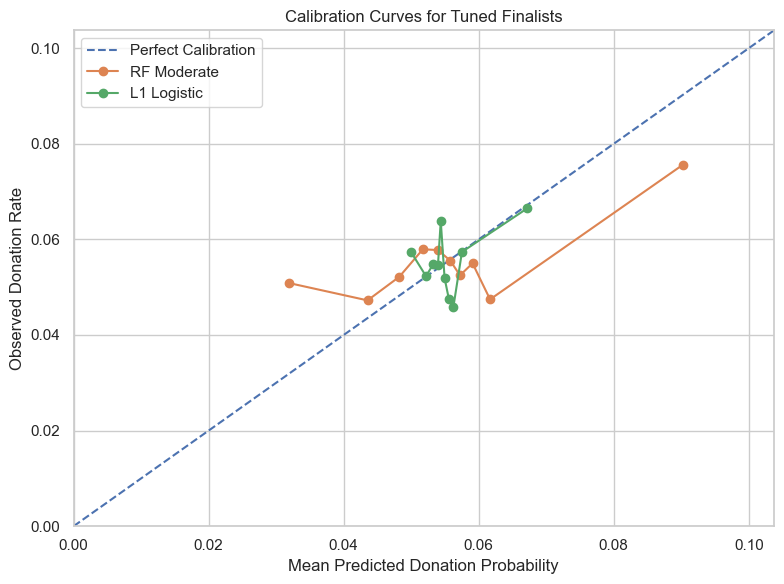

In [74]:
# Plot calibration curves for tuned finalists

maximum_curve_value = max(
    max(
        np.max(
            curve[
                "observed_probability"
            ]
        ),
        np.max(
            curve[
                "predicted_probability"
            ]
        ),
    )
    for curve
    in uncalibrated_calibration_curves.values()
)

calibration_plot_limit = min(
    1.0,
    max(
        0.10,
        maximum_curve_value * 1.15,
    ),
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    [
        0,
        calibration_plot_limit,
    ],
    [
        0,
        calibration_plot_limit,
    ],
    linestyle="--",
    label="Perfect Calibration",
)

for (
    model_name,
    curve,
) in uncalibrated_calibration_curves.items():
    plt.plot(
        curve[
            "predicted_probability"
        ],
        curve[
            "observed_probability"
        ],
        marker="o",
        label=model_name,
    )

plt.xlabel(
    "Mean Predicted Donation Probability"
)

plt.ylabel(
    "Observed Donation Rate"
)

plt.title(
    "Calibration Curves for Tuned Finalists"
)

plt.xlim(
    0,
    calibration_plot_limit,
)

plt.ylim(
    0,
    calibration_plot_limit,
)

plt.legend()
plt.tight_layout()
plt.show()

In [75]:
# Evaluate calibration methods for finalist needing calibration
def get_tuning_configuration(
    model_name,
    configuration_id,
):
    matching_configurations = [
        configuration
        for configuration
        in model_tuning_configurations[
            model_name
        ]
        if configuration[
            "configuration_id"
        ] == configuration_id
    ]

    if len(
        matching_configurations
    ) != 1:
        raise AssertionError(
            "Expected exactly one tuning "
            f"configuration for {model_name} — "
            f"{configuration_id}."
        )

    return matching_configurations[0]


def evaluate_calibration_fold(
    model_name,
    configuration,
    feature_columns,
    calibration_method,
    fold_number,
    train_indices,
    validation_indices,
):
    base_pipeline = build_tuning_pipeline(
        model_name=model_name,
        configuration=configuration,
        feature_columns=feature_columns,
    )

    inner_calibration_cv = (
        StratifiedKFold(
            n_splits=CALIBRATION_INNER_FOLDS,
            shuffle=True,
            random_state=(
                RANDOM_STATE
                + fold_number
            ),
        )
    )

    calibrated_pipeline = (
        CalibratedClassifierCV(
            estimator=base_pipeline,
            method=calibration_method,
            cv=inner_calibration_cv,
            n_jobs=1,
            ensemble=True,
        )
    )

    fold_features_train = (
        features_primary_development[
            feature_columns
        ].iloc[train_indices]
    )

    fold_target_train = (
        target_primary_development.iloc[
            train_indices
        ]
    )

    fold_features_validation = (
        features_primary_development[
            feature_columns
        ].iloc[validation_indices]
    )

    fold_target_validation = (
        target_primary_development.iloc[
            validation_indices
        ]
    )

    fit_start_time = (
        time.perf_counter()
    )

    calibrated_pipeline.fit(
        fold_features_train,
        fold_target_train,
    )

    fit_seconds = (
        time.perf_counter()
        - fit_start_time
    )

    validation_probability_positive = (
        calibrated_pipeline.predict_proba(
            fold_features_validation
        )[:, 1]
    )

    return {
        "model": model_name,
        "configuration_id": (
            configuration[
                "configuration_id"
            ]
        ),
        "calibration_method": (
            calibration_method
        ),
        "fold": fold_number,
        "validation_indices": (
            validation_indices
        ),
        "validation_size": len(
            validation_indices
        ),
        "probability_positive": (
            validation_probability_positive
        ),
        "pr_auc": (
            average_precision_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "brier_score": (
            brier_score_loss(
                fold_target_validation,
                validation_probability_positive,
            )
        ),
        "fit_seconds": fit_seconds,
    }


models_requiring_calibration = (
    uncalibrated_calibration_summary.loc[
        uncalibrated_calibration_summary[
            "calibration_needed"
        ],
        "model",
    ].tolist()
)

calibration_cv_results = []

if models_requiring_calibration:
    print(
        "Calibration methods will be evaluated "
        "for:"
    )

    for model_name in (
        models_requiring_calibration
    ):
        print(
            f"- {model_name}"
        )

    for model_name in (
        models_requiring_calibration
    ):
        calibration_spec = (
            tuned_calibration_specs[
                model_name
            ]
        )

        configuration = (
            get_tuning_configuration(
                model_name=model_name,
                configuration_id=(
                    calibration_spec[
                        "configuration_id"
                    ]
                ),
            )
        )

        feature_columns = (
            calibration_spec[
                "feature_columns"
            ]
        )

        for calibration_method in (
            calibration_methods
        ):
            print(
                f"Running {model_name} — "
                f"{calibration_method} calibration..."
            )

            method_start_time = (
                time.perf_counter()
            )

            with joblib.parallel_config(
                backend="loky",
                inner_max_num_threads=1,
            ):
                method_results = (
                    joblib.Parallel(
                        n_jobs=(
                            CALIBRATION_PARALLEL_JOBS
                        ),
                        pre_dispatch=(
                            CALIBRATION_PARALLEL_JOBS
                        ),
                        batch_size=1,
                    )(
                        joblib.delayed(
                            evaluate_calibration_fold
                        )(
                            model_name,
                            configuration,
                            feature_columns,
                            calibration_method,
                            fold_number,
                            train_indices,
                            validation_indices,
                        )
                        for fold_number, (
                            train_indices,
                            validation_indices,
                        ) in enumerate(
                            primary_cv_splits,
                            start=1,
                        )
                    )
                )

            calibration_cv_results.extend(
                method_results
            )

            method_elapsed_seconds = (
                time.perf_counter()
                - method_start_time
            )

            print(
                f"Completed {model_name} — "
                f"{calibration_method} in "
                f"{method_elapsed_seconds:.1f} "
                f"seconds."
            )

else:
    print(
        "No tuned finalist met the calibration "
        "trigger criteria."
    )

    print(
        "No calibration models were fitted."
    )

No tuned finalist met the calibration trigger criteria.
No calibration models were fitted.


In [76]:
# Compare calibrated and uncalibrated probability versions
calibration_comparison_records = []
calibrated_oof_probabilities = {}

for (
    model_name,
    calibration_spec,
) in tuned_calibration_specs.items():

    configuration_id = (
        calibration_spec[
            "configuration_id"
        ]
    )

    baseline_row = (
        uncalibrated_calibration_summary.loc[
            uncalibrated_calibration_summary[
                "model"
            ].eq(model_name)
        ].iloc[0]
    )

    baseline_probabilities = (
        model_tuning_oof_probabilities[
            (
                model_name,
                configuration_id,
            )
        ]
    )

    baseline_cv_pr_auc = (
        model_tuning_results.loc[
            (
                model_tuning_results[
                    "model"
                ].eq(model_name)
            )
            & (
                model_tuning_results[
                    "configuration_id"
                ].eq(configuration_id)
            ),
            "cv_pr_auc_mean",
        ].iloc[0]
    )

    calibration_comparison_records.append({
        "model": model_name,
        "probability_version": (
            "Uncalibrated"
        ),
        "cv_pr_auc_mean": (
            baseline_cv_pr_auc
        ),
        "oof_pr_auc": (
            baseline_row["oof_pr_auc"]
        ),
        "oof_roc_auc": (
            baseline_row["oof_roc_auc"]
        ),
        "brier_score": (
            baseline_row["brier_score"]
        ),
        "expected_calibration_error": (
            baseline_row[
                "expected_calibration_error"
            ]
        ),
        "maximum_absolute_bin_gap": (
            baseline_row[
                "maximum_absolute_bin_gap"
            ]
        ),
        "mean_probability_bias": (
            baseline_row[
                "mean_probability_bias"
            ]
        ),
        "brier_change_vs_uncalibrated": 0.0,
        "ece_change_vs_uncalibrated": 0.0,
        "pr_auc_change_vs_uncalibrated": 0.0,
        "eligible_calibration_improvement": (
            True
        ),
    })

    if model_name not in (
        models_requiring_calibration
    ):
        continue

    for calibration_method in (
        calibration_methods
    ):
        method_results = sorted(
            [
                result
                for result
                in calibration_cv_results
                if (
                    result["model"]
                    == model_name
                    and result[
                        "calibration_method"
                    ] == calibration_method
                )
            ],
            key=lambda result: result["fold"],
        )

        calibrated_probability_positive = (
            np.full(
                len(
                    target_primary_development
                ),
                np.nan,
                dtype=float,
            )
        )

        for fold_result in method_results:
            calibrated_probability_positive[
                fold_result[
                    "validation_indices"
                ]
            ] = fold_result[
                "probability_positive"
            ]

        if np.isnan(
            calibrated_probability_positive
        ).any():
            raise AssertionError(
                "Incomplete calibrated OOF "
                f"probabilities for {model_name} "
                f"with {calibration_method}."
            )

        calibrated_bins = (
            create_probability_bin_summary(
                target_true=(
                    target_primary_development
                ),
                probability_positive=(
                    calibrated_probability_positive
                ),
                bin_count=(
                    CALIBRATION_BIN_COUNT
                ),
            )
        )

        calibrated_ece = (
            (
                calibrated_bins[
                    "absolute_calibration_gap"
                ]
                * calibrated_bins[
                    "bin_weight"
                ]
            ).sum()
        )

        calibrated_max_gap = (
            calibrated_bins[
                "absolute_calibration_gap"
            ].max()
        )

        calibrated_brier = (
            brier_score_loss(
                target_primary_development,
                calibrated_probability_positive,
            )
        )

        calibrated_oof_pr_auc = (
            average_precision_score(
                target_primary_development,
                calibrated_probability_positive,
            )
        )

        calibrated_oof_roc_auc = (
            roc_auc_score(
                target_primary_development,
                calibrated_probability_positive,
            )
        )

        calibrated_cv_pr_auc = np.mean([
            result["pr_auc"]
            for result in method_results
        ])

        mean_probability_bias = (
            np.mean(
                calibrated_probability_positive
            )
            - development_positive_rate
        )

        brier_change = (
            calibrated_brier
            - baseline_row[
                "brier_score"
            ]
        )

        ece_change = (
            calibrated_ece
            - baseline_row[
                "expected_calibration_error"
            ]
        )

        pr_auc_change = (
            calibrated_cv_pr_auc
            - baseline_cv_pr_auc
        )

        eligible_improvement = (
            brier_change
            <= -MIN_BRIER_IMPROVEMENT
            and ece_change < 0
            and pr_auc_change
            >= -MAX_PR_AUC_DEGRADATION
        )

        calibrated_oof_probabilities[
            (
                model_name,
                calibration_method,
            )
        ] = (
            calibrated_probability_positive
        )

        calibration_comparison_records.append({
            "model": model_name,
            "probability_version": (
                calibration_method.title()
            ),
            "cv_pr_auc_mean": (
                calibrated_cv_pr_auc
            ),
            "oof_pr_auc": (
                calibrated_oof_pr_auc
            ),
            "oof_roc_auc": (
                calibrated_oof_roc_auc
            ),
            "brier_score": (
                calibrated_brier
            ),
            "expected_calibration_error": (
                calibrated_ece
            ),
            "maximum_absolute_bin_gap": (
                calibrated_max_gap
            ),
            "mean_probability_bias": (
                mean_probability_bias
            ),
            "brier_change_vs_uncalibrated": (
                brier_change
            ),
            "ece_change_vs_uncalibrated": (
                ece_change
            ),
            "pr_auc_change_vs_uncalibrated": (
                pr_auc_change
            ),
            "eligible_calibration_improvement": (
                eligible_improvement
            ),
        })

probability_calibration_comparison = (
    pd.DataFrame(
        calibration_comparison_records
    )
)

selected_probability_records = []

for model_name in (
    tuned_calibration_specs
):
    model_results = (
        probability_calibration_comparison.loc[
            probability_calibration_comparison[
                "model"
            ].eq(model_name)
        ]
    )

    eligible_calibrated_results = (
        model_results.loc[
            (
                model_results[
                    "probability_version"
                ].ne("Uncalibrated")
            )
            & (
                model_results[
                    "eligible_calibration_improvement"
                ]
            )
        ]
        .sort_values(
            [
                "brier_score",
                "expected_calibration_error",
                "cv_pr_auc_mean",
            ],
            ascending=[
                True,
                True,
                False,
            ],
        )
    )

    if eligible_calibrated_results.empty:
        selected_row = (
            model_results.loc[
                model_results[
                    "probability_version"
                ].eq("Uncalibrated")
            ].iloc[0]
        )

    else:
        selected_row = (
            eligible_calibrated_results.iloc[0]
        )

    selected_probability_records.append(
        selected_row.to_dict()
    )

selected_probability_versions = (
    pd.DataFrame(
        selected_probability_records
    )
    .sort_values(
        "cv_pr_auc_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    probability_calibration_comparison
    .sort_values(
        [
            "model",
            "brier_score",
        ]
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "probability_version",
        ],
        **{"text-align": "left"}
    )
    .format({
        "cv_pr_auc_mean": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "oof_roc_auc": "{:.4f}",
        "brier_score": "{:.4f}",
        "expected_calibration_error": (
            "{:.4f}"
        ),
        "maximum_absolute_bin_gap": (
            "{:.4f}"
        ),
        "mean_probability_bias": (
            "{:+.4f}"
        ),
        "brier_change_vs_uncalibrated": (
            "{:+.4f}"
        ),
        "ece_change_vs_uncalibrated": (
            "{:+.4f}"
        ),
        "pr_auc_change_vs_uncalibrated": (
            "{:+.4f}"
        ),
        "eligible_calibration_improvement": (
            lambda value: str(value)
        ),
    })
)

print(
    "\nSelected probability versions:"
)

for _, row in (
    selected_probability_versions.iterrows()
):
    print(
        f"{row['model']}: "
        f"{row['probability_version']} "
        f"(Brier {row['brier_score']:.4f}, "
        f"ECE "
        f"{row['expected_calibration_error']:.4f}, "
        f"CV PR AUC "
        f"{row['cv_pr_auc_mean']:.4f})."
    )

model,probability_version,cv_pr_auc_mean,oof_pr_auc,oof_roc_auc,brier_score,expected_calibration_error,maximum_absolute_bin_gap,mean_probability_bias,brier_change_vs_uncalibrated,ece_change_vs_uncalibrated,pr_auc_change_vs_uncalibrated,eligible_calibration_improvement
L1 Logistic,Uncalibrated,0.0766,0.0734,0.5051,0.0518,0.0042,0.0104,+0.0002,+0.0000,+0.0000,+0.0000,True
RF Moderate,Uncalibrated,0.0786,0.0763,0.5228,0.0519,0.0073,0.0189,-0.0001,+0.0000,+0.0000,+0.0000,True



Selected probability versions:
RF Moderate: Uncalibrated (Brier 0.0519, ECE 0.0073, CV PR AUC 0.0786).
L1 Logistic: Uncalibrated (Brier 0.0518, ECE 0.0042, CV PR AUC 0.0766).


In [77]:
# Validate probability calibration evaluation
expected_calibration_fit_count = (
    len(
        models_requiring_calibration
    )
    * len(
        calibration_methods
    )
    * CV_FOLDS
)

all_probability_bin_counts_valid = all(
    probability_bins[
        "record_count"
    ].sum()
    == len(
        target_primary_development
    )
    for probability_bins
    in uncalibrated_probability_bins.values()
)

all_calibrated_validation_sizes_preserved = (
    all(
        result["validation_size"]
        == len(
            primary_cv_splits[
                result["fold"] - 1
            ][1]
        )
        for result
        in calibration_cv_results
    )
    if calibration_cv_results
    else True
)

calibration_application_valid = all(
    (
        model_name
        in models_requiring_calibration
    )
    for model_name, _
    in calibrated_oof_probabilities
)

selected_versions_valid = all(
    (
        row[
            "probability_version"
        ] == "Uncalibrated"
    )
    or bool(
        row[
            "eligible_calibration_improvement"
        ]
    )
    for _, row
    in selected_probability_versions.iterrows()
)

calibration_evaluation_validation = (
    pd.DataFrame({
        "validation_check": [
            "Tuned finalist count",
            "Probability bin count configured",
            "All uncalibrated OOF probabilities complete",
            "All probability bin summaries cover development data",
            "All uncalibrated probabilities between 0 and 1",
            "Brier scores available for both finalists",
            "Calibration error available for both finalists",
            "Calibration decision recorded for both finalists",
            "Calibration methods limited to flagged models",
            "Calibration cross validation fit count",
            "Calibrated validation fold sizes remained unchanged",
            "Selected probability version count",
            "Calibrated version selected only when improvement criteria pass",
            "Same outer cross validation folds retained",
            "Calibration used development data only",
            "Final test set remained unused",
        ],
        "expected": [
            2,
            10,
            len(
                target_primary_development
            ),
            "True",
            "True",
            "True",
            "True",
            2,
            "True",
            expected_calibration_fit_count,
            "True",
            2,
            "True",
            CV_FOLDS,
            "True",
            "True",
        ],
        "actual": [
            len(
                tuned_calibration_specs
            ),
            CALIBRATION_BIN_COUNT,
            min(
                len(
                    model_tuning_oof_probabilities[
                        (
                            model_name,
                            calibration_spec[
                                "configuration_id"
                            ],
                        )
                    ]
                )
                for (
                    model_name,
                    calibration_spec,
                )
                in tuned_calibration_specs.items()
            ),
            str(
                all_probability_bin_counts_valid
            ),
            str(all(
                np.all(
                    (
                        model_tuning_oof_probabilities[
                            (
                                model_name,
                                calibration_spec[
                                    "configuration_id"
                                ],
                            )
                        ]
                        >= 0
                    )
                    & (
                        model_tuning_oof_probabilities[
                            (
                                model_name,
                                calibration_spec[
                                    "configuration_id"
                                ],
                            )
                        ]
                        <= 1
                    )
                )
                for (
                    model_name,
                    calibration_spec,
                )
                in tuned_calibration_specs.items()
            )),
            str(
                uncalibrated_calibration_summary[
                    "brier_score"
                ].notna().all()
            ),
            str(
                uncalibrated_calibration_summary[
                    "expected_calibration_error"
                ].notna().all()
            ),
            len(
                uncalibrated_calibration_summary
            ),
            str(
                calibration_application_valid
            ),
            len(
                calibration_cv_results
            ),
            str(
                all_calibrated_validation_sizes_preserved
            ),
            len(
                selected_probability_versions
            ),
            str(
                selected_versions_valid
            ),
            len(
                primary_cv_splits
            ),
            "True",
            "True",
        ],
    })
)

calibration_evaluation_validation[
    "passed"
] = [
    len(
        tuned_calibration_specs
    ) == 2,
    CALIBRATION_BIN_COUNT == 10,
    all(
        len(
            model_tuning_oof_probabilities[
                (
                    model_name,
                    calibration_spec[
                        "configuration_id"
                    ],
                )
            ]
        )
        == len(
            target_primary_development
        )
        for (
            model_name,
            calibration_spec,
        )
        in tuned_calibration_specs.items()
    ),
    all_probability_bin_counts_valid,
    all(
        np.all(
            (
                model_tuning_oof_probabilities[
                    (
                        model_name,
                        calibration_spec[
                            "configuration_id"
                        ],
                    )
                ]
                >= 0
            )
            & (
                model_tuning_oof_probabilities[
                    (
                        model_name,
                        calibration_spec[
                            "configuration_id"
                        ],
                    )
                ]
                <= 1
            )
        )
        for (
            model_name,
            calibration_spec,
        )
        in tuned_calibration_specs.items()
    ),
    uncalibrated_calibration_summary[
        "brier_score"
    ].notna().all(),
    uncalibrated_calibration_summary[
        "expected_calibration_error"
    ].notna().all(),
    len(
        uncalibrated_calibration_summary
    ) == 2,
    calibration_application_valid,
    len(
        calibration_cv_results
    ) == expected_calibration_fit_count,
    all_calibrated_validation_sizes_preserved,
    len(
        selected_probability_versions
    ) == 2,
    selected_versions_valid,
    len(
        primary_cv_splits
    ) == CV_FOLDS,
    True,
    True,
]

display(
    calibration_evaluation_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_calibration_checks = (
    calibration_evaluation_validation.loc[
        ~calibration_evaluation_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_calibration_checks:
    raise AssertionError(
        "Probability calibration validation "
        "failed for: "
        + ", ".join(
            failed_calibration_checks
        )
    )

print(
    "Probability calibration evaluation "
    "validated."
)

if models_requiring_calibration:
    print(
        "Calibration methods were tested only "
        "for finalists flagged by the initial "
        "development diagnostics."
    )
else:
    print(
        "Calibration was not applied because "
        "neither finalist met the predefined "
        "calibration trigger criteria."
    )

print(
    "The final test set remains untouched."
)

validation_check,expected,actual,passed
Tuned finalist count,2,2,True
Probability bin count configured,10,10,True
All uncalibrated OOF probabilities complete,"27,522","27,522",True
All probability bin summaries cover development data,True,True,True
All uncalibrated probabilities between 0 and 1,True,True,True
Brier scores available for both finalists,True,True,True
Calibration error available for both finalists,True,True,True
Calibration decision recorded for both finalists,2,2,True
Calibration methods limited to flagged models,True,True,True
Calibration cross validation fit count,0,0,True


Probability calibration evaluation validated.
Calibration was not applied because neither finalist met the predefined calibration trigger criteria.
The final test set remains untouched.


## Probability Calibration

The tuned finalist models were evaluated to determine whether their predicted probabilities corresponded reasonably to observed donation rates before applying any additional calibration method.

Calibration was assessed using:

- calibration curves,
- Brier scores,
- probability bin summaries,
- expected calibration error,
- maximum absolute bin calibration gap,
- and mean probability bias.

The evaluation used only out of fold predictions from the development data. The final test set remained untouched.

The development set positive rate was 5.53%, and a prior probability model that assigned this same probability to every record produced a Brier score of 0.0523.

### Overall Calibration Results

| Model | Mean Predicted Probability | Observed Positive Rate | Mean Bias | Brier Score | ECE | Maximum Bin Gap | Calibration Needed |
|---|---:|---:|---:|---:|---:|---:|---|
| RF Moderate | 0.0553 | 0.0553 | -0.0001 | 0.0519 | 0.0073 | 0.0189 | No |
| L1 Logistic | 0.0555 | 0.0553 | +0.0002 | 0.0518 | 0.0042 | 0.0104 | No |

Both models produced mean predicted probabilities that closely matched the observed development donation rate.

RF Moderate predicted an average donation probability of approximately 5.53%, while L1 Logistic predicted approximately 5.55%, compared with the actual rate of 5.53%.

This indicates that neither model showed meaningful overall probability bias.

### L1 Logistic Calibration

L1 Logistic produced the stronger overall calibration diagnostics.

Its expected calibration error was 0.0042, and its maximum absolute probability bin gap was 0.0104. Its mean probability bias was only +0.0002.

The Brier score was 0.0518, which improved slightly on the prior probability Brier score of 0.0523.

Across the probability bins, predicted probabilities generally remained close to observed donation rates. The largest difference occurred in a bin with a mean predicted probability of approximately 5.63% and an observed donation rate of approximately 4.59%, producing a gap of about 1.04 percentage points.

L1 probabilities were relatively concentrated around the overall donation rate. Most probability bins had mean predicted probabilities between approximately 5.0% and 5.8%, while the highest probability bin had a mean prediction of approximately 6.72% and an observed donation rate of approximately 6.65%.

This indicates relatively stable probability estimates, although the narrow probability range is also consistent with the weaker ranking separation previously observed for the linear model.

### Random Forest Calibration

RF Moderate showed somewhat greater variation across probability bins.

Its expected calibration error was 0.0073, and the maximum absolute bin gap was 0.0189. Its overall mean probability bias remained effectively zero at -0.0001.

The Brier score was 0.0519, also slightly better than the prior probability baseline of 0.0523.

The largest calibration difference occurred in the lowest probability bin:

- mean predicted probability: approximately 3.19%
- observed donation rate: approximately 5.09%
- calibration gap: approximately +1.89 percentage points

The Random Forest also showed some overprediction in the upper probability bins. For example:

- the ninth probability bin predicted approximately 6.17% while the observed donation rate was approximately 4.74%,
- the highest probability bin predicted approximately 9.02% while the observed donation rate was approximately 7.56%.

Despite this local variation, the highest probability bin still had a substantially higher observed donation rate than the overall development rate of 5.53%. This supports the Random Forest's usefulness for ranking higher likelihood donors even though its absolute probability estimates are somewhat less smooth than those of L1 Logistic.

### Calibration Curves

The calibration curves reinforced the probability bin results.

L1 Logistic remained relatively close to the perfect calibration reference line across most of its probability range.

Random Forest showed greater movement above and below the reference line, particularly in the lower and upper probability ranges. However, the deviations were not large enough to indicate severe systematic miscalibration.

The Random Forest also produced a broader probability range than L1 Logistic. This greater probability spread is consistent with its stronger PR AUC and ranking performance, while L1 Logistic produced more compressed but slightly better calibrated probabilities.

### Brier Score Comparison

Both tuned finalists improved slightly on the prior probability benchmark:

| Probability Model | Brier Score |
|---|---:|
| Prior Probability | 0.0523 |
| RF Moderate | 0.0519 |
| L1 Logistic | 0.0518 |

L1 Logistic produced the lowest Brier score, while Random Forest remained very close.

These results indicate that neither finalist showed an obvious deterioration in probability accuracy compared with simply assigning the overall donor prevalence to every record.

### Calibration Decision

Calibration methods were configured to be tested only when the initial development diagnostics showed sufficient evidence of miscalibration.

The predefined diagnostics considered:

- mean probability bias,
- expected calibration error,
- and maximum probability bin gap.

A model needed to trigger at least two calibration conditions before sigmoid or isotonic calibration would be evaluated.

L1 Logistic triggered zero calibration conditions.

Random Forest triggered one condition because its expected calibration error exceeded the predefined threshold, but its mean probability bias and maximum bin gap remained within the acceptable ranges.

Therefore, neither finalist met the criteria required to justify fitting an additional calibration model.

No sigmoid or isotonic calibration models were fitted.

The selected probability versions remain:

- RF Moderate: Uncalibrated
- L1 Logistic: Uncalibrated

This avoids adding unnecessary model complexity when the existing development probabilities already show reasonable calibration.

### Probability Calibration Conclusion

L1 Logistic produced slightly stronger probability calibration, with lower expected calibration error, a smaller maximum bin gap, and a slightly lower Brier score.

Random Forest showed somewhat greater local calibration variation but maintained almost no overall probability bias and continued to provide stronger ranking performance.

The calibration results therefore reinforce an important tradeoff between the finalists:

- L1 Logistic provides slightly better probability calibration and simpler probability behavior.
- Random Forest provides stronger donor ranking performance with somewhat greater calibration variation.

Neither model showed enough evidence of miscalibration to justify an additional calibration layer.

All probability summaries covered the full development set, all out of fold probabilities were valid, the same five outer cross validation folds were retained, no unnecessary calibration fits were performed, and the final test set remained unused.

In [78]:
# Prepare finalist probabilities for outreach capacity evaluation
campaign_capacities = list(
    CAMPAIGN_CAPACITIES
)

selected_finalist_oof_probabilities = {}

for _, row in (
    selected_probability_versions.iterrows()
):
    model_name = row["model"]

    probability_version = (
        row["probability_version"]
    )

    configuration_id = (
        tuned_calibration_specs[
            model_name
        ]["configuration_id"]
    )

    if probability_version == "Uncalibrated":
        probability_positive = (
            model_tuning_oof_probabilities[
                (
                    model_name,
                    configuration_id,
                )
            ]
        ).copy()

    else:
        calibration_method = (
            probability_version.lower()
        )

        probability_positive = (
            calibrated_oof_probabilities[
                (
                    model_name,
                    calibration_method,
                )
            ]
        ).copy()

    selected_finalist_oof_probabilities[
        model_name
    ] = probability_positive

development_record_count = len(
    target_primary_development
)

development_donor_count = int(
    target_primary_development.sum()
)

development_donor_rate = (
    target_primary_development.mean()
)

print(
    f"Development records: "
    f"{development_record_count:,}"
)

print(
    f"Development donors: "
    f"{development_donor_count:,}"
)

print(
    f"Development donor rate: "
    f"{development_donor_rate:.2%}"
)

print(
    "Campaign capacities: "
    + ", ".join(
        f"{capacity:.0%}"
        for capacity
        in campaign_capacities
    )
)

Development records: 27,522
Development donors: 1,523
Development donor rate: 5.53%
Campaign capacities: 1%, 5%, 10%, 20%


In [79]:
# Evaluate finalist rankings at each outreach capacity
def calculate_outreach_scenario_metrics(
    target_true,
    probability_positive,
    capacities,
):
    target_array = np.asarray(
        target_true,
        dtype=int,
    )

    probability_array = np.asarray(
        probability_positive,
        dtype=float,
    )

    record_count = len(
        target_array
    )

    donor_count = int(
        target_array.sum()
    )

    donor_rate = (
        donor_count
        / record_count
    )

    ranked_indices = np.argsort(
        -probability_array,
        kind="mergesort",
    )

    outreach_records = []

    for capacity in capacities:
        contacted_count = int(
            np.ceil(
                record_count
                * capacity
            )
        )

        contacted_indices = (
            ranked_indices[
                :contacted_count
            ]
        )

        donors_captured = int(
            target_array[
                contacted_indices
            ].sum()
        )

        donor_recall = (
            donors_captured
            / donor_count
        )

        outreach_precision = (
            donors_captured
            / contacted_count
        )

        lift_over_random = (
            outreach_precision
            / donor_rate
        )

        expected_random_donors = (
            contacted_count
            * donor_rate
        )

        outreach_records.append({
            "campaign_capacity": (
                capacity
            ),
            "individuals_contacted": (
                contacted_count
            ),
            "actual_donors_captured": (
                donors_captured
            ),
            "recall_among_all_donors": (
                donor_recall
            ),
            "precision_selected_group": (
                outreach_precision
            ),
            "lift_over_random": (
                lift_over_random
            ),
            "expected_random_donors": (
                expected_random_donors
            ),
        })

    return pd.DataFrame(
        outreach_records
    )


outreach_capacity_records = []

for (
    model_name,
    probability_positive,
) in (
    selected_finalist_oof_probabilities.items()
):
    model_outreach_results = (
        calculate_outreach_scenario_metrics(
            target_true=(
                target_primary_development
            ),
            probability_positive=(
                probability_positive
            ),
            capacities=(
                campaign_capacities
            ),
        )
    )

    probability_version = (
        selected_probability_versions.loc[
            selected_probability_versions[
                "model"
            ].eq(model_name),
            "probability_version",
        ].iloc[0]
    )

    model_outreach_results.insert(
        0,
        "probability_version",
        probability_version,
    )

    model_outreach_results.insert(
        0,
        "model",
        model_name,
    )

    outreach_capacity_records.append(
        model_outreach_results
    )

outreach_capacity_results = (
    pd.concat(
        outreach_capacity_records,
        ignore_index=True,
    )
    .sort_values(
        [
            "campaign_capacity",
            "model",
        ]
    )
    .reset_index(drop=True)
)

display(outreach_capacity_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "probability_version",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "campaign_capacity": "{:.0%}",
        "individuals_contacted": "{:,.0f}",
        "actual_donors_captured": "{:,.0f}",
        "recall_among_all_donors": "{:.2%}",
        "precision_selected_group": "{:.2%}",
        "lift_over_random": "{:.2f}×",
        "expected_random_donors": "{:,.1f}",
    })
)

model,probability_version,campaign_capacity,individuals_contacted,actual_donors_captured,recall_among_all_donors,precision_selected_group,lift_over_random,expected_random_donors
L1 Logistic,Uncalibrated,1%,276,36,2.36%,13.04%,2.36×,15.3
RF Moderate,Uncalibrated,1%,276,46,3.02%,16.67%,3.01×,15.3
L1 Logistic,Uncalibrated,5%,"1,377",110,7.22%,7.99%,1.44×,76.2
RF Moderate,Uncalibrated,5%,"1,377",114,7.49%,8.28%,1.50×,76.2
L1 Logistic,Uncalibrated,10%,"2,753",183,12.02%,6.65%,1.20×,152.3
RF Moderate,Uncalibrated,10%,"2,753",208,13.66%,7.56%,1.37×,152.3
L1 Logistic,Uncalibrated,20%,"5,505",341,22.39%,6.19%,1.12×,304.6
RF Moderate,Uncalibrated,20%,"5,505",340,22.32%,6.18%,1.12×,304.6


In [80]:
# Combine statistical and outreach performance for finalist selection
outreach_capacity_results[
    "best_lift_at_capacity"
] = (
    outreach_capacity_results
    .groupby(
        "campaign_capacity"
    )[
        "lift_over_random"
    ]
    .transform("max")
)

outreach_capacity_results[
    "capacity_scenario_winner"
] = np.isclose(
    outreach_capacity_results[
        "lift_over_random"
    ],
    outreach_capacity_results[
        "best_lift_at_capacity"
    ],
    atol=1e-12,
)

outreach_model_summary = (
    outreach_capacity_results
    .groupby(
        "model",
        as_index=False,
    )
    .agg(
        mean_outreach_lift=(
            "lift_over_random",
            "mean",
        ),
        capacity_scenario_wins=(
            "capacity_scenario_winner",
            "sum",
        ),
    )
)

for capacity in campaign_capacities:
    capacity_label = (
        f"{int(capacity * 100)}pct"
    )

    capacity_results = (
        outreach_capacity_results.loc[
            outreach_capacity_results[
                "campaign_capacity"
            ].eq(capacity),
            [
                "model",
                "actual_donors_captured",
                "recall_among_all_donors",
                "precision_selected_group",
                "lift_over_random",
            ],
        ]
        .rename(columns={
            "actual_donors_captured": (
                f"donors_captured_"
                f"{capacity_label}"
            ),
            "recall_among_all_donors": (
                f"recall_"
                f"{capacity_label}"
            ),
            "precision_selected_group": (
                f"precision_"
                f"{capacity_label}"
            ),
            "lift_over_random": (
                f"lift_"
                f"{capacity_label}"
            ),
        })
    )

    outreach_model_summary = (
        outreach_model_summary.merge(
            capacity_results,
            on="model",
            how="left",
            validate="one_to_one",
        )
    )

training_complexity_lookup = (
    finalist_model_shortlist
    .set_index(
        "model_configuration"
    )[
        "training_complexity"
    ]
    .to_dict()
)

finalist_selection_records = []

for _, probability_row in (
    selected_probability_versions.iterrows()
):
    model_name = (
        probability_row["model"]
    )

    tuning_row = (
        tuned_model_finalists.loc[
            tuned_model_finalists[
                "model"
            ].eq(model_name)
        ].iloc[0]
    )

    outreach_row = (
        outreach_model_summary.loc[
            outreach_model_summary[
                "model"
            ].eq(model_name)
        ].iloc[0]
    )

    finalist_selection_records.append({
        "model": model_name,
        "configuration_id": (
            tuning_row[
                "configuration_id"
            ]
        ),
        "probability_version": (
            probability_row[
                "probability_version"
            ]
        ),
        "mean_cv_pr_auc": (
            tuning_row[
                "cv_pr_auc_mean"
            ]
        ),
        "cv_pr_auc_std": (
            tuning_row[
                "cv_pr_auc_std"
            ]
        ),
        "cv_pr_auc_gap": (
            tuning_row[
                "cv_pr_auc_gap"
            ]
        ),
        "roc_auc": (
            probability_row[
                "oof_roc_auc"
            ]
        ),
        "brier_score": (
            probability_row[
                "brier_score"
            ]
        ),
        "expected_calibration_error": (
            probability_row[
                "expected_calibration_error"
            ]
        ),
        "mean_outreach_lift": (
            outreach_row[
                "mean_outreach_lift"
            ]
        ),
        "capacity_scenario_wins": int(
            outreach_row[
                "capacity_scenario_wins"
            ]
        ),
        "donors_captured_1pct": (
            outreach_row[
                "donors_captured_1pct"
            ]
        ),
        "lift_1pct": (
            outreach_row[
                "lift_1pct"
            ]
        ),
        "donors_captured_5pct": (
            outreach_row[
                "donors_captured_5pct"
            ]
        ),
        "recall_5pct": (
            outreach_row[
                "recall_5pct"
            ]
        ),
        "precision_5pct": (
            outreach_row[
                "precision_5pct"
            ]
        ),
        "lift_5pct": (
            outreach_row[
                "lift_5pct"
            ]
        ),
        "donors_captured_10pct": (
            outreach_row[
                "donors_captured_10pct"
            ]
        ),
        "recall_10pct": (
            outreach_row[
                "recall_10pct"
            ]
        ),
        "precision_10pct": (
            outreach_row[
                "precision_10pct"
            ]
        ),
        "lift_10pct": (
            outreach_row[
                "lift_10pct"
            ]
        ),
        "donors_captured_20pct": (
            outreach_row[
                "donors_captured_20pct"
            ]
        ),
        "recall_20pct": (
            outreach_row[
                "recall_20pct"
            ]
        ),
        "precision_20pct": (
            outreach_row[
                "precision_20pct"
            ]
        ),
        "lift_20pct": (
            outreach_row[
                "lift_20pct"
            ]
        ),
        "training_complexity": (
            training_complexity_lookup[
                model_name
            ]
        ),
    })

finalist_outreach_comparison = (
    pd.DataFrame(
        finalist_selection_records
    )
)

finalist_outreach_comparison[
    "reported_cv_pr_auc"
] = (
    finalist_outreach_comparison[
        "mean_cv_pr_auc"
    ].round(4)
)

training_complexity_rank = {
    "Low": 1,
    "Moderate": 2,
    "High": 3,
}

finalist_outreach_comparison[
    "training_complexity_rank"
] = (
    finalist_outreach_comparison[
        "training_complexity"
    ].map(
        training_complexity_rank
    )
)

ranked_finalist_candidates = (
    finalist_outreach_comparison
    .sort_values(
        [
            "reported_cv_pr_auc",
            "capacity_scenario_wins",
            "mean_outreach_lift",
            "cv_pr_auc_std",
            "brier_score",
            "training_complexity_rank",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

selected_primary_model_candidate = (
    ranked_finalist_candidates.iloc[0]
)

selected_primary_model_name = (
    selected_primary_model_candidate[
        "model"
    ]
)

selected_primary_configuration_id = (
    selected_primary_model_candidate[
        "configuration_id"
    ]
)

selected_primary_probability_version = (
    selected_primary_model_candidate[
        "probability_version"
    ]
)

display(finalist_outreach_comparison[
    [
        "model",
        "configuration_id",
        "probability_version",
        "mean_cv_pr_auc",
        "cv_pr_auc_std",
        "cv_pr_auc_gap",
        "roc_auc",
        "brier_score",
        "expected_calibration_error",
        "capacity_scenario_wins",
        "mean_outreach_lift",
        "donors_captured_5pct",
        "recall_5pct",
        "precision_5pct",
        "lift_5pct",
        "donors_captured_10pct",
        "recall_10pct",
        "precision_10pct",
        "lift_10pct",
        "donors_captured_20pct",
        "recall_20pct",
        "precision_20pct",
        "lift_20pct",
        "training_complexity",
    ]
].style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "configuration_id",
            "probability_version",
            "training_complexity",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "mean_cv_pr_auc": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "roc_auc": "{:.4f}",
        "brier_score": "{:.4f}",
        "expected_calibration_error": "{:.4f}",
        "capacity_scenario_wins": "{:,.0f}",
        "mean_outreach_lift": "{:.2f}×",
        "donors_captured_5pct": "{:,.0f}",
        "recall_5pct": "{:.2%}",
        "precision_5pct": "{:.2%}",
        "lift_5pct": "{:.2f}×",
        "donors_captured_10pct": "{:,.0f}",
        "recall_10pct": "{:.2%}",
        "precision_10pct": "{:.2%}",
        "lift_10pct": "{:.2f}×",
        "donors_captured_20pct": "{:,.0f}",
        "recall_20pct": "{:.2%}",
        "precision_20pct": "{:.2%}",
        "lift_20pct": "{:.2f}×",
    })
)

print(
    "\nSelected primary model candidate: "
    f"{selected_primary_model_name}"
)

print(
    f"Configuration: "
    f"{selected_primary_configuration_id}"
)

print(
    f"Probability version: "
    f"{selected_primary_probability_version}"
)

model,configuration_id,probability_version,mean_cv_pr_auc,cv_pr_auc_std,cv_pr_auc_gap,roc_auc,brier_score,expected_calibration_error,capacity_scenario_wins,mean_outreach_lift,donors_captured_5pct,recall_5pct,precision_5pct,lift_5pct,donors_captured_10pct,recall_10pct,precision_10pct,lift_10pct,donors_captured_20pct,recall_20pct,precision_20pct,lift_20pct,training_complexity
RF Moderate,rf_depth_14,Uncalibrated,0.0786,0.0047,0.0777,0.5228,0.0519,0.0073,3,1.75×,114,7.49%,8.28%,1.50×,208,13.66%,7.56%,1.37×,340,22.32%,6.18%,1.12×,High
L1 Logistic,l1_c_0_30,Uncalibrated,0.0766,0.0069,0.0018,0.5051,0.0518,0.0042,1,1.53×,110,7.22%,7.99%,1.44×,183,12.02%,6.65%,1.20×,341,22.39%,6.19%,1.12×,Low



Selected primary model candidate: RF Moderate
Configuration: rf_depth_14
Probability version: Uncalibrated


In [81]:
# Validate finalist outreach capacity evaluation
expected_outreach_result_count = (
    len(
        selected_finalist_oof_probabilities
    )
    * len(
        campaign_capacities
    )
)

expected_contact_counts = {
    capacity: int(
        np.ceil(
            development_record_count
            * capacity
        )
    )
    for capacity
    in campaign_capacities
}

contact_counts_match = all(
    row[
        "individuals_contacted"
    ]
    == expected_contact_counts[
        row["campaign_capacity"]
    ]
    for _, row
    in outreach_capacity_results.iterrows()
)

contact_counts_equal_between_models = all(
    group[
        "individuals_contacted"
    ].nunique() == 1
    for _, group
    in outreach_capacity_results.groupby(
        "campaign_capacity"
    )
)

lift_calculation_valid = np.allclose(
    outreach_capacity_results[
        "lift_over_random"
    ],
    (
        outreach_capacity_results[
            "precision_selected_group"
        ]
        / development_donor_rate
    ),
    atol=1e-12,
)

selected_versions_match_calibration_decision = all(
    selected_probability_versions.loc[
        selected_probability_versions[
            "model"
        ].eq(model_name),
        "probability_version",
    ].iloc[0]
    == (
        selected_primary_probability_version
        if model_name
        == selected_primary_model_name
        else selected_probability_versions.loc[
            selected_probability_versions[
                "model"
            ].eq(model_name),
            "probability_version",
        ].iloc[0]
    )
    for model_name
    in selected_finalist_oof_probabilities
)

outreach_evaluation_validation = pd.DataFrame({
    "validation_check": [
        "Finalist model count",
        "Campaign capacity count",
        "Outreach scenario row count",
        "Development record count retained",
        "Development donor count retained",
        "All finalist probabilities complete",
        "All finalist probabilities between 0 and 1",
        "Contact counts match configured capacities",
        "Contact counts equal between finalists",
        "Captured donors do not exceed total donors",
        "Recall values between 0 and 1",
        "Precision values between 0 and 1",
        "Lift values are positive",
        "Lift calculation matches precision divided by donor rate",
        "Selected probability versions retained",
        "Statistical comparison available for both finalists",
        "Outreach comparison available for both finalists",
        "Exactly one primary model candidate selected",
        "No new models fit during outreach evaluation",
        "Final test set remained unused",
    ],
    "expected": [
        2,
        4,
        8,
        len(
            target_primary_development
        ),
        int(
            target_primary_development.sum()
        ),
        len(
            target_primary_development
        ),
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        2,
        2,
        1,
        0,
        "True",
    ],
    "actual": [
        len(
            selected_finalist_oof_probabilities
        ),
        len(
            campaign_capacities
        ),
        len(
            outreach_capacity_results
        ),
        development_record_count,
        development_donor_count,
        min(
            len(probabilities)
            for probabilities
            in selected_finalist_oof_probabilities.values()
        ),
        str(all(
            np.all(
                (probabilities >= 0)
                & (probabilities <= 1)
            )
            for probabilities
            in selected_finalist_oof_probabilities.values()
        )),
        str(
            contact_counts_match
        ),
        str(
            contact_counts_equal_between_models
        ),
        str(
            (
                outreach_capacity_results[
                    "actual_donors_captured"
                ]
                <= development_donor_count
            ).all()
        ),
        str(
            outreach_capacity_results[
                "recall_among_all_donors"
            ].between(
                0,
                1,
            ).all()
        ),
        str(
            outreach_capacity_results[
                "precision_selected_group"
            ].between(
                0,
                1,
            ).all()
        ),
        str(
            outreach_capacity_results[
                "lift_over_random"
            ].gt(0).all()
        ),
        str(
            lift_calculation_valid
        ),
        str(
            selected_versions_match_calibration_decision
        ),
        finalist_outreach_comparison[
            "model"
        ].nunique(),
        outreach_capacity_results[
            "model"
        ].nunique(),
        int(
            pd.notna(
                selected_primary_model_name
            )
        ),
        0,
        "True",
    ],
})

outreach_evaluation_validation[
    "passed"
] = [
    len(
        selected_finalist_oof_probabilities
    ) == 2,
    len(
        campaign_capacities
    ) == 4,
    len(
        outreach_capacity_results
    ) == expected_outreach_result_count,
    development_record_count
    == len(
        target_primary_development
    ),
    development_donor_count
    == int(
        target_primary_development.sum()
    ),
    all(
        len(probabilities)
        == len(
            target_primary_development
        )
        for probabilities
        in selected_finalist_oof_probabilities.values()
    ),
    all(
        np.all(
            (probabilities >= 0)
            & (probabilities <= 1)
        )
        for probabilities
        in selected_finalist_oof_probabilities.values()
    ),
    contact_counts_match,
    contact_counts_equal_between_models,
    (
        outreach_capacity_results[
            "actual_donors_captured"
        ]
        <= development_donor_count
    ).all(),
    outreach_capacity_results[
        "recall_among_all_donors"
    ].between(
        0,
        1,
    ).all(),
    outreach_capacity_results[
        "precision_selected_group"
    ].between(
        0,
        1,
    ).all(),
    outreach_capacity_results[
        "lift_over_random"
    ].gt(0).all(),
    lift_calculation_valid,
    selected_versions_match_calibration_decision,
    finalist_outreach_comparison[
        "model"
    ].nunique() == 2,
    outreach_capacity_results[
        "model"
    ].nunique() == 2,
    pd.notna(
        selected_primary_model_name
    ),
    True,
    True,
]

display(outreach_evaluation_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_outreach_checks = (
    outreach_evaluation_validation.loc[
        ~outreach_evaluation_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_outreach_checks:
    raise AssertionError(
        "Outreach capacity validation failed for: "
        + ", ".join(
            failed_outreach_checks
        )
    )

print(
    "Finalist outreach capacity comparison "
    "validated."
)

print(
    f"Primary model candidate selected for "
    f"threshold analysis: "
    f"{selected_primary_model_name}."
)

print(
    "The final test set remains untouched."
)

validation_check,expected,actual,passed
Finalist model count,2,2,True
Campaign capacity count,4,4,True
Outreach scenario row count,8,8,True
Development record count retained,"27,522","27,522",True
Development donor count retained,"1,523","1,523",True
All finalist probabilities complete,"27,522","27,522",True
All finalist probabilities between 0 and 1,True,True,True
Contact counts match configured capacities,True,True,True
Contact counts equal between finalists,True,True,True
Captured donors do not exceed total donors,True,True,True


Finalist outreach capacity comparison validated.
Primary model candidate selected for threshold analysis: RF Moderate.
The final test set remains untouched.


## Outreach Capacity and Finalist Comparison

The tuned finalists were compared using realistic outreach capacity scenarios to determine how effectively each model ranks likely donors when only a limited portion of the population can be contacted.

The evaluation used the selected uncalibrated out of fold probabilities from the development set. No new models were fitted, and the final test set remained untouched.

The development set contained:

- 27,522 individuals
- 1,523 actual donors
- an overall donor rate of 5.53%

Four campaign capacities were evaluated:

- 1%
- 5%
- 10%
- 20%

Within each capacity, individuals were ranked from highest to lowest predicted donor probability. The evaluation measured the number of people contacted, actual donors captured, recall among all donors, precision within the selected group, and lift over random outreach.

### Outreach Capacity Results

| Model | Capacity | Individuals Contacted | Donors Captured | Recall | Precision | Lift Over Random |
|---|---:|---:|---:|---:|---:|---:|
| L1 Logistic | 1% | 276 | 36 | 2.36% | 13.04% | 2.36× |
| RF Moderate | 1% | 276 | 46 | 3.02% | 16.67% | 3.01× |
| L1 Logistic | 5% | 1,377 | 110 | 7.22% | 7.99% | 1.44× |
| RF Moderate | 5% | 1,377 | 114 | 7.49% | 8.28% | 1.50× |
| L1 Logistic | 10% | 2,753 | 183 | 12.02% | 6.65% | 1.20× |
| RF Moderate | 10% | 2,753 | 208 | 13.66% | 7.56% | 1.37× |
| L1 Logistic | 20% | 5,505 | 341 | 22.39% | 6.19% | 1.12× |
| RF Moderate | 20% | 5,505 | 340 | 22.32% | 6.18% | 1.12× |

Random outreach would be expected to identify donors at approximately the overall development donor rate of 5.53%. Lift values above 1.00 therefore indicate that the model is concentrating more donors into the selected outreach group than random selection would.

### Most Selective Campaign Scenario

At the 1% campaign capacity, each model contacted 276 individuals.

Random outreach would be expected to identify approximately 15 donors from a group of this size.

L1 Logistic captured 36 actual donors, producing:

- recall of 2.36%
- precision of 13.04%
- lift of 2.36×

RF Moderate captured 46 actual donors, producing:

- recall of 3.02%
- precision of 16.67%
- lift of 3.01×

RF Moderate therefore identified approximately three times the donor concentration expected from random outreach in the most selective campaign scenario.

### Five Percent Campaign Capacity

At a 5% outreach capacity, each model contacted 1,377 individuals. Random outreach would be expected to capture approximately 76 donors.

L1 Logistic captured 110 donors, while RF Moderate captured 114.

RF Moderate produced:

- recall of 7.49%
- precision of 8.28%
- lift of 1.50×

L1 Logistic produced:

- recall of 7.22%
- precision of 7.99%
- lift of 1.44×

The difference was smaller than at the 1% capacity, but RF Moderate continued to produce the stronger ranking.

### Ten Percent Campaign Capacity

At a 10% campaign capacity, each model contacted 2,753 individuals. Random outreach would be expected to capture approximately 152 donors.

L1 Logistic captured 183 donors, while RF Moderate captured 208.

RF Moderate therefore captured approximately:

- 25 more donors than L1 Logistic
- 56 more donors than expected from random outreach

Its 10% campaign performance was:

- recall of 13.66%
- precision of 7.56%
- lift of 1.37×

L1 Logistic produced:

- recall of 12.02%
- precision of 6.65%
- lift of 1.20×

This was one of the clearest practical advantages for Random Forest because the same number of outreach contacts resulted in substantially more identified donors.

### Twenty Percent Campaign Capacity

At a 20% campaign capacity, each model contacted 5,505 individuals.

The two models performed almost identically:

- L1 Logistic captured 341 donors
- RF Moderate captured 340 donors

L1 Logistic therefore captured one additional donor and produced a slightly higher underlying lift, although both values rounded to 1.12×.

This suggests that the ranking advantage of Random Forest is strongest at smaller outreach capacities and becomes much less pronounced as a larger share of the population is contacted.

### Overall Outreach Comparison

Across the four campaign capacities:

- RF Moderate produced the stronger lift in three scenarios
- L1 Logistic produced the stronger result in one scenario
- RF Moderate achieved a mean outreach lift of 1.75×
- L1 Logistic achieved a mean outreach lift of 1.53×

Random Forest's strongest advantage occurred at the smaller and more selective campaign capacities, which are particularly relevant when outreach resources are limited.

### Statistical and Business Comparison

The outreach results were evaluated alongside the statistical and probability diagnostics from the preceding modeling stages.

| Metric | RF Moderate | L1 Logistic |
|---|---:|---:|
| Mean CV PR AUC | 0.0786 | 0.0766 |
| CV Variability | 0.0047 | 0.0069 |
| Training to Validation Gap | 0.0777 | 0.0018 |
| ROC AUC | 0.5228 | 0.5051 |
| Brier Score | 0.0519 | 0.0518 |
| Expected Calibration Error | 0.0073 | 0.0042 |
| Capacity Scenario Wins | 3 | 1 |
| Mean Outreach Lift | 1.75× | 1.53× |
| Training Complexity | High | Low |

L1 Logistic retains several advantages. It has much lower training complexity, a very small training to validation gap, and slightly stronger probability calibration.

However, Random Forest provides the stronger primary ranking metric and the stronger outreach results at the most selective campaign capacities.

### Primary Model Candidate Selection

The selected primary model candidate is:

RF Moderate with max depth 14 and uncalibrated probabilities

This model was selected because it combines:

- the strongest mean cross validation PR AUC,
- lower fold variability than the L1 finalist,
- stronger ROC AUC,
- higher mean outreach lift,
- and better donor capture in three of the four evaluated campaign capacities.

The Random Forest advantage is most meaningful when outreach capacity is limited. At the 1% and 10% campaign levels in particular, it captured noticeably more donors than L1 Logistic while contacting the same number of individuals.

The larger training to validation gap and slightly weaker calibration of Random Forest remain important limitations and should continue to be monitored. However, the combined statistical and business results support carrying Random Forest forward as the primary candidate.

The selected probability version remains uncalibrated because the prior calibration evaluation did not identify sufficient evidence to justify an additional calibration layer.

All outreach scenarios used the full development out of fold predictions, contact counts matched the configured campaign capacities, lift calculations were validated directly against precision divided by the development donor rate, no new models were fitted, and the final test set remained untouched.

The selected Random Forest candidate will proceed to operating threshold analysis.

In [82]:
# Configure primary operating threshold objective
primary_operating_model_name = (
    selected_primary_model_name
)

primary_operating_configuration_id = (
    selected_primary_configuration_id
)

primary_operating_probability_version = (
    selected_primary_probability_version
)

primary_operating_probabilities = np.asarray(
    selected_finalist_oof_probabilities[
        primary_operating_model_name
    ],
    dtype=float,
)

primary_operating_target = np.asarray(
    target_primary_development,
    dtype=int,
).reshape(-1)

primary_operating_record_count = len(
    primary_operating_target
)

primary_operating_donor_count = int(
    primary_operating_target.sum()
)

primary_operating_donor_rate = (
    primary_operating_target.mean()
)

primary_contact_budget = int(
    np.ceil(
        primary_operating_record_count
        * PRIMARY_OPERATING_CAPACITY
    )
)

print(
    f"Primary model: "
    f"{primary_operating_model_name}"
)

print(
    f"Configuration: "
    f"{primary_operating_configuration_id}"
)

print(
    f"Probability version: "
    f"{primary_operating_probability_version}"
)

print(
    f"Development records: "
    f"{primary_operating_record_count:,}"
)

print(
    f"Development donors: "
    f"{primary_operating_donor_count:,}"
)

print(
    f"Maximum contact capacity: "
    f"{PRIMARY_OPERATING_CAPACITY:.0%}"
)

print(
    f"Maximum individuals contacted: "
    f"{primary_contact_budget:,}"
)

Primary model: RF Moderate
Configuration: rf_depth_14
Probability version: Uncalibrated
Development records: 27,522
Development donors: 1,523
Maximum contact capacity: 10%
Maximum individuals contacted: 2,753


In [83]:
# Evaluate distinct probability thresholds on development predictions
threshold_probability_data = pd.DataFrame({
    "probability_threshold": (
        primary_operating_probabilities
    ),
    "target": (
        primary_operating_target
    ),
})

threshold_probability_groups = (
    threshold_probability_data
    .groupby(
        "probability_threshold",
        as_index=False,
    )
    .agg(
        records_at_threshold=(
            "target",
            "size",
        ),
        donors_at_threshold=(
            "target",
            "sum",
        ),
    )
    .sort_values(
        "probability_threshold",
        ascending=False,
    )
    .reset_index(drop=True)
)

threshold_probability_groups[
    "individuals_contacted"
] = (
    threshold_probability_groups[
        "records_at_threshold"
    ].cumsum()
)

threshold_probability_groups[
    "actual_donors_captured"
] = (
    threshold_probability_groups[
        "donors_at_threshold"
    ].cumsum()
)

threshold_probability_groups[
    "contact_rate"
] = (
    threshold_probability_groups[
        "individuals_contacted"
    ]
    / primary_operating_record_count
)

threshold_probability_groups[
    "recall_among_all_donors"
] = (
    threshold_probability_groups[
        "actual_donors_captured"
    ]
    / primary_operating_donor_count
)

threshold_probability_groups[
    "precision_selected_group"
] = (
    threshold_probability_groups[
        "actual_donors_captured"
    ]
    / threshold_probability_groups[
        "individuals_contacted"
    ]
)

threshold_probability_groups[
    "f1_score"
] = np.where(
    (
        threshold_probability_groups[
            "precision_selected_group"
        ]
        + threshold_probability_groups[
            "recall_among_all_donors"
        ]
    )
    > 0,
    (
        2
        * threshold_probability_groups[
            "precision_selected_group"
        ]
        * threshold_probability_groups[
            "recall_among_all_donors"
        ]
        / (
            threshold_probability_groups[
                "precision_selected_group"
            ]
            + threshold_probability_groups[
                "recall_among_all_donors"
            ]
        )
    ),
    0.0,
)

threshold_probability_groups[
    "lift_over_random"
] = (
    threshold_probability_groups[
        "precision_selected_group"
    ]
    / primary_operating_donor_rate
)

threshold_probability_groups[
    "expected_random_donors"
] = (
    threshold_probability_groups[
        "individuals_contacted"
    ]
    * primary_operating_donor_rate
)

threshold_performance_table = (
    threshold_probability_groups.copy()
)

eligible_operating_thresholds = (
    threshold_performance_table.loc[
        threshold_performance_table[
            "individuals_contacted"
        ]
        <= primary_contact_budget
    ]
    .copy()
)

if eligible_operating_thresholds.empty:
    raise AssertionError(
        "No probability threshold satisfies "
        "the configured outreach capacity."
    )

selected_operating_threshold_row = (
    eligible_operating_thresholds
    .sort_values(
        [
            "actual_donors_captured",
            "individuals_contacted",
            "probability_threshold",
        ],
        ascending=[
            False,
            True,
            False,
        ],
    )
    .iloc[0]
)

primary_operating_threshold = float(
    selected_operating_threshold_row[
        "probability_threshold"
    ]
)

maximum_f1_threshold_row = (
    threshold_performance_table
    .sort_values(
        [
            "f1_score",
            "precision_selected_group",
            "individuals_contacted",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

print(
    f"Distinct probability thresholds evaluated: "
    f"{len(threshold_performance_table):,}"
)

print(
    f"Selected operating threshold: "
    f"{primary_operating_threshold:.6f}"
)

Distinct probability thresholds evaluated: 6,863
Selected operating threshold: 0.065424


In [84]:
# Compare selected operating objective with maximum F1
threshold_objective_comparison = pd.DataFrame([
    {
        "objective": (
            "Primary: Maximum Donors "
            "Within 10% Contact Budget"
        ),
        "probability_threshold": (
            selected_operating_threshold_row[
                "probability_threshold"
            ]
        ),
        "individuals_contacted": (
            selected_operating_threshold_row[
                "individuals_contacted"
            ]
        ),
        "contact_rate": (
            selected_operating_threshold_row[
                "contact_rate"
            ]
        ),
        "actual_donors_captured": (
            selected_operating_threshold_row[
                "actual_donors_captured"
            ]
        ),
        "recall_among_all_donors": (
            selected_operating_threshold_row[
                "recall_among_all_donors"
            ]
        ),
        "precision_selected_group": (
            selected_operating_threshold_row[
                "precision_selected_group"
            ]
        ),
        "f1_score": (
            selected_operating_threshold_row[
                "f1_score"
            ]
        ),
        "lift_over_random": (
            selected_operating_threshold_row[
                "lift_over_random"
            ]
        ),
        "expected_random_donors": (
            selected_operating_threshold_row[
                "expected_random_donors"
            ]
        ),
    },
    {
        "objective": (
            "Diagnostic: Maximum F1"
        ),
        "probability_threshold": (
            maximum_f1_threshold_row[
                "probability_threshold"
            ]
        ),
        "individuals_contacted": (
            maximum_f1_threshold_row[
                "individuals_contacted"
            ]
        ),
        "contact_rate": (
            maximum_f1_threshold_row[
                "contact_rate"
            ]
        ),
        "actual_donors_captured": (
            maximum_f1_threshold_row[
                "actual_donors_captured"
            ]
        ),
        "recall_among_all_donors": (
            maximum_f1_threshold_row[
                "recall_among_all_donors"
            ]
        ),
        "precision_selected_group": (
            maximum_f1_threshold_row[
                "precision_selected_group"
            ]
        ),
        "f1_score": (
            maximum_f1_threshold_row[
                "f1_score"
            ]
        ),
        "lift_over_random": (
            maximum_f1_threshold_row[
                "lift_over_random"
            ]
        ),
        "expected_random_donors": (
            maximum_f1_threshold_row[
                "expected_random_donors"
            ]
        ),
    },
])

display(threshold_objective_comparison.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "objective",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "probability_threshold": "{:.6f}",
        "individuals_contacted": "{:,.0f}",
        "contact_rate": "{:.2%}",
        "actual_donors_captured": "{:,.0f}",
        "recall_among_all_donors": "{:.2%}",
        "precision_selected_group": "{:.2%}",
        "f1_score": "{:.4f}",
        "lift_over_random": "{:.2f}×",
        "expected_random_donors": "{:,.1f}",
    })
)

selected_threshold_index = (
    threshold_performance_table.index[
        np.isclose(
            threshold_performance_table[
                "probability_threshold"
            ],
            primary_operating_threshold,
            atol=1e-15,
        )
    ][0]
)

threshold_neighborhood_start = max(
    0,
    selected_threshold_index - 5,
)

threshold_neighborhood_end = min(
    len(
        threshold_performance_table
    ),
    selected_threshold_index + 6,
)

selected_threshold_neighborhood = (
    threshold_performance_table.iloc[
        threshold_neighborhood_start:
        threshold_neighborhood_end
    ]
    .copy()
)

selected_threshold_neighborhood[
    "selected_threshold"
] = np.isclose(
    selected_threshold_neighborhood[
        "probability_threshold"
    ],
    primary_operating_threshold,
    atol=1e-15,
)

display(selected_threshold_neighborhood[
    [
        "probability_threshold",
        "individuals_contacted",
        "contact_rate",
        "actual_donors_captured",
        "recall_among_all_donors",
        "precision_selected_group",
        "f1_score",
        "lift_over_random",
        "selected_threshold",
    ]
].style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "probability_threshold": "{:.6f}",
        "individuals_contacted": "{:,.0f}",
        "contact_rate": "{:.2%}",
        "actual_donors_captured": "{:,.0f}",
        "recall_among_all_donors": "{:.2%}",
        "precision_selected_group": "{:.2%}",
        "f1_score": "{:.4f}",
        "lift_over_random": "{:.2f}×",
        "selected_threshold": (
            lambda value: str(value)
        ),
    })
)

print(
    "\nPrimary operating objective:"
)

print(
    "Capture the maximum number of donors "
    "without exceeding a 10% contact budget."
)

print(
    f"\nSelected probability threshold: "
    f"{primary_operating_threshold:.6f}"
)

print(
    f"Individuals contacted: "
    f"{int(selected_operating_threshold_row['individuals_contacted']):,}"
)

print(
    f"Actual donors captured: "
    f"{int(selected_operating_threshold_row['actual_donors_captured']):,}"
)

print(
    f"Recall: "
    f"{selected_operating_threshold_row['recall_among_all_donors']:.2%}"
)

print(
    f"Precision: "
    f"{selected_operating_threshold_row['precision_selected_group']:.2%}"
)

print(
    f"Lift over random: "
    f"{selected_operating_threshold_row['lift_over_random']:.2f}×"
)

objective,probability_threshold,individuals_contacted,contact_rate,actual_donors_captured,recall_among_all_donors,precision_selected_group,f1_score,lift_over_random,expected_random_donors
Primary: Maximum Donors Within 10% Contact Budget,0.065424,"2,738",9.95%,208,13.66%,7.60%,0.0976,1.37×,151.5
Diagnostic: Maximum F1,0.050488,"19,053",69.23%,"1,100",72.23%,5.77%,0.1069,1.04×,"1,054.3"


probability_threshold,individuals_contacted,contact_rate,actual_donors_captured,recall_among_all_donors,precision_selected_group,f1_score,lift_over_random,selected_threshold
0.065478,"2,732",9.93%,207,13.59%,7.58%,0.0973,1.37×,False
0.065468,"2,733",9.93%,207,13.59%,7.57%,0.0973,1.37×,False
0.065448,"2,734",9.93%,207,13.59%,7.57%,0.0973,1.37×,False
0.065445,"2,735",9.94%,207,13.59%,7.57%,0.0972,1.37×,False
0.065426,"2,737",9.94%,207,13.59%,7.56%,0.0972,1.37×,False
0.065424,"2,738",9.95%,208,13.66%,7.60%,0.0976,1.37×,True
0.065421,"2,740",9.96%,208,13.66%,7.59%,0.0976,1.37×,False
0.065409,"2,747",9.98%,208,13.66%,7.57%,0.0974,1.37×,False
0.065406,"2,748",9.98%,208,13.66%,7.57%,0.0974,1.37×,False
0.065396,"2,749",9.99%,208,13.66%,7.57%,0.0974,1.37×,False



Primary operating objective:
Capture the maximum number of donors without exceeding a 10% contact budget.

Selected probability threshold: 0.065424
Individuals contacted: 2,738
Actual donors captured: 208
Recall: 13.66%
Precision: 7.60%
Lift over random: 1.37×


In [85]:
# Validate primary operating threshold selection
selected_threshold_mask = (
    primary_operating_probabilities
    >= primary_operating_threshold
)

recomputed_contact_count = int(
    selected_threshold_mask.sum()
)

recomputed_donors_captured = int(
    primary_operating_target[
        selected_threshold_mask
    ].sum()
)

recomputed_recall = (
    recomputed_donors_captured
    / primary_operating_donor_count
)

recomputed_precision = (
    recomputed_donors_captured
    / recomputed_contact_count
)

recomputed_lift = (
    recomputed_precision
    / primary_operating_donor_rate
)

selected_metrics_reproduce = (
    recomputed_contact_count
    == int(
        selected_operating_threshold_row[
            "individuals_contacted"
        ]
    )
    and recomputed_donors_captured
    == int(
        selected_operating_threshold_row[
            "actual_donors_captured"
        ]
    )
    and np.isclose(
        recomputed_recall,
        selected_operating_threshold_row[
            "recall_among_all_donors"
        ],
        atol=1e-12,
    )
    and np.isclose(
        recomputed_precision,
        selected_operating_threshold_row[
            "precision_selected_group"
        ],
        atol=1e-12,
    )
    and np.isclose(
        recomputed_lift,
        selected_operating_threshold_row[
            "lift_over_random"
        ],
        atol=1e-12,
    )
)

maximum_eligible_donors = int(
    eligible_operating_thresholds[
        "actual_donors_captured"
    ].max()
)

selected_donor_capture_is_optimal = (
    int(
        selected_operating_threshold_row[
            "actual_donors_captured"
        ]
    )
    == maximum_eligible_donors
)

minimum_contacts_for_maximum_donors = int(
    eligible_operating_thresholds.loc[
        eligible_operating_thresholds[
            "actual_donors_captured"
        ].eq(
            maximum_eligible_donors
        ),
        "individuals_contacted",
    ].min()
)

selected_tie_break_is_optimal = (
    int(
        selected_operating_threshold_row[
            "individuals_contacted"
        ]
    )
    == minimum_contacts_for_maximum_donors
)

threshold_order_valid = (
    threshold_performance_table[
        "probability_threshold"
    ].is_monotonic_decreasing
)

contact_counts_monotonic = (
    threshold_performance_table[
        "individuals_contacted"
    ].is_monotonic_increasing
)

captured_donors_monotonic = (
    threshold_performance_table[
        "actual_donors_captured"
    ].is_monotonic_increasing
)

expected_random_donor_calculation_valid = (
    np.allclose(
        threshold_performance_table[
            "expected_random_donors"
        ],
        (
            threshold_performance_table[
                "individuals_contacted"
            ]
            * primary_operating_donor_rate
        ),
        atol=1e-12,
    )
)

lift_calculation_valid = np.allclose(
    threshold_performance_table[
        "lift_over_random"
    ],
    (
        threshold_performance_table[
            "precision_selected_group"
        ]
        / primary_operating_donor_rate
    ),
    atol=1e-12,
)

selected_probabilities_match_finalist_oof = (
    np.array_equal(
        primary_operating_probabilities,
        np.asarray(
            selected_finalist_oof_probabilities[
                selected_primary_model_name
            ],
            dtype=float,
        ),
    )
)

maximum_f1_value = (
    threshold_performance_table[
        "f1_score"
    ].max()
)

maximum_f1_selection_valid = np.isclose(
    maximum_f1_threshold_row[
        "f1_score"
    ],
    maximum_f1_value,
    atol=1e-12,
)

primary_model_selection_consistent = (
    primary_operating_model_name
    == ranked_finalist_candidates.iloc[
        0
    ]["model"]
)

operating_threshold_validation = pd.DataFrame({
    "validation_check": [
        "Primary model matches finalist selection",
        "Selected OOF probabilities match finalist probabilities",
        "Development prediction count retained",
        "All operating probabilities between 0 and 1",
        "Threshold table is not empty",
        "Thresholds ordered from high to low",
        "Contact counts increase as threshold decreases",
        "Captured donors increase as threshold decreases",
        "Selected threshold does not exceed contact budget",
        "Selected threshold metrics reproduce directly",
        "Selected threshold maximizes donors within budget",
        "Tie break minimizes contacts for equal donor capture",
        "Lift calculation matches precision divided by donor rate",
        "Expected random donors calculation is valid",
        "Maximum F1 diagnostic is valid",
        "Threshold selection uses development population size",
    ],
    "expected": [
        "True",
        "True",
        primary_operating_record_count,
        "True",
        "True",
        "True",
        "True",
        "True",
        f"<= {primary_contact_budget:,}",
        "True",
        maximum_eligible_donors,
        minimum_contacts_for_maximum_donors,
        "True",
        "True",
        maximum_f1_value,
        len(
            target_primary_development
        ),
    ],
    "actual": [
        str(
            primary_model_selection_consistent
        ),
        str(
            selected_probabilities_match_finalist_oof
        ),
        len(
            primary_operating_probabilities
        ),
        str(
            np.all(
                (
                    primary_operating_probabilities
                    >= 0
                )
                & (
                    primary_operating_probabilities
                    <= 1
                )
            )
        ),
        str(
            not threshold_performance_table.empty
        ),
        str(
            threshold_order_valid
        ),
        str(
            contact_counts_monotonic
        ),
        str(
            captured_donors_monotonic
        ),
        int(
            selected_operating_threshold_row[
                "individuals_contacted"
            ]
        ),
        str(
            selected_metrics_reproduce
        ),
        int(
            selected_operating_threshold_row[
                "actual_donors_captured"
            ]
        ),
        int(
            selected_operating_threshold_row[
                "individuals_contacted"
            ]
        ),
        str(
            lift_calculation_valid
        ),
        str(
            expected_random_donor_calculation_valid
        ),
        maximum_f1_threshold_row[
            "f1_score"
        ],
        primary_operating_record_count,
    ],
})

operating_threshold_validation[
    "passed"
] = [
    primary_model_selection_consistent,
    selected_probabilities_match_finalist_oof,
    len(
        primary_operating_probabilities
    )
    == primary_operating_record_count,
    np.all(
        (
            primary_operating_probabilities
            >= 0
        )
        & (
            primary_operating_probabilities
            <= 1
        )
    ),
    not threshold_performance_table.empty,
    threshold_order_valid,
    contact_counts_monotonic,
    captured_donors_monotonic,
    int(
        selected_operating_threshold_row[
            "individuals_contacted"
        ]
    )
    <= primary_contact_budget,
    selected_metrics_reproduce,
    selected_donor_capture_is_optimal,
    selected_tie_break_is_optimal,
    lift_calculation_valid,
    expected_random_donor_calculation_valid,
    maximum_f1_selection_valid,
    primary_operating_record_count
    == len(
        target_primary_development
    ),
]

display(operating_threshold_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_operating_threshold_checks = (
    operating_threshold_validation.loc[
        ~operating_threshold_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_operating_threshold_checks:
    raise AssertionError(
        "Operating threshold validation "
        "failed for: "
        + ", ".join(
            failed_operating_threshold_checks
        )
    )

print(
    "\nPrimary operating threshold selection "
    "validated."
)

print(
    f"Selected threshold: "
    f"{primary_operating_threshold:.6f}"
)

print(
    f"Selected contact rate: "
    f"{selected_operating_threshold_row['contact_rate']:.2%}"
)

print(
    f"Selected donors captured: "
    f"{int(selected_operating_threshold_row['actual_donors_captured']):,}"
)

print(
    "Threshold selection used development "
    "out of fold predictions only."
)

print(
    "The final test set remains untouched."
)

validation_check,expected,actual,passed
Primary model matches finalist selection,True,True,True
Selected OOF probabilities match finalist probabilities,True,True,True
Development prediction count retained,"27,522","27,522",True
All operating probabilities between 0 and 1,True,True,True
Threshold table is not empty,True,True,True
Thresholds ordered from high to low,True,True,True
Contact counts increase as threshold decreases,True,True,True
Captured donors increase as threshold decreases,True,True,True
Selected threshold does not exceed contact budget,"<= 2,753","2,738",True
Selected threshold metrics reproduce directly,True,True,True



Primary operating threshold selection validated.
Selected threshold: 0.065424
Selected contact rate: 9.95%
Selected donors captured: 208
Threshold selection used development out of fold predictions only.
The final test set remains untouched.


## Primary Operating Threshold Selection

The selected Random Forest finalist was evaluated to determine an operating probability threshold for donor outreach. The threshold was selected using only development out of fold predictions. The final test set remained untouched.

The primary operating objective was: Capture the maximum number of actual donors without contacting more than 10% of the development population.

This objective was selected because it directly reflects a realistic outreach constraint. Rather than maximizing a generic classification metric, the threshold is chosen based on how many likely donors can be captured within a fixed contact budget.

### Threshold Search

A total of 6,863 distinct probability thresholds were evaluated for the selected Random Forest model.

The development set contained:

- 27,522 individuals
- 1,523 actual donors
- an overall donor rate of 5.53%
- a maximum 10% outreach budget of 2,753 individuals

For every candidate threshold, the evaluation calculated:

- number of individuals contacted,
- contact rate,
- number of actual donors captured,
- recall among all donors,
- precision within the contacted group,
- F1 score,
- lift over random outreach,
- and expected donors under random outreach.

### Selected Operating Threshold

The selected operating threshold was: 0.065424

This threshold produced the following development performance:

| Metric | Result |
|---|---:|
| Probability Threshold | 0.065424 |
| Individuals Contacted | 2,738 |
| Contact Rate | 9.95% |
| Actual Donors Captured | 208 |
| Recall Among All Donors | 13.66% |
| Precision Within Selected Group | 7.60% |
| F1 Score | 0.0976 |
| Lift Over Random | 1.37× |
| Expected Random Donors | 151.5 |

The threshold remains slightly below the maximum 10% contact budget while capturing the maximum number of donors available within that constraint.

Compared with random outreach, a campaign contacting 2,738 individuals would be expected to identify approximately 152 donors. The selected Random Forest threshold captures 208 donors, or approximately 56 additional donors above the random expectation.

### Threshold Efficiency

Several nearby thresholds captured the same maximum total of 208 donors. However, the selected threshold of 0.065424 required the fewest contacts among those thresholds.

For example:

| Probability Threshold | Individuals Contacted | Donors Captured | Contact Rate |
|---:|---:|---:|---:|
| 0.065424 | 2,738 | 208 | 9.95% |
| 0.065421 | 2,740 | 208 | 9.96% |
| 0.065409 | 2,747 | 208 | 9.98% |
| 0.065396 | 2,749 | 208 | 9.99% |
| 0.065387 | 2,750 | 208 | 9.99% |

The tie break therefore selected the threshold that achieved the maximum donor capture while contacting the fewest individuals. This avoids unnecessary outreach when lowering the threshold no longer increases donor capture.

### Comparison With Maximum F1

Maximum F1 was also evaluated as a diagnostic threshold selection strategy.

| Objective | Threshold | Contact Rate | Donors Captured | Recall | Precision | F1 | Lift |
|---|---:|---:|---:|---:|---:|---:|---:|
| Maximum Donors Within 10% Budget | 0.065424 | 9.95% | 208 | 13.66% | 7.60% | 0.0976 | 1.37× |
| Maximum F1 | 0.050488 | 69.23% | 1,100 | 72.23% | 5.77% | 0.1069 | 1.04× |

Although the maximum F1 threshold produced a slightly higher F1 score, it would require contacting 19,053 individuals, or approximately 69% of the development population. This would provide only a 1.04× lift over random outreach, indicating that most of the model's ranking advantage would be lost at such a broad contact level. Maximum F1 is therefore not appropriate as the primary operating objective for this project.

### Operating Threshold Decision

The selected operating configuration is: RF Moderate with max depth 14, uncalibrated probabilities, and a development selected threshold of 0.065424.

Individuals with predicted donation probabilities greater than or equal to this threshold would be included in the primary outreach group.

This operating point was selected because it:
- remains within the predefined 10% outreach budget,
- captures the maximum 208 donors available within that budget,
- minimizes unnecessary contacts when multiple thresholds capture the same number of donors,
- produces a precision of 7.60% compared with the overall donor rate of 5.53%,
- and provides a 1.37× lift over random outreach.

The threshold should be interpreted as the operating cutoff selected from development data. It will be applied unchanged when the model is later evaluated on the untouched final test set.

All threshold calculations were reproduced directly during validation, the selected threshold was confirmed to maximize donor capture within the contact budget, the tie break was validated, and the final test set remained unused.

In [86]:
# Consolidate evidence for final primary model selection
final_model_selection_evidence = (
    finalist_outreach_comparison[
        [
            "model",
            "configuration_id",
            "probability_version",
            "mean_cv_pr_auc",
            "cv_pr_auc_std",
            "cv_pr_auc_gap",
            "roc_auc",
            "brier_score",
            "expected_calibration_error",
            "capacity_scenario_wins",
            "mean_outreach_lift",
            "donors_captured_1pct",
            "lift_1pct",
            "donors_captured_5pct",
            "lift_5pct",
            "donors_captured_10pct",
            "lift_10pct",
            "donors_captured_20pct",
            "lift_20pct",
            "training_complexity",
        ]
    ]
    .copy()
)

phase_6_interpretability = {
    "RF Moderate": (
        "Good — compact 8-feature model supports "
        "feature importance, permutation importance, "
        "SHAP, and partial dependence analysis"
    ),
    "L1 Logistic": (
        "High — coefficients provide direct "
        "direction and magnitude interpretation"
    ),
}

reproducibility_assessment = {
    "RF Moderate": (
        "High — fixed random state, explicit feature "
        "set, preprocessing pipeline, and hyperparameters"
    ),
    "L1 Logistic": (
        "High — fixed random state, explicit feature "
        "set, preprocessing pipeline, and hyperparameters"
    ),
}

final_model_selection_evidence[
    "phase_6_interpretability"
] = (
    final_model_selection_evidence[
        "model"
    ].map(
        phase_6_interpretability
    )
)

final_model_selection_evidence[
    "reproducibility"
] = (
    final_model_selection_evidence[
        "model"
    ].map(
        reproducibility_assessment
    )
)

display(
    final_model_selection_evidence.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
            "configuration_id",
            "probability_version",
            "training_complexity",
            "phase_6_interpretability",
            "reproducibility",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "mean_cv_pr_auc": "{:.4f}",
        "cv_pr_auc_std": "{:.4f}",
        "cv_pr_auc_gap": "{:.4f}",
        "roc_auc": "{:.4f}",
        "brier_score": "{:.4f}",
        "expected_calibration_error": "{:.4f}",
        "capacity_scenario_wins": "{:,.0f}",
        "mean_outreach_lift": "{:.2f}×",
        "donors_captured_1pct": "{:,.0f}",
        "lift_1pct": "{:.2f}×",
        "donors_captured_5pct": "{:,.0f}",
        "lift_5pct": "{:.2f}×",
        "donors_captured_10pct": "{:,.0f}",
        "lift_10pct": "{:.2f}×",
        "donors_captured_20pct": "{:,.0f}",
        "lift_20pct": "{:.2f}×",
    })
)

model,configuration_id,probability_version,mean_cv_pr_auc,cv_pr_auc_std,cv_pr_auc_gap,roc_auc,brier_score,expected_calibration_error,capacity_scenario_wins,mean_outreach_lift,donors_captured_1pct,lift_1pct,donors_captured_5pct,lift_5pct,donors_captured_10pct,lift_10pct,donors_captured_20pct,lift_20pct,training_complexity,phase_6_interpretability,reproducibility
RF Moderate,rf_depth_14,Uncalibrated,0.0786,0.0047,0.0777,0.5228,0.0519,0.0073,3,1.75×,46,3.01×,114,1.50×,208,1.37×,340,1.12×,High,"Good — compact 8-feature model supports feature importance, permutation importance, SHAP, and partial dependence analysis","High — fixed random state, explicit feature set, preprocessing pipeline, and hyperparameters"
L1 Logistic,l1_c_0_30,Uncalibrated,0.0766,0.0069,0.0018,0.5051,0.0518,0.0042,1,1.53×,36,2.36×,110,1.44×,183,1.20×,341,1.12×,Low,High — coefficients provide direct direction and magnitude interpretation,"High — fixed random state, explicit feature set, preprocessing pipeline, and hyperparameters"


In [87]:
# Finalize primary model specification
final_primary_model_name = (
    selected_primary_model_name
)

final_primary_configuration_id = (
    selected_primary_configuration_id
)

final_primary_probability_version = (
    selected_primary_probability_version
)

final_primary_operating_threshold = float(
    primary_operating_threshold
)

final_primary_feature_columns = list(
    tuning_feature_sets[
        final_primary_model_name
    ]
)

final_primary_configuration = (
    get_tuning_configuration(
        model_name=(
            final_primary_model_name
        ),
        configuration_id=(
            final_primary_configuration_id
        ),
    )
)

final_primary_selection_row = (
    final_model_selection_evidence.loc[
        final_model_selection_evidence[
            "model"
        ].eq(
            final_primary_model_name
        )
    ]
    .iloc[0]
)

final_primary_feature_table = pd.DataFrame({
    "feature_number": range(
        1,
        len(
            final_primary_feature_columns
        ) + 1,
    ),
    "source_feature": (
        final_primary_feature_columns
    ),
})

print(
    f"Final primary model: "
    f"{final_primary_model_name}"
)

print(
    f"Configuration: "
    f"{final_primary_configuration_id}"
)

print(
    f"Probability version: "
    f"{final_primary_probability_version}"
)

print(
    f"Source features: "
    f"{len(final_primary_feature_columns)}"
)

print(
    f"Operating threshold: "
    f"{final_primary_operating_threshold:.6f}"
)

display(
    final_primary_feature_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "source_feature",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "feature_number": "{:,.0f}",
    })
)

Final primary model: RF Moderate
Configuration: rf_depth_14
Probability version: Uncalibrated
Source features: 8
Operating threshold: 0.065424


feature_number,source_feature
1,feature_past_5yr_total_donation
2,feature_past_5yr_average_donation
3,feature_past_5yr_donation_frequency_rate
4,feature_years_since_last_donation_past_5yr
5,feature_past_5yr_max_donation
6,donor_age
7,feature_gender_identity
8,feature_preferred_address_type


In [88]:
# Build and fit primary pipeline on development data
final_primary_fit_features = (
    features_primary_development[
        final_primary_feature_columns
    ]
    .copy()
)

final_primary_fit_target = (
    target_primary_development.copy()
)

final_primary_pipeline = (
    build_tuning_pipeline(
        model_name=(
            final_primary_model_name
        ),
        configuration=(
            final_primary_configuration
        ),
        feature_columns=(
            final_primary_feature_columns
        ),
    )
)

final_pipeline_fit_start = (
    time.perf_counter()
)

final_primary_pipeline.fit(
    final_primary_fit_features,
    final_primary_fit_target,
)

final_primary_pipeline_fit_seconds = (
    time.perf_counter()
    - final_pipeline_fit_start
)

final_primary_development_fit_probabilities = (
    final_primary_pipeline.predict_proba(
        final_primary_fit_features
    )[:, 1]
)

final_pipeline_steps = list(
    final_primary_pipeline.named_steps.items()
)

final_primary_preprocessor_name = next(
    name
    for name, step
    in final_pipeline_steps
    if hasattr(
        step,
        "get_feature_names_out",
    )
)

final_primary_preprocessor = (
    final_primary_pipeline.named_steps[
        final_primary_preprocessor_name
    ]
)

final_primary_estimator_name = next(
    name
    for name, step
    in final_pipeline_steps
    if hasattr(
        step,
        "predict_proba",
    )
    and name
    != final_primary_preprocessor_name
)

final_primary_estimator = (
    final_primary_pipeline.named_steps[
        final_primary_estimator_name
    ]
)

final_primary_transformed_feature_names = (
    final_primary_preprocessor
    .get_feature_names_out()
)

print(
    f"Final pipeline fitted in "
    f"{final_primary_pipeline_fit_seconds:.2f} "
    f"seconds."
)

print(
    f"Preprocessing step: "
    f"{final_primary_preprocessor_name}"
)

print(
    f"Estimator step: "
    f"{final_primary_estimator_name}"
)

print(
    f"Estimator class: "
    f"{type(final_primary_estimator).__name__}"
)

print(
    f"Source features: "
    f"{len(final_primary_feature_columns)}"
)

print(
    f"Transformed features: "
    f"{len(final_primary_transformed_feature_names)}"
)

print(
    "Development fit probability range: "
    f"{final_primary_development_fit_probabilities.min():.6f}"
    " to "
    f"{final_primary_development_fit_probabilities.max():.6f}"
)

Final pipeline fitted in 2.12 seconds.
Preprocessing step: preprocessor
Estimator step: classifier
Estimator class: RandomForestClassifier
Source features: 8
Transformed features: 14
Development fit probability range: 0.009880 to 0.806903


In [89]:
# Record finalized primary model and pipeline specification
final_primary_pipeline_specification = (
    pd.DataFrame({
        "property": [
            "Model Family",
            "Configuration",
            "Probability Version",
            "Feature Set",
            "Source Feature Count",
            "Transformed Feature Count",
            "Operating Threshold",
            "Operating Objective",
            "Random State",
            "Development Training Records",
            "Development Training Donors",
            "Development Donor Rate",
            "Mean CV PR AUC",
            "CV PR AUC Variability",
            "ROC AUC",
            "Brier Score",
            "Expected Calibration Error",
            "Mean Outreach Lift",
            "Capacity Scenario Wins",
            "Training Complexity",
            "Phase 6 Interpretability",
            "Development Fit Time Seconds",
        ],
        "value": [
            final_primary_model_name,
            final_primary_configuration_id,
            final_primary_probability_version,
            "Aggregate RFM",
            len(
                final_primary_feature_columns
            ),
            len(
                final_primary_transformed_feature_names
            ),
            final_primary_operating_threshold,
            (
                "Maximum donors captured "
                "within 10% contact budget"
            ),
            RANDOM_STATE,
            len(
                final_primary_fit_target
            ),
            int(
                final_primary_fit_target.sum()
            ),
            final_primary_fit_target.mean(),
            final_primary_selection_row[
                "mean_cv_pr_auc"
            ],
            final_primary_selection_row[
                "cv_pr_auc_std"
            ],
            final_primary_selection_row[
                "roc_auc"
            ],
            final_primary_selection_row[
                "brier_score"
            ],
            final_primary_selection_row[
                "expected_calibration_error"
            ],
            final_primary_selection_row[
                "mean_outreach_lift"
            ],
            int(
                final_primary_selection_row[
                    "capacity_scenario_wins"
                ]
            ),
            final_primary_selection_row[
                "training_complexity"
            ],
            final_primary_selection_row[
                "phase_6_interpretability"
            ],
            final_primary_pipeline_fit_seconds,
        ],
    })
)

def format_pipeline_specification_value(
    row,
):
    property_name = row["property"]
    value = row["value"]

    if property_name in {
        "Operating Threshold",
    }:
        return f"{float(value):.6f}"

    if property_name in {
        "Development Donor Rate",
    }:
        return f"{float(value):.2%}"

    if property_name in {
        "Mean CV PR AUC",
        "CV PR AUC Variability",
        "ROC AUC",
        "Brier Score",
        "Expected Calibration Error",
    }:
        return f"{float(value):.4f}"

    if property_name in {
        "Mean Outreach Lift",
    }:
        return f"{float(value):.2f}×"

    if property_name in {
        "Development Fit Time Seconds",
    }:
        return f"{float(value):.2f}"

    if property_name in {
        "Source Feature Count",
        "Transformed Feature Count",
        "Random State",
        "Development Training Records",
        "Development Training Donors",
        "Capacity Scenario Wins",
    }:
        return f"{int(value):,}"

    return str(value)


final_primary_pipeline_specification[
    "formatted_value"
] = (
    final_primary_pipeline_specification.apply(
        format_pipeline_specification_value,
        axis=1,
    )
)

display(
    final_primary_pipeline_specification[
        [
            "property",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "property",
            "value",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("padding", "8px 16px"),
            ],
        },
    ])
)

property,value
Model Family,RF Moderate
Configuration,rf_depth_14
Probability Version,Uncalibrated
Feature Set,Aggregate RFM
Source Feature Count,8
Transformed Feature Count,14
Operating Threshold,0.065424
Operating Objective,Maximum donors captured within 10% contact budget
Random State,121
Development Training Records,"27,522"


In [90]:
# Validate finalized primary model and pipeline
selected_ranked_model = (
    ranked_finalist_candidates.iloc[
        0
    ]["model"]
)

selected_ranked_configuration = (
    ranked_finalist_candidates.iloc[
        0
    ]["configuration_id"]
)

selected_calibration_version = (
    selected_probability_versions.loc[
        selected_probability_versions[
            "model"
        ].eq(
            final_primary_model_name
        ),
        "probability_version",
    ].iloc[0]
)

expected_final_feature_columns = list(
    tuning_feature_sets[
        final_primary_model_name
    ]
)

selected_model_consistent = (
    final_primary_model_name
    == selected_ranked_model
)

selected_configuration_consistent = (
    final_primary_configuration_id
    == selected_ranked_configuration
)

selected_probability_version_consistent = (
    final_primary_probability_version
    == selected_calibration_version
)

selected_threshold_consistent = np.isclose(
    final_primary_operating_threshold,
    primary_operating_threshold,
    atol=1e-15,
)

feature_columns_consistent = (
    final_primary_feature_columns
    == expected_final_feature_columns
)

all_features_leakage_safe = (
    set(
        final_primary_feature_columns
    )
    .issubset(
        set(
            full_leakage_safe_candidate_features
        )
    )
)

development_rows_consistent = (
    len(
        final_primary_fit_features
    )
    == len(
        target_primary_development
    )
    == len(
        final_primary_fit_target
    )
)

development_indices_aligned = (
    final_primary_fit_features.index.equals(
        final_primary_fit_target.index
    )
)

pipeline_fitted = True

try:
    check_is_fitted(
        final_primary_pipeline
    )
except Exception:
    pipeline_fitted = False

probability_count_valid = (
    len(
        final_primary_development_fit_probabilities
    )
    == len(
        final_primary_fit_target
    )
)

probability_range_valid = np.all(
    (
        final_primary_development_fit_probabilities
        >= 0
    )
    & (
        final_primary_development_fit_probabilities
        <= 1
    )
)

transformed_feature_count_valid = (
    len(
        final_primary_transformed_feature_names
    )
    == final_primary_estimator.n_features_in_
)

estimator_parameters = (
    final_primary_estimator.get_params()
)

configuration_parameter_checks = []

for (
    parameter_name,
    expected_value,
) in final_primary_configuration.items():

    if parameter_name == "configuration_id":
        continue

    if parameter_name not in estimator_parameters:
        continue

    actual_value = (
        estimator_parameters[
            parameter_name
        ]
    )

    if isinstance(
        expected_value,
        float,
    ):
        parameter_matches = np.isclose(
            actual_value,
            expected_value,
            atol=1e-12,
        )
    else:
        parameter_matches = (
            actual_value
            == expected_value
        )

    configuration_parameter_checks.append(
        parameter_matches
    )

configuration_parameters_match = all(
    configuration_parameter_checks
)

estimator_random_state_valid = (
    estimator_parameters.get(
        "random_state"
    )
    == RANDOM_STATE
)

operating_threshold_valid = (
    0
    <= final_primary_operating_threshold
    <= 1
)

selected_model_has_best_reported_pr_auc = (
    final_primary_selection_row[
        "mean_cv_pr_auc"
    ]
    == final_model_selection_evidence[
        "mean_cv_pr_auc"
    ].max()
)

selected_model_outreach_wins_valid = (
    final_primary_selection_row[
        "capacity_scenario_wins"
    ]
    == final_model_selection_evidence[
        "capacity_scenario_wins"
    ].max()
)

selected_model_mean_lift_valid = (
    final_primary_selection_row[
        "mean_outreach_lift"
    ]
    == final_model_selection_evidence[
        "mean_outreach_lift"
    ].max()
)

final_primary_pipeline_validation = pd.DataFrame({
    "validation_check": [
        "Final model matches ranked finalist selection",
        "Final configuration matches ranked finalist selection",
        "Probability version matches calibration decision",
        "Operating threshold matches development selection",
        "Final feature list matches selected feature set",
        "All final features remain leakage safe",
        "Development feature and target row counts align",
        "Development feature and target indices align",
        "Final pipeline is fitted",
        "Development probability count is complete",
        "All development fit probabilities are between 0 and 1",
        "Transformed feature count matches estimator input",
        "Estimator hyperparameters match selected configuration",
        "Estimator random state matches project random state",
        "Operating threshold is between 0 and 1",
        "Selected model has highest finalist CV PR AUC",
        "Selected model has most outreach scenario wins",
        "Selected model has highest mean outreach lift",
    ],
    "expected": [
        "True",
        "True",
        "True",
        "True",
        len(
            expected_final_feature_columns
        ),
        "True",
        len(
            target_primary_development
        ),
        "True",
        "True",
        len(
            target_primary_development
        ),
        "True",
        len(
            final_primary_transformed_feature_names
        ),
        "True",
        RANDOM_STATE,
        "True",
        final_model_selection_evidence[
            "mean_cv_pr_auc"
        ].max(),
        final_model_selection_evidence[
            "capacity_scenario_wins"
        ].max(),
        final_model_selection_evidence[
            "mean_outreach_lift"
        ].max(),
    ],
    "actual": [
        str(
            selected_model_consistent
        ),
        str(
            selected_configuration_consistent
        ),
        str(
            selected_probability_version_consistent
        ),
        str(
            selected_threshold_consistent
        ),
        len(
            final_primary_feature_columns
        ),
        str(
            all_features_leakage_safe
        ),
        len(
            final_primary_fit_target
        ),
        str(
            development_indices_aligned
        ),
        str(
            pipeline_fitted
        ),
        len(
            final_primary_development_fit_probabilities
        ),
        str(
            probability_range_valid
        ),
        final_primary_estimator.n_features_in_,
        str(
            configuration_parameters_match
        ),
        estimator_parameters.get(
            "random_state"
        ),
        str(
            operating_threshold_valid
        ),
        final_primary_selection_row[
            "mean_cv_pr_auc"
        ],
        final_primary_selection_row[
            "capacity_scenario_wins"
        ],
        final_primary_selection_row[
            "mean_outreach_lift"
        ],
    ],
})

final_primary_pipeline_validation[
    "passed"
] = [
    selected_model_consistent,
    selected_configuration_consistent,
    selected_probability_version_consistent,
    selected_threshold_consistent,
    feature_columns_consistent,
    all_features_leakage_safe,
    development_rows_consistent,
    development_indices_aligned,
    pipeline_fitted,
    probability_count_valid,
    probability_range_valid,
    transformed_feature_count_valid,
    configuration_parameters_match,
    estimator_random_state_valid,
    operating_threshold_valid,
    selected_model_has_best_reported_pr_auc,
    selected_model_outreach_wins_valid,
    selected_model_mean_lift_valid,
]

display(
    final_primary_pipeline_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": lambda value: str(value),
    })
)

failed_final_pipeline_checks = (
    final_primary_pipeline_validation.loc[
        ~final_primary_pipeline_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_final_pipeline_checks:
    raise AssertionError(
        "Final primary pipeline validation "
        "failed for: "
        + ", ".join(
            failed_final_pipeline_checks
        )
    )

print(
    "Final primary model and pipeline validated."
)

print(
    f"Selected model: "
    f"{final_primary_model_name}."
)

print(
    f"Selected configuration: "
    f"{final_primary_configuration_id}."
)

print(
    f"Operating threshold: "
    f"{final_primary_operating_threshold:.6f}."
)

print(
    "The final pipeline was fitted using "
    "development data only."
)

print(
    "The final test set remains untouched."
)

validation_check,expected,actual,passed
Final model matches ranked finalist selection,True,True,True
Final configuration matches ranked finalist selection,True,True,True
Probability version matches calibration decision,True,True,True
Operating threshold matches development selection,True,True,True
Final feature list matches selected feature set,8,8,True
All final features remain leakage safe,True,True,True
Development feature and target row counts align,"27,522","27,522",True
Development feature and target indices align,True,True,True
Final pipeline is fitted,True,True,True
Development probability count is complete,"27,522","27,522",True


Final primary model and pipeline validated.
Selected model: RF Moderate.
Selected configuration: rf_depth_14.
Operating threshold: 0.065424.
The final pipeline was fitted using development data only.
The final test set remains untouched.


## Final Primary Model and Pipeline Selection

The final primary model was selected using the combined evidence from cross validation, precision recall performance, outreach ranking, probability calibration, stability, model complexity, reproducibility, and suitability for the next interpretation phase.

The two finalists were:
- RF Moderate
- L1 Logistic

Both finalists used leakage safe predictors, development only model selection, fixed random state settings, and reproducible preprocessing pipelines.

### Finalist Comparison

| Metric | RF Moderate | L1 Logistic |
|---|---:|---:|
| Mean CV PR AUC | 0.0786 | 0.0766 |
| CV PR AUC Variability | 0.0047 | 0.0069 |
| Training to Validation Gap | 0.0777 | 0.0018 |
| ROC AUC | 0.5228 | 0.5051 |
| Brier Score | 0.0519 | 0.0518 |
| Expected Calibration Error | 0.0073 | 0.0042 |
| Outreach Scenario Wins | 3 | 1 |
| Mean Outreach Lift | 1.75× | 1.53× |
| Training Complexity | High | Low |
| Reproducibility | High | High |
| Phase 6 Interpretability | Good | High |

The models therefore showed different strengths.

L1 Logistic produced the simpler and more directly interpretable model. It also had a much smaller training to validation gap and slightly better probability calibration. Random Forest, however, produced the stronger ranking performance, which is the primary requirement for prioritizing donor outreach.

### Precision Recall and Cross Validation Evidence

Random Forest achieved the highest finalist mean cross validation PR AUC:
- RF Moderate: 0.0786
- L1 Logistic: 0.0766

Random Forest also showed lower fold variability:
- RF Moderate: 0.0047
- L1 Logistic: 0.0069

This indicates that Random Forest produced both the stronger average precision recall performance and slightly more consistent results across the cross validation folds. L1 Logistic showed much less evidence of overfitting, with a training to validation PR AUC gap of only 0.0018 compared with 0.0777 for Random Forest. The larger Random Forest gap remains an important limitation. However, its validation performance remained stronger than the L1 alternative and was supported by the separate outreach ranking evaluation.

### Outreach Ranking Evidence

The models were evaluated at campaign capacities of 1%, 5%, 10%, and 20%. Random Forest produced the stronger outreach result in three of the four scenarios.

| Capacity | RF Donors Captured | L1 Donors Captured | RF Lift | L1 Lift |
|---|---:|---:|---:|---:|
| 1% | 46 | 36 | 3.01× | 2.36× |
| 5% | 114 | 110 | 1.50× | 1.44× |
| 10% | 208 | 183 | 1.37× | 1.20× |
| 20% | 340 | 341 | 1.12× | 1.12× |

Random Forest achieved a mean outreach lift of 1.75×, compared with 1.53× for L1 Logistic. Its strongest practical advantage occurred at the smaller campaign capacities, where ranking quality matters most because outreach resources are limited. At the 10% capacity, Random Forest captured 208 donors compared with 183 for L1 Logistic while contacting the same number of individuals. This business oriented evaluation supports the Random Forest selection beyond its statistical PR AUC advantage.

### Probability Calibration

Neither finalist required an additional calibration layer. The selected probability versions therefore remained uncalibrated.

L1 Logistic showed somewhat stronger probability calibration:
- Brier score: 0.0518
- expected calibration error: 0.0042

Random Forest produced:
- Brier score: 0.0519
- expected calibration error: 0.0073

Although L1 Logistic was slightly better calibrated, Random Forest did not show enough miscalibration to justify fitting sigmoid or isotonic calibration. The small calibration disadvantage was therefore not considered sufficient to outweigh the stronger ranking and outreach performance.

### Complexity and Reproducibility

L1 Logistic remains the simpler model and offers direct coefficient based interpretation. Random Forest has higher training complexity, but the final model remains operationally manageable:
- 8 source features
- 14 transformed features
- fixed random state of 121
- explicit preprocessing pipeline
- explicit tuned hyperparameters
- development fit time of approximately 2.18 seconds

Both finalists are highly reproducible because their feature sets, preprocessing steps, hyperparameters, and random state are explicitly defined. The additional Random Forest complexity is therefore acceptable for the improvement in ranking performance.

### Suitability for Phase 6 Interpretation

L1 Logistic would provide the most direct interpretation through coefficients. However, the selected Random Forest remains suitable for model interpretation because it uses only eight source features.

The final model can be examined using:
- feature importance,
- permutation importance,
- SHAP values,
- and partial dependence analysis.

The compact feature set should make these analyses easier to communicate despite the model being more complex than Logistic Regression.

### Final Primary Model

The selected final primary model is: RF Moderate with the `rf_depth_14` configuration

The finalized specification is:
| Property | Final Selection |
|---|---|
| Model Family | RF Moderate |
| Configuration | `rf_depth_14` |
| Probability Version | Uncalibrated |
| Feature Set | Aggregate RFM |
| Source Features | 8 |
| Transformed Features | 14 |
| Random State | 121 |
| Operating Threshold | 0.065424 |
| Operating Objective | Maximum donors captured within a 10% contact budget |

The eight source features are:

1. `feature_past_5yr_total_donation`
2. `feature_past_5yr_average_donation`
3. `feature_past_5yr_donation_frequency_rate`
4. `feature_years_since_last_donation_past_5yr`
5. `feature_past_5yr_max_donation`
6. `donor_age`
7. `feature_gender_identity`
8. `feature_preferred_address_type`

### Final Selection Rationale

Random Forest was selected because the project is primarily a donor ranking problem rather than a traditional balanced classification problem.

The selected model provides:
- the highest finalist cross validation PR AUC,
- lower PR AUC variability,
- the stronger ROC AUC,
- three of four outreach capacity wins,
- the highest mean outreach lift,
- and stronger donor capture at the most selective campaign capacities.

L1 Logistic remains stronger in simplicity, calibration, training to validation stability, and direct interpretability. Those advantages were considered carefully, but they do not outweigh the Random Forest advantage in the project's primary use case of prioritizing limited outreach resources. The final Random Forest preprocessing and estimator pipeline was fitted using the full development set only.

The resulting pipeline used all 27,522 development records and 1,523 development donors. The eight source features were transformed into 14 model inputs, all generated probabilities were valid, the estimator hyperparameters matched the selected configuration, and the fixed random state was preserved.

The final test set remained untouched throughout model selection, tuning, calibration assessment, outreach evaluation, threshold selection, and final pipeline construction. The finalized pipeline is therefore ready for one time evaluation on the untouched test set.

In [91]:
# Generate one time predictions from finalized fitted pipeline
final_test_feature_columns = list(
    final_primary_feature_columns
)

final_test_features = (
    features_primary_test[
        final_test_feature_columns
    ]
    .copy()
)

final_test_target = (
    target_primary_test.copy()
)

final_test_target_array = np.asarray(
    final_test_target,
    dtype=int,
).reshape(-1)

final_test_record_count = len(
    final_test_target_array
)

final_test_donor_count = int(
    final_test_target_array.sum()
)

final_test_donor_rate = (
    final_test_target_array.mean()
)

final_test_operating_threshold = float(
    final_primary_operating_threshold
)

final_pipeline_was_fitted_before_test = True

try:
    check_is_fitted(
        final_primary_pipeline
    )
except Exception:
    final_pipeline_was_fitted_before_test = False

if not final_pipeline_was_fitted_before_test:
    raise AssertionError(
        "The final primary pipeline must already "
        "be fitted before test evaluation."
    )

final_pipeline_id_before_test = id(
    final_primary_pipeline
)

final_estimator_id_before_test = id(
    final_primary_estimator
)

final_tree_count_before_test = len(
    final_primary_estimator.estimators_
)

final_test_prediction_call_count = 0

final_test_probability_positive = (
    final_primary_pipeline.predict_proba(
        final_test_features
    )[:, 1]
)

final_test_prediction_call_count += 1

final_test_predicted_class = (
    final_test_probability_positive
    >= final_test_operating_threshold
).astype(int)

print(
    "ONE TIME FINAL TEST EVALUATION"
)

print(
    "These results are not used for model "
    "selection or tuning."
)

print(
    f"\nFinal test records: "
    f"{final_test_record_count:,}"
)

print(
    f"Final test donors: "
    f"{final_test_donor_count:,}"
)

print(
    f"Final test donor rate: "
    f"{final_test_donor_rate:.2%}"
)

print(
    f"Frozen operating threshold: "
    f"{final_test_operating_threshold:.6f}"
)

print(
    f"Test probability prediction calls: "
    f"{final_test_prediction_call_count}"
)

ONE TIME FINAL TEST EVALUATION
These results are not used for model selection or tuning.

Final test records: 6,881
Final test donors: 381
Final test donor rate: 5.54%
Frozen operating threshold: 0.065424
Test probability prediction calls: 1


In [92]:
# Calculate statistical performance on untouched final test set
final_test_metrics = (
    calculate_classification_metrics(
        target_true=(
            final_test_target_array
        ),
        probability_positive=(
            final_test_probability_positive
        ),
        threshold=(
            final_test_operating_threshold
        ),
    )
)

(
    final_test_true_negative,
    final_test_false_positive,
    final_test_false_negative,
    final_test_true_positive,
) = confusion_matrix(
    final_test_target_array,
    final_test_predicted_class,
    labels=[0, 1],
).ravel()

final_test_metric_summary = pd.DataFrame({
    "metric": [
        "PR AUC",
        "ROC AUC",
        "Recall",
        "Precision",
        "F1 Score",
        "Specificity",
        "Balanced Accuracy",
        "Brier Score",
        "Predicted Positive Rate",
        "Operating Threshold",
    ],
    "value": [
        final_test_metrics[
            "pr_auc_average_precision"
        ],
        final_test_metrics[
            "roc_auc"
        ],
        final_test_metrics[
            "recall"
        ],
        final_test_metrics[
            "precision"
        ],
        final_test_metrics[
            "f1_score"
        ],
        final_test_metrics[
            "specificity"
        ],
        final_test_metrics[
            "balanced_accuracy"
        ],
        final_test_metrics[
            "brier_score"
        ],
        final_test_metrics[
            "predicted_positive_rate"
        ],
        final_test_operating_threshold,
    ],
})

def format_final_test_metric(
    row,
):
    metric = row["metric"]
    value = row["value"]

    if metric in {
        "Recall",
        "Precision",
        "Specificity",
        "Balanced Accuracy",
        "Predicted Positive Rate",
    }:
        return f"{float(value):.2%}"

    if metric == "Operating Threshold":
        return f"{float(value):.6f}"

    return f"{float(value):.4f}"


final_test_metric_summary[
    "formatted_value"
] = (
    final_test_metric_summary.apply(
        format_final_test_metric,
        axis=1,
    )
)

print(
    "\nONE-TIME FINAL TEST METRICS"
)

display(
    final_test_metric_summary[
        [
            "metric",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "metric",
            "value",
        ],
        **{"text-align": "left"}
    )
)

final_test_confusion_matrix = pd.DataFrame(
    [
        [
            final_test_true_negative,
            final_test_false_positive,
        ],
        [
            final_test_false_negative,
            final_test_true_positive,
        ],
    ],
    index=[
        "Actual Non Donor",
        "Actual Donor",
    ],
    columns=[
        "Predicted Non Donor",
        "Predicted Donor",
    ],
)

print(
    "\nFINAL TEST CONFUSION MATRIX"
)

display(
    final_test_confusion_matrix.style
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format("{:,.0f}")
)


ONE-TIME FINAL TEST METRICS


metric,value
PR AUC,0.0704
ROC AUC,0.5236
Recall,9.97%
Precision,6.74%
F1 Score,0.0804
Specificity,91.91%
Balanced Accuracy,50.94%
Brier Score,0.0522
Predicted Positive Rate,8.20%
Operating Threshold,0.065424



FINAL TEST CONFUSION MATRIX


,Predicted Non Donor,Predicted Donor
Actual Non Donor,"5,974",526
Actual Donor,343,38


In [93]:
# Evaluate outreach ranking performance on final test set
final_test_campaign_capacities = list(
    CAMPAIGN_CAPACITIES
)

final_test_outreach_capacity_results = (
    calculate_outreach_scenario_metrics(
        target_true=(
            final_test_target_array
        ),
        probability_positive=(
            final_test_probability_positive
        ),
        capacities=(
            final_test_campaign_capacities
        ),
    )
)

final_test_outreach_capacity_results[
    "additional_donors_vs_random"
] = (
    final_test_outreach_capacity_results[
        "actual_donors_captured"
    ]
    - final_test_outreach_capacity_results[
        "expected_random_donors"
    ]
)

print(
    "ONE-TIME FINAL TEST OUTREACH RESULTS"
)

display(
    final_test_outreach_capacity_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "campaign_capacity": "{:.0%}",
        "individuals_contacted": "{:,.0f}",
        "actual_donors_captured": "{:,.0f}",
        "recall_among_all_donors": "{:.2%}",
        "precision_selected_group": "{:.2%}",
        "lift_over_random": "{:.2f}×",
        "expected_random_donors": "{:,.1f}",
        "additional_donors_vs_random": (
            "{:+,.1f}"
        ),
    })
)

ONE-TIME FINAL TEST OUTREACH RESULTS


campaign_capacity,individuals_contacted,actual_donors_captured,recall_among_all_donors,precision_selected_group,lift_over_random,expected_random_donors,additional_donors_vs_random
1%,69,13,3.41%,18.84%,3.40×,3.8,+9.2
5%,345,23,6.04%,6.67%,1.20×,19.1,+3.9
10%,689,46,12.07%,6.68%,1.21×,38.1,+7.9
20%,"1,377",84,22.05%,6.10%,1.10×,76.2,+7.8


FINAL TEST CUMULATIVE GAINS SUMMARY


population_share,individuals_contacted,cumulative_donors,cumulative_gain,cumulative_lift
10%,689,46,12.07%,1.21×
20%,"1,377",84,22.05%,1.10×
30%,"2,065",120,31.50%,1.05×
40%,"2,753",163,42.78%,1.07×
50%,"3,441",202,53.02%,1.06×
60%,"4,129",239,62.73%,1.05×
70%,"4,817",271,71.13%,1.02×
80%,"5,505",316,82.94%,1.04×
90%,"6,193",349,91.60%,1.02×
100%,"6,881",381,100.00%,1.00×


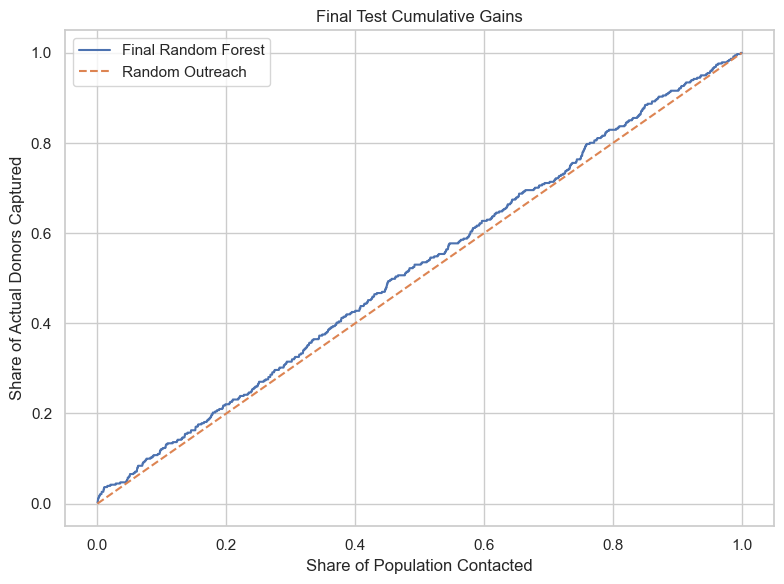

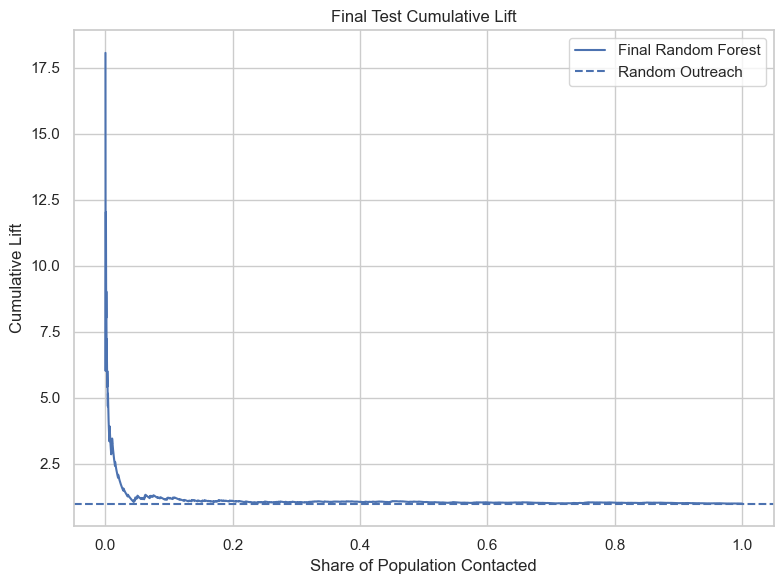

In [94]:
# Calculate cumulative gains and lift from final test rankings
final_test_ranked_predictions = (
    pd.DataFrame({
        "target": (
            final_test_target_array
        ),
        "probability_positive": (
            final_test_probability_positive
        ),
    })
    .sort_values(
        "probability_positive",
        ascending=False,
        kind="mergesort",
    )
    .reset_index(drop=True)
)

final_test_ranked_predictions[
    "rank"
] = np.arange(
    1,
    final_test_record_count + 1,
)

final_test_ranked_predictions[
    "population_share"
] = (
    final_test_ranked_predictions[
        "rank"
    ]
    / final_test_record_count
)

final_test_ranked_predictions[
    "cumulative_donors"
] = (
    final_test_ranked_predictions[
        "target"
    ].cumsum()
)

final_test_ranked_predictions[
    "cumulative_gain"
] = (
    final_test_ranked_predictions[
        "cumulative_donors"
    ]
    / final_test_donor_count
)

final_test_ranked_predictions[
    "cumulative_lift"
] = (
    final_test_ranked_predictions[
        "cumulative_gain"
    ]
    / final_test_ranked_predictions[
        "population_share"
    ]
)

gain_summary_records = []

for population_share in np.arange(
    0.10,
    1.01,
    0.10,
):
    contacted_count = min(
        int(
            np.ceil(
                final_test_record_count
                * population_share
            )
        ),
        final_test_record_count,
    )

    gain_row = (
        final_test_ranked_predictions.iloc[
            contacted_count - 1
        ]
    )

    gain_summary_records.append({
        "population_share": (
            contacted_count
            / final_test_record_count
        ),
        "individuals_contacted": (
            contacted_count
        ),
        "cumulative_donors": int(
            gain_row[
                "cumulative_donors"
            ]
        ),
        "cumulative_gain": (
            gain_row[
                "cumulative_gain"
            ]
        ),
        "cumulative_lift": (
            gain_row[
                "cumulative_lift"
            ]
        ),
    })

final_test_cumulative_gains_summary = (
    pd.DataFrame(
        gain_summary_records
    )
)

print(
    "FINAL TEST CUMULATIVE GAINS SUMMARY"
)

display(
    final_test_cumulative_gains_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .format({
        "population_share": "{:.0%}",
        "individuals_contacted": "{:,.0f}",
        "cumulative_donors": "{:,.0f}",
        "cumulative_gain": "{:.2%}",
        "cumulative_lift": "{:.2f}×",
    })
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    final_test_ranked_predictions[
        "population_share"
    ],
    final_test_ranked_predictions[
        "cumulative_gain"
    ],
    label="Final Random Forest",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Outreach",
)

plt.xlabel(
    "Share of Population Contacted"
)

plt.ylabel(
    "Share of Actual Donors Captured"
)

plt.title(
    "Final Test Cumulative Gains"
)

plt.legend()
plt.tight_layout()
plt.show()


plt.figure(
    figsize=(8, 6)
)

plt.plot(
    final_test_ranked_predictions[
        "population_share"
    ],
    final_test_ranked_predictions[
        "cumulative_lift"
    ],
    label="Final Random Forest",
)

plt.axhline(
    y=1.0,
    linestyle="--",
    label="Random Outreach",
)

plt.xlabel(
    "Share of Population Contacted"
)

plt.ylabel(
    "Cumulative Lift"
)

plt.title(
    "Final Test Cumulative Lift"
)

plt.legend()
plt.tight_layout()
plt.show()

In [95]:
# Validate one time final test evaluation

final_pipeline_id_after_test = id(
    final_primary_pipeline
)

final_estimator_id_after_test = id(
    final_primary_estimator
)

final_tree_count_after_test = len(
    final_primary_estimator.estimators_
)

pipeline_structure_unchanged = (
    final_pipeline_id_before_test
    == final_pipeline_id_after_test
    and final_estimator_id_before_test
    == final_estimator_id_after_test
    and final_tree_count_before_test
    == final_tree_count_after_test
)

test_feature_target_rows_align = (
    len(
        final_test_features
    )
    == len(
        final_test_target_array
    )
)

test_feature_target_indices_align = (
    final_test_features.index.equals(
        final_test_target.index
    )
)

development_test_indices_disjoint = (
    final_primary_fit_features.index
    .intersection(
        final_test_features.index
    )
    .empty
)

test_probability_count_valid = (
    len(
        final_test_probability_positive
    )
    == final_test_record_count
)

test_probability_range_valid = np.all(
    (
        final_test_probability_positive
        >= 0
    )
    & (
        final_test_probability_positive
        <= 1
    )
)

frozen_threshold_matches_selection = (
    np.isclose(
        final_test_operating_threshold,
        primary_operating_threshold,
        atol=1e-15,
    )
)

confusion_matrix_total_valid = (
    final_test_true_negative
    + final_test_false_positive
    + final_test_false_negative
    + final_test_true_positive
    == final_test_record_count
)

recomputed_test_pr_auc = (
    average_precision_score(
        final_test_target_array,
        final_test_probability_positive,
    )
)

recomputed_test_roc_auc = (
    roc_auc_score(
        final_test_target_array,
        final_test_probability_positive,
    )
)

recomputed_test_brier = (
    brier_score_loss(
        final_test_target_array,
        final_test_probability_positive,
    )
)

test_pr_auc_valid = np.isclose(
    final_test_metrics[
        "pr_auc_average_precision"
    ],
    recomputed_test_pr_auc,
    atol=1e-12,
)

test_roc_auc_valid = np.isclose(
    final_test_metrics[
        "roc_auc"
    ],
    recomputed_test_roc_auc,
    atol=1e-12,
)

test_brier_valid = np.isclose(
    final_test_metrics[
        "brier_score"
    ],
    recomputed_test_brier,
    atol=1e-12,
)

expected_test_contact_counts = {
    capacity: int(
        np.ceil(
            final_test_record_count
            * capacity
        )
    )
    for capacity
    in final_test_campaign_capacities
}

test_contact_counts_valid = all(
    row[
        "individuals_contacted"
    ]
    == expected_test_contact_counts[
        row["campaign_capacity"]
    ]
    for _, row
    in final_test_outreach_capacity_results.iterrows()
)

test_lift_calculation_valid = np.allclose(
    final_test_outreach_capacity_results[
        "lift_over_random"
    ],
    (
        final_test_outreach_capacity_results[
            "precision_selected_group"
        ]
        / final_test_donor_rate
    ),
    atol=1e-12,
)

test_random_donor_calculation_valid = (
    np.allclose(
        final_test_outreach_capacity_results[
            "expected_random_donors"
        ],
        (
            final_test_outreach_capacity_results[
                "individuals_contacted"
            ]
            * final_test_donor_rate
        ),
        atol=1e-12,
    )
)

cumulative_donors_monotonic = (
    final_test_ranked_predictions[
        "cumulative_donors"
    ].is_monotonic_increasing
)

cumulative_gain_monotonic = (
    final_test_ranked_predictions[
        "cumulative_gain"
    ].is_monotonic_increasing
)

final_cumulative_donor_count_valid = (
    int(
        final_test_ranked_predictions[
            "cumulative_donors"
        ].iloc[-1]
    )
    == final_test_donor_count
)

final_cumulative_gain_valid = np.isclose(
    final_test_ranked_predictions[
        "cumulative_gain"
    ].iloc[-1],
    1.0,
    atol=1e-12,
)

final_cumulative_lift_valid = np.isclose(
    final_test_ranked_predictions[
        "cumulative_lift"
    ].iloc[-1],
    1.0,
    atol=1e-12,
)

final_test_evaluation_validation = pd.DataFrame({
    "validation_check": [
        "Final pipeline was fitted before test prediction",
        "Final test probability prediction call count",
        "Pipeline structure remained unchanged",
        "Test feature and target row counts align",
        "Test feature and target indices align",
        "Development and test indices are disjoint",
        "Final test probability count is complete",
        "All final test probabilities between 0 and 1",
        "Operating threshold matches development selection",
        "Confusion matrix accounts for every test record",
        "PR AUC reproduces directly",
        "ROC AUC reproduces directly",
        "Brier score reproduces directly",
        "Outreach capacity row count",
        "Outreach contact counts match configured capacities",
        "Outreach lift calculation is valid",
        "Expected random donor calculation is valid",
        "Cumulative donor count is monotonic",
        "Cumulative gain is monotonic",
        "Final cumulative donor count matches test donors",
        "Cumulative gain reaches 100 percent",
        "Cumulative lift returns to one at full population",
    ],
    "expected": [
        "True",
        1,
        "True",
        final_test_record_count,
        "True",
        "True",
        final_test_record_count,
        "True",
        final_primary_operating_threshold,
        final_test_record_count,
        recomputed_test_pr_auc,
        recomputed_test_roc_auc,
        recomputed_test_brier,
        len(
            final_test_campaign_capacities
        ),
        "True",
        "True",
        "True",
        "True",
        "True",
        final_test_donor_count,
        1.0,
        1.0,
    ],
    "actual": [
        str(
            final_pipeline_was_fitted_before_test
        ),
        final_test_prediction_call_count,
        str(
            pipeline_structure_unchanged
        ),
        len(
            final_test_target_array
        ),
        str(
            test_feature_target_indices_align
        ),
        str(
            development_test_indices_disjoint
        ),
        len(
            final_test_probability_positive
        ),
        str(
            test_probability_range_valid
        ),
        final_test_operating_threshold,
        (
            final_test_true_negative
            + final_test_false_positive
            + final_test_false_negative
            + final_test_true_positive
        ),
        final_test_metrics[
            "pr_auc_average_precision"
        ],
        final_test_metrics[
            "roc_auc"
        ],
        final_test_metrics[
            "brier_score"
        ],
        len(
            final_test_outreach_capacity_results
        ),
        str(
            test_contact_counts_valid
        ),
        str(
            test_lift_calculation_valid
        ),
        str(
            test_random_donor_calculation_valid
        ),
        str(
            cumulative_donors_monotonic
        ),
        str(
            cumulative_gain_monotonic
        ),
        int(
            final_test_ranked_predictions[
                "cumulative_donors"
            ].iloc[-1]
        ),
        final_test_ranked_predictions[
            "cumulative_gain"
        ].iloc[-1],
        final_test_ranked_predictions[
            "cumulative_lift"
        ].iloc[-1],
    ],
})

final_test_evaluation_validation[
    "passed"
] = [
    final_pipeline_was_fitted_before_test,
    final_test_prediction_call_count == 1,
    pipeline_structure_unchanged,
    test_feature_target_rows_align,
    test_feature_target_indices_align,
    development_test_indices_disjoint,
    test_probability_count_valid,
    test_probability_range_valid,
    frozen_threshold_matches_selection,
    confusion_matrix_total_valid,
    test_pr_auc_valid,
    test_roc_auc_valid,
    test_brier_valid,
    len(
        final_test_outreach_capacity_results
    )
    == len(
        final_test_campaign_capacities
    ),
    test_contact_counts_valid,
    test_lift_calculation_valid,
    test_random_donor_calculation_valid,
    cumulative_donors_monotonic,
    cumulative_gain_monotonic,
    final_cumulative_donor_count_valid,
    final_cumulative_gain_valid,
    final_cumulative_lift_valid,
]

display(
    final_test_evaluation_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_final_test_checks = (
    final_test_evaluation_validation.loc[
        ~final_test_evaluation_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_final_test_checks:
    raise AssertionError(
        "Final test evaluation validation "
        "failed for: "
        + ", ".join(
            failed_final_test_checks
        )
    )

print(
    "One-time final test evaluation validated."
)

print(
    f"Final test PR AUC: "
    f"{final_test_metrics['pr_auc_average_precision']:.4f}"
)

print(
    f"Final test ROC AUC: "
    f"{final_test_metrics['roc_auc']:.4f}"
)

print(
    f"Frozen operating threshold: "
    f"{final_test_operating_threshold:.6f}"
)

print(
    "No model selection, tuning, calibration, "
    "or threshold changes were performed using "
    "the final test results."
)

validation_check,expected,actual,passed
Final pipeline was fitted before test prediction,True,True,True
Final test probability prediction call count,1,1,True
Pipeline structure remained unchanged,True,True,True
Test feature and target row counts align,"6,881","6,881",True
Test feature and target indices align,True,True,True
Development and test indices are disjoint,True,True,True
Final test probability count is complete,"6,881","6,881",True
All final test probabilities between 0 and 1,True,True,True
Operating threshold matches development selection,0.07,0.07,True
Confusion matrix accounts for every test record,"6,881","6,881",True


One-time final test evaluation validated.
Final test PR AUC: 0.0704
Final test ROC AUC: 0.5236
Frozen operating threshold: 0.065424
No model selection, tuning, calibration, or threshold changes were performed using the final test results.


## One Time Final Test Evaluation

The finalized Random Forest pipeline was evaluated once on the previously untouched final test set. All model selection, feature selection, hyperparameter tuning, probability calibration decisions, and operating threshold selection were completed using development data before the test set was evaluated. The final pipeline was not refitted or modified during test evaluation. The previously selected operating threshold of 0.065424 was applied unchanged.

The final test set contained:

- 6,881 individuals
- 381 actual donors
- a donor rate of 5.54%

### Final Test Statistical Performance

| Metric | Final Test Result |
|---|---:|
| PR AUC | 0.0704 |
| ROC AUC | 0.5236 |
| Recall | 9.97% |
| Precision | 6.74% |
| F1 Score | 0.0804 |
| Specificity | 91.91% |
| Balanced Accuracy | 50.94% |
| Brier Score | 0.0522 |
| Predicted Positive Rate | 8.20% |
| Operating Threshold | 0.065424 |

The final test donor prevalence was approximately 5.54%, which also represents the approximate no skill PR AUC baseline. The model achieved a PR AUC of 0.0704, indicating ranking performance above the no skill baseline, although the overall discrimination remained modest. ROC AUC was 0.5236, showing that the model provides only limited separation between donors and non donors across the entire test population. The final test PR AUC was lower than the development cross validation result of 0.0786. This difference is retained as part of the final evaluation rather than being used to revise the model.

### Frozen Operating Threshold

The development selected operating threshold of 0.065424 was applied directly to the final test probabilities.

The resulting confusion matrix was:

| | Predicted Non Donor | Predicted Donor |
|---|---:|---:|
| Actual Non Donor | 5,974 | 526 |
| Actual Donor | 343 | 38 |

At this threshold:

- 38 actual donors were correctly identified,
- 526 non donors were also selected,
- 343 donors were not selected,
- recall was 9.97%,
- precision was 6.74%,
- and 8.20% of the test population was classified for outreach.

The predicted positive rate was lower than the 10% development contact objective because the operating point was defined by a fixed probability threshold rather than by forcing exactly 10% of every future population into the selected group. The probability distribution on unseen data therefore resulted in approximately 8.20% of test records exceeding the frozen threshold.

### Final Test Outreach Capacity Results

The model was also evaluated as a ranking system at the same 1%, 5%, 10%, and 20% campaign capacities used during development.

| Capacity | Individuals Contacted | Donors Captured | Recall | Precision | Lift Over Random |
|---|---:|---:|---:|---:|---:|
| 1% | 69 | 13 | 3.41% | 18.84% | 3.40× |
| 5% | 345 | 23 | 6.04% | 6.67% | 1.20× |
| 10% | 689 | 46 | 12.07% | 6.68% | 1.21× |
| 20% | 1,377 | 84 | 22.05% | 6.10% | 1.10× |

The strongest test performance occurred in the most selective outreach scenario.

At a 1% campaign capacity, the model ranked 69 individuals highest and captured 13 actual donors. Random outreach would be expected to identify approximately 3.8 donors from a group of this size.

This produced:

- precision of 18.84%,
- recall of 3.41%,
- and lift of 3.40×.

The model therefore concentrated donors at more than three times the random outreach rate within the highest ranked 1% of the test population.

### Broader Outreach Capacity

The ranking advantage became smaller as outreach capacity increased. At 5% capacity, lift decreased to 1.20×. At 10% capacity, the model contacted 689 individuals and captured 46 donors, compared with approximately 38 donors expected under random outreach. This produced a lift of 1.21×. At 20% capacity, lift decreased further to 1.10×. These results indicate that the model's strongest practical value is concentrated toward the very top of its ranking rather than across broad portions of the population.

### Cumulative Gains

The cumulative gains analysis showed:

| Population Contacted | Donors Captured | Share of All Donors Captured | Cumulative Lift |
|---|---:|---:|---:|
| 10% | 46 | 12.07% | 1.21× |
| 20% | 84 | 22.05% | 1.10× |
| 30% | 120 | 31.50% | 1.05× |
| 40% | 163 | 42.78% | 1.07× |
| 50% | 202 | 53.02% | 1.06× |
| 60% | 239 | 62.73% | 1.05× |
| 70% | 271 | 71.13% | 1.02× |
| 80% | 316 | 82.94% | 1.04× |
| 90% | 349 | 91.60% | 1.02× |
| 100% | 381 | 100.00% | 1.00× |

The cumulative gains curve remained generally above the random outreach reference line, confirming that higher ranked individuals contained a somewhat greater concentration of actual donors. However, the advantage gradually decreased as more of the population was contacted and cumulative lift approached 1.00×. This reinforces the conclusion that the model is most useful for selective outreach rather than broad population classification.

### Final Test Interpretation

The final holdout results show that the Random Forest provides modest but measurable ranking value on unseen data, with its strongest practical benefit concentrated among the highest ranked individuals.

The top 1% of the test ranking produced a 3.40× lift over random outreach, while larger campaign capacities provided smaller improvements. The model should therefore be interpreted primarily as an outreach prioritization tool rather than as a highly accurate binary donor classifier.

The final test results also show weaker performance than some development estimates, particularly at broader outreach capacities. This difference is retained as an unbiased measure of generalization performance and was not used to modify the model.

The final test pipeline produced probabilities exactly once, all test metrics were derived from that single prediction vector, the frozen operating threshold was applied unchanged, and all statistical, confusion matrix, outreach, lift, and cumulative gains calculations passed validation.

No model selection, feature engineering, hyperparameter tuning, calibration, or threshold adjustment was performed using the final test results.

In [96]:
# Summarize final test errors and predicted probability distributions
final_stability_test_probability_snapshot = (
    final_test_probability_positive.copy()
)

final_stability_operating_threshold_snapshot = float(
    final_test_operating_threshold
)

final_stability_pipeline_id_before = id(
    final_primary_pipeline
)

final_stability_estimator_id_before = id(
    final_primary_estimator
)

final_stability_tree_count_before = len(
    final_primary_estimator.estimators_
)

final_error_analysis = pd.DataFrame({
    "actual_class": (
        final_test_target_array
    ),
    "predicted_class": (
        final_test_predicted_class
    ),
    "probability_positive": (
        final_test_probability_positive
    ),
})

final_error_analysis[
    "prediction_outcome"
] = np.select(
    [
        (
            final_error_analysis[
                "actual_class"
            ].eq(0)
            & final_error_analysis[
                "predicted_class"
            ].eq(0)
        ),
        (
            final_error_analysis[
                "actual_class"
            ].eq(0)
            & final_error_analysis[
                "predicted_class"
            ].eq(1)
        ),
        (
            final_error_analysis[
                "actual_class"
            ].eq(1)
            & final_error_analysis[
                "predicted_class"
            ].eq(0)
        ),
        (
            final_error_analysis[
                "actual_class"
            ].eq(1)
            & final_error_analysis[
                "predicted_class"
            ].eq(1)
        ),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unexpected",
)

final_error_analysis[
    "distance_from_threshold"
] = (
    final_error_analysis[
        "probability_positive"
    ]
    - final_test_operating_threshold
).abs()

prediction_outcome_order = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive",
]

final_error_summary_records = []

for prediction_outcome in (
    prediction_outcome_order
):
    outcome_probabilities = (
        final_error_analysis.loc[
            final_error_analysis[
                "prediction_outcome"
            ].eq(
                prediction_outcome
            ),
            "probability_positive",
        ]
    )

    outcome_distances = (
        final_error_analysis.loc[
            final_error_analysis[
                "prediction_outcome"
            ].eq(
                prediction_outcome
            ),
            "distance_from_threshold",
        ]
    )

    final_error_summary_records.append({
        "prediction_outcome": (
            prediction_outcome
        ),
        "record_count": len(
            outcome_probabilities
        ),
        "share_of_test_set": (
            len(
                outcome_probabilities
            )
            / final_test_record_count
        ),
        "mean_probability": (
            outcome_probabilities.mean()
        ),
        "median_probability": (
            outcome_probabilities.median()
        ),
        "minimum_probability": (
            outcome_probabilities.min()
        ),
        "maximum_probability": (
            outcome_probabilities.max()
        ),
        "median_distance_from_threshold": (
            outcome_distances.median()
        ),
    })

final_error_summary = pd.DataFrame(
    final_error_summary_records
)

display(
    final_error_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "prediction_outcome",
        ],
        **{"text-align": "left"}
    )
    .format({
        "record_count": "{:,.0f}",
        "share_of_test_set": "{:.2%}",
        "mean_probability": "{:.4f}",
        "median_probability": "{:.4f}",
        "minimum_probability": "{:.4f}",
        "maximum_probability": "{:.4f}",
        "median_distance_from_threshold": (
            "{:.4f}"
        ),
    })
)

probability_distribution_records = []

for actual_class, class_label in [
    (0, "Non Donor"),
    (1, "Donor"),
]:
    class_probabilities = (
        final_error_analysis.loc[
            final_error_analysis[
                "actual_class"
            ].eq(actual_class),
            "probability_positive",
        ]
    )

    probability_distribution_records.append({
        "actual_class": class_label,
        "record_count": len(
            class_probabilities
        ),
        "mean_probability": (
            class_probabilities.mean()
        ),
        "median_probability": (
            class_probabilities.median()
        ),
        "10th_percentile": (
            class_probabilities.quantile(
                0.10
            )
        ),
        "25th_percentile": (
            class_probabilities.quantile(
                0.25
            )
        ),
        "75th_percentile": (
            class_probabilities.quantile(
                0.75
            )
        ),
        "90th_percentile": (
            class_probabilities.quantile(
                0.90
            )
        ),
        "maximum_probability": (
            class_probabilities.max()
        ),
    })

final_probability_distribution_summary = (
    pd.DataFrame(
        probability_distribution_records
    )
)

display(
    final_probability_distribution_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "actual_class",
        ],
        **{"text-align": "left"}
    )
    .format({
        "record_count": "{:,.0f}",
        "mean_probability": "{:.4f}",
        "median_probability": "{:.4f}",
        "10th_percentile": "{:.4f}",
        "25th_percentile": "{:.4f}",
        "75th_percentile": "{:.4f}",
        "90th_percentile": "{:.4f}",
        "maximum_probability": "{:.4f}",
    })
)

false_negative_rate = (
    final_test_false_negative
    / final_test_donor_count
)

false_positive_rate = (
    final_test_false_positive
    / (
        final_test_true_negative
        + final_test_false_positive
    )
)

print(
    f"False negatives: "
    f"{final_test_false_negative:,} "
    f"({false_negative_rate:.2%} of donors)"
)

print(
    f"False positives: "
    f"{final_test_false_positive:,} "
    f"({false_positive_rate:.2%} of non donors)"
)

prediction_outcome,record_count,share_of_test_set,mean_probability,median_probability,minimum_probability,maximum_probability,median_distance_from_threshold
True Negative,"5,974",86.82%,0.0516,0.0542,0.0158,0.0654,0.0112
False Positive,526,7.64%,0.0911,0.0791,0.0655,0.8065,0.0136
False Negative,343,4.98%,0.0521,0.0542,0.0177,0.0654,0.0112
True Positive,38,0.55%,0.1493,0.0774,0.0667,0.8065,0.0120


actual_class,record_count,mean_probability,median_probability,10th_percentile,25th_percentile,75th_percentile,90th_percentile,maximum_probability
Non Donor,"6,500",0.0548,0.0542,0.0411,0.0479,0.0584,0.0637,0.8065
Donor,381,0.0618,0.0542,0.0441,0.0488,0.0584,0.0654,0.8065


False negatives: 343 (90.03% of donors)
False positives: 526 (8.09% of non donors)


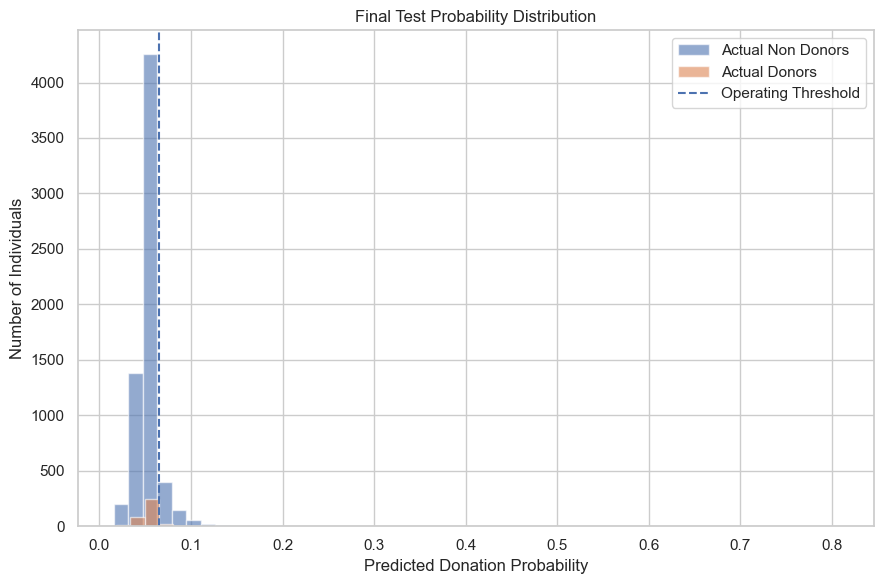

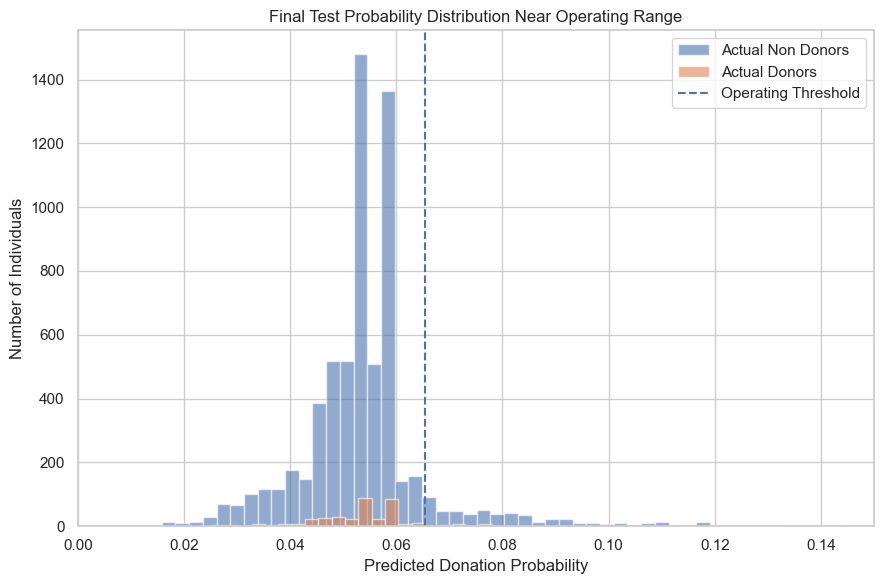

Zoomed probability range: 0.0000 to 0.1500


In [97]:
# Visualize final test probability distributions by actual outcome
final_non_donor_probabilities = (
    final_error_analysis.loc[
        final_error_analysis[
            "actual_class"
        ].eq(0),
        "probability_positive",
    ]
)

final_donor_probabilities = (
    final_error_analysis.loc[
        final_error_analysis[
            "actual_class"
        ].eq(1),
        "probability_positive",
    ]
)

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    final_non_donor_probabilities,
    bins=50,
    alpha=0.6,
    label="Actual Non Donors",
)

plt.hist(
    final_donor_probabilities,
    bins=50,
    alpha=0.6,
    label="Actual Donors",
)

plt.axvline(
    final_test_operating_threshold,
    linestyle="--",
    label="Operating Threshold",
)

plt.xlabel(
    "Predicted Donation Probability"
)

plt.ylabel(
    "Number of Individuals"
)

plt.title(
    "Final Test Probability Distribution"
)

plt.legend()
plt.tight_layout()
plt.show()


probability_zoom_limit = max(
    0.15,
    np.quantile(
        final_test_probability_positive,
        0.99,
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    final_non_donor_probabilities[
        final_non_donor_probabilities
        <= probability_zoom_limit
    ],
    bins=50,
    alpha=0.6,
    label="Actual Non Donors",
)

plt.hist(
    final_donor_probabilities[
        final_donor_probabilities
        <= probability_zoom_limit
    ],
    bins=50,
    alpha=0.6,
    label="Actual Donors",
)

plt.axvline(
    final_test_operating_threshold,
    linestyle="--",
    label="Operating Threshold",
)

plt.xlabel(
    "Predicted Donation Probability"
)

plt.ylabel(
    "Number of Individuals"
)

plt.title(
    "Final Test Probability Distribution Near Operating Range"
)

plt.xlim(
    0,
    probability_zoom_limit,
)

plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Zoomed probability range: "
    f"0.0000 to {probability_zoom_limit:.4f}"
)

In [98]:
# Compare campaign performance and cross validation stability
development_primary_outreach = (
    outreach_capacity_results.loc[
        outreach_capacity_results[
            "model"
        ].eq(
            final_primary_model_name
        ),
        [
            "campaign_capacity",
            "individuals_contacted",
            "actual_donors_captured",
            "recall_among_all_donors",
            "precision_selected_group",
            "lift_over_random",
        ],
    ]
    .rename(columns={
        "individuals_contacted": (
            "development_contacts"
        ),
        "actual_donors_captured": (
            "development_donors_captured"
        ),
        "recall_among_all_donors": (
            "development_recall"
        ),
        "precision_selected_group": (
            "development_precision"
        ),
        "lift_over_random": (
            "development_lift"
        ),
    })
)

test_primary_outreach = (
    final_test_outreach_capacity_results[
        [
            "campaign_capacity",
            "individuals_contacted",
            "actual_donors_captured",
            "recall_among_all_donors",
            "precision_selected_group",
            "lift_over_random",
        ]
    ]
    .rename(columns={
        "individuals_contacted": (
            "test_contacts"
        ),
        "actual_donors_captured": (
            "test_donors_captured"
        ),
        "recall_among_all_donors": (
            "test_recall"
        ),
        "precision_selected_group": (
            "test_precision"
        ),
        "lift_over_random": (
            "test_lift"
        ),
    })
)

campaign_stability_comparison = (
    development_primary_outreach.merge(
        test_primary_outreach,
        on="campaign_capacity",
        how="inner",
        validate="one_to_one",
    )
)

campaign_stability_comparison[
    "recall_change"
] = (
    campaign_stability_comparison[
        "test_recall"
    ]
    - campaign_stability_comparison[
        "development_recall"
    ]
)

campaign_stability_comparison[
    "precision_change"
] = (
    campaign_stability_comparison[
        "test_precision"
    ]
    - campaign_stability_comparison[
        "development_precision"
    ]
)

campaign_stability_comparison[
    "lift_change"
] = (
    campaign_stability_comparison[
        "test_lift"
    ]
    - campaign_stability_comparison[
        "development_lift"
    ]
)

display(
    campaign_stability_comparison.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .format({
        "campaign_capacity": "{:.0%}",
        "development_contacts": "{:,.0f}",
        "development_donors_captured": "{:,.0f}",
        "development_recall": "{:.2%}",
        "development_precision": "{:.2%}",
        "development_lift": "{:.2f}×",
        "test_contacts": "{:,.0f}",
        "test_donors_captured": "{:,.0f}",
        "test_recall": "{:.2%}",
        "test_precision": "{:.2%}",
        "test_lift": "{:.2f}×",
        "recall_change": "{:+.2%}",
        "precision_change": "{:+.2%}",
        "lift_change": "{:+.2f}×",
    })
)

selected_cv_fold_records = [
    result
    for result
    in model_tuning_cv_results
    if (
        result["model"]
        == final_primary_model_name
        and result[
            "configuration_id"
        ]
        == final_primary_configuration_id
    )
]

selected_cv_fold_results = (
    pd.DataFrame(
        selected_cv_fold_records
    )
    .sort_values(
        "fold"
    )
    .reset_index(drop=True)
)

display(
    selected_cv_fold_results[
        [
            "fold",
            "train_pr_auc",
            "pr_auc",
            "roc_auc",
            "fit_seconds",
        ]
    ].style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .format({
        "fold": "{:,.0f}",
        "train_pr_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "roc_auc": "{:.4f}",
        "fit_seconds": "{:.2f}",
    })
)

selected_cv_pr_auc_mean = (
    selected_cv_fold_results[
        "pr_auc"
    ].mean()
)

selected_cv_pr_auc_std = (
    selected_cv_fold_results[
        "pr_auc"
    ].std(
        ddof=0
    )
)

selected_cv_train_pr_auc_mean = (
    selected_cv_fold_results[
        "train_pr_auc"
    ].mean()
)

selected_cv_train_validation_gap = (
    selected_cv_train_pr_auc_mean
    - selected_cv_pr_auc_mean
)

final_test_pr_auc_change_vs_cv = (
    final_test_metrics[
        "pr_auc_average_precision"
    ]
    - selected_cv_pr_auc_mean
)

final_test_pr_auc_std_units = (
    final_test_pr_auc_change_vs_cv
    / selected_cv_pr_auc_std
)

selected_cv_roc_auc_mean = (
    selected_cv_fold_results[
        "roc_auc"
    ].mean()
)

final_test_roc_auc_change_vs_cv = (
    final_test_metrics[
        "roc_auc"
    ]
    - selected_cv_roc_auc_mean
)

final_test_brier_change_vs_development = (
    final_test_metrics[
        "brier_score"
    ]
    - final_primary_selection_row[
        "brier_score"
    ]
)

development_10pct_lift = (
    campaign_stability_comparison.loc[
        campaign_stability_comparison[
            "campaign_capacity"
        ].eq(0.10),
        "development_lift",
    ].iloc[0]
)

test_10pct_lift = (
    campaign_stability_comparison.loc[
        campaign_stability_comparison[
            "campaign_capacity"
        ].eq(0.10),
        "test_lift",
    ].iloc[0]
)

final_overfitting_diagnostics = pd.DataFrame({
    "diagnostic": [
        "Mean CV Training PR AUC",
        "Mean CV Validation PR AUC",
        "CV Training to Validation Gap",
        "CV PR AUC Variability",
        "Final Test PR AUC",
        "Test PR AUC Change vs CV Mean",
        "Test PR AUC Difference in CV Std Units",
        "Mean CV ROC AUC",
        "Final Test ROC AUC",
        "Test ROC AUC Change vs CV Mean",
        "Development Brier Score",
        "Final Test Brier Score",
        "Test Brier Change vs Development",
        "Development 10% Outreach Lift",
        "Final Test 10% Outreach Lift",
        "10% Outreach Lift Change",
    ],
    "value": [
        selected_cv_train_pr_auc_mean,
        selected_cv_pr_auc_mean,
        selected_cv_train_validation_gap,
        selected_cv_pr_auc_std,
        final_test_metrics[
            "pr_auc_average_precision"
        ],
        final_test_pr_auc_change_vs_cv,
        final_test_pr_auc_std_units,
        selected_cv_roc_auc_mean,
        final_test_metrics[
            "roc_auc"
        ],
        final_test_roc_auc_change_vs_cv,
        final_primary_selection_row[
            "brier_score"
        ],
        final_test_metrics[
            "brier_score"
        ],
        final_test_brier_change_vs_development,
        development_10pct_lift,
        test_10pct_lift,
        (
            test_10pct_lift
            - development_10pct_lift
        ),
    ],
})

def format_overfitting_diagnostic(
    row,
):
    diagnostic = row["diagnostic"]
    value = float(
        row["value"]
    )

    if "Std Units" in diagnostic:
        return f"{value:+.2f}"

    if "Lift" in diagnostic:
        return f"{value:+.2f}×"

    if "Change" in diagnostic:
        return f"{value:+.4f}"

    return f"{value:.4f}"


final_overfitting_diagnostics[
    "formatted_value"
] = (
    final_overfitting_diagnostics.apply(
        format_overfitting_diagnostic,
        axis=1,
    )
)

display(
    final_overfitting_diagnostics[
        [
            "diagnostic",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "diagnostic",
            "value",
        ],
        **{"text-align": "left"}
    )
)

campaign_capacity,development_contacts,development_donors_captured,development_recall,development_precision,development_lift,test_contacts,test_donors_captured,test_recall,test_precision,test_lift,recall_change,precision_change,lift_change
1%,276,46,3.02%,16.67%,3.01×,69,13,3.41%,18.84%,3.40×,+0.39%,+2.17%,+0.39×
5%,"1,377",114,7.49%,8.28%,1.50×,345,23,6.04%,6.67%,1.20×,-1.45%,-1.61%,-0.29×
10%,"2,753",208,13.66%,7.56%,1.37×,689,46,12.07%,6.68%,1.21×,-1.58%,-0.88%,-0.16×
20%,"5,505",340,22.32%,6.18%,1.12×,"1,377",84,22.05%,6.10%,1.10×,-0.28%,-0.08%,-0.01×


fold,train_pr_auc,pr_auc,roc_auc,fit_seconds
1,0.1586,0.0844,0.5491,2.01
2,0.1569,0.0794,0.5059,1.99
3,0.1556,0.0826,0.5451,2.02
4,0.1553,0.0726,0.5149,2.00
5,0.1553,0.0739,0.5050,2.01


diagnostic,value
Mean CV Training PR AUC,0.1563
Mean CV Validation PR AUC,0.0786
CV Training to Validation Gap,0.0777
CV PR AUC Variability,0.0047
Final Test PR AUC,0.0704
Test PR AUC Change vs CV Mean,-0.0082
Test PR AUC Difference in CV Std Units,-1.76
Mean CV ROC AUC,0.5240
Final Test ROC AUC,0.5236
Test ROC AUC Change vs CV Mean,-0.0004


threshold_multiplier,probability_threshold,individuals_contacted,contact_rate,donors_captured,recall,precision,f1_score,specificity,balanced_accuracy,lift_over_random,selected_threshold
80%,0.052339,"4,391",63.81%,253,66.40%,5.76%,0.1060,36.34%,51.37%,1.04×,False
90%,0.058881,985,14.31%,60,15.75%,6.09%,0.0878,85.77%,50.76%,1.10×,False
100%,0.065424,564,8.20%,38,9.97%,6.74%,0.0804,91.91%,50.94%,1.22×,True
110%,0.071966,422,6.13%,28,7.35%,6.64%,0.0697,93.94%,50.64%,1.20×,False
120%,0.078508,292,4.24%,18,4.72%,6.16%,0.0535,95.78%,50.25%,1.11×,False


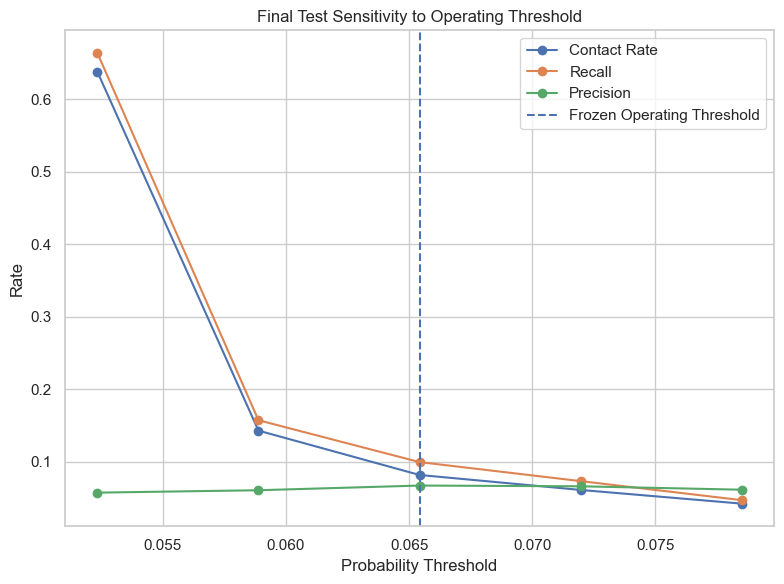

In [99]:
# Evaluate sensitivity around frozen operating threshold
threshold_sensitivity_multipliers = [
    0.80,
    0.90,
    1.00,
    1.10,
    1.20,
]

threshold_sensitivity_records = []

for threshold_multiplier in (
    threshold_sensitivity_multipliers
):
    sensitivity_threshold = (
        final_test_operating_threshold
        * threshold_multiplier
    )

    sensitivity_metrics = (
        calculate_classification_metrics(
            target_true=(
                final_test_target_array
            ),
            probability_positive=(
                final_test_probability_positive
            ),
            threshold=(
                sensitivity_threshold
            ),
        )
    )

    sensitivity_prediction = (
        final_test_probability_positive
        >= sensitivity_threshold
    ).astype(int)

    sensitivity_contact_count = int(
        sensitivity_prediction.sum()
    )

    sensitivity_donors_captured = int(
        final_test_target_array[
            sensitivity_prediction.eq(1)
            if isinstance(
                sensitivity_prediction,
                pd.Series,
            )
            else sensitivity_prediction == 1
        ].sum()
    )

    sensitivity_precision = (
        sensitivity_metrics[
            "precision"
        ]
    )

    sensitivity_lift = (
        sensitivity_precision
        / final_test_donor_rate
        if sensitivity_contact_count > 0
        else np.nan
    )

    threshold_sensitivity_records.append({
        "threshold_multiplier": (
            threshold_multiplier
        ),
        "probability_threshold": (
            sensitivity_threshold
        ),
        "individuals_contacted": (
            sensitivity_contact_count
        ),
        "contact_rate": (
            sensitivity_contact_count
            / final_test_record_count
        ),
        "donors_captured": (
            sensitivity_donors_captured
        ),
        "recall": (
            sensitivity_metrics[
                "recall"
            ]
        ),
        "precision": (
            sensitivity_precision
        ),
        "f1_score": (
            sensitivity_metrics[
                "f1_score"
            ]
        ),
        "specificity": (
            sensitivity_metrics[
                "specificity"
            ]
        ),
        "balanced_accuracy": (
            sensitivity_metrics[
                "balanced_accuracy"
            ]
        ),
        "lift_over_random": (
            sensitivity_lift
        ),
        "selected_threshold": (
            np.isclose(
                threshold_multiplier,
                1.0,
                atol=1e-12,
            )
        ),
    })

threshold_sensitivity_results = (
    pd.DataFrame(
        threshold_sensitivity_records
    )
)

display(
    threshold_sensitivity_results.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .format({
        "threshold_multiplier": "{:.0%}",
        "probability_threshold": "{:.6f}",
        "individuals_contacted": "{:,.0f}",
        "contact_rate": "{:.2%}",
        "donors_captured": "{:,.0f}",
        "recall": "{:.2%}",
        "precision": "{:.2%}",
        "f1_score": "{:.4f}",
        "specificity": "{:.2%}",
        "balanced_accuracy": "{:.2%}",
        "lift_over_random": "{:.2f}×",
        "selected_threshold": (
            lambda value: str(value)
        ),
    })
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    threshold_sensitivity_results[
        "probability_threshold"
    ],
    threshold_sensitivity_results[
        "contact_rate"
    ],
    marker="o",
    label="Contact Rate",
)

plt.plot(
    threshold_sensitivity_results[
        "probability_threshold"
    ],
    threshold_sensitivity_results[
        "recall"
    ],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_sensitivity_results[
        "probability_threshold"
    ],
    threshold_sensitivity_results[
        "precision"
    ],
    marker="o",
    label="Precision",
)

plt.axvline(
    final_test_operating_threshold,
    linestyle="--",
    label="Frozen Operating Threshold",
)

plt.xlabel(
    "Probability Threshold"
)

plt.ylabel(
    "Rate"
)

plt.title(
    "Final Test Sensitivity to Operating Threshold"
)

plt.legend()
plt.tight_layout()
plt.show()

In [100]:
# Validate final error and stability checks
final_stability_pipeline_id_after = id(
    final_primary_pipeline
)

final_stability_estimator_id_after = id(
    final_primary_estimator
)

final_stability_tree_count_after = len(
    final_primary_estimator.estimators_
)

final_stability_pipeline_unchanged = (
    final_stability_pipeline_id_before
    == final_stability_pipeline_id_after
    and final_stability_estimator_id_before
    == final_stability_estimator_id_after
    and final_stability_tree_count_before
    == final_stability_tree_count_after
)

final_stability_probabilities_unchanged = (
    np.array_equal(
        final_stability_test_probability_snapshot,
        final_test_probability_positive,
    )
)

final_stability_threshold_unchanged = (
    np.isclose(
        final_stability_operating_threshold_snapshot,
        final_test_operating_threshold,
        atol=1e-15,
    )
)

error_counts_reproduce_confusion_matrix = (
    final_error_summary.set_index(
        "prediction_outcome"
    ).loc[
        "True Negative",
        "record_count",
    ]
    == final_test_true_negative
    and final_error_summary.set_index(
        "prediction_outcome"
    ).loc[
        "False Positive",
        "record_count",
    ]
    == final_test_false_positive
    and final_error_summary.set_index(
        "prediction_outcome"
    ).loc[
        "False Negative",
        "record_count",
    ]
    == final_test_false_negative
    and final_error_summary.set_index(
        "prediction_outcome"
    ).loc[
        "True Positive",
        "record_count",
    ]
    == final_test_true_positive
)

error_summary_record_count_valid = (
    final_error_summary[
        "record_count"
    ].sum()
    == final_test_record_count
)

probability_distribution_count_valid = (
    final_probability_distribution_summary[
        "record_count"
    ].sum()
    == final_test_record_count
)

campaign_capacities_match = (
    set(
        campaign_stability_comparison[
            "campaign_capacity"
        ]
    )
    == set(
        CAMPAIGN_CAPACITIES
    )
)

campaign_stability_row_count_valid = (
    len(
        campaign_stability_comparison
    )
    == len(
        CAMPAIGN_CAPACITIES
    )
)

cv_fold_count_valid = (
    len(
        selected_cv_fold_results
    )
    == CV_FOLDS
)

cv_configuration_match = (
    selected_cv_fold_results[
        "model"
    ].eq(
        final_primary_model_name
    ).all()
    and selected_cv_fold_results[
        "configuration_id"
    ].eq(
        final_primary_configuration_id
    ).all()
)

cv_pr_auc_summary_reproduces = (
    np.isclose(
        selected_cv_pr_auc_mean,
        final_primary_selection_row[
            "mean_cv_pr_auc"
        ],
        atol=1e-12,
    )
    and np.isclose(
        selected_cv_pr_auc_std,
        final_primary_selection_row[
            "cv_pr_auc_std"
        ],
        atol=1e-12,
    )
)

selected_threshold_sensitivity_rows = (
    threshold_sensitivity_results.loc[
        threshold_sensitivity_results[
            "selected_threshold"
        ]
    ]
)

selected_threshold_sensitivity_count_valid = (
    len(
        selected_threshold_sensitivity_rows
    )
    == 1
)

selected_threshold_sensitivity_row = (
    selected_threshold_sensitivity_rows.iloc[
        0
    ]
)

threshold_sensitivity_reproduces_test = (
    np.isclose(
        selected_threshold_sensitivity_row[
            "probability_threshold"
        ],
        final_test_operating_threshold,
        atol=1e-15,
    )
    and int(
        selected_threshold_sensitivity_row[
            "individuals_contacted"
        ]
    )
    == int(
        final_test_predicted_class.sum()
    )
    and int(
        selected_threshold_sensitivity_row[
            "donors_captured"
        ]
    )
    == final_test_true_positive
    and np.isclose(
        selected_threshold_sensitivity_row[
            "recall"
        ],
        final_test_metrics[
            "recall"
        ],
        atol=1e-12,
    )
    and np.isclose(
        selected_threshold_sensitivity_row[
            "precision"
        ],
        final_test_metrics[
            "precision"
        ],
        atol=1e-12,
    )
)

thresholds_ordered_valid = (
    threshold_sensitivity_results[
        "probability_threshold"
    ].is_monotonic_increasing
)

contacts_decline_as_threshold_rises = (
    threshold_sensitivity_results[
        "individuals_contacted"
    ].is_monotonic_decreasing
)

all_threshold_metrics_valid = (
    threshold_sensitivity_results[
        "recall"
    ].between(
        0,
        1,
    ).all()
    and threshold_sensitivity_results[
        "precision"
    ].between(
        0,
        1,
    ).all()
    and threshold_sensitivity_results[
        "specificity"
    ].between(
        0,
        1,
    ).all()
    and threshold_sensitivity_results[
        "balanced_accuracy"
    ].between(
        0,
        1,
    ).all()
)

final_error_stability_validation = pd.DataFrame({
    "validation_check": [
        "Error outcome counts reproduce confusion matrix",
        "Error summary covers all final test records",
        "Probability distribution summary covers all test records",
        "Campaign capacities match configured scenarios",
        "Campaign stability comparison row count",
        "Selected configuration has expected CV fold count",
        "CV fold records match final model configuration",
        "CV PR AUC mean and variability reproduce selection results",
        "Threshold sensitivity contains one frozen threshold row",
        "Frozen threshold sensitivity metrics reproduce final test",
        "Sensitivity thresholds are ordered from low to high",
        "Contacts decline as threshold increases",
        "All threshold sensitivity metrics are valid",
        "Final test probabilities remained unchanged",
        "Frozen operating threshold remained unchanged",
        "Final pipeline structure remained unchanged",
    ],
    "expected": [
        "True",
        final_test_record_count,
        final_test_record_count,
        "True",
        len(
            CAMPAIGN_CAPACITIES
        ),
        CV_FOLDS,
        "True",
        "True",
        1,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        str(
            error_counts_reproduce_confusion_matrix
        ),
        int(
            final_error_summary[
                "record_count"
            ].sum()
        ),
        int(
            final_probability_distribution_summary[
                "record_count"
            ].sum()
        ),
        str(
            campaign_capacities_match
        ),
        len(
            campaign_stability_comparison
        ),
        len(
            selected_cv_fold_results
        ),
        str(
            cv_configuration_match
        ),
        str(
            cv_pr_auc_summary_reproduces
        ),
        len(
            selected_threshold_sensitivity_rows
        ),
        str(
            threshold_sensitivity_reproduces_test
        ),
        str(
            thresholds_ordered_valid
        ),
        str(
            contacts_decline_as_threshold_rises
        ),
        str(
            all_threshold_metrics_valid
        ),
        str(
            final_stability_probabilities_unchanged
        ),
        str(
            final_stability_threshold_unchanged
        ),
        str(
            final_stability_pipeline_unchanged
        ),
    ],
})

final_error_stability_validation[
    "passed"
] = [
    error_counts_reproduce_confusion_matrix,
    error_summary_record_count_valid,
    probability_distribution_count_valid,
    campaign_capacities_match,
    campaign_stability_row_count_valid,
    cv_fold_count_valid,
    cv_configuration_match,
    cv_pr_auc_summary_reproduces,
    selected_threshold_sensitivity_count_valid,
    threshold_sensitivity_reproduces_test,
    thresholds_ordered_valid,
    contacts_decline_as_threshold_rises,
    all_threshold_metrics_valid,
    final_stability_probabilities_unchanged,
    final_stability_threshold_unchanged,
    final_stability_pipeline_unchanged,
]

display(
    final_error_stability_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_error_stability_checks = (
    final_error_stability_validation.loc[
        ~final_error_stability_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_error_stability_checks:
    raise AssertionError(
        "Final error and stability validation "
        "failed for: "
        + ", ".join(
            failed_error_stability_checks
        )
    )

print(
    "Final error and stability checks validated."
)

print(
    f"False negatives reviewed: "
    f"{final_test_false_negative:,}"
)

print(
    f"False positives reviewed: "
    f"{final_test_false_positive:,}"
)

print(
    f"CV PR AUC: "
    f"{selected_cv_pr_auc_mean:.4f} "
    f"(±{selected_cv_pr_auc_std:.4f})"
)

print(
    f"Final test PR AUC: "
    f"{final_test_metrics['pr_auc_average_precision']:.4f}"
)

print(
    "The frozen model, probabilities, and "
    "operating threshold were not changed."
)

validation_check,expected,actual,passed
Error outcome counts reproduce confusion matrix,True,True,True
Error summary covers all final test records,"6,881","6,881",True
Probability distribution summary covers all test records,"6,881","6,881",True
Campaign capacities match configured scenarios,True,True,True
Campaign stability comparison row count,4,4,True
Selected configuration has expected CV fold count,5,5,True
CV fold records match final model configuration,True,True,True
CV PR AUC mean and variability reproduce selection results,True,True,True
Threshold sensitivity contains one frozen threshold row,1,1,True
Frozen threshold sensitivity metrics reproduce final test,True,True,True


Final error and stability checks validated.
False negatives reviewed: 343
False positives reviewed: 526
CV PR AUC: 0.0786 (±0.0047)
Final test PR AUC: 0.0704
The frozen model, probabilities, and operating threshold were not changed.


## Final Error and Stability Analysis

The finalized Random Forest model was reviewed for prediction errors, probability behavior, campaign size stability, cross validation variability, threshold sensitivity, and evidence of overfitting. This analysis was limited to model validation. No feature level interpretation was performed because detailed explanation of model drivers belongs in Phase 6. The frozen model, predicted probabilities, and operating threshold were not changed during this analysis.

### Prediction Error Profile

At the frozen operating threshold of 0.065424, the final test set produced:

| Prediction Outcome | Records | Share of Test Set | Mean Probability | Median Probability |
|---|---:|---:|---:|---:|
| True Negative | 5,974 | 86.82% | 0.0516 | 0.0542 |
| False Positive | 526 | 7.64% | 0.0911 | 0.0791 |
| False Negative | 343 | 4.98% | 0.0521 | 0.0542 |
| True Positive | 38 | 0.55% | 0.1493 | 0.0774 |

The model produced 343 false negatives, representing 90.03% of actual donors. It also produced 526 false positives, representing 8.09% of actual non donors. The large false negative count reflects the selective operating threshold. The model is not designed to identify every donor. Its intended use is to prioritize a smaller group for outreach. True positives had the highest average predicted probability at 0.1493, while false positives averaged 0.0911. However, false negatives and true negatives had nearly identical mean and median probabilities. This indicates that many actual donors remain difficult to distinguish from non donors.

### Probability Distribution

The predicted probability distributions for actual donors and non donors showed substantial overlap.

| Actual Class | Records | Mean Probability | Median | 25th Percentile | 75th Percentile | 90th Percentile |
|---|---:|---:|---:|---:|---:|---:|
| Non Donor | 6,500 | 0.0548 | 0.0542 | 0.0479 | 0.0584 | 0.0637 |
| Donor | 381 | 0.0618 | 0.0542 | 0.0488 | 0.0584 | 0.0654 |

The donor mean probability was higher than the non donor mean, but the medians were identical at 0.0542. The 75th percentile was also identical at 0.0584. This confirms that the model has limited separation across most of the population. The difference between donors and non donors becomes more visible toward the upper end of the probability distribution, which is consistent with the stronger lift observed among the highest ranked records. 

The probability distribution plots also showed a large concentration of predictions near the 0.05 to 0.06 range, with relatively few observations receiving substantially higher predicted probabilities.

### Campaign Size Stability

Development and final test outreach results were compared at the same campaign capacities.

| Capacity | Development Recall | Test Recall | Development Precision | Test Precision | Development Lift | Test Lift |
|---|---:|---:|---:|---:|---:|---:|
| 1% | 3.02% | 3.41% | 16.67% | 18.84% | 3.01× | 3.40× |
| 5% | 7.49% | 6.04% | 8.28% | 6.67% | 1.50× | 1.20× |
| 10% | 13.66% | 12.07% | 7.56% | 6.68% | 1.37× | 1.21× |
| 20% | 22.32% | 22.05% | 6.18% | 6.10% | 1.12× | 1.10× |

The model remained strongest at the most selective campaign size. At 1% capacity, final test lift increased from 3.01× during development to 3.40×.

Performance weakened at the 5% and 10% capacities:

- 5% lift decreased from 1.50× to 1.20×
- 10% lift decreased from 1.37× to 1.21×

At 20% capacity, development and test results were nearly identical. These results indicate that the model's strongest ranking value is concentrated near the top of the probability ranking and becomes less pronounced as campaign size increases.

### Cross Validation Stability

The selected Random Forest configuration produced the following validation fold results:

| Fold | Training PR AUC | Validation PR AUC | ROC AUC |
|---:|---:|---:|---:|
| 1 | 0.1586 | 0.0844 | 0.5491 |
| 2 | 0.1569 | 0.0794 | 0.5059 |
| 3 | 0.1556 | 0.0826 | 0.5451 |
| 4 | 0.1553 | 0.0726 | 0.5149 |
| 5 | 0.1553 | 0.0739 | 0.5050 |

Mean validation PR AUC was 0.0786 with variability of approximately 0.0047. The final test PR AUC was 0.0704, which was 0.0082 below the cross validation mean. This difference was approximately 1.76 cross validation standard deviations below the development mean. The decline is meaningful, but the final test result is not an extreme departure from the variability observed across the validation folds.

ROC AUC was especially stable:

- mean CV ROC AUC: 0.5240
- final test ROC AUC: 0.5236
- change: -0.0004

Probability accuracy was also stable:

- development Brier score: 0.0519
- final test Brier score: 0.0522
- change: +0.0002

### Evidence of Overfitting

The Random Forest showed a substantial difference between training and validation PR AUC:

- mean training PR AUC: 0.1563
- mean validation PR AUC: 0.0786
- training to validation gap: 0.0777

This is clear evidence that the model fits the training folds substantially better than unseen validation records. However, the final test results do not indicate a severe generalization collapse.

The model retained:

- PR AUC above the no skill baseline,
- ROC AUC almost identical to the cross validation mean,
- Brier score close to the development result,
- positive lift at every tested campaign capacity,
- and particularly strong lift in the top 1% of the ranking.

The model therefore shows meaningful training overfit, but the holdout results still retain measurable ranking value.

### Operating Threshold Sensitivity

The frozen threshold was also evaluated under moderate increases and decreases to understand how sensitive campaign behavior is to the selected cutoff.

| Threshold Multiplier | Threshold | Contact Rate | Donors Captured | Recall | Precision | Lift |
|---|---:|---:|---:|---:|---:|---:|
| 80% | 0.052339 | 63.81% | 253 | 66.40% | 5.76% | 1.04× |
| 90% | 0.058881 | 14.31% | 60 | 15.75% | 6.09% | 1.10× |
| 100% | 0.065424 | 8.20% | 38 | 9.97% | 6.74% | 1.22× |
| 110% | 0.071966 | 6.13% | 28 | 7.35% | 6.64% | 1.20× |
| 120% | 0.078508 | 4.24% | 18 | 4.72% | 6.16% | 1.11× |

Lowering the threshold caused campaign size to increase rapidly. A 10% decrease in the threshold increased the contact rate from 8.20% to 14.31%. A 20% decrease increased the contact rate to 63.81%. This sensitivity occurs because a large concentration of predicted probabilities lies near the lower probability range. The frozen threshold therefore should not be interpreted as a guarantee that exactly the same percentage of future populations will be selected.

For applications with a strict outreach budget, ranking individuals and selecting the highest predicted probabilities up to the available campaign capacity may provide more predictable control over outreach volume.

This observation is operational and does not change the threshold or final test evaluation already established.

### Final Stability Assessment

The final model shows meaningful training overfit and limited overall class separation, but there is no evidence of a severe failure to generalize to the untouched test set.

The final test results remained reasonably consistent with development behavior in several important areas:

- ROC AUC remained nearly unchanged,
- Brier score changed only slightly,
- ranking lift remained above random at all campaign sizes,
- the top 1% retained strong lift,
- and the final test PR AUC remained above the no skill baseline.

The main limitations are the large overlap between donor and non donor probability distributions, the high false negative rate at the selective operating threshold, reduced lift at some broader campaign sizes, and sensitivity of contact volume to changes in the probability threshold.

These findings support using the model primarily as a donor ranking and outreach prioritization tool rather than as a general purpose binary classifier.

All error counts, probability summaries, campaign comparisons, cross validation results, threshold sensitivity calculations, and stability checks passed validation. The final pipeline, probabilities, and operating threshold remained unchanged throughout the analysis.

In [101]:
# Create the separate historical donor status benchmark dataset
BENCHMARK_RANDOM_STATE = (
    RANDOM_STATE + 1
)

BENCHMARK_TEST_SIZE = TEST_SIZE
BENCHMARK_CV_FOLDS = CV_FOLDS
BENCHMARK_DEFAULT_THRESHOLD = 0.50

EXPECTED_BENCHMARK_CLASS_COUNTS = {
    0: 13_034,
    1: 21_369,
}

primary_pipeline_id_before_benchmark = id(
    final_primary_pipeline
)

primary_threshold_before_benchmark = float(
    final_primary_operating_threshold
)

primary_test_probabilities_before_benchmark = (
    final_test_probability_positive.copy()
)

benchmark_cleaned_data_candidates = [
    Path(
        "data/processed/"
        "cleaned_donor_data.csv"
    ),
    Path(
        "../data/processed/"
        "cleaned_donor_data.csv"
    ),
]

benchmark_cleaned_data_path = next(
    (
        path
        for path
        in benchmark_cleaned_data_candidates
        if path.exists()
    ),
    None,
)

if benchmark_cleaned_data_path is None:
    raise FileNotFoundError(
        "Could not locate "
        "cleaned_donor_data.csv."
    )

benchmark_target_source = pd.read_csv(
    benchmark_cleaned_data_path,
    usecols=[
        "donor_unique_id",
        "donor_indicator_flag",
        "cumulative_donation_amount",
    ],
)

benchmark_target_source[
    "donor_unique_id"
] = (
    benchmark_target_source[
        "donor_unique_id"
    ].astype(str)
)

if isinstance(
    tracking_donor_ids,
    pd.Series,
):
    benchmark_tracking_frame = (
        tracking_donor_ids
        .rename(
            "donor_unique_id"
        )
        .astype(str)
        .to_frame()
    )

else:
    benchmark_tracking_frame = (
        tracking_donor_ids[
            [
                "donor_unique_id",
            ]
        ]
        .copy()
    )

    benchmark_tracking_frame[
        "donor_unique_id"
    ] = (
        benchmark_tracking_frame[
            "donor_unique_id"
        ].astype(str)
    )

benchmark_tracking_frame[
    "_benchmark_row_position"
] = np.arange(
    len(
        benchmark_tracking_frame
    )
)

benchmark_target_join = (
    benchmark_tracking_frame
    .merge(
        benchmark_target_source,
        on="donor_unique_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "_benchmark_row_position"
    )
    .reset_index(drop=True)
)

benchmark_target_join.index = (
    features_primary_model.index
)

target_benchmark_donor_status_flag = (
    benchmark_target_join[
        "donor_indicator_flag"
    ]
    .astype("int8")
)

benchmark_cumulative_status_rule = (
    benchmark_target_join[
        "cumulative_donation_amount"
    ]
    .gt(0)
    .astype("int8")
)

benchmark_cumulative_rule_exact_match = (
    np.array_equal(
        target_benchmark_donor_status_flag
        .to_numpy(),
        benchmark_cumulative_status_rule
        .to_numpy(),
    )
)

benchmark_predictor_columns = [
    "donor_age",
    "is_alumnus_flag",
    "is_parent_flag",
    "feature_age_group",
    "feature_age_decade",
    "feature_age_squared",
    "feature_gender_identity",
    "feature_gender_missing_flag",
    "feature_gender_unknown_flag",
    "feature_preferred_address_type",
    "feature_preferred_address_missing_flag",
    "feature_postal_code_missing_flag",
    "feature_is_business_address",
    "feature_is_home_address",
    "feature_is_campus_address",
    "feature_address_type_other",
]

features_benchmark_model = (
    features_primary_model[
        benchmark_predictor_columns
    ]
    .copy()
)

benchmark_donation_derived_patterns = [
    "donation",
    "donated",
    "streak",
    "recency",
    "lapsed",
]

benchmark_donation_derived_predictors = [
    feature
    for feature
    in benchmark_predictor_columns
    if any(
        pattern in feature.lower()
        for pattern
        in benchmark_donation_derived_patterns
    )
]

benchmark_target_distribution = (
    target_benchmark_donor_status_flag
    .value_counts()
    .sort_index()
    .rename_axis(
        "benchmark_class"
    )
    .reset_index(
        name="record_count"
    )
)

benchmark_target_distribution[
    "percentage"
] = (
    benchmark_target_distribution[
        "record_count"
    ]
    / benchmark_target_distribution[
        "record_count"
    ].sum()
)

display(
    benchmark_target_distribution.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "benchmark_class": "{:,.0f}",
        "record_count": "{:,.0f}",
        "percentage": "{:.2%}",
    })
)

benchmark_predictor_table = pd.DataFrame({
    "feature_number": range(
        1,
        len(
            benchmark_predictor_columns
        ) + 1,
    ),
    "benchmark_predictor": (
        benchmark_predictor_columns
    ),
})

display(
    benchmark_predictor_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "benchmark_predictor",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format({
        "feature_number": "{:,.0f}",
    })
)

print(
    f"Benchmark records: "
    f"{len(features_benchmark_model):,}"
)

print(
    f"Benchmark predictors: "
    f"{len(benchmark_predictor_columns)}"
)

print(
    "Benchmark target equals "
    "cumulative donation > 0: "
    f"{benchmark_cumulative_rule_exact_match}"
)

print(
    "Donation derived predictors retained: "
    f"{len(benchmark_donation_derived_predictors)}"
)

benchmark_class,record_count,percentage
0,"13,034",37.89%
1,"21,369",62.11%


feature_number,benchmark_predictor
1,donor_age
2,is_alumnus_flag
3,is_parent_flag
4,feature_age_group
5,feature_age_decade
6,feature_age_squared
7,feature_gender_identity
8,feature_gender_missing_flag
9,feature_gender_unknown_flag
10,feature_preferred_address_type


Benchmark records: 34,403
Benchmark predictors: 16
Benchmark target equals cumulative donation > 0: True
Donation derived predictors retained: 0


In [102]:
# Create benchmark split, cross validation, and preprocessing
(
    features_benchmark_development,
    features_benchmark_test,
    target_benchmark_development,
    target_benchmark_test,
    tracking_benchmark_development_ids,
    tracking_benchmark_test_ids,
) = train_test_split(
    features_benchmark_model,
    target_benchmark_donor_status_flag,
    tracking_donor_ids,
    test_size=BENCHMARK_TEST_SIZE,
    random_state=BENCHMARK_RANDOM_STATE,
    stratify=(
        target_benchmark_donor_status_flag
    ),
)

benchmark_cv = StratifiedKFold(
    n_splits=BENCHMARK_CV_FOLDS,
    shuffle=True,
    random_state=BENCHMARK_RANDOM_STATE,
)

benchmark_cv_splits = list(
    benchmark_cv.split(
        features_benchmark_development,
        target_benchmark_development,
    )
)

benchmark_numeric_features = [
    "donor_age",
    "feature_age_squared",
]

benchmark_binary_features = [
    "is_alumnus_flag",
    "is_parent_flag",
    "feature_gender_missing_flag",
    "feature_gender_unknown_flag",
    "feature_preferred_address_missing_flag",
    "feature_postal_code_missing_flag",
    "feature_is_business_address",
    "feature_is_home_address",
    "feature_is_campus_address",
    "feature_address_type_other",
]

benchmark_categorical_features = [
    "feature_age_group",
    "feature_age_decade",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

benchmark_linear_numeric_pipeline = (
    Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ])
)

benchmark_tree_numeric_pipeline = (
    Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
    ])
)

benchmark_binary_pipeline = (
    Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
    ])
)

benchmark_categorical_pipeline = (
    Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ])
)

benchmark_linear_preprocessor = (
    ColumnTransformer(
        transformers=[
            (
                "numeric",
                benchmark_linear_numeric_pipeline,
                benchmark_numeric_features,
            ),
            (
                "binary",
                benchmark_binary_pipeline,
                benchmark_binary_features,
            ),
            (
                "categorical",
                benchmark_categorical_pipeline,
                benchmark_categorical_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
)

benchmark_tree_preprocessor = (
    ColumnTransformer(
        transformers=[
            (
                "numeric",
                benchmark_tree_numeric_pipeline,
                benchmark_numeric_features,
            ),
            (
                "binary",
                benchmark_binary_pipeline,
                benchmark_binary_features,
            ),
            (
                "categorical",
                benchmark_categorical_pipeline,
                benchmark_categorical_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
)

benchmark_split_summary = pd.DataFrame({
    "partition": [
        "Development",
        "Test",
    ],
    "records": [
        len(
            target_benchmark_development
        ),
        len(
            target_benchmark_test
        ),
    ],
    "positive_records": [
        int(
            target_benchmark_development.sum()
        ),
        int(
            target_benchmark_test.sum()
        ),
    ],
    "positive_rate": [
        target_benchmark_development.mean(),
        target_benchmark_test.mean(),
    ],
})

display(
    benchmark_split_summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "partition",
        ],
        **{"text-align": "left"}
    )
    .format({
        "records": "{:,.0f}",
        "positive_records": "{:,.0f}",
        "positive_rate": "{:.2%}",
    })
)

print(
    f"Benchmark random state: "
    f"{BENCHMARK_RANDOM_STATE}"
)

print(
    f"Benchmark CV folds: "
    f"{len(benchmark_cv_splits)}"
)

print(
    f"Linear preprocessing features: "
    f"{len(benchmark_predictor_columns)}"
)

print(
    f"Tree preprocessing features: "
    f"{len(benchmark_predictor_columns)}"
)

partition,records,positive_records,positive_rate
Development,"27,522","17,095",62.11%
Test,"6,881","4,274",62.11%


Benchmark random state: 122
Benchmark CV folds: 5
Linear preprocessing features: 16
Tree preprocessing features: 16


In [103]:
# Define benchmark models and benchmark specific evaluation metrics
from sklearn.base import clone

BENCHMARK_PARALLEL_JOBS = min(
    joblib.cpu_count(),
    5,
)

benchmark_model_specs = {
    "Dummy Prior": {
        "preprocessor": "tree",
        "estimator": DummyClassifier(
            strategy="prior",
            random_state=(
                BENCHMARK_RANDOM_STATE
            ),
        ),
    },
    "Logistic Regression": {
        "preprocessor": "linear",
        "estimator": LogisticRegression(
            C=1.0,
            l1_ratio=0.0,
            solver="lbfgs",
            max_iter=2000,
            random_state=(
                BENCHMARK_RANDOM_STATE
            ),
        ),
    },
    "Decision Tree": {
        "preprocessor": "tree",
        "estimator": DecisionTreeClassifier(
            max_depth=5,
            min_samples_split=100,
            min_samples_leaf=50,
            random_state=(
                BENCHMARK_RANDOM_STATE
            ),
        ),
    },
    "Random Forest": {
        "preprocessor": "tree",
        "estimator": RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features="sqrt",
            n_jobs=1,
            random_state=(
                BENCHMARK_RANDOM_STATE
            ),
        ),
    },
    "HistGradientBoosting": {
        "preprocessor": "tree",
        "estimator": (
            HistGradientBoostingClassifier(
                learning_rate=0.10,
                max_iter=125,
                max_leaf_nodes=31,
                max_depth=6,
                min_samples_leaf=25,
                l2_regularization=0.50,
                random_state=(
                    BENCHMARK_RANDOM_STATE
                ),
            )
        ),
    },
}


def calculate_benchmark_metrics(
    target_true,
    probability_positive,
    threshold=0.50,
):
    target_array = np.asarray(
        target_true,
        dtype=int,
    )

    probability_array = np.asarray(
        probability_positive,
        dtype=float,
    )

    predicted_class = (
        probability_array
        >= threshold
    ).astype(int)

    (
        true_negative,
        false_positive,
        false_negative,
        true_positive,
    ) = confusion_matrix(
        target_array,
        predicted_class,
        labels=[0, 1],
    ).ravel()

    specificity = (
        true_negative
        / (
            true_negative
            + false_positive
        )
    )

    return {
        "pr_auc": (
            average_precision_score(
                target_array,
                probability_array,
            )
        ),
        "roc_auc": (
            roc_auc_score(
                target_array,
                probability_array,
            )
        ),
        "accuracy": (
            predicted_class
            == target_array
        ).mean(),
        "recall": recall_score(
            target_array,
            predicted_class,
            zero_division=0,
        ),
        "precision": precision_score(
            target_array,
            predicted_class,
            zero_division=0,
        ),
        "f1_score": f1_score(
            target_array,
            predicted_class,
            zero_division=0,
        ),
        "specificity": specificity,
        "balanced_accuracy": (
            balanced_accuracy_score(
                target_array,
                predicted_class,
            )
        ),
        "brier_score": (
            brier_score_loss(
                target_array,
                probability_array,
            )
        ),
        "predicted_positive_rate": (
            predicted_class.mean()
        ),
    }


def build_benchmark_pipeline(
    model_name,
):
    model_spec = (
        benchmark_model_specs[
            model_name
        ]
    )

    if (
        model_spec[
            "preprocessor"
        ]
        == "linear"
    ):
        preprocessor = clone(
            benchmark_linear_preprocessor
        )
    else:
        preprocessor = clone(
            benchmark_tree_preprocessor
        )

    return Pipeline([
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            clone(
                model_spec[
                    "estimator"
                ]
            ),
        ),
    ])


def evaluate_benchmark_fold(
    model_name,
    fold_number,
    train_indices,
    validation_indices,
):
    benchmark_pipeline = (
        build_benchmark_pipeline(
            model_name
        )
    )

    fold_features_train = (
        features_benchmark_development
        .iloc[
            train_indices
        ]
    )

    fold_target_train = (
        target_benchmark_development
        .iloc[
            train_indices
        ]
    )

    fold_features_validation = (
        features_benchmark_development
        .iloc[
            validation_indices
        ]
    )

    fold_target_validation = (
        target_benchmark_development
        .iloc[
            validation_indices
        ]
    )

    fit_start_time = (
        time.perf_counter()
    )

    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:
        warnings.simplefilter(
            "always",
            ConvergenceWarning,
        )

        benchmark_pipeline.fit(
            fold_features_train,
            fold_target_train,
        )

    fit_seconds = (
        time.perf_counter()
        - fit_start_time
    )

    train_probability_positive = (
        benchmark_pipeline.predict_proba(
            fold_features_train
        )[:, 1]
    )

    validation_probability_positive = (
        benchmark_pipeline.predict_proba(
            fold_features_validation
        )[:, 1]
    )

    validation_metrics = (
        calculate_benchmark_metrics(
            target_true=(
                fold_target_validation
            ),
            probability_positive=(
                validation_probability_positive
            ),
            threshold=(
                BENCHMARK_DEFAULT_THRESHOLD
            ),
        )
    )

    return {
        "model": model_name,
        "fold": fold_number,
        "validation_indices": (
            validation_indices
        ),
        "validation_size": len(
            validation_indices
        ),
        "probability_positive": (
            validation_probability_positive
        ),
        "train_roc_auc": (
            roc_auc_score(
                fold_target_train,
                train_probability_positive,
            )
        ),
        "train_pr_auc": (
            average_precision_score(
                fold_target_train,
                train_probability_positive,
            )
        ),
        "roc_auc": (
            validation_metrics[
                "roc_auc"
            ]
        ),
        "pr_auc": (
            validation_metrics[
                "pr_auc"
            ]
        ),
        "accuracy": (
            validation_metrics[
                "accuracy"
            ]
        ),
        "balanced_accuracy": (
            validation_metrics[
                "balanced_accuracy"
            ]
        ),
        "recall": (
            validation_metrics[
                "recall"
            ]
        ),
        "precision": (
            validation_metrics[
                "precision"
            ]
        ),
        "f1_score": (
            validation_metrics[
                "f1_score"
            ]
        ),
        "brier_score": (
            validation_metrics[
                "brier_score"
            ]
        ),
        "fit_seconds": fit_seconds,
        "convergence_warning_count": (
            sum(
                issubclass(
                    warning.category,
                    ConvergenceWarning,
                )
                for warning
                in caught_warnings
            )
        ),
    }

print(
    f"Benchmark models: "
    f"{len(benchmark_model_specs)}"
)

print(
    "Expected benchmark CV fits: "
    f"{len(benchmark_model_specs) * BENCHMARK_CV_FOLDS}"
)

print(
    "Benchmark primary selection metric: "
    "ROC AUC"
)

Benchmark models: 5
Expected benchmark CV fits: 25
Benchmark primary selection metric: ROC AUC


In [104]:
# Compare benchmark baseline and candidate models using benchmark CV
benchmark_cv_results = []
benchmark_model_timing_records = []

for model_name in (
    benchmark_model_specs
):
    print(
        f"Running benchmark model: "
        f"{model_name}..."
    )

    model_start_time = (
        time.perf_counter()
    )

    with joblib.parallel_config(
        backend="loky",
        inner_max_num_threads=1,
    ):
        model_fold_results = (
            joblib.Parallel(
                n_jobs=(
                    BENCHMARK_PARALLEL_JOBS
                ),
                pre_dispatch=(
                    BENCHMARK_PARALLEL_JOBS
                ),
                batch_size=1,
            )(
                joblib.delayed(
                    evaluate_benchmark_fold
                )(
                    model_name,
                    fold_number,
                    train_indices,
                    validation_indices,
                )
                for fold_number, (
                    train_indices,
                    validation_indices,
                ) in enumerate(
                    benchmark_cv_splits,
                    start=1,
                )
            )
        )

    model_elapsed_seconds = (
        time.perf_counter()
        - model_start_time
    )

    benchmark_cv_results.extend(
        model_fold_results
    )

    benchmark_model_timing_records.append({
        "model": model_name,
        "elapsed_seconds": (
            model_elapsed_seconds
        ),
    })

    print(
        f"Completed {model_name} in "
        f"{model_elapsed_seconds:.1f} seconds."
    )

benchmark_model_timing = pd.DataFrame(
    benchmark_model_timing_records
)

benchmark_model_records = []
benchmark_oof_probabilities = {}

for model_name in (
    benchmark_model_specs
):
    model_fold_results = sorted(
        [
            result
            for result
            in benchmark_cv_results
            if result[
                "model"
            ] == model_name
        ],
        key=lambda result: result[
            "fold"
        ],
    )

    oof_probability_positive = np.full(
        len(
            target_benchmark_development
        ),
        np.nan,
        dtype=float,
    )

    for fold_result in (
        model_fold_results
    ):
        oof_probability_positive[
            fold_result[
                "validation_indices"
            ]
        ] = (
            fold_result[
                "probability_positive"
            ]
        )

    if np.isnan(
        oof_probability_positive
    ).any():
        raise AssertionError(
            "Incomplete benchmark OOF "
            f"probabilities for {model_name}."
        )

    benchmark_oof_probabilities[
        model_name
    ] = (
        oof_probability_positive
    )

    oof_metrics = (
        calculate_benchmark_metrics(
            target_true=(
                target_benchmark_development
            ),
            probability_positive=(
                oof_probability_positive
            ),
            threshold=(
                BENCHMARK_DEFAULT_THRESHOLD
            ),
        )
    )

    mean_train_roc_auc = np.mean([
        result[
            "train_roc_auc"
        ]
        for result
        in model_fold_results
    ])

    mean_validation_roc_auc = np.mean([
        result[
            "roc_auc"
        ]
        for result
        in model_fold_results
    ])

    convergence_warning_count = sum(
        result[
            "convergence_warning_count"
        ]
        for result
        in model_fold_results
    )

    model_elapsed_seconds = (
        benchmark_model_timing.loc[
            benchmark_model_timing[
                "model"
            ].eq(
                model_name
            ),
            "elapsed_seconds",
        ].iloc[0]
    )

    benchmark_model_records.append({
        "model": model_name,
        "cv_train_roc_auc_mean": (
            mean_train_roc_auc
        ),
        "cv_roc_auc_mean": (
            mean_validation_roc_auc
        ),
        "cv_roc_auc_std": np.std([
            result[
                "roc_auc"
            ]
            for result
            in model_fold_results
        ]),
        "cv_roc_auc_gap": (
            mean_train_roc_auc
            - mean_validation_roc_auc
        ),
        "cv_pr_auc_mean": np.mean([
            result[
                "pr_auc"
            ]
            for result
            in model_fold_results
        ]),
        "cv_accuracy_mean": np.mean([
            result[
                "accuracy"
            ]
            for result
            in model_fold_results
        ]),
        "cv_balanced_accuracy_mean": (
            np.mean([
                result[
                    "balanced_accuracy"
                ]
                for result
                in model_fold_results
            ])
        ),
        "oof_roc_auc": (
            oof_metrics[
                "roc_auc"
            ]
        ),
        "oof_pr_auc": (
            oof_metrics[
                "pr_auc"
            ]
        ),
        "oof_accuracy": (
            oof_metrics[
                "accuracy"
            ]
        ),
        "oof_recall": (
            oof_metrics[
                "recall"
            ]
        ),
        "oof_precision": (
            oof_metrics[
                "precision"
            ]
        ),
        "oof_f1_score": (
            oof_metrics[
                "f1_score"
            ]
        ),
        "oof_specificity": (
            oof_metrics[
                "specificity"
            ]
        ),
        "oof_balanced_accuracy": (
            oof_metrics[
                "balanced_accuracy"
            ]
        ),
        "oof_brier_score": (
            oof_metrics[
                "brier_score"
            ]
        ),
        "convergence_warning_count": (
            convergence_warning_count
        ),
        "elapsed_seconds": (
            model_elapsed_seconds
        ),
        "eligible_for_selection": (
            model_name
            != "Dummy Prior"
            and convergence_warning_count == 0
        ),
    })

benchmark_model_comparison = (
    pd.DataFrame(
        benchmark_model_records
    )
    .sort_values(
        [
            "cv_roc_auc_mean",
            "cv_balanced_accuracy_mean",
            "cv_pr_auc_mean",
        ],
        ascending=[
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

eligible_benchmark_candidates = (
    benchmark_model_comparison.loc[
        benchmark_model_comparison[
            "eligible_for_selection"
        ]
    ]
    .sort_values(
        [
            "cv_roc_auc_mean",
            "cv_balanced_accuracy_mean",
            "cv_pr_auc_mean",
            "cv_roc_auc_std",
            "oof_brier_score",
        ],
        ascending=[
            False,
            False,
            False,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

if eligible_benchmark_candidates.empty:
    raise AssertionError(
        "No eligible benchmark candidate "
        "models were available."
    )

selected_benchmark_model_name = (
    eligible_benchmark_candidates.iloc[
        0
    ]["model"]
)

selected_benchmark_cv_row = (
    eligible_benchmark_candidates.iloc[
        0
    ]
)

display(
    benchmark_model_comparison.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "model",
        ],
        **{"text-align": "left"}
    )
    .format({
        "cv_train_roc_auc_mean": "{:.4f}",
        "cv_roc_auc_mean": "{:.4f}",
        "cv_roc_auc_std": "{:.4f}",
        "cv_roc_auc_gap": "{:.4f}",
        "cv_pr_auc_mean": "{:.4f}",
        "cv_accuracy_mean": "{:.2%}",
        "cv_balanced_accuracy_mean": "{:.4f}",
        "oof_roc_auc": "{:.4f}",
        "oof_pr_auc": "{:.4f}",
        "oof_accuracy": "{:.2%}",
        "oof_recall": "{:.2%}",
        "oof_precision": "{:.2%}",
        "oof_f1_score": "{:.4f}",
        "oof_specificity": "{:.2%}",
        "oof_balanced_accuracy": "{:.4f}",
        "oof_brier_score": "{:.4f}",
        "convergence_warning_count": (
            "{:,.0f}"
        ),
        "elapsed_seconds": "{:,.1f}",
        "eligible_for_selection": (
            lambda value: str(value)
        ),
    })
)

print(
    f"Selected benchmark candidate: "
    f"{selected_benchmark_model_name}"
)

print(
    f"Mean CV ROC AUC: "
    f"{selected_benchmark_cv_row['cv_roc_auc_mean']:.4f}"
)

print(
    f"Mean CV balanced accuracy: "
    f"{selected_benchmark_cv_row['cv_balanced_accuracy_mean']:.4f}"
)

print(
    "Benchmark test partition has not "
    "been used for model selection."
)

Running benchmark model: Dummy Prior...
Completed Dummy Prior in 0.1 seconds.
Running benchmark model: Logistic Regression...
Completed Logistic Regression in 0.2 seconds.
Running benchmark model: Decision Tree...
Completed Decision Tree in 0.1 seconds.
Running benchmark model: Random Forest...
Completed Random Forest in 2.3 seconds.
Running benchmark model: HistGradientBoosting...
Completed HistGradientBoosting in 0.2 seconds.


model,cv_train_roc_auc_mean,cv_roc_auc_mean,cv_roc_auc_std,cv_roc_auc_gap,cv_pr_auc_mean,cv_accuracy_mean,cv_balanced_accuracy_mean,oof_roc_auc,oof_pr_auc,oof_accuracy,oof_recall,oof_precision,oof_f1_score,oof_specificity,oof_balanced_accuracy,oof_brier_score,convergence_warning_count,elapsed_seconds,eligible_for_selection
Decision Tree,0.5431,0.5336,0.0059,0.0095,0.6425,61.98%,0.5011,0.5325,0.6422,61.98%,99.11%,62.17%,0.7640,1.11%,0.5011,0.2346,0,0.1,True
HistGradientBoosting,0.5572,0.5328,0.0077,0.0244,0.6441,62.05%,0.5006,0.5324,0.6429,62.05%,99.53%,62.14%,0.7651,0.59%,0.5006,0.2346,0,0.2,True
Random Forest,0.5688,0.5313,0.0081,0.0375,0.6413,61.97%,0.4995,0.5302,0.6397,61.97%,99.56%,62.09%,0.7648,0.34%,0.4995,0.2350,0,2.3,True
Logistic Regression,0.5360,0.5307,0.0052,0.0053,0.6412,62.10%,0.5002,0.5307,0.6400,62.10%,99.88%,62.12%,0.7660,0.16%,0.5002,0.2348,0,0.2,True
Dummy Prior,0.5000,0.5000,0.0000,0.0000,0.6211,62.11%,0.5000,0.4999,0.6211,62.11%,100.00%,62.11%,0.7663,0.00%,0.5000,0.2353,0,0.1,False


Selected benchmark candidate: Decision Tree
Mean CV ROC AUC: 0.5336
Mean CV balanced accuracy: 0.5011
Benchmark test partition has not been used for model selection.


In [105]:
# Evaluate historical donor status benchmark in own test split
selected_benchmark_pipeline = (
    build_benchmark_pipeline(
        selected_benchmark_model_name
    )
)

benchmark_final_fit_start = (
    time.perf_counter()
)

selected_benchmark_pipeline.fit(
    features_benchmark_development,
    target_benchmark_development,
)

benchmark_final_fit_seconds = (
    time.perf_counter()
    - benchmark_final_fit_start
)

benchmark_test_prediction_call_count = 0

benchmark_test_probability_positive = (
    selected_benchmark_pipeline
    .predict_proba(
        features_benchmark_test
    )[:, 1]
)

benchmark_test_prediction_call_count += 1

benchmark_test_metrics = (
    calculate_benchmark_metrics(
        target_true=(
            target_benchmark_test
        ),
        probability_positive=(
            benchmark_test_probability_positive
        ),
        threshold=(
            BENCHMARK_DEFAULT_THRESHOLD
        ),
    )
)

benchmark_test_predicted_class = (
    benchmark_test_probability_positive
    >= BENCHMARK_DEFAULT_THRESHOLD
).astype(int)

(
    benchmark_test_true_negative,
    benchmark_test_false_positive,
    benchmark_test_false_negative,
    benchmark_test_true_positive,
) = confusion_matrix(
    target_benchmark_test,
    benchmark_test_predicted_class,
    labels=[0, 1],
).ravel()

benchmark_test_metric_summary = (
    pd.DataFrame({
        "metric": [
            "ROC AUC",
            "PR AUC",
            "Accuracy",
            "Balanced Accuracy",
            "Recall",
            "Precision",
            "F1 Score",
            "Specificity",
            "Brier Score",
            "Predicted Positive Rate",
            "Classification Threshold",
        ],
        "value": [
            benchmark_test_metrics[
                "roc_auc"
            ],
            benchmark_test_metrics[
                "pr_auc"
            ],
            benchmark_test_metrics[
                "accuracy"
            ],
            benchmark_test_metrics[
                "balanced_accuracy"
            ],
            benchmark_test_metrics[
                "recall"
            ],
            benchmark_test_metrics[
                "precision"
            ],
            benchmark_test_metrics[
                "f1_score"
            ],
            benchmark_test_metrics[
                "specificity"
            ],
            benchmark_test_metrics[
                "brier_score"
            ],
            benchmark_test_metrics[
                "predicted_positive_rate"
            ],
            BENCHMARK_DEFAULT_THRESHOLD,
        ],
    })
)

def format_benchmark_test_metric(
    row,
):
    metric = row["metric"]
    value = float(
        row["value"]
    )

    if metric in {
        "Accuracy",
        "Recall",
        "Precision",
        "Specificity",
        "Predicted Positive Rate",
    }:
        return f"{value:.2%}"

    if metric == (
        "Classification Threshold"
    ):
        return f"{value:.2f}"

    return f"{value:.4f}"


benchmark_test_metric_summary[
    "formatted_value"
] = (
    benchmark_test_metric_summary.apply(
        format_benchmark_test_metric,
        axis=1,
    )
)

benchmark_test_confusion_matrix = (
    pd.DataFrame(
        [
            [
                benchmark_test_true_negative,
                benchmark_test_false_positive,
            ],
            [
                benchmark_test_false_negative,
                benchmark_test_true_positive,
            ],
        ],
        index=[
            "Actual Historical Non Donor",
            "Actual Historical Donor",
        ],
        columns=[
            "Predicted Historical Non Donor",
            "Predicted Historical Donor",
        ],
    )
)

print(
    "HISTORICAL DONOR STATUS BENCHMARK"
)

print(
    "This benchmark is for cohort "
    "comparison only."
)

print(
    f"\nSelected benchmark model: "
    f"{selected_benchmark_model_name}"
)

print(
    f"Benchmark development records: "
    f"{len(target_benchmark_development):,}"
)

print(
    f"Benchmark test records: "
    f"{len(target_benchmark_test):,}"
)

print(
    f"Benchmark fit time: "
    f"{benchmark_final_fit_seconds:.2f} "
    "seconds"
)

display(
    benchmark_test_metric_summary[
        [
            "metric",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "metric",
            "value",
        ],
        **{"text-align": "left"}
    )
)

display(
    benchmark_test_confusion_matrix.style
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format("{:,.0f}")
)

HISTORICAL DONOR STATUS BENCHMARK
This benchmark is for cohort comparison only.

Selected benchmark model: Decision Tree
Benchmark development records: 27,522
Benchmark test records: 6,881
Benchmark fit time: 0.05 seconds


metric,value
ROC AUC,0.5247
PR AUC,0.6370
Accuracy,62.05%
Balanced Accuracy,0.5000
Recall,99.77%
Precision,62.11%
F1 Score,0.7656
Specificity,0.23%
Brier Score,0.2356
Predicted Positive Rate,99.77%


,Predicted Historical Non Donor,Predicted Historical Donor
Actual Historical Non Donor,6,"2,601"
Actual Historical Donor,10,"4,264"


In [106]:
# Validate separate historical donor status benchmark workflow
benchmark_actual_class_counts = (
    target_benchmark_donor_status_flag
    .value_counts()
    .sort_index()
    .to_dict()
)

benchmark_target_distribution_valid = (
    benchmark_actual_class_counts
    == EXPECTED_BENCHMARK_CLASS_COUNTS
)

benchmark_target_binary_valid = (
    set(
        target_benchmark_donor_status_flag
        .unique()
    )
    .issubset({
        0,
        1,
    })
)

benchmark_target_complete = (
    target_benchmark_donor_status_flag
    .notna()
    .all()
)

benchmark_predictors_exist = (
    set(
        benchmark_predictor_columns
    )
    .issubset(
        set(
            features_primary_model.columns
        )
    )
)

benchmark_predictors_unique = (
    len(
        benchmark_predictor_columns
    )
    == len(
        set(
            benchmark_predictor_columns
        )
    )
)

benchmark_predictors_safe = (
    set(
        benchmark_predictor_columns
    )
    .issubset(
        set(
            full_leakage_safe_candidate_features
        )
    )
)

benchmark_target_and_id_excluded = (
    "donor_unique_id"
    not in benchmark_predictor_columns
    and "donor_indicator_flag"
    not in benchmark_predictor_columns
    and (
        "target_current_fiscal_year_donor_flag"
        not in benchmark_predictor_columns
    )
)

benchmark_historical_donation_excluded = (
    len(
        benchmark_donation_derived_predictors
    )
    == 0
)

benchmark_random_state_is_separate = (
    BENCHMARK_RANDOM_STATE
    != RANDOM_STATE
)

benchmark_split_indices_disjoint = (
    features_benchmark_development.index
    .intersection(
        features_benchmark_test.index
    )
    .empty
)

benchmark_split_complete = (
    len(
        features_benchmark_development
    )
    + len(
        features_benchmark_test
    )
    == len(
        features_benchmark_model
    )
)

benchmark_development_alignment = (
    features_benchmark_development
    .index.equals(
        target_benchmark_development.index
    )
    and features_benchmark_development
    .index.equals(
        tracking_benchmark_development_ids
        .index
    )
)

benchmark_test_alignment = (
    features_benchmark_test
    .index.equals(
        target_benchmark_test.index
    )
    and features_benchmark_test
    .index.equals(
        tracking_benchmark_test_ids.index
    )
)

benchmark_cv_fit_count = len(
    benchmark_cv_results
)

expected_benchmark_cv_fit_count = (
    len(
        benchmark_model_specs
    )
    * BENCHMARK_CV_FOLDS
)

benchmark_oof_probabilities_complete = (
    all(
        len(
            probability_positive
        )
        == len(
            target_benchmark_development
        )
        and not np.isnan(
            probability_positive
        ).any()
        for probability_positive
        in benchmark_oof_probabilities.values()
    )
)

benchmark_selection_is_cv_best = (
    np.isclose(
        selected_benchmark_cv_row[
            "cv_roc_auc_mean"
        ],
        eligible_benchmark_candidates[
            "cv_roc_auc_mean"
        ].max(),
        atol=1e-12,
    )
)

benchmark_selected_not_dummy = (
    selected_benchmark_model_name
    != "Dummy Prior"
)

benchmark_test_probability_count_valid = (
    len(
        benchmark_test_probability_positive
    )
    == len(
        target_benchmark_test
    )
)

benchmark_test_probability_range_valid = (
    np.all(
        (
            benchmark_test_probability_positive
            >= 0
        )
        & (
            benchmark_test_probability_positive
            <= 1
        )
    )
)

benchmark_confusion_total_valid = (
    benchmark_test_true_negative
    + benchmark_test_false_positive
    + benchmark_test_false_negative
    + benchmark_test_true_positive
    == len(
        target_benchmark_test
    )
)

benchmark_target_distinct_from_primary = (
    not np.array_equal(
        target_benchmark_donor_status_flag
        .to_numpy(),
        np.asarray(
            target_primary_donor_flag
        ).reshape(-1),
    )
)

primary_pipeline_unchanged = (
    id(
        final_primary_pipeline
    )
    == primary_pipeline_id_before_benchmark
)

primary_threshold_unchanged = (
    np.isclose(
        final_primary_operating_threshold,
        primary_threshold_before_benchmark,
        atol=1e-15,
    )
)

primary_test_probabilities_unchanged = (
    np.array_equal(
        final_test_probability_positive,
        primary_test_probabilities_before_benchmark,
    )
)

benchmark_workflow_validation = pd.DataFrame({
    "validation_check": [
        "Benchmark target record count",
        "Benchmark target distribution matches documentation",
        "Benchmark target contains only 0 and 1",
        "Benchmark target contains no missing values",
        "Benchmark target reproduces cumulative donor status rule",
        "Benchmark predictor count",
        "All benchmark predictors exist",
        "Benchmark predictors contain no duplicates",
        "All benchmark predictors remain leakage safe",
        "Target and identifier excluded from benchmark predictors",
        "Historical donation derived predictors excluded",
        "Benchmark random state differs from primary workflow",
        "Benchmark development and test indices are disjoint",
        "Benchmark split preserves all records",
        "Benchmark development objects remain aligned",
        "Benchmark test objects remain aligned",
        "Benchmark CV fold count",
        "Benchmark model count",
        "Benchmark cross validation fit count",
        "All benchmark OOF probabilities are complete",
        "Selected benchmark candidate is best eligible CV ROC AUC",
        "Selected benchmark candidate is not the dummy baseline",
        "Benchmark test probability prediction call count",
        "Benchmark test probability count is complete",
        "All benchmark test probabilities between 0 and 1",
        "Benchmark confusion matrix covers the full test split",
        "Benchmark target differs from primary future donation target",
        "Primary pipeline remained unchanged",
        "Primary operating threshold remained unchanged",
        "Primary final test probabilities remained unchanged",
    ],
    "expected": [
        len(
            features_primary_model
        ),
        EXPECTED_BENCHMARK_CLASS_COUNTS,
        "True",
        "True",
        "True",
        16,
        "True",
        "True",
        "True",
        "True",
        0,
        "True",
        "True",
        len(
            features_benchmark_model
        ),
        "True",
        "True",
        BENCHMARK_CV_FOLDS,
        len(
            benchmark_model_specs
        ),
        expected_benchmark_cv_fit_count,
        "True",
        "True",
        "True",
        1,
        len(
            target_benchmark_test
        ),
        "True",
        len(
            target_benchmark_test
        ),
        "True",
        "True",
        "True",
        "True",
    ],
    "actual": [
        len(
            target_benchmark_donor_status_flag
        ),
        benchmark_actual_class_counts,
        str(
            benchmark_target_binary_valid
        ),
        str(
            benchmark_target_complete
        ),
        str(
            benchmark_cumulative_rule_exact_match
        ),
        len(
            benchmark_predictor_columns
        ),
        str(
            benchmark_predictors_exist
        ),
        str(
            benchmark_predictors_unique
        ),
        str(
            benchmark_predictors_safe
        ),
        str(
            benchmark_target_and_id_excluded
        ),
        len(
            benchmark_donation_derived_predictors
        ),
        str(
            benchmark_random_state_is_separate
        ),
        str(
            benchmark_split_indices_disjoint
        ),
        (
            len(
                features_benchmark_development
            )
            + len(
                features_benchmark_test
            )
        ),
        str(
            benchmark_development_alignment
        ),
        str(
            benchmark_test_alignment
        ),
        len(
            benchmark_cv_splits
        ),
        len(
            benchmark_model_specs
        ),
        benchmark_cv_fit_count,
        str(
            benchmark_oof_probabilities_complete
        ),
        str(
            benchmark_selection_is_cv_best
        ),
        str(
            benchmark_selected_not_dummy
        ),
        benchmark_test_prediction_call_count,
        len(
            benchmark_test_probability_positive
        ),
        str(
            benchmark_test_probability_range_valid
        ),
        (
            benchmark_test_true_negative
            + benchmark_test_false_positive
            + benchmark_test_false_negative
            + benchmark_test_true_positive
        ),
        str(
            benchmark_target_distinct_from_primary
        ),
        str(
            primary_pipeline_unchanged
        ),
        str(
            primary_threshold_unchanged
        ),
        str(
            primary_test_probabilities_unchanged
        ),
    ],
})

benchmark_workflow_validation[
    "passed"
] = [
    len(
        target_benchmark_donor_status_flag
    )
    == len(
        features_primary_model
    ),
    benchmark_target_distribution_valid,
    benchmark_target_binary_valid,
    benchmark_target_complete,
    benchmark_cumulative_rule_exact_match,
    len(
        benchmark_predictor_columns
    )
    == 16,
    benchmark_predictors_exist,
    benchmark_predictors_unique,
    benchmark_predictors_safe,
    benchmark_target_and_id_excluded,
    benchmark_historical_donation_excluded,
    benchmark_random_state_is_separate,
    benchmark_split_indices_disjoint,
    benchmark_split_complete,
    benchmark_development_alignment,
    benchmark_test_alignment,
    len(
        benchmark_cv_splits
    )
    == BENCHMARK_CV_FOLDS,
    len(
        benchmark_model_specs
    )
    == 5,
    benchmark_cv_fit_count
    == expected_benchmark_cv_fit_count,
    benchmark_oof_probabilities_complete,
    benchmark_selection_is_cv_best,
    benchmark_selected_not_dummy,
    benchmark_test_prediction_call_count
    == 1,
    benchmark_test_probability_count_valid,
    benchmark_test_probability_range_valid,
    benchmark_confusion_total_valid,
    benchmark_target_distinct_from_primary,
    primary_pipeline_unchanged,
    primary_threshold_unchanged,
    primary_test_probabilities_unchanged,
]

display(
    benchmark_workflow_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_benchmark_checks = (
    benchmark_workflow_validation.loc[
        ~benchmark_workflow_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_benchmark_checks:
    raise AssertionError(
        "Historical donor status benchmark "
        "validation failed for: "
        + ", ".join(
            failed_benchmark_checks
        )
    )

print(
    "Historical donor status benchmark "
    "workflow validated."
)

print(
    f"Selected benchmark model: "
    f"{selected_benchmark_model_name}."
)

print(
    f"Benchmark test ROC AUC: "
    f"{benchmark_test_metrics['roc_auc']:.4f}"
)

print(
    f"Benchmark test accuracy: "
    f"{benchmark_test_metrics['accuracy']:.2%}"
)

print(
    "Benchmark results are for cohort "
    "comparison only."
)

print(
    "The benchmark is not interpreted as "
    "a future donation forecast."
)

validation_check,expected,actual,passed
Benchmark target record count,"34,403","34,403",True
Benchmark target distribution matches documentation,"{0: 13034, 1: 21369}","{0: 13034, 1: 21369}",True
Benchmark target contains only 0 and 1,True,True,True
Benchmark target contains no missing values,True,True,True
Benchmark target reproduces cumulative donor status rule,True,True,True
Benchmark predictor count,16,16,True
All benchmark predictors exist,True,True,True
Benchmark predictors contain no duplicates,True,True,True
All benchmark predictors remain leakage safe,True,True,True
Target and identifier excluded from benchmark predictors,True,True,True


Historical donor status benchmark workflow validated.
Selected benchmark model: Decision Tree.
Benchmark test ROC AUC: 0.5247
Benchmark test accuracy: 62.05%
Benchmark results are for cohort comparison only.
The benchmark is not interpreted as a future donation forecast.


## Historical Donor Status Benchmark

A separate benchmark workflow was created using `donor_indicator_flag` as the target.

This benchmark was intentionally kept independent from the primary future donation modeling workflow. It used its own stratified split, random state, predictor restrictions, preprocessing pipelines, candidate models, cross validation results, and test evaluation. The benchmark is used only for cohort comparison and is not interpreted as a future donation forecast.

### Benchmark Target

The historical donor status target contained:

| Benchmark Class | Records | Percentage |
|---|---:|---:|
| 0 | 13,034 | 37.89% |
| 1 | 21,369 | 62.11% |

The positive class therefore represented 62.11% of the benchmark population.

The earlier circularity audit was reproduced during benchmark setup and confirmed that for every record:

`donor_indicator_flag == cumulative_donation_amount > 0`

Because the target is directly determined by historical cumulative donation status, donation history variables and their engineered derivatives were excluded from the benchmark predictors.

### Benchmark Predictor Restrictions

The benchmark used 16 conservative predictors:

1. `donor_age`
2. `is_alumnus_flag`
3. `is_parent_flag`
4. `feature_age_group`
5. `feature_age_decade`
6. `feature_age_squared`
7. `feature_gender_identity`
8. `feature_gender_missing_flag`
9. `feature_gender_unknown_flag`
10. `feature_preferred_address_type`
11. `feature_preferred_address_missing_flag`
12. `feature_postal_code_missing_flag`
13. `feature_is_business_address`
14. `feature_is_home_address`
15. `feature_is_campus_address`
16. `feature_address_type_other`

No historical donation amount, frequency, recency, streak, or other donation derived predictors were retained. This restriction prevents the benchmark from using variables that directly or indirectly reproduce the target definition.

### Benchmark Split and Cross Validation

The benchmark used its own 80/20 stratified split with random state 122.

| Partition | Records | Positive Records | Positive Rate |
|---|---:|---:|---:|
| Development | 27,522 | 17,095 | 62.11% |
| Test | 6,881 | 4,274 | 62.11% |

Five fold stratified cross validation was performed using only the benchmark development partition.

A total of five benchmark models were evaluated:

- Dummy Prior
- Logistic Regression
- Decision Tree
- Random Forest
- HistGradientBoosting

ROC AUC was used as the primary benchmark model selection metric. PR AUC, balanced accuracy, accuracy, recall, precision, F1, Brier score, stability, and training to validation behavior were retained as supporting diagnostics.

### Benchmark Cross Validation Results

| Model | Mean CV ROC AUC | CV Variability | Train to Validation Gap | Mean CV PR AUC | Mean Balanced Accuracy |
|---|---:|---:|---:|---:|---:|
| Decision Tree | 0.5336 | 0.0059 | 0.0095 | 0.6425 | 0.5011 |
| HistGradientBoosting | 0.5328 | 0.0077 | 0.0244 | 0.6441 | 0.5006 |
| Random Forest | 0.5313 | 0.0081 | 0.0375 | 0.6413 | 0.4995 |
| Logistic Regression | 0.5307 | 0.0052 | 0.0053 | 0.6412 | 0.5002 |
| Dummy Prior | 0.5000 | 0.0000 | 0.0000 | 0.6211 | 0.5000 |

The Decision Tree produced the highest mean CV ROC AUC at 0.5336 and was therefore selected as the benchmark candidate. The candidate models were all clustered close to approximately 0.53 ROC AUC, indicating only weak discrimination among the conservative benchmark predictors.

### Benchmark Holdout Evaluation

The selected Decision Tree was fitted on the full benchmark development partition and evaluated once on the benchmark test partition.

| Metric | Benchmark Test Result |
|---|---:|
| ROC AUC | 0.5247 |
| PR AUC | 0.6370 |
| Accuracy | 62.05% |
| Balanced Accuracy | 0.5000 |
| Recall | 99.77% |
| Precision | 62.11% |
| F1 Score | 0.7656 |
| Specificity | 0.23% |
| Brier Score | 0.2356 |
| Predicted Positive Rate | 99.77% |
| Classification Threshold | 0.50 |

The benchmark confusion matrix was:

| | Predicted Historical Non Donor | Predicted Historical Donor |
|---|---:|---:|
| Actual Historical Non Donor | 6 | 2,601 |
| Actual Historical Donor | 10 | 4,264 |

At the 0.50 threshold, the Decision Tree classified almost the entire test population as historical donors. This produced very high recall but almost no specificity.

### Majority Class Behavior

The benchmark positive class already represents 62.11% of the population. The Decision Tree achieved 62.05% test accuracy, which is approximately the same as the accuracy that would result from predicting the majority historical donor class for nearly every record. 

Balanced accuracy provides a clearer view of the model's classification ability because it gives equal weight to both classes. The benchmark balanced accuracy was 0.5000, indicating essentially random class separation at the 0.50 threshold. The high recall and F1 score should therefore not be interpreted independently from the extremely low specificity and balanced accuracy.

### Precision Recall Context

The benchmark test PR AUC was 0.6370. However, the benchmark positive prevalence is already 62.11%, which represents an approximate no skill PR AUC baseline of 0.6211. The improvement above the benchmark's own no skill level is therefore modest. The benchmark PR AUC should also not be directly compared with the primary future donation model's PR AUC because the two targets have very different positive class prevalence and represent different modeling objectives.

### Stability and Overfitting

The selected Decision Tree produced:

- training ROC AUC of approximately 0.5431,
- mean validation ROC AUC of 0.5336,
- a training to validation gap of 0.0095,
- and final test ROC AUC of 0.5247.

This indicates some development to test degradation, but the benchmark does not show the large training to validation gap observed in the primary Random Forest. The main limitation is not severe overfitting. Instead, the restricted demographic, relationship, address, and missingness predictors contain very little information capable of distinguishing historical donors from historical non donors.

### Benchmark Interpretation

The benchmark results support the conclusion that static donor characteristics alone provide limited information about historical donor status once donation history variables are removed. This is consistent with the benchmark target definition itself. `donor_indicator_flag` is exactly reproduced by whether cumulative historical donation amount is greater than zero, but those historical donation variables were deliberately excluded to avoid circular modeling. As a result, the remaining predictors provide only weak separation between historical donors and historical non donors. The Decision Tree was the strongest candidate within this restricted benchmark workflow, but its final test discrimination remained weak.

### Benchmark Conclusion

The historical donor status benchmark should be treated strictly as a cohort comparison exercise. It demonstrates that demographic, relationship, address, and missingness variables alone provide limited ability to distinguish historical donors from historical non donors when direct donation history is excluded. 

The benchmark should not be described as a future donation forecasting model and should not be compared directly with the primary future donation model as though both predict the same outcome.

The benchmark target, split, preprocessing, models, evaluation metrics, and holdout test were kept separate from the primary workflow. All benchmark validation checks passed, and the primary pipeline, operating threshold, and final test probabilities remained unchanged.

In [107]:
# Report finalized future fiscal year donation prediction results
primary_reporting_pipeline_id_before = id(
    final_primary_pipeline
)

primary_reporting_estimator_id_before = id(
    final_primary_estimator
)

primary_reporting_test_probabilities_snapshot = (
    final_test_probability_positive.copy()
)

primary_reporting_threshold_snapshot = float(
    final_primary_operating_threshold
)

primary_test_no_skill_pr_auc = (
    final_test_target_array.mean()
)

primary_result_summary = pd.DataFrame({
    "property": [
        "Modeling Objective",
        "Target",
        "Selected Model",
        "Configuration",
        "Probability Version",
        "Feature Set",
        "Source Feature Count",
        "Test Records",
        "Test Donors",
        "Test Positive Rate",
        "No Skill PR AUC",
        "Final Test PR AUC",
        "Final Test ROC AUC",
        "Recall",
        "Precision",
        "F1 Score",
        "Specificity",
        "Balanced Accuracy",
        "Brier Score",
        "Predicted Positive Rate",
        "Operating Threshold",
    ],
    "value": [
        (
            "Future current fiscal year "
            "donation prediction"
        ),
        (
            "target_current_fiscal_year_"
            "donor_flag"
        ),
        final_primary_model_name,
        final_primary_configuration_id,
        final_primary_probability_version,
        "Aggregate RFM",
        len(
            final_primary_feature_columns
        ),
        final_test_record_count,
        final_test_donor_count,
        final_test_donor_rate,
        primary_test_no_skill_pr_auc,
        final_test_metrics[
            "pr_auc_average_precision"
        ],
        final_test_metrics[
            "roc_auc"
        ],
        final_test_metrics[
            "recall"
        ],
        final_test_metrics[
            "precision"
        ],
        final_test_metrics[
            "f1_score"
        ],
        final_test_metrics[
            "specificity"
        ],
        final_test_metrics[
            "balanced_accuracy"
        ],
        final_test_metrics[
            "brier_score"
        ],
        final_test_metrics[
            "predicted_positive_rate"
        ],
        final_primary_operating_threshold,
    ],
})


def format_primary_result_value(
    row,
):
    property_name = row["property"]
    value = row["value"]

    if property_name in {
        "Test Positive Rate",
        "Recall",
        "Precision",
        "Specificity",
        "Balanced Accuracy",
        "Predicted Positive Rate",
    }:
        return f"{float(value):.2%}"

    if property_name in {
        "No Skill PR AUC",
        "Final Test PR AUC",
        "Final Test ROC AUC",
        "F1 Score",
        "Brier Score",
    }:
        return f"{float(value):.4f}"

    if property_name == (
        "Operating Threshold"
    ):
        return f"{float(value):.6f}"

    if property_name in {
        "Source Feature Count",
        "Test Records",
        "Test Donors",
    }:
        return f"{int(value):,}"

    return str(value)


primary_result_summary[
    "formatted_value"
] = (
    primary_result_summary.apply(
        format_primary_result_value,
        axis=1,
    )
)

print(
    "FUTURE CURRENT FISCAL YEAR "
    "DONATION PREDICTION"
)

print(
    "One time final test results"
)

display(
    primary_result_summary[
        [
            "property",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "property",
            "value",
        ],
        **{"text-align": "left"}
    )
)

primary_outreach_reporting_table = (
    final_test_outreach_capacity_results[
        [
            "campaign_capacity",
            "individuals_contacted",
            "actual_donors_captured",
            "recall_among_all_donors",
            "precision_selected_group",
            "lift_over_random",
            "expected_random_donors",
            "additional_donors_vs_random",
        ]
    ]
    .copy()
)

display(
    primary_outreach_reporting_table.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .format({
        "campaign_capacity": "{:.0%}",
        "individuals_contacted": "{:,.0f}",
        "actual_donors_captured": "{:,.0f}",
        "recall_among_all_donors": "{:.2%}",
        "precision_selected_group": "{:.2%}",
        "lift_over_random": "{:.2f}×",
        "expected_random_donors": "{:,.1f}",
        "additional_donors_vs_random": (
            "{:+,.1f}"
        ),
    })
)

FUTURE CURRENT FISCAL YEAR DONATION PREDICTION
One time final test results


property,value
Modeling Objective,Future current fiscal year donation prediction
Target,target_current_fiscal_year_donor_flag
Selected Model,RF Moderate
Configuration,rf_depth_14
Probability Version,Uncalibrated
Feature Set,Aggregate RFM
Source Feature Count,8
Test Records,"6,881"
Test Donors,381
Test Positive Rate,5.54%


campaign_capacity,individuals_contacted,actual_donors_captured,recall_among_all_donors,precision_selected_group,lift_over_random,expected_random_donors,additional_donors_vs_random
1%,69,13,3.41%,18.84%,3.40×,3.8,+9.2
5%,345,23,6.04%,6.67%,1.20×,19.1,+3.9
10%,689,46,12.07%,6.68%,1.21×,38.1,+7.9
20%,"1,377",84,22.05%,6.10%,1.10×,76.2,+7.8


In [108]:
# Report historical donor status benchmark results
benchmark_reporting_pipeline_id_before = id(
    selected_benchmark_pipeline
)

benchmark_reporting_test_probabilities_snapshot = (
    benchmark_test_probability_positive.copy()
)

benchmark_test_positive_rate = (
    target_benchmark_test.mean()
)

benchmark_test_no_skill_pr_auc = (
    benchmark_test_positive_rate
)

benchmark_result_summary = pd.DataFrame({
    "property": [
        "Modeling Objective",
        "Target",
        "Selected Model",
        "Predictor Set",
        "Predictor Count",
        "Benchmark Test Records",
        "Benchmark Test Positive Records",
        "Benchmark Test Positive Rate",
        "No Skill PR AUC",
        "Benchmark Test ROC AUC",
        "Benchmark Test PR AUC",
        "Accuracy",
        "Balanced Accuracy",
        "Recall",
        "Precision",
        "F1 Score",
        "Specificity",
        "Brier Score",
        "Predicted Positive Rate",
        "Classification Threshold",
    ],
    "value": [
        (
            "Historical donor status "
            "classification"
        ),
        "donor_indicator_flag",
        selected_benchmark_model_name,
        (
            "Conservative demographic, "
            "relationship, address, and "
            "missingness predictors"
        ),
        len(
            benchmark_predictor_columns
        ),
        len(
            target_benchmark_test
        ),
        int(
            target_benchmark_test.sum()
        ),
        benchmark_test_positive_rate,
        benchmark_test_no_skill_pr_auc,
        benchmark_test_metrics[
            "roc_auc"
        ],
        benchmark_test_metrics[
            "pr_auc"
        ],
        benchmark_test_metrics[
            "accuracy"
        ],
        benchmark_test_metrics[
            "balanced_accuracy"
        ],
        benchmark_test_metrics[
            "recall"
        ],
        benchmark_test_metrics[
            "precision"
        ],
        benchmark_test_metrics[
            "f1_score"
        ],
        benchmark_test_metrics[
            "specificity"
        ],
        benchmark_test_metrics[
            "brier_score"
        ],
        benchmark_test_metrics[
            "predicted_positive_rate"
        ],
        BENCHMARK_DEFAULT_THRESHOLD,
    ],
})


def format_benchmark_result_value(
    row,
):
    property_name = row["property"]
    value = row["value"]

    if property_name in {
        "Benchmark Test Positive Rate",
        "Accuracy",
        "Recall",
        "Precision",
        "Specificity",
        "Predicted Positive Rate",
    }:
        return f"{float(value):.2%}"

    if property_name in {
        "No Skill PR AUC",
        "Benchmark Test ROC AUC",
        "Benchmark Test PR AUC",
        "Balanced Accuracy",
        "F1 Score",
        "Brier Score",
    }:
        return f"{float(value):.4f}"

    if property_name == (
        "Classification Threshold"
    ):
        return f"{float(value):.2f}"

    if property_name in {
        "Predictor Count",
        "Benchmark Test Records",
        "Benchmark Test Positive Records",
    }:
        return f"{int(value):,}"

    return str(value)


benchmark_result_summary[
    "formatted_value"
] = (
    benchmark_result_summary.apply(
        format_benchmark_result_value,
        axis=1,
    )
)

print(
    "HISTORICAL DONOR STATUS "
    "CLASSIFICATION"
)

print(
    "Cohort comparison benchmark only"
)

display(
    benchmark_result_summary[
        [
            "property",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "property",
            "value",
        ],
        **{"text-align": "left"}
    )
)

display(
    benchmark_test_confusion_matrix.style
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px 16px"),
            ],
        },
    ])
    .format("{:,.0f}")
)

HISTORICAL DONOR STATUS CLASSIFICATION
Cohort comparison benchmark only


property,value
Modeling Objective,Historical donor status classification
Target,donor_indicator_flag
Selected Model,Decision Tree
Predictor Set,"Conservative demographic, relationship, address, and missingness predictors"
Predictor Count,16
Benchmark Test Records,"6,881"
Benchmark Test Positive Records,"4,274"
Benchmark Test Positive Rate,62.11%
No Skill PR AUC,0.6211
Benchmark Test ROC AUC,0.5247


,Predicted Historical Non Donor,Predicted Historical Donor
Actual Historical Non Donor,6,"2,601"
Actual Historical Donor,10,"4,264"


In [109]:
# Document differences of primary and benchmark modeling objectives
result_context_comparison = pd.DataFrame({
    "comparison_area": [
        "Target",
        "Target Definition",
        "Positive Class Meaning",
        "Full Dataset Positive Rate",
        "Test Positive Rate",
        "Approximate No Skill PR AUC",
        "Primary Evaluation Emphasis",
        "Operating Threshold Purpose",
        "Business Purpose",
        "Historical Donation Predictors",
        "Interpretation of Results",
    ],
    "future_donation_prediction": [
        (
            "target_current_fiscal_year_"
            "donor_flag"
        ),
        (
            "Donation during the current "
            "fiscal year"
        ),
        (
            "Individual donated during the "
            "future prediction window"
        ),
        (
            target_primary_donor_flag.mean()
        ),
        final_test_donor_rate,
        primary_test_no_skill_pr_auc,
        (
            "PR AUC and outreach ranking "
            "under limited campaign capacity"
        ),
        (
            "Development selected cutoff "
            "for constrained donor outreach"
        ),
        (
            "Prioritize individuals for "
            "future donor outreach"
        ),
        (
            "Leakage safe historical "
            "donation features allowed"
        ),
        (
            "Future donation ranking and "
            "outreach prioritization"
        ),
    ],
    "historical_donor_status": [
        "donor_indicator_flag",
        (
            "Historical donor status, exactly "
            "equivalent to cumulative donation "
            "amount greater than zero"
        ),
        (
            "Individual has historical "
            "donor status"
        ),
        (
            target_benchmark_donor_status_flag
            .mean()
        ),
        benchmark_test_positive_rate,
        benchmark_test_no_skill_pr_auc,
        (
            "ROC AUC, balanced accuracy, "
            "and cohort classification"
        ),
        (
            "Standard 0.50 benchmark "
            "classification cutoff"
        ),
        (
            "Compare historical donor and "
            "non donor cohorts"
        ),
        (
            "Donation derived predictors "
            "excluded to prevent circularity"
        ),
        (
            "Historical cohort classification "
            "only, not future forecasting"
        ),
    ],
})


def format_result_context_value(
    value,
):
    if isinstance(
        value,
        (float, np.floating),
    ):
        return f"{float(value):.2%}"

    return str(value)


formatted_result_context_comparison = (
    result_context_comparison.copy()
)

for column in [
    "future_donation_prediction",
    "historical_donor_status",
]:
    formatted_result_context_comparison[
        column
    ] = (
        formatted_result_context_comparison[
            column
        ].map(
            format_result_context_value
        )
    )

display(
    formatted_result_context_comparison.style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "comparison_area",
            "future_donation_prediction",
            "historical_donor_status",
        ],
        **{"text-align": "left"}
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("padding", "8px 16px"),
            ],
        },
    ])
)

print(
    "The primary and benchmark metrics "
    "must be interpreted within their own "
    "target definitions and class distributions."
)

print(
    "The benchmark is not a future donation "
    "forecast and is not ranked against the "
    "primary model as though the targets "
    "were equivalent."
)

comparison_area,future_donation_prediction,historical_donor_status
Target,target_current_fiscal_year_donor_flag,donor_indicator_flag
Target Definition,Donation during the current fiscal year,"Historical donor status, exactly equivalent to cumulative donation amount greater than zero"
Positive Class Meaning,Individual donated during the future prediction window,Individual has historical donor status
Full Dataset Positive Rate,5.53%,62.11%
Test Positive Rate,5.54%,62.11%
Approximate No Skill PR AUC,5.54%,62.11%
Primary Evaluation Emphasis,PR AUC and outreach ranking under limited campaign capacity,"ROC AUC, balanced accuracy, and cohort classification"
Operating Threshold Purpose,Development selected cutoff for constrained donor outreach,Standard 0.50 benchmark classification cutoff
Business Purpose,Prioritize individuals for future donor outreach,Compare historical donor and non donor cohorts
Historical Donation Predictors,Leakage safe historical donation features allowed,Donation derived predictors excluded to prevent circularity


The primary and benchmark metrics must be interpreted within their own target definitions and class distributions.
The benchmark is not a future donation forecast and is not ranked against the primary model as though the targets were equivalent.


In [110]:
# Validate separate reporting of primary and benchmark results
primary_reporting_pipeline_id_after = id(
    final_primary_pipeline
)

primary_reporting_estimator_id_after = id(
    final_primary_estimator
)

benchmark_reporting_pipeline_id_after = id(
    selected_benchmark_pipeline
)

primary_reporting_pipeline_unchanged = (
    primary_reporting_pipeline_id_before
    == primary_reporting_pipeline_id_after
    and primary_reporting_estimator_id_before
    == primary_reporting_estimator_id_after
)

benchmark_reporting_pipeline_unchanged = (
    benchmark_reporting_pipeline_id_before
    == benchmark_reporting_pipeline_id_after
)

primary_reporting_probabilities_unchanged = (
    np.array_equal(
        primary_reporting_test_probabilities_snapshot,
        final_test_probability_positive,
    )
)

benchmark_reporting_probabilities_unchanged = (
    np.array_equal(
        benchmark_reporting_test_probabilities_snapshot,
        benchmark_test_probability_positive,
    )
)

primary_reporting_threshold_unchanged = (
    np.isclose(
        primary_reporting_threshold_snapshot,
        final_primary_operating_threshold,
        atol=1e-15,
    )
)

primary_pr_auc_reproduces = np.isclose(
    final_test_metrics[
        "pr_auc_average_precision"
    ],
    average_precision_score(
        final_test_target_array,
        final_test_probability_positive,
    ),
    atol=1e-12,
)

primary_roc_auc_reproduces = np.isclose(
    final_test_metrics[
        "roc_auc"
    ],
    roc_auc_score(
        final_test_target_array,
        final_test_probability_positive,
    ),
    atol=1e-12,
)

benchmark_pr_auc_reproduces = np.isclose(
    benchmark_test_metrics[
        "pr_auc"
    ],
    average_precision_score(
        target_benchmark_test,
        benchmark_test_probability_positive,
    ),
    atol=1e-12,
)

benchmark_roc_auc_reproduces = np.isclose(
    benchmark_test_metrics[
        "roc_auc"
    ],
    roc_auc_score(
        target_benchmark_test,
        benchmark_test_probability_positive,
    ),
    atol=1e-12,
)

primary_no_skill_baseline_valid = np.isclose(
    primary_test_no_skill_pr_auc,
    final_test_target_array.mean(),
    atol=1e-12,
)

benchmark_no_skill_baseline_valid = (
    np.isclose(
        benchmark_test_no_skill_pr_auc,
        target_benchmark_test.mean(),
        atol=1e-12,
    )
)

target_definitions_distinct = (
    not np.array_equal(
        np.asarray(
            target_primary_donor_flag
        ).reshape(-1),
        target_benchmark_donor_status_flag
        .to_numpy(),
    )
)

target_prevalence_distinct = (
    not np.isclose(
        target_primary_donor_flag.mean(),
        target_benchmark_donor_status_flag
        .mean(),
        atol=1e-12,
    )
)

business_purposes_distinct = (
    result_context_comparison.loc[
        result_context_comparison[
            "comparison_area"
        ].eq(
            "Business Purpose"
        ),
        "future_donation_prediction",
    ].iloc[0]
    != result_context_comparison.loc[
        result_context_comparison[
            "comparison_area"
        ].eq(
            "Business Purpose"
        ),
        "historical_donor_status",
    ].iloc[0]
)

benchmark_target_rule_retained = (
    benchmark_cumulative_rule_exact_match
)

benchmark_donation_predictors_still_excluded = (
    len(
        benchmark_donation_derived_predictors
    )
    == 0
)

separate_result_reporting_validation = (
    pd.DataFrame({
        "validation_check": [
            "Primary result section contains finalized test metrics",
            "Benchmark result section contains benchmark test metrics",
            "Primary PR AUC reproduces directly",
            "Primary ROC AUC reproduces directly",
            "Benchmark PR AUC reproduces directly",
            "Benchmark ROC AUC reproduces directly",
            "Primary no skill PR AUC equals primary test prevalence",
            "Benchmark no skill PR AUC equals benchmark test prevalence",
            "Primary and benchmark targets are distinct",
            "Primary and benchmark class prevalence differ",
            "Primary and benchmark business purposes differ",
            "Benchmark cumulative donor status rule remains confirmed",
            "Benchmark donation derived predictors remain excluded",
            "Primary pipeline remained unchanged",
            "Benchmark pipeline remained unchanged",
            "Primary test probabilities remained unchanged",
            "Benchmark test probabilities remained unchanged",
            "Primary operating threshold remained unchanged",
        ],
        "expected": [
            "True",
            "True",
            "True",
            "True",
            "True",
            "True",
            final_test_donor_rate,
            benchmark_test_positive_rate,
            "True",
            "True",
            "True",
            "True",
            0,
            "True",
            "True",
            "True",
            "True",
            "True",
        ],
        "actual": [
            str(
                len(
                    primary_result_summary
                ) > 0
            ),
            str(
                len(
                    benchmark_result_summary
                ) > 0
            ),
            str(
                primary_pr_auc_reproduces
            ),
            str(
                primary_roc_auc_reproduces
            ),
            str(
                benchmark_pr_auc_reproduces
            ),
            str(
                benchmark_roc_auc_reproduces
            ),
            primary_test_no_skill_pr_auc,
            benchmark_test_no_skill_pr_auc,
            str(
                target_definitions_distinct
            ),
            str(
                target_prevalence_distinct
            ),
            str(
                business_purposes_distinct
            ),
            str(
                benchmark_target_rule_retained
            ),
            len(
                benchmark_donation_derived_predictors
            ),
            str(
                primary_reporting_pipeline_unchanged
            ),
            str(
                benchmark_reporting_pipeline_unchanged
            ),
            str(
                primary_reporting_probabilities_unchanged
            ),
            str(
                benchmark_reporting_probabilities_unchanged
            ),
            str(
                primary_reporting_threshold_unchanged
            ),
        ],
    })
)

separate_result_reporting_validation[
    "passed"
] = [
    len(
        primary_result_summary
    ) > 0,
    len(
        benchmark_result_summary
    ) > 0,
    primary_pr_auc_reproduces,
    primary_roc_auc_reproduces,
    benchmark_pr_auc_reproduces,
    benchmark_roc_auc_reproduces,
    primary_no_skill_baseline_valid,
    benchmark_no_skill_baseline_valid,
    target_definitions_distinct,
    target_prevalence_distinct,
    business_purposes_distinct,
    benchmark_target_rule_retained,
    benchmark_donation_predictors_still_excluded,
    primary_reporting_pipeline_unchanged,
    benchmark_reporting_pipeline_unchanged,
    primary_reporting_probabilities_unchanged,
    benchmark_reporting_probabilities_unchanged,
    primary_reporting_threshold_unchanged,
]

display(
    separate_result_reporting_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_result_reporting_checks = (
    separate_result_reporting_validation.loc[
        ~separate_result_reporting_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_result_reporting_checks:
    raise AssertionError(
        "Separate result reporting validation "
        "failed for: "
        + ", ".join(
            failed_result_reporting_checks
        )
    )

print(
    "Primary and benchmark result reporting "
    "validated."
)

print(
    f"Primary future donation test PR AUC: "
    f"{final_test_metrics['pr_auc_average_precision']:.4f} "
    f"vs no skill "
    f"{primary_test_no_skill_pr_auc:.4f}."
)

print(
    f"Historical donor status benchmark "
    f"test PR AUC: "
    f"{benchmark_test_metrics['pr_auc']:.4f} "
    f"vs no skill "
    f"{benchmark_test_no_skill_pr_auc:.4f}."
)

print(
    "The two result sets remain separate "
    "and are not treated as interchangeable."
)

validation_check,expected,actual,passed
Primary result section contains finalized test metrics,True,True,True
Benchmark result section contains benchmark test metrics,True,True,True
Primary PR AUC reproduces directly,True,True,True
Primary ROC AUC reproduces directly,True,True,True
Benchmark PR AUC reproduces directly,True,True,True
Benchmark ROC AUC reproduces directly,True,True,True
Primary no skill PR AUC equals primary test prevalence,0.06,0.06,True
Benchmark no skill PR AUC equals benchmark test prevalence,0.62,0.62,True
Primary and benchmark targets are distinct,True,True,True
Primary and benchmark class prevalence differ,True,True,True


Primary and benchmark result reporting validated.
Primary future donation test PR AUC: 0.0704 vs no skill 0.0554.
Historical donor status benchmark test PR AUC: 0.6370 vs no skill 0.6211.
The two result sets remain separate and are not treated as interchangeable.


## Primary and Benchmark Results

The primary future donation model and the historical donor status benchmark represent two separate modeling objectives and are reported independently. The primary workflow predicts future current fiscal year donation for outreach prioritization. The benchmark classifies historical donor status for cohort comparison only and is not interpreted as a future donation forecast.

### Future Current Fiscal Year Donation Prediction

The finalized primary model was a Random Forest using the Aggregate RFM feature set with 8 source features. The model was evaluated once on the untouched final test set using the frozen operating threshold of 0.065424.

| Metric | Final Test Result |
|---|---:|
| Test Records | 6,881 |
| Actual Donors | 381 |
| Positive Rate | 5.54% |
| No Skill PR AUC | 0.0554 |
| PR AUC | 0.0704 |
| ROC AUC | 0.5236 |
| Recall | 9.97% |
| Precision | 6.74% |
| F1 Score | 0.0804 |
| Specificity | 91.91% |
| Balanced Accuracy | 50.94% |
| Brier Score | 0.0522 |
| Predicted Positive Rate | 8.20% |
| Operating Threshold | 0.065424 |

The model's primary value is in ranking individuals for limited outreach rather than broad binary classification.

Final test outreach performance was:

| Campaign Capacity | Individuals Contacted | Donors Captured | Recall | Precision | Lift |
|---|---:|---:|---:|---:|---:|
| 1% | 69 | 13 | 3.41% | 18.84% | 3.40× |
| 5% | 345 | 23 | 6.04% | 6.67% | 1.20× |
| 10% | 689 | 46 | 12.07% | 6.68% | 1.21× |
| 20% | 1,377 | 84 | 22.05% | 6.10% | 1.10× |

The strongest ranking value occurred at the most selective campaign size, where the top 1% achieved 3.40× lift over random outreach. Performance remained above random at all evaluated campaign capacities, although the advantage became smaller as campaign size increased.

### Historical Donor Status Classification

The benchmark workflow used `donor_indicator_flag` as the target and was evaluated separately from the primary future donation model. The selected benchmark model was a Decision Tree using 16 conservative demographic, relationship, address, and missingness predictors.

Historical donation derived predictors were excluded because `donor_indicator_flag` was confirmed to be exactly equivalent to cumulative donation amount being greater than zero. Including historical donation variables would therefore create circularity.

| Metric | Benchmark Test Result |
|---|---:|
| Test Records | 6,881 |
| Historical Donors | 4,274 |
| Positive Rate | 62.11% |
| No Skill PR AUC | 0.6211 |
| ROC AUC | 0.5247 |
| PR AUC | 0.6370 |
| Accuracy | 62.05% |
| Balanced Accuracy | 0.5000 |
| Recall | 99.77% |
| Precision | 62.11% |
| F1 Score | 0.7656 |
| Specificity | 0.23% |
| Brier Score | 0.2356 |
| Predicted Positive Rate | 99.77% |
| Classification Threshold | 0.50 |

At the 0.50 threshold, the benchmark classified almost every record as a historical donor. The high recall and F1 score therefore do not indicate strong classification performance. Balanced accuracy of 0.5000 and specificity of only 0.23% show that the model provides almost no meaningful separation between historical donors and historical non donors at this threshold. The benchmark test PR AUC of 0.6370 should also be interpreted relative to its much higher no skill baseline of 0.6211.

### Why the Results Are Not Directly Interchangeable

The two result sets should not be compared as though they represent competing models for the same prediction problem.

| Comparison Area | Future Donation Prediction | Historical Donor Status |
|---|---|---|
| Target | `target_current_fiscal_year_donor_flag` | `donor_indicator_flag` |
| Target Meaning | Donation during the current fiscal year prediction window | Historical donor status |
| Full Dataset Positive Rate | 5.53% | 62.11% |
| Test Positive Rate | 5.54% | 62.11% |
| Approximate No Skill PR AUC | 0.0554 | 0.6211 |
| Main Evaluation Emphasis | PR AUC and outreach ranking | ROC AUC, balanced accuracy, and cohort classification |
| Threshold Purpose | Constrained future donor outreach | Standard benchmark classification |
| Business Purpose | Prioritize individuals for future outreach | Compare historical donor and non donor cohorts |
| Historical Donation Features | Allowed when leakage safe | Excluded to prevent circularity |
| Interpretation | Future donation prediction and prioritization | Historical cohort classification only |

The target definitions differ fundamentally. The primary target asks whether an individual donates during the future prediction window. The benchmark target describes whether an individual already has historical donor status. Their class distributions are also very different. Only 5.54% of the primary test population is positive, compared with 62.11% of the benchmark population. This difference directly affects metrics such as PR AUC, precision, recall, F1, and accuracy.

For example:

- primary model PR AUC: 0.0704 versus a no skill baseline of 0.0554
- benchmark PR AUC: 0.6370 versus a no skill baseline of 0.6211

The raw PR AUC values therefore cannot be compared directly. A benchmark PR AUC of 0.6370 does not mean that the benchmark is substantially more predictive than the primary model because its positive class prevalence is already 62.11%. The business purposes also differ. The primary model supports future donor outreach prioritization, while the benchmark provides a controlled comparison of historical donor status using nondation predictors.

The primary and benchmark results must therefore be interpreted within their own target definitions, class distributions, evaluation context, and business purpose rather than treated as directly interchangeable model scores. Both reporting sections were validated independently. No models, probabilities, feature sets, or operating thresholds were changed during this reporting step.

In [116]:
# Create final donor level primary prediction output
if isinstance(
    tracking_donor_ids_test,
    pd.Series,
):
    final_test_donor_ids = (
        tracking_donor_ids_test
        .astype(str)
        .to_numpy()
    )

else:
    final_test_donor_ids = (
        tracking_donor_ids_test[
            "donor_unique_id"
        ]
        .astype(str)
        .to_numpy()
    )

primary_prediction_output_test_order = (
    pd.DataFrame({
        "donor_unique_id": (
            final_test_donor_ids
        ),
        "target_actual_primary_donor_flag": (
            np.asarray(
                final_test_target_array,
                dtype=int,
            )
        ),
        "prob_primary_donor": (
            np.asarray(
                final_test_probability_positive,
                dtype=float,
            )
        ),
    })
)

primary_prediction_output_test_order[
    "pred_primary_donor_flag"
] = (
    primary_prediction_output_test_order[
        "prob_primary_donor"
    ]
    .ge(
        final_primary_operating_threshold
    )
    .astype("int8")
)

primary_prediction_output_test_order[
    "donor_rank"
] = (
    primary_prediction_output_test_order[
        "prob_primary_donor"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype("int32")
)

primary_prediction_output_test_order[
    "selected_outreach_flag"
] = (
    primary_prediction_output_test_order[
        "prob_primary_donor"
    ]
    .ge(
        final_primary_operating_threshold
    )
    .astype("int8")
)

primary_prediction_output_test_order[
    "dataset_partition"
] = "final_test"

primary_donor_prediction_output = (
    primary_prediction_output_test_order
    .sort_values(
        "donor_rank"
    )
    .reset_index(drop=True)
)

primary_prediction_output_summary = (
    pd.DataFrame({
        "property": [
            "Prediction Records",
            "Unique Donor IDs",
            "Actual Donors",
            "Predicted Donors",
            "Selected for Outreach",
            "Selected Outreach Rate",
            "Minimum Probability",
            "Maximum Probability",
            "Operating Threshold",
        ],
        "value": [
            len(
                primary_donor_prediction_output
            ),
            primary_donor_prediction_output[
                "donor_unique_id"
            ].nunique(),
            int(
                primary_donor_prediction_output[
                    "target_actual_primary_donor_flag"
                ].sum()
            ),
            int(
                primary_donor_prediction_output[
                    "pred_primary_donor_flag"
                ].sum()
            ),
            int(
                primary_donor_prediction_output[
                    "selected_outreach_flag"
                ].sum()
            ),
            (
                primary_donor_prediction_output[
                    "selected_outreach_flag"
                ].mean()
            ),
            (
                primary_donor_prediction_output[
                    "prob_primary_donor"
                ].min()
            ),
            (
                primary_donor_prediction_output[
                    "prob_primary_donor"
                ].max()
            ),
            final_primary_operating_threshold,
        ],
    })
)


def format_prediction_summary_value(
    row,
):
    property_name = row["property"]
    value = row["value"]

    if property_name in {
        "Prediction Records",
        "Unique Donor IDs",
        "Actual Donors",
        "Predicted Donors",
        "Selected for Outreach",
    }:
        return f"{int(value):,}"

    if property_name == (
        "Selected Outreach Rate"
    ):
        return f"{float(value):.2%}"

    return f"{float(value):.6f}"


primary_prediction_output_summary[
    "formatted_value"
] = (
    primary_prediction_output_summary.apply(
        format_prediction_summary_value,
        axis=1,
    )
)

display(
    primary_prediction_output_summary[
        [
            "property",
            "formatted_value",
        ]
    ]
    .rename(
        columns={
            "formatted_value": "value",
        }
    )
    .style
    .hide(axis="index")
    .set_properties(**{
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "property",
            "value",
        ],
        **{"text-align": "left"}
    )
)

print(
    "Donor-level output created without "
    "displaying individual donor IDs."
)

print(
    "Output contains no model predictors."
)

property,value
Prediction Records,"6,881"
Unique Donor IDs,"6,881"
Actual Donors,381
Predicted Donors,564
Selected for Outreach,564
Selected Outreach Rate,8.20%
Minimum Probability,0.015832
Maximum Probability,0.806496
Operating Threshold,0.065424


Donor-level output created without displaying individual donor IDs.
Output contains no model predictors.


In [117]:
# Validate donor level prediction output
expected_primary_prediction_columns = [
    "donor_unique_id",
    "target_actual_primary_donor_flag",
    "prob_primary_donor",
    "pred_primary_donor_flag",
    "donor_rank",
    "selected_outreach_flag",
    "dataset_partition",
]

prediction_output_columns_valid = (
    primary_donor_prediction_output
    .columns
    .tolist()
    == expected_primary_prediction_columns
)

prediction_output_record_count_valid = (
    len(
        primary_donor_prediction_output
    )
    == final_test_record_count
)

prediction_output_ids_complete = (
    primary_donor_prediction_output[
        "donor_unique_id"
    ]
    .notna()
    .all()
)

prediction_output_ids_unique = (
    primary_donor_prediction_output[
        "donor_unique_id"
    ]
    .is_unique
)

prediction_tracking_alignment_valid = (
    tracking_donor_ids_test.index.equals(
        features_primary_test.index
    )
)

prediction_targets_match_final_test = (
    np.array_equal(
        primary_prediction_output_test_order[
            "target_actual_primary_donor_flag"
        ].to_numpy(),
        np.asarray(
            final_test_target_array,
            dtype=int,
        ),
    )
)

prediction_probabilities_match_final_test = (
    np.array_equal(
        primary_prediction_output_test_order[
            "prob_primary_donor"
        ].to_numpy(),
        np.asarray(
            final_test_probability_positive,
            dtype=float,
        ),
    )
)

prediction_probabilities_valid = (
    primary_donor_prediction_output[
        "prob_primary_donor"
    ]
    .between(
        0,
        1,
        inclusive="both",
    )
    .all()
)

prediction_flags_reproduce_threshold = (
    np.array_equal(
        primary_prediction_output_test_order[
            "pred_primary_donor_flag"
        ].to_numpy(),
        (
            np.asarray(
                final_test_probability_positive
            )
            >= final_primary_operating_threshold
        ).astype(int),
    )
)

prediction_flags_match_final_evaluation = (
    np.array_equal(
        primary_prediction_output_test_order[
            "pred_primary_donor_flag"
        ].to_numpy(),
        np.asarray(
            final_test_predicted_class,
            dtype=int,
        ),
    )
)

outreach_flags_reproduce_threshold = (
    np.array_equal(
        primary_prediction_output_test_order[
            "selected_outreach_flag"
        ].to_numpy(),
        (
            np.asarray(
                final_test_probability_positive
            )
            >= final_primary_operating_threshold
        ).astype(int),
    )
)

prediction_and_outreach_flags_match = (
    np.array_equal(
        primary_donor_prediction_output[
            "pred_primary_donor_flag"
        ].to_numpy(),
        primary_donor_prediction_output[
            "selected_outreach_flag"
        ].to_numpy(),
    )
)

prediction_rank_complete = (
    set(
        primary_donor_prediction_output[
            "donor_rank"
        ].tolist()
    )
    == set(
        range(
            1,
            final_test_record_count + 1,
        )
    )
)

prediction_rank_unique = (
    primary_donor_prediction_output[
        "donor_rank"
    ]
    .is_unique
)

prediction_probability_order_valid = (
    primary_donor_prediction_output[
        "prob_primary_donor"
    ]
    .is_monotonic_decreasing
)

prediction_partition_valid = (
    primary_donor_prediction_output[
        "dataset_partition"
    ]
    .eq(
        "final_test"
    )
    .all()
)

prediction_pr_auc_reproduces = (
    np.isclose(
        average_precision_score(
            primary_donor_prediction_output[
                "target_actual_primary_donor_flag"
            ],
            primary_donor_prediction_output[
                "prob_primary_donor"
            ],
        ),
        final_test_metrics[
            "pr_auc_average_precision"
        ],
        atol=1e-12,
    )
)

prediction_roc_auc_reproduces = (
    np.isclose(
        roc_auc_score(
            primary_donor_prediction_output[
                "target_actual_primary_donor_flag"
            ],
            primary_donor_prediction_output[
                "prob_primary_donor"
            ],
        ),
        final_test_metrics[
            "roc_auc"
        ],
        atol=1e-12,
    )
)

prediction_selected_count_valid = (
    int(
        primary_donor_prediction_output[
            "selected_outreach_flag"
        ].sum()
    )
    == int(
        final_test_predicted_class.sum()
    )
)

prediction_output_validation = pd.DataFrame({
    "validation_check": [
        "Prediction output contains only expected columns",
        "Prediction output contains all final test records",
        "Donor IDs contain no missing values",
        "Donor IDs are unique",
        "Test donor IDs remain aligned with test features",
        "Actual targets reproduce final test targets",
        "Probabilities reproduce final test probabilities",
        "All probabilities are between 0 and 1",
        "Prediction flags reproduce frozen threshold",
        "Prediction flags reproduce final test predictions",
        "Outreach flags reproduce frozen threshold",
        "Prediction and outreach flags currently match",
        "Donor ranking covers every record",
        "Donor ranking contains no duplicates",
        "Output is ordered from highest to lowest probability",
        "Dataset partition is final test",
        "PR AUC reproduces final test result",
        "ROC AUC reproduces final test result",
        "Selected outreach count reproduces final test selection",
    ],
    "expected": [
        "True",
        final_test_record_count,
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        "True",
        final_test_record_count,
        "True",
        "True",
        "True",
        "True",
        "True",
        int(
            final_test_predicted_class.sum()
        ),
    ],
    "actual": [
        str(
            prediction_output_columns_valid
        ),
        len(
            primary_donor_prediction_output
        ),
        str(
            prediction_output_ids_complete
        ),
        str(
            prediction_output_ids_unique
        ),
        str(
            prediction_tracking_alignment_valid
        ),
        str(
            prediction_targets_match_final_test
        ),
        str(
            prediction_probabilities_match_final_test
        ),
        str(
            prediction_probabilities_valid
        ),
        str(
            prediction_flags_reproduce_threshold
        ),
        str(
            prediction_flags_match_final_evaluation
        ),
        str(
            outreach_flags_reproduce_threshold
        ),
        str(
            prediction_and_outreach_flags_match
        ),
        primary_donor_prediction_output[
            "donor_rank"
        ].nunique(),
        str(
            prediction_rank_unique
        ),
        str(
            prediction_probability_order_valid
        ),
        str(
            prediction_partition_valid
        ),
        str(
            prediction_pr_auc_reproduces
        ),
        str(
            prediction_roc_auc_reproduces
        ),
        int(
            primary_donor_prediction_output[
                "selected_outreach_flag"
            ].sum()
        ),
    ],
})

prediction_output_validation[
    "passed"
] = [
    prediction_output_columns_valid,
    prediction_output_record_count_valid,
    prediction_output_ids_complete,
    prediction_output_ids_unique,
    prediction_tracking_alignment_valid,
    prediction_targets_match_final_test,
    prediction_probabilities_match_final_test,
    prediction_probabilities_valid,
    prediction_flags_reproduce_threshold,
    prediction_flags_match_final_evaluation,
    outreach_flags_reproduce_threshold,
    prediction_and_outreach_flags_match,
    prediction_rank_complete,
    prediction_rank_unique,
    prediction_probability_order_valid,
    prediction_partition_valid,
    prediction_pr_auc_reproduces,
    prediction_roc_auc_reproduces,
    prediction_selected_count_valid,
]

display(
    prediction_output_validation.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 16px",
    })
    .set_properties(
        subset=[
            "validation_check",
        ],
        **{"text-align": "left"}
    )
    .format({
        "expected": format_validation_value,
        "actual": format_validation_value,
        "passed": (
            lambda value: str(value)
        ),
    })
)

failed_prediction_output_checks = (
    prediction_output_validation.loc[
        ~prediction_output_validation[
            "passed"
        ],
        "validation_check",
    ].tolist()
)

if failed_prediction_output_checks:
    raise AssertionError(
        "Donor-level prediction output "
        "validation failed for: "
        + ", ".join(
            failed_prediction_output_checks
        )
    )

print(
    "Donor-level prediction output validated."
)

print(
    f"Records: "
    f"{len(primary_donor_prediction_output):,}"
)

print(
    f"Selected for outreach: "
    f"{primary_donor_prediction_output['selected_outreach_flag'].sum():,}"
)

print(
    f"Operating threshold: "
    f"{final_primary_operating_threshold:.6f}"
)

validation_check,expected,actual,passed
Prediction output contains only expected columns,True,True,True
Prediction output contains all final test records,"6,881","6,881",True
Donor IDs contain no missing values,True,True,True
Donor IDs are unique,True,True,True
Test donor IDs remain aligned with test features,True,True,True
Actual targets reproduce final test targets,True,True,True
Probabilities reproduce final test probabilities,True,True,True
All probabilities are between 0 and 1,True,True,True
Prediction flags reproduce frozen threshold,True,True,True
Prediction flags reproduce final test predictions,True,True,True


Donor-level prediction output validated.
Records: 6,881
Selected for outreach: 564
Operating threshold: 0.065424


In [118]:
# Save donor level predictions to private ignored project directory
project_root = next(
    (
        path
        for path in [
            Path.cwd(),
            *Path.cwd().parents,
        ]
        if (
            path / ".git"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the Git "
        "repository root."
    )

private_prediction_directory = (
    project_root
    / "outputs"
    / "private"
)

if not private_prediction_directory.exists():
    raise FileNotFoundError(
        "Expected private output directory "
        "does not exist: outputs/private/"
    )

primary_prediction_output_path = (
    private_prediction_directory
    / "primary_donor_predictions_final_test.csv"
)

primary_prediction_relative_path = (
    primary_prediction_output_path
    .relative_to(
        project_root
    )
)

git_ignore_check = subprocess.run(
    [
        "git",
        "check-ignore",
        "-q",
        str(
            primary_prediction_relative_path
        ),
    ],
    cwd=project_root,
)

prediction_path_is_gitignored = (
    git_ignore_check.returncode == 0
)

if not prediction_path_is_gitignored:
    raise AssertionError(
        "outputs/private/ is not currently "
        "ignored by Git. Add it to .gitignore "
        "before saving donor-level predictions."
    )

primary_donor_prediction_output.to_csv(
    primary_prediction_output_path,
    index=False,
)

primary_prediction_output_path.chmod(
    0o600
)

with open(
    primary_prediction_output_path,
    "rb",
) as prediction_file:
    prediction_file_sha256 = (
        hashlib.sha256(
            prediction_file.read()
        ).hexdigest()
    )

saved_prediction_output = pd.read_csv(
    primary_prediction_output_path,
    dtype={
        "donor_unique_id": "string",
    },
)

saved_prediction_columns_valid = (
    saved_prediction_output
    .columns
    .tolist()
    == expected_primary_prediction_columns
)

saved_prediction_record_count_valid = (
    len(
        saved_prediction_output
    )
    == len(
        primary_donor_prediction_output
    )
)

saved_prediction_ids_match = (
    saved_prediction_output[
        "donor_unique_id"
    ]
    .astype(str)
    .tolist()
    == primary_donor_prediction_output[
        "donor_unique_id"
    ]
    .astype(str)
    .tolist()
)

saved_prediction_probabilities_match = (
    np.allclose(
        saved_prediction_output[
            "prob_primary_donor"
        ].to_numpy(),
        primary_donor_prediction_output[
            "prob_primary_donor"
        ].to_numpy(),
        atol=1e-15,
    )
)

saved_prediction_ranks_match = (
    np.array_equal(
        saved_prediction_output[
            "donor_rank"
        ].to_numpy(),
        primary_donor_prediction_output[
            "donor_rank"
        ].to_numpy(),
    )
)

git_status_check = subprocess.run(
    [
        "git",
        "status",
        "--short",
        "--untracked-files=all",
        "--",
        str(
            primary_prediction_relative_path
        ),
    ],
    cwd=project_root,
    capture_output=True,
    text=True,
)

prediction_file_hidden_from_git = (
    git_status_check.stdout.strip()
    == ""
)

saved_prediction_output_valid = all([
    primary_prediction_output_path.exists(),
    prediction_path_is_gitignored,
    prediction_file_hidden_from_git,
    saved_prediction_columns_valid,
    saved_prediction_record_count_valid,
    saved_prediction_ids_match,
    saved_prediction_probabilities_match,
    saved_prediction_ranks_match,
])

if not saved_prediction_output_valid:
    raise AssertionError(
        "Saved donor-level prediction "
        "file failed verification."
    )

print(
    "Donor-level prediction file saved "
    "and verified."
)

print(
    f"File: "
    f"{primary_prediction_relative_path}"
)

print(
    f"Records: "
    f"{len(saved_prediction_output):,}"
)

print(
    "Ignored by Git: "
    f"{prediction_path_is_gitignored}"
)

print(
    "Hidden from git status: "
    f"{prediction_file_hidden_from_git}"
)

print(
    f"SHA256: "
    f"{prediction_file_sha256}"
)

Donor-level prediction file saved and verified.
File: outputs/private/primary_donor_predictions_final_test.csv
Records: 6,881
Ignored by Git: True
Hidden from git status: True
SHA256: 04a44bdbc7c1449b380326f2015a8f167c7c19f549108e3ed0809265dde3a587


## Donor Level Prediction Output

A donor level prediction file was created from the finalized primary model using the untouched final test set. The output contains 6,881 unique donor records with the actual target, predicted donation probability, binary prediction, donor ranking, outreach selection flag, and dataset partition. No unnecessary model predictors were included. Using the frozen operating threshold of 0.065424, 564 donors were selected for outreach, representing 8.20% of the final test population.

The prediction file was saved to: `outputs/private/primary_donor_predictions_final_test.csv`

The file is excluded from Git through `.gitignore`, does not appear in `git status`, and was verified after saving. All donor-level prediction validation checks passed.